In [ ]:
!pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install mygene gseapy


Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 206.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 189.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.

In [ ]:
import torch

print("GPU Device Name    :", torch.cuda.get_device_name(0))
print("Compute Capability :", torch.cuda.get_device_capability(0))
print("Supported Archs    :", torch.cuda.get_arch_list())

# Test a real tensor operation on the V100
x = torch.randn(1000, 1000, device='cuda')
y = torch.matmul(x, x)
print("✅ V100 Hardware Acceleration Confirmed Active!")

GPU Device Name    : Tesla V100-SXM2-16GB
Compute Capability : (7, 0)
Supported Archs    : ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
✅ V100 Hardware Acceleration Confirmed Active!


In [ ]:
# @title
#data loader functions
import os
import duckdb
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

def load_dynamic_overlap_pair(
    morph_path: str,
    rna_path: str,
    dmso_inchikey: str = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N",
    morph_pert_filter: bool = True
):
    """
    Dynamically discovers and streams ONLY the overlapping compounds between
    any morphology dataset and any transcriptomic dataset using DuckDB pushdown.

    Guarantees:
      1. Zero RAM overhead during key intersection discovery.
      2. Non-overlapping row-groups are never decompressed into memory.
      3. Replicates are collapsed to exactly 1 consensus profile per compound.
      4. X and Y are returned with strictly identical compound sort order.
    """
    conn = duckdb.connect()

    # -------------------------------------------------------------------------
    # PHASE 1: Zero-RAM Key Discovery (Columnar Scan)
    # -------------------------------------------------------------------------
    # Detect InChIKey column names dynamically
    morph_schema = [f.name for f in pq.read_schema(morph_path)]
    rna_schema = [f.name for f in pq.read_schema(rna_path)]

    morph_key = next((c for c in morph_schema if 'inchikey' in c.lower()), None)
    rna_key = next((c for c in rna_schema if 'inchikey' in c.lower()), None)

    if not morph_key or not rna_key:
        raise ValueError(f"InChIKey missing! Morph: {morph_key} | RNA: {rna_key}")

    # Inspect if treatment filter exists in morphology
    has_pert_type = 'Metadata_pert_type' in morph_schema
    pert_clause = "AND Metadata_pert_type = 'trt'" if (has_pert_type and morph_pert_filter) else ""

    # Query ONLY the string key columns (reads only a few KB/MB from disk)
    key_intersect_query = f"""
        WITH morph_keys AS (
            SELECT DISTINCT {morph_key} AS ikey
            FROM read_parquet('{morph_path}')
            WHERE {morph_key} IS NOT NULL
              AND {morph_key} != '{dmso_inchikey}'
              {pert_clause}
        ),
        rna_keys AS (
            SELECT DISTINCT {rna_key} AS ikey
            FROM read_parquet('{rna_path}')
            WHERE {rna_key} IS NOT NULL
              AND {rna_key} != '{dmso_inchikey}'
        )
        SELECT ikey FROM morph_keys
        INTERSECT
        SELECT ikey FROM rna_keys
        ORDER BY ikey ASC
    """
    shared_keys_df = conn.execute(key_intersect_query).df()
    N_overlap = len(shared_keys_df)

    if N_overlap == 0:
        conn.close()
        raise ValueError("Zero overlapping compounds found between these two datasets!")

    # Register the shared intersection as a temporary virtual table in DuckDB
    conn.register("shared_keys_view", shared_keys_df)

    # -------------------------------------------------------------------------
    # PHASE 2: Predicate Pushdown Ingestion & Replicate Collapsing
    # -------------------------------------------------------------------------
    # 2A. Ingest & collapse morphology (Only rows matching shared_keys_view)
    morph_query = f"""
        SELECT *
        FROM read_parquet('{morph_path}')
        WHERE {morph_key} IN (SELECT ikey FROM shared_keys_view)
        {pert_clause}
    """
    morph_df = conn.execute(morph_query).df()
    if morph_key != "InChIKey":
        morph_df = morph_df.rename(columns={morph_key: "InChIKey"})

    morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                      if not c.startswith("Metadata_") and c not in ["InChIKey", "pubchem_cid"]]

    # Median aggregate morphology replicates per compound
    morph_consensus = morph_df.groupby("InChIKey", as_index=False, dropna=False)[morph_features].median()
    morph_consensus = morph_consensus.sort_values(by="InChIKey", kind="stable").reset_index(drop=True)

    # 2B. Ingest & collapse RNA / CPB (Only rows matching shared_keys_view)
    rna_query = f"""
        SELECT *
        FROM read_parquet('{rna_path}')
        WHERE {rna_key} IN (SELECT ikey FROM shared_keys_view)
    """
    rna_df = conn.execute(rna_query).df()
    if rna_key != "InChIKey":
        rna_df = rna_df.rename(columns={rna_key: "InChIKey"})

    rna_features = [c for c in rna_df.select_dtypes(include=[np.number]).columns
                    if not c.startswith("Metadata_") and c not in ["InChIKey", "pubchem_cid", "pert_time_h", "pert_dose_uM"]]

    # Deterministic max-absolute pooling across doses/timepoints (or pass-through if already 1:1)
    if not rna_df["InChIKey"].is_unique:
        sort_cols = [c for c in ["InChIKey", "pert_dose_uM", "pert_time_h"] if c in rna_df.columns]
        if sort_cols:
            rna_df = rna_df.sort_values(by=sort_cols, kind="stable").reset_index(drop=True)
        grouped = rna_df.groupby("InChIKey", sort=True)[rna_features]
        def pool_func(x):
            idx = np.argmax(np.abs(x.values), axis=0)
            return x.values[idx, np.arange(x.shape[1])]
        rna_consensus = pd.DataFrame(grouped.apply(pool_func).tolist(),
                                     index=grouped.apply(pool_func).index,
                                     columns=rna_features).reset_index()
    else:
        rna_consensus = rna_df[["InChIKey"] + rna_features].copy()

    rna_consensus = rna_consensus.sort_values(by="InChIKey", kind="stable").reset_index(drop=True)

    conn.close()

    # -------------------------------------------------------------------------
    # PHASE 3: Alignment Verification
    # -------------------------------------------------------------------------
    assert (morph_consensus["InChIKey"].values == rna_consensus["InChIKey"].values).all(), \
        "FATAL: Compound ordering mismatch between morphology and RNA!"

    X_morph = np.nan_to_num(morph_consensus[morph_features].values.astype(np.float32))
    Y_rna = np.nan_to_num(rna_consensus[rna_features].values.astype(np.float32))
    shared_inchikeys = morph_consensus["InChIKey"].values

    print(f"🎯 Dynamic Loader Success: Ingested exactly N = {len(shared_inchikeys):,} compounds "
          f"(Morph: {X_morph.shape[1]}D, RNA: {Y_rna.shape[1]}D) with 0 MB wasted memory.")

    return X_morph, Y_rna, shared_inchikeys

# Systematically compare all morphology datasets vs. Novartis Drugseq

⚡ Acceleration Engine: GPU Verified (Tesla V100-SXM2-16GB)
⏱️ 🧠 RAM:  3.2GB (12%) | Commencing Benchmark: [ChemPerturb-Bridge (CPB) / CPA Latent Perturbation Representations]
  • Flag 1 (PCA Mode):       VARIANCE (99% Var)
  • Flag 2 (Anchor Source):  cpb_latent_distr
  • Flag 3 (Cutoff Engine):  STD (+3.0σ)
  • Flag 4 (Cohort Mode):    PAIRWISE Overlap
🚀 COMMENCING SYSTEMATIC BENCHMARK


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DINO (Raw)                         ] N=1551 | Dims:  385D ➔ 79D  | SVCCA Adj AUC: +0.0285 | Sig: 33 | CKA: +0.0377 ( 9.6s)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DINO (Normed)                      ] N=1551 | Dims:  272D ➔ 138D | SVCCA Adj AUC: +0.0354 | Sig: 43 | CKA: +0.0239 ( 9.3s)


...

[OpenPhenom 384 (Normed)            ] N=1551 | Dims:  382D ➔ 80D  | SVCCA Adj AUC: +0.0253 | Sig: 21 | CKA: +0.0182 ( 3.7s)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[OpenPhenom 1920 (Raw)              ] N=1551 | Dims: 1920D ➔ 89D  | SVCCA Adj AUC: +0.0258 | Sig: 26 | CKA: +0.0298 (47.7s)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[OpenPhenom 1920 (Normed)           ] N=1551 | Dims: 1909D ➔ 145D | SVCCA Adj AUC: +0.0272 | Sig: 22 | CKA: +0.0178 (20.5s)

🏆 BENCHMARK LEADERBOARD (PCA Mode: VARIANCE | Anchor: cpb_latent_distr | Cohort: PAIRWISE)
         Model / Processing  Compounds (N)  Original Dims  Evaluated Dims  SVCCA Adj. AUC  SVCCA True AUC  SVCCA Null AUC  Significant Axes  CKA Adj. Signal  P-Value
0             DINO (Normed)           1551            272             138          0.0354          0.1881          0.1527                43           0.0239   0.0099
1      OpenPhenom 384 (Raw)           1551            384              36          0.0298          0.1592          0.1294                19           0.0286   0.0099
2       CP CNN (normalized)           2669            672             275          0.0290          0.1451          0.1161                32           0.0199   0.0099
3                DINO (Raw)           1551            385              79          0.0285          0.1812          0.152

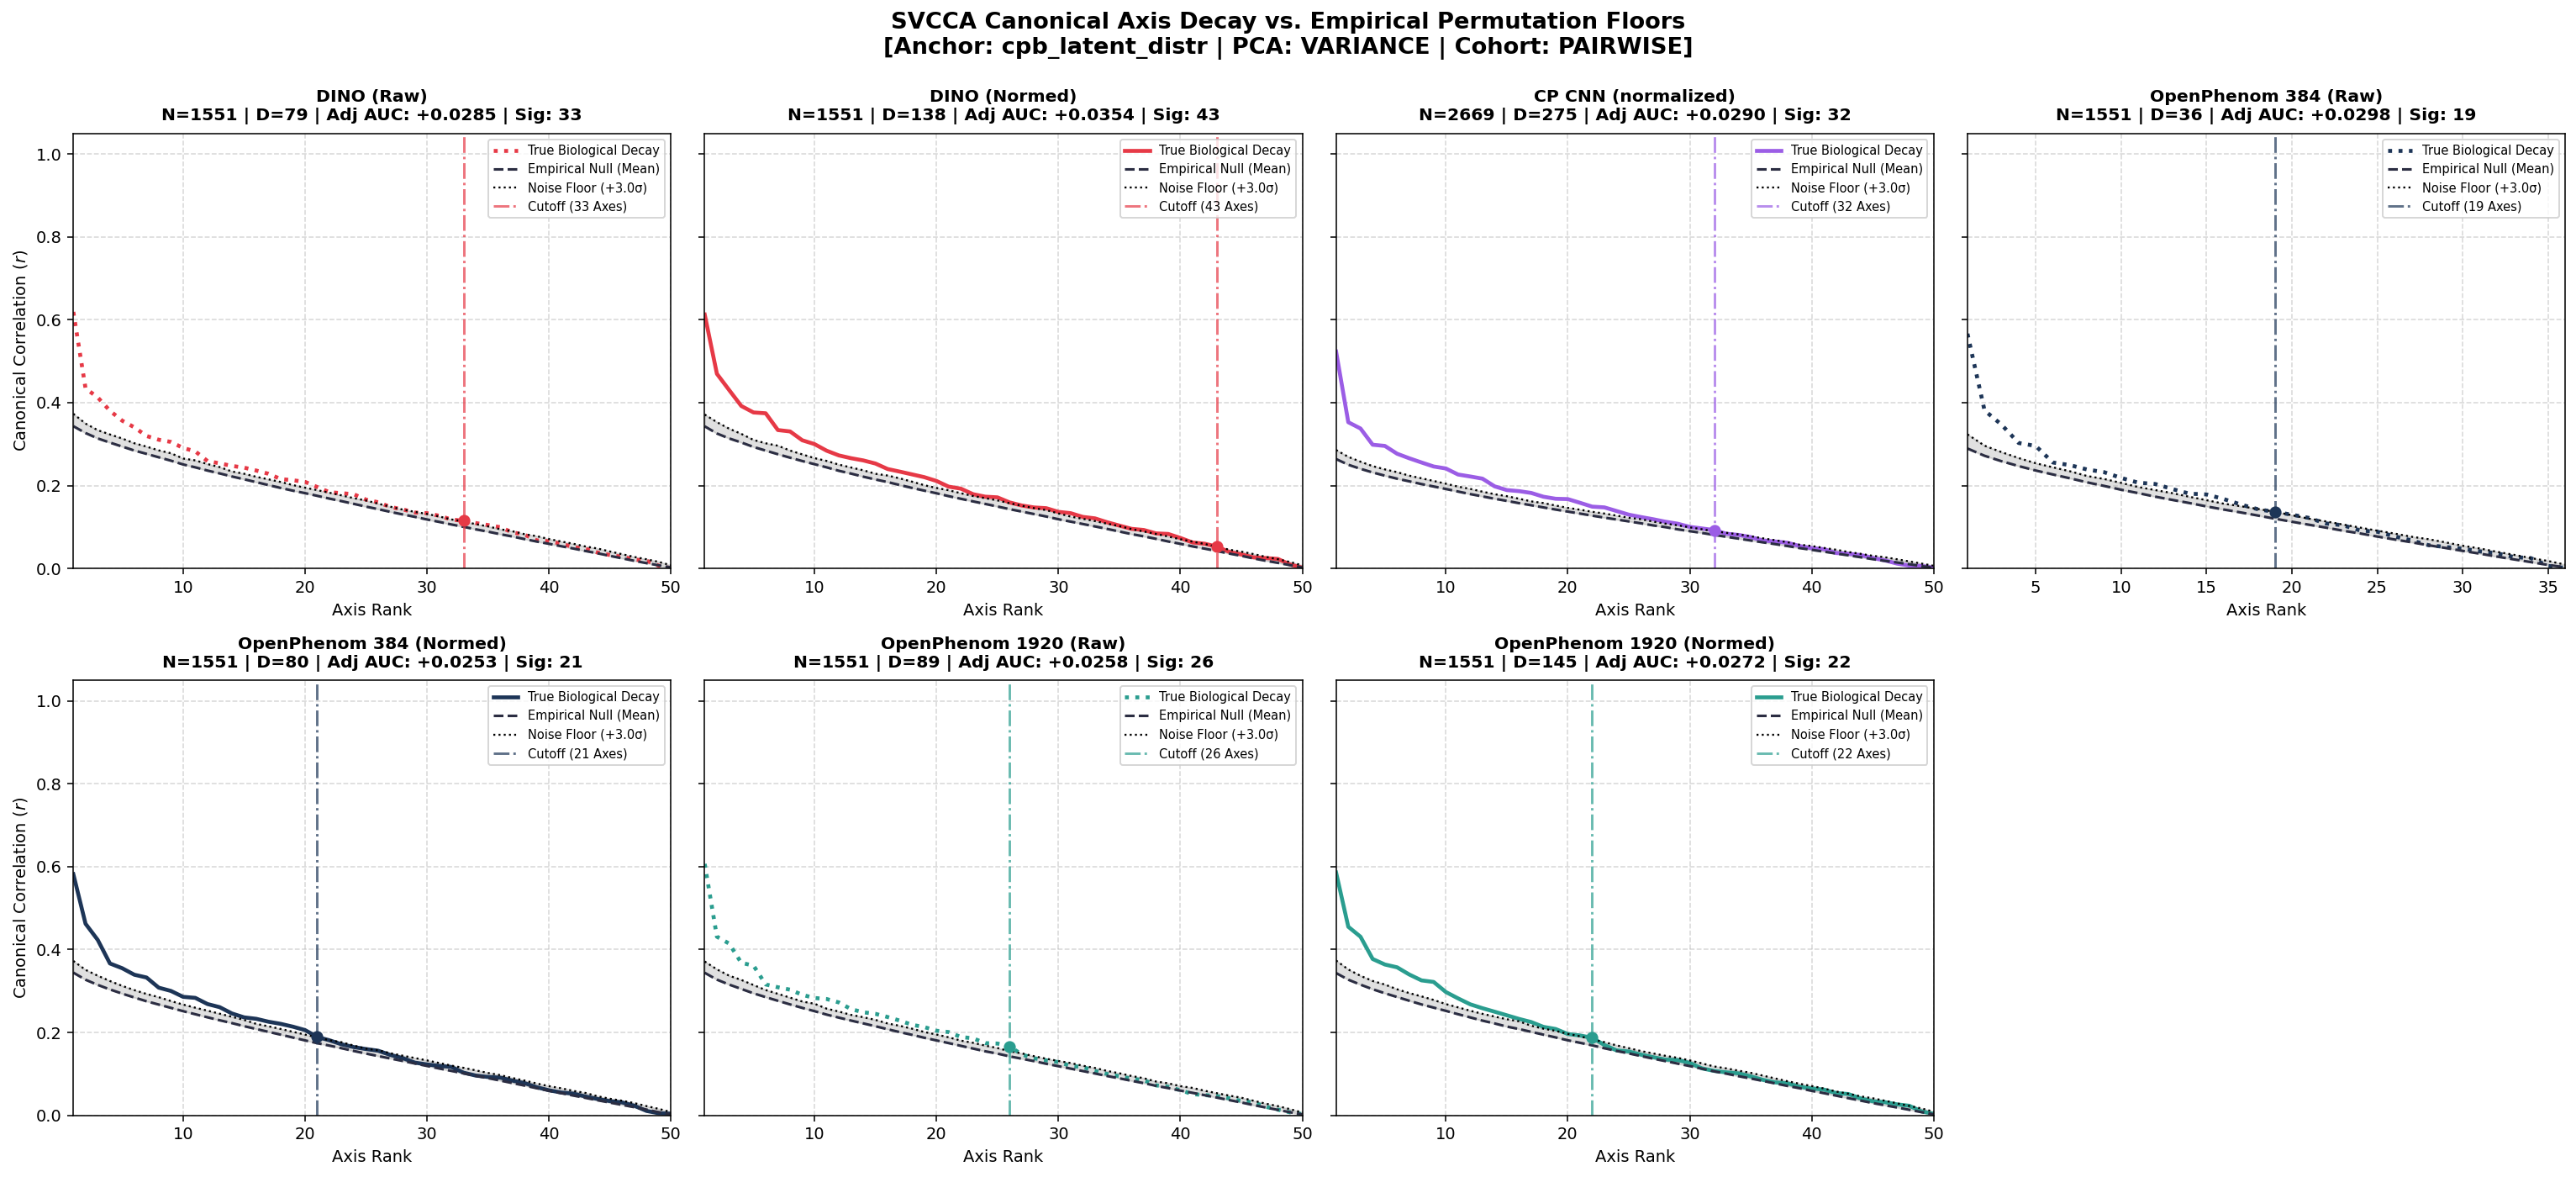

In [ ]:
# @title
import ctypes
import gc
import json
import os
import shutil
import subprocess
import sys
import tempfile
import time
import warnings
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyarrow.parquet as pq
import seaborn as sns
import torch

warnings.filterwarnings("ignore")

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE ACCELERATION
# ==============================================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cpu")
if torch.cuda.is_available():
    try:
        _test = torch.zeros(1, device="cuda") + 1
        device = torch.device("cuda")
        print(
            f"⚡ Acceleration Engine: GPU Verified ({torch.cuda.get_device_name(0)})"
        )
    except Exception:
        print(
            f"⚠️ GPU detected ({torch.cuda.get_device_name(0)}), but PyTorch lacks matching kernel images."
        )
        print(
            "⚡ Automatically falling back to high-throughput CPU (PyTorch MKL). Executing safely!"
        )
        device = torch.device("cpu")
else:
    print("⚡ Running on CPU.")


def log_debug(msg, t_start=None):
    ram_gb = psutil.virtual_memory().used / 1e9
    ram_pct = psutil.virtual_memory().percent
    elapsed = f"[+{time.time() - t_start:5.1f}s] " if t_start else ""
    print(f"⏱️ {elapsed}🧠 RAM: {ram_gb:4.1f}GB ({ram_pct:2.0f}%) | {msg}")


# ==============================================================================
# 🎛️ 1. CONFIGURATION: EVALUATION FLAGS & UPDATED DATASET PATHS
# ==============================================================================
MERGE_KEY = "InChIKey"
DMSO_INCHIKEY = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N"
MAX_EVAL_AXES = 50  # Maximum canonical dimensions to evaluate

# ------------------------------------------------------------------------------
# 🚩 FLAG 1: PCA Compression Mode
# ------------------------------------------------------------------------------
PCA_MODE = "variance"  # Options: "variance" | "fixed" | "none"
PCA_VARIANCE_THRESHOLD = 0.990  # Used if PCA_MODE == "variance"
PCA_FIXED_DIMS = 384  # Used if PCA_MODE == "fixed"

# ------------------------------------------------------------------------------
# 🚩 FLAG 2: Transcriptomic Anchor Source
# ------------------------------------------------------------------------------
TRANSCRIPTOMIC_SOURCE = (
    "cpb_latent_distr"  # Options: "drugseq_normalized" | "cpb_latent_distr" | "drugseq_raw" | "cpb_latent_all"
)

TRANSCRIPTOMIC_DATASETS = {
    "drugseq_normalized": {
        "uri": "gs://calico-reference-embeddings/indexed_by_inchikey/novartis_drugseq_u2os_10uM_24h_normalized_factors.parquet",
        "cache": "cached_drugseq_factors_anchor.parquet",
        "desc": "Novartis DRUG-seq 10 µM / 24H Normalized Varimax Factors",
    },
    "cpb_latent_distr": {
        "uri": "gs://calico-reference-embeddings/indexed_by_inchikey/cpb_observed_molecules_lpm_latents-extra.parquet",
        "cache": "cached_cpb_latent_anchor.parquet",
        "desc": "ChemPerturb-Bridge (CPB) / CPA Latent Perturbation Representations",
    },
    "drugseq_raw": {
        "uri": "gs://calico-reference-embeddings/indexed_by_inchikey/Novartis_U2OS_Dose_Time_Signatures.parquet",
        "cache": "cached_drugseq_raw_anchor.parquet",
        "desc": "Novartis DRUG-seq Raw Expression Signatures (~15k genes)",
    },
    "cpb_latent_all": {
        "uri": "gs://calico-reference-embeddings/indexed_by_inchikey/jump_cp_latent_perturbation_embeddings.parquet",
        "cache": "cached_cpb_latent_all.parquet",
        "desc": "CPB/CPA latent projected on all jump"
    },
}

# ------------------------------------------------------------------------------
# 🚩 FLAG 3: Statistical Significance Threshold above Permutation Baseline
# ------------------------------------------------------------------------------
STAT_THRESHOLD_MODE = "std"  # Options: "std" | "percentile"
STAT_THRESHOLD_SIGMA = 3.0  # Used if STAT_THRESHOLD_MODE == "std" 2.0 is default
STAT_THRESHOLD_PERCENTILE = 95.0  # Used if STAT_THRESHOLD_MODE == "percentile"

# ------------------------------------------------------------------------------
# 🚩 FLAG 4: Evaluation Cohort Strategy
# ------------------------------------------------------------------------------
COHORT_STRATEGY = "pairwise"  # Options: "common" | "pairwise". common = only the molecules all models have access to

# Updated Morphology Datasets (Pointed to indexed_by_inchikey)
MORPHOLOGY_DATASETS = {
    "DINO (Raw)": "gs://calico-reference-embeddings/indexed_by_inchikey/BAYER_DINO_embeddings_nonorm_final.parquet",
    "DINO (Normed)": "gs://calico-reference-embeddings/indexed_by_inchikey/BAYER_DINO_embeddings_0922_normed.parquet",
    #"bayer DINO actives": "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/Bayer_DINO_embeddings_normed_final-actives_only_with_MOA.parquet",
    'CP CNN (normalized)': "gs://calico-reference-embeddings/indexed_by_inchikey/CP-CNN_JUMP-CP_9.22_normalized.parquet",
    #'Imagenet (normalized)': "gs://calico-reference-embeddings/indexed_by_inchikey/Imagenet_JUMP-CP_9.22_normalized.parquet",
    "OpenPhenom 384 (Raw)": "gs://calico-reference-embeddings/indexed_by_inchikey/openphenom_384.parquet",
    "OpenPhenom 384 (Normed)": "gs://calico-reference-embeddings/indexed_by_inchikey/openphenom_384_0922_normed.parquet",
    "OpenPhenom 1920 (Raw)": "gs://calico-reference-embeddings/indexed_by_inchikey/openphenom_1920.parquet",
    "OpenPhenom 1920 (Normed)": "gs://calico-reference-embeddings/indexed_by_inchikey/openphenom_1920_0922_normed.parquet",
}


# ==============================================================================
# 🔍 INCHIKEY DETECTOR (INDEX + COLUMN AWARE)
# ==============================================================================
def detect_inchikey_col(file_path):
    """
    Detects the InChIKey column name from a parquet file.
    Inspects physical column names as well as Parquet schema pandas metadata.
    """
    schema = pq.read_schema(file_path)
    col_names = [f.name for f in schema]

    # 1. Search in column names
    key = next(
        (
            c
            for c in col_names
            if "inchikey" in c.lower()
            and not c.lower().endswith("14")
            and "prefix" not in c.lower()
        ),
        None,
    )
    if key:
        return key

    # 2. Search in pandas schema metadata (if saved as an index)
    if schema.metadata and b"pandas" in schema.metadata:
        try:
            p_meta = json.loads(schema.metadata[b"pandas"].decode("utf-8"))
            for idx in p_meta.get("index_columns", []):
                if isinstance(idx, str) and (
                    "inchikey" in idx.lower() or idx in col_names
                ):
                    return idx
        except Exception:
            pass

    # 3. Default fallback
    if "Metadata_InChIKey" in col_names:
        return "Metadata_InChIKey"

    return None


# ==============================================================================
# 📥 2. PRE-CACHE PARQUETS LOCALLY (WITH STALE CACHE VALIDATION)
# ==============================================================================
t0 = time.time()
active_transcriptome = TRANSCRIPTOMIC_DATASETS[TRANSCRIPTOMIC_SOURCE]
RNA_URI = active_transcriptome["uri"]
LOCAL_RNA_CACHE = active_transcriptome["cache"]

print("=" * 95)
log_debug(f"Commencing Benchmark: [{active_transcriptome['desc']}]")
print(
    f"  • Flag 1 (PCA Mode):       {PCA_MODE.upper()} "
    + (
        f"({PCA_VARIANCE_THRESHOLD*100:.0f}% Var)"
        if PCA_MODE == "variance"
        else f"({PCA_FIXED_DIMS}D)"
        if PCA_MODE == "fixed"
        else "(Native)"
    )
)
print(f"  • Flag 2 (Anchor Source):  {TRANSCRIPTOMIC_SOURCE}")
print(
    f"  • Flag 3 (Cutoff Engine):  {STAT_THRESHOLD_MODE.upper()} "
    + (
        f"(+{STAT_THRESHOLD_SIGMA}σ)"
        if STAT_THRESHOLD_MODE == "std"
        else f"({STAT_THRESHOLD_PERCENTILE}th %)"
    )
)
print(f"  • Flag 4 (Cohort Mode):    {COHORT_STRATEGY.upper()} Overlap")
print("=" * 95)

# Validate & download transcriptomic anchor
if os.path.exists(LOCAL_RNA_CACHE):
    if (
        os.path.getsize(LOCAL_RNA_CACHE) == 0
        or detect_inchikey_col(LOCAL_RNA_CACHE) is None
    ):
        print(f"  🔄 Stale RNA cache detected. Re-downloading...")
        os.remove(LOCAL_RNA_CACHE)

if not os.path.exists(LOCAL_RNA_CACHE):
    log_debug(f"Downloading transcriptomic anchor from {RNA_URI}...", t0)
    cmd = ["gcloud", "storage", "cp", RNA_URI, LOCAL_RNA_CACHE]
    subprocess.run(cmd, check=True)

# Validate & pre-cache morphology files locally
cached_filepaths = {}
for name, uri in MORPHOLOGY_DATASETS.items():
    clean_tag = (
        name.replace(" ", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
        .replace("-", "_")
        .replace(",", "")
    )
    cache_name = f"cached_{clean_tag}.parquet"
    cached_filepaths[name] = cache_name

    # If the file exists locally but lacks an InChIKey column (stale download), invalidate it!
    if os.path.exists(cache_name):
        if (
            os.path.getsize(cache_name) == 0
            or detect_inchikey_col(cache_name) is None
        ):
            print(
                f"  🔄 Invalidating stale cache for [{name}] (missing InChIKey)..."
            )
            os.remove(cache_name)

    if not os.path.exists(cache_name):
        print(f"  📥 Pre-caching [{name}] from GCS ({uri})...")
        cmd = ["gcloud", "storage", "cp", uri, cache_name]
        subprocess.run(cmd, check=True)

# ==============================================================================
# 🎯 2.5 MUTUAL COMMON INTERSECTION DISCOVERY (IF COHORT_STRATEGY == "common")
# ==============================================================================
common_keys_set = None

if COHORT_STRATEGY == "common":
    print("\n" + "=" * 95)
    log_debug(
        "Discovering EXACT COMMON COMPOUND INTERSECTION across ALL models...", t0
    )
    print("=" * 95)

    con_keys = duckdb.connect()

    rna_k = detect_inchikey_col(LOCAL_RNA_CACHE)
    common_keys_set = set(
        con_keys.execute(f"""
        SELECT DISTINCT {rna_k} FROM read_parquet('{LOCAL_RNA_CACHE}')
        WHERE {rna_k} IS NOT NULL AND {rna_k} != '{DMSO_INCHIKEY}'
    """).df()[rna_k]
    )

    for name, c_path in cached_filepaths.items():
        m_schema = [f.name for f in pq.read_schema(c_path)]
        m_k = detect_inchikey_col(c_path)
        has_pert = "Metadata_pert_type" in m_schema
        pert_filter = (
            "WHERE Metadata_pert_type = 'trt'"
            if has_pert
            else f"WHERE {m_k} != '{DMSO_INCHIKEY}'"
        )

        m_keys = set(
            con_keys.execute(f"""
            SELECT DISTINCT {m_k} FROM read_parquet('{c_path}')
            {pert_filter} AND {m_k} IS NOT NULL
        """).df()[m_k]
        )

        common_keys_set = common_keys_set.intersection(m_keys)
        log_debug(
            f"  ↳ Intersected [{name:<35}] ➔ Retained: {len(common_keys_set):,} compounds",
            t0,
        )

    con_keys.close()
    N_COMMON = len(common_keys_set)
    print(
        f"\n🎯 FINAL STANDARDIZED COHORT: Exactly N = {N_COMMON:,} compounds shared across all models.\n"
    )


# ==============================================================================
# ⚡ 3. DYNAMIC OVERLAP LOADER (ZERO-RAM PREDICATE PUSHDOWN)
# ==============================================================================
def load_dynamic_overlap_pair(
    morph_path: str,
    rna_path: str,
    target_keys_subset: set = None,
    dmso_inchikey: str = DMSO_INCHIKEY,
    morph_pert_filter: bool = True,
):
    """Dynamically loads and collapses ONLY the overlapping compounds for any comparison."""
    con = duckdb.connect()

    morph_schema = [f.name for f in pq.read_schema(morph_path)]
    rna_schema = [f.name for f in pq.read_schema(rna_path)]

    morph_key = detect_inchikey_col(morph_path)
    rna_key = detect_inchikey_col(rna_path)

    if not morph_key or not rna_key:
        raise ValueError(
            f"InChIKey column missing!\n"
            f"  • Morph ({os.path.basename(morph_path)}): {morph_key} (Cols: {morph_schema[:8]}...)\n"
            f"  • RNA   ({os.path.basename(rna_path)}): {rna_key} (Cols: {rna_schema[:8]}...)"
        )

    has_pert_type = "Metadata_pert_type" in morph_schema
    pert_clause = (
        "AND Metadata_pert_type = 'trt'"
        if (has_pert_type and morph_pert_filter)
        else ""
    )

    time_col = next((c for c in rna_schema if "pert_time" in c.lower()), None)
    time_clause = (
        f"AND TRY_CAST({time_col} AS FLOAT) IN (24, 48)" if time_col else ""
    )

    # Phase 1: Key Intersection (Zero-RAM Column Scan)
    if target_keys_subset is not None:
        shared_keys_df = pd.DataFrame(
            {"ikey": sorted(list(target_keys_subset))}
        )
    else:
        key_intersect_query = f"""
            WITH morph_keys AS (
                SELECT DISTINCT {morph_key} AS ikey
                FROM read_parquet('{morph_path}')
                WHERE {morph_key} IS NOT NULL
                  AND {morph_key} != '{dmso_inchikey}'
                  {pert_clause}
            ),
            rna_keys AS (
                SELECT DISTINCT {rna_key} AS ikey
                FROM read_parquet('{rna_path}')
                WHERE {rna_key} IS NOT NULL
                  AND {rna_key} != '{dmso_inchikey}'
                  {time_clause}
            )
            SELECT ikey FROM morph_keys
            INTERSECT
            SELECT ikey FROM rna_keys
            ORDER BY ikey ASC
        """
        shared_keys_df = con.execute(key_intersect_query).df()

    if len(shared_keys_df) == 0:
        con.close()
        raise ValueError("Zero overlapping compounds found between datasets!")

    con.register("shared_keys_view", shared_keys_df)

    # Phase 2: Ingest & Collapse Morphology
    morph_query = f"""
        SELECT *
        FROM read_parquet('{morph_path}')
        WHERE {morph_key} IN (SELECT ikey FROM shared_keys_view)
        {pert_clause}
    """
    morph_df = con.execute(morph_query).df()
    if morph_key != MERGE_KEY:
        morph_df = morph_df.rename(columns={morph_key: MERGE_KEY})

    morph_features = [
        c
        for c in morph_df.select_dtypes(include=[np.number]).columns
        if not c.startswith("Metadata_")
        and c not in [MERGE_KEY, "pubchem_cid"]
        and not c.startswith("__")
    ]

    morph_consensus = morph_df.groupby(
        MERGE_KEY, as_index=False, dropna=False
    )[morph_features].median()
    morph_consensus = morph_consensus.sort_values(
        by=MERGE_KEY, kind="stable"
    ).reset_index(drop=True)

    # Phase 3: Ingest & Collapse RNA
    rna_query = f"""
        SELECT *
        FROM read_parquet('{rna_path}')
        WHERE {rna_key} IN (SELECT ikey FROM shared_keys_view)
        {time_clause}
    """
    rna_df = con.execute(rna_query).df()
    if rna_key != MERGE_KEY:
        rna_df = rna_df.rename(columns={rna_key: MERGE_KEY})

    rna_features = [
        c
        for c in rna_df.select_dtypes(include=[np.number]).columns
        if not c.startswith("Metadata_")
        and c
        not in [
            MERGE_KEY,
            "pubchem_cid",
            "pert_time_h",
            "pert_dose_uM",
            "Metadata_InChIKey",
        ]
        and not c.startswith("__")
    ]

    if not rna_df[MERGE_KEY].is_unique:
        sort_cols = [
            c
            for c in [MERGE_KEY, "pert_dose_uM", "pert_time_h"]
            if c in rna_df.columns
        ]
        if sort_cols:
            rna_df = rna_df.sort_values(by=sort_cols, kind="stable").reset_index(
                drop=True
            )
        grouped = rna_df.groupby(MERGE_KEY, sort=True)[rna_features]

        def pool_func(x):
            idx = np.argmax(np.abs(x.values), axis=0)
            return x.values[idx, np.arange(x.shape[1])]

        rna_consensus = pd.DataFrame(
            grouped.apply(pool_func).tolist(),
            index=grouped.apply(pool_func).index,
            columns=rna_features,
        ).reset_index()
    else:
        rna_consensus = rna_df[[MERGE_KEY] + rna_features].copy()

    rna_consensus = rna_consensus.sort_values(
        by=MERGE_KEY, kind="stable"
    ).reset_index(drop=True)
    con.close()

    # Alignment verification
    assert (
        morph_consensus[MERGE_KEY].values == rna_consensus[MERGE_KEY].values
    ).all(), "FATAL: Compound ordering mismatch between modalities!"

    X_morph = np.nan_to_num(
        morph_consensus[morph_features].values.astype(np.float32)
    )
    Y_rna = np.nan_to_num(rna_consensus[rna_features].values.astype(np.float32))
    shared_inchikeys = morph_consensus[MERGE_KEY].values

    return X_morph, Y_rna, shared_inchikeys


# ==============================================================================
# ⚡ 4. EXTREME-SCALE MEMORY-SAFE LINEAR ALGEBRA & CKA ENGINE
# ==============================================================================
def svd_flip_torch(u, v=None):
    max_abs_cols = torch.argmax(torch.abs(u), dim=0)
    signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
    signs[signs == 0] = 1.0
    u = u * signs
    if v is not None:
        k_shared = min(u.shape[1], v.shape[0])
        v[:k_shared] = v[:k_shared] * signs[:k_shared].unsqueeze(1)
        return u, v
    return u


def reduce_dimensions_configurable(
    X_np,
    mode=PCA_MODE,
    var_threshold=PCA_VARIANCE_THRESHOLD,
    fixed_dims=PCA_FIXED_DIMS,
):
    if mode == "none":
        return X_np.astype(np.float32)

    N_samples, D_features = X_np.shape
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    X_c = X - X.mean(dim=0)

    if N_samples > D_features:
        U, S, Vt = torch.linalg.svd(X_c, full_matrices=False)
        U = svd_flip_torch(U)

        if mode == "variance":
            cum_variance = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
            k = (
                int(
                    torch.argmax((cum_variance >= var_threshold).to(torch.int64)).item()
                )
                + 1
            )
            k = min(k, int(N_samples * 0.8), D_features)
        elif mode == "fixed":
            k = min(fixed_dims, D_features, int(N_samples * 0.8))
        else:
            k = min(D_features, int(N_samples * 0.8))

        return (U[:, :k] * S[:k]).cpu().numpy().astype(np.float32)
    else:
        G = torch.matmul(X_c, X_c.T)
        eigvals, eigvecs = torch.linalg.eigh(G)
        idx_desc = torch.argsort(eigvals, descending=True)
        sorted_eigvals = torch.clamp(eigvals[idx_desc], min=1e-8)
        sorted_eigvecs = svd_flip_torch(eigvecs[:, idx_desc])

        if mode == "variance":
            cum_variance = torch.cumsum(sorted_eigvals, dim=0) / torch.sum(
                sorted_eigvals
            )
            k = (
                int(
                    torch.argmax((cum_variance >= var_threshold).to(torch.int64)).item()
                )
                + 1
            )
            k = min(k, int(N_samples * 0.8), D_features)
        elif mode == "fixed":
            k = min(fixed_dims, D_features, int(N_samples * 0.8))
        else:
            k = min(D_features, int(N_samples * 0.8))

        top_eigvals = sorted_eigvals[:k]
        top_eigvecs = sorted_eigvecs[:, :k]
        return (
            (top_eigvecs * torch.sqrt(top_eigvals)).cpu().numpy().astype(np.float32)
        )


def get_exact_subspace_basis(M, k=50):
    N_samples, D_features = M.shape
    k = min(k, N_samples, D_features)

    if N_samples > D_features:
        U, _, _ = torch.linalg.svd(M, full_matrices=False)
        return svd_flip_torch(U[:, :k])
    else:
        G = torch.matmul(M, M.T)
        eigvals, eigvecs = torch.linalg.eigh(G)
        idx = torch.argsort(eigvals, descending=True)[:k]
        return svd_flip_torch(eigvecs[:, idx])


def evaluate_alignment_exact(X_np, Y_np, n_permutations=100, seed=42):
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    Y = torch.tensor(Y_np, device=device, dtype=torch.float32)
    N = X.shape[0]

    X_c = X - X.mean(dim=0)
    Y_c = Y - Y.mean(dim=0)

    XtX = torch.matmul(X_c.T, X_c)
    YtY = torch.matmul(Y_c.T, Y_c)
    norm_x = torch.linalg.norm(XtX)
    norm_y = torch.linalg.norm(YtY)
    denom = (norm_x * norm_y) + 1e-12

    XtY = torch.matmul(X_c.T, Y_c)
    true_cka = (torch.sum(XtY**2) / denom).item()

    gen = torch.Generator(device=device).manual_seed(seed)
    null_ckas = []

    for _ in range(n_permutations):
        perm_idx = torch.randperm(N, generator=gen, device=device)
        XtY_perm = torch.matmul(X_c.T, Y_c[perm_idx])
        null_ckas.append((torch.sum(XtY_perm**2) / denom).item())

    null_ckas = np.array(null_ckas)
    null_mean = np.mean(null_ckas)
    adj_sig = true_cka - null_mean
    p_val = (np.sum(null_ckas >= true_cka) + 1) / (n_permutations + 1)

    return true_cka, null_mean, adj_sig, p_val


def get_svcca_decay_and_null_exact(
    X_np,
    Y_np,
    k_dims=50,
    n_perms=100,
    seed=42,
    thresh_mode=STAT_THRESHOLD_MODE,
    sigma_val=STAT_THRESHOLD_SIGMA,
    pct_val=STAT_THRESHOLD_PERCENTILE,
):
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    Y = torch.tensor(Y_np, device=device, dtype=torch.float32)
    N = X.shape[0]
    max_k = min(int(N * 0.8), X.shape[1], Y.shape[1], k_dims)

    X_c = X - X.mean(dim=0)
    Y_c = Y - Y.mean(dim=0)

    Qa = get_exact_subspace_basis(X_c, max_k)
    Qb = get_exact_subspace_basis(Y_c, max_k)

    cross_cov = torch.matmul(Qa.T, Qb)
    U, S, Vt = torch.linalg.svd(cross_cov, full_matrices=False)
    U, _ = svd_flip_torch(U, Vt)
    true_corrs = torch.sort(S, descending=True)[0].cpu().numpy()

    gen = torch.Generator(device=device).manual_seed(seed)
    null_corrs_list = []

    for _ in range(n_perms):
        perm_idx = torch.randperm(N, generator=gen, device=device)
        cross_cov_null = torch.matmul(Qa.T, Qb[perm_idx])
        S_null = torch.linalg.svdvals(cross_cov_null)
        null_corrs_list.append(
            torch.sort(S_null, descending=True)[0].cpu().numpy()
        )

    null_matrix = np.array(null_corrs_list)
    null_mean = null_matrix.mean(axis=0)
    null_std = null_matrix.std(axis=0)

    if thresh_mode == "std":
        cutoff_curve = null_mean + (sigma_val * null_std)
    elif thresh_mode == "percentile":
        cutoff_curve = np.percentile(null_matrix, pct_val, axis=0)
    else:
        cutoff_curve = null_mean + (2.0 * null_std)

    sig_axes = int(np.sum(true_corrs > cutoff_curve))
    return true_corrs, null_mean, null_std, cutoff_curve, sig_axes


# ==============================================================================
# 🏆 5. THE BENCHMARK EXECUTION LOOP
# ==============================================================================
results_leaderboard = []
decay_curves = {}
null_curves = {}
cutoff_curves = {}

print("=" * 95)
print(f"🚀 COMMENCING SYSTEMATIC BENCHMARK")
print("=" * 95)

for name, uri in MORPHOLOGY_DATASETS.items():
    t_model = time.time()
    cache_name = cached_filepaths[name]

    X_morph, Y_rna, shared_keys = load_dynamic_overlap_pair(
        morph_path=cache_name,
        rna_path=LOCAL_RNA_CACHE,
        target_keys_subset=common_keys_set,
    )

    overlap_N = len(shared_keys)
    raw_dim = X_morph.shape[1]

    X_morph_proc = reduce_dimensions_configurable(
        X_morph,
        mode=PCA_MODE,
        var_threshold=PCA_VARIANCE_THRESHOLD,
        fixed_dims=PCA_FIXED_DIMS,
    )
    final_dim = X_morph_proc.shape[1]

    true_cka, null_cka, adj_sig, p_val = evaluate_alignment_exact(
        X_morph_proc, Y_rna, n_permutations=100
    )
    true_corrs, null_mean, null_std, cutoff_curve, sig_axes = (
        get_svcca_decay_and_null_exact(
            X_morph_proc, Y_rna, k_dims=MAX_EVAL_AXES, n_perms=100
        )
    )

    decay_curves[name] = true_corrs
    null_curves[name] = (null_mean, null_std)
    cutoff_curves[name] = cutoff_curve

    eval_len = min(MAX_EVAL_AXES, len(true_corrs))
    true_auc = float(np.mean(true_corrs[:eval_len]))
    null_auc = float(np.mean(null_mean[:eval_len]))
    adj_svcca_auc = true_auc - null_auc

    comp_tag = (
        f"{raw_dim:4d}D ➔ {final_dim}D"
        if raw_dim != final_dim
        else f"{final_dim}D"
    )
    print(
        f"[{name:<35}] N={overlap_N:4d} | Dims: {comp_tag:<12} | SVCCA Adj AUC: {adj_svcca_auc:+.4f} | Sig: {sig_axes:2d} | CKA: {adj_sig:+.4f} ({time.time() - t_model:4.1f}s)"
    )

    results_leaderboard.append(
        {
            "Model / Processing": name,
            "Compounds (N)": overlap_N,
            "Original Dims": raw_dim,
            "Evaluated Dims": final_dim,
            "SVCCA Adj. AUC": adj_svcca_auc,
            "SVCCA True AUC": true_auc,
            "SVCCA Null AUC": null_auc,
            "Significant Axes": sig_axes,
            "CKA Adj. Signal": adj_sig,
            "P-Value": p_val,
        }
    )

    del X_morph, Y_rna, X_morph_proc
    gc.collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

# ==============================================================================
# 📈 6. STANDARDIZED LEADERBOARD
# ==============================================================================
leaderboard_df = pd.DataFrame(results_leaderboard)
leaderboard_df = leaderboard_df.sort_values(
    by="SVCCA Adj. AUC", ascending=False, kind="stable"
).reset_index(drop=True)

print("\n" + "=" * 125)
print(
    f"🏆 BENCHMARK LEADERBOARD (PCA Mode: {PCA_MODE.upper()} | Anchor: {TRANSCRIPTOMIC_SOURCE} | Cohort: {COHORT_STRATEGY.upper()})"
)
print("=" * 125)
print(leaderboard_df.to_string(index=True, float_format="{:.4f}".format))
print("=" * 125)

# ==============================================================================
# 📊 7. MULTI-PANEL FACET GRID
# ==============================================================================
print(
    "\nGenerating Multi-Panel SVCCA Decay Grid with Configured Noise Thresholds..."
)

num_models = len(decay_curves)
ncols = 4
nrows = int(np.ceil(num_models / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(22, 5 * nrows), dpi=140, sharey=True
)
axes = axes.flatten()

color_map = {
    "DINO": "#E63946",
    "OpenPhenom 384": "#1D3557",
    "OpenPhenom 1920": "#2A9D8F",
    "CP CNN": "#9B5DE5",
    "Imagenet": "#E76F51",
}

max_available_dims = max([len(corrs) for corrs in decay_curves.values()])
plot_horizon = min(MAX_EVAL_AXES, max_available_dims)

for idx, (name, corrs) in enumerate(decay_curves.items()):
    ax = axes[idx]
    null_mean, null_std = null_curves[name]
    cutoff_curve = cutoff_curves[name]

    row_stats = leaderboard_df[
        leaderboard_df["Model / Processing"] == name
    ].iloc[0]
    adj_auc = row_stats["SVCCA Adj. AUC"]
    sig_axes = row_stats["Significant Axes"]
    N_count = row_stats["Compounds (N)"]
    eval_dim = row_stats["Evaluated Dims"]

    c = next(
        (col for k, col in color_map.items() if name.startswith(k)), "#2B2D42"
    )
    ls = ":" if "Raw" in name else "-"

    plot_len = min(plot_horizon, len(corrs))
    x_range = np.arange(1, plot_len + 1)

    ax.plot(
        x_range,
        corrs[:plot_len],
        label="True Biological Decay",
        color=c,
        linestyle=ls,
        linewidth=2.4,
    )
    ax.plot(
        x_range,
        null_mean[:plot_len],
        color="#2B2D42",
        linestyle="--",
        linewidth=1.6,
        label="Empirical Null (Mean)",
    )
    thresh_label = (
        f"Noise Floor (+{STAT_THRESHOLD_SIGMA}σ)"
        if STAT_THRESHOLD_MODE == "std"
        else f"{STAT_THRESHOLD_PERCENTILE}th % Floor"
    )
    ax.plot(
        x_range,
        cutoff_curve[:plot_len],
        color="black",
        linestyle=":",
        linewidth=1.2,
        label=thresh_label,
    )
    ax.fill_between(
        x_range,
        null_mean[:plot_len],
        cutoff_curve[:plot_len],
        color="black",
        alpha=0.12,
    )

    if sig_axes > 0 and sig_axes <= plot_len:
        ax.axvline(
            x=sig_axes,
            color=c,
            linestyle="-.",
            alpha=0.7,
            linewidth=1.5,
            label=f"Cutoff ({sig_axes} Axes)",
        )
        ax.scatter([sig_axes], [corrs[sig_axes - 1]], color=c, s=40, zorder=5)

    ax.set_title(
        f"{name}\nN={N_count} | D={eval_dim} | Adj AUC: {adj_auc:+.4f} | Sig: {sig_axes}",
        fontsize=10.5,
        fontweight="bold",
        pad=8,
    )
    ax.set_xlabel("Axis Rank", fontsize=10)
    if idx % ncols == 0:
        ax.set_ylabel("Canonical Correlation ($r$)", fontsize=10)
    ax.set_xlim(1, plot_len)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize=7.5, frameon=True)

for j in range(num_models, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    f"SVCCA Canonical Axis Decay vs. Empirical Permutation Floors\n"
    f"[Anchor: {TRANSCRIPTOMIC_SOURCE} | PCA: {PCA_MODE.upper()} | Cohort: {COHORT_STRATEGY.upper()}]",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout()
plt.show()

# Interpret each correlated axis using Chem Checker and GSEA

⚡ Acceleration Engine: cuda
🏆 DECODING WINNING MODEL: [bayer DINO actives]
📊 Benchmark Score (SVCCA Adj. AUC): +0.0277 | Statistically Verified Dimensions: 28
🧬 Transcriptomic Alignment Anchor: cpb_latent_distr (cached_cpb_latent_anchor.parquet)
🔬 Bioactivity Reference: Chemical Checker 3,200D Embeddings
🎯 Decoding Horizon: Top 10 Biological Dimensions
✅ Projection Complete: 1,003 compounds projected onto 10 canonical axes.
📂 Streaming raw gene expression from disk for 1,003 compounds...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ↳ Retained Top 5,000 dynamic Ensembl genes for downstream decoding.
📂 Streaming Chemical Checker 3,200D embeddings for active cohort...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

INFO:biothings.client:querying 1-1000 ...


✅ Chemical Checker subset loaded: 1,003 compounds x 3200 dimensions.
Querying MyGene for HGNC symbols across 5,000 Ensembl IDs...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


✅ Successfully mapped 4,658 of 5,000 Ensembl IDs.

🎯 Bio_Axis_1 | Canonical Correlation ($r$): 0.4041 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : SPRR2B (+0.29), ZNF571 (+0.28), TMEM119 (+0.28), CRCT1 (+0.25), ENSG00000255046 (+0.25)
  ↳ Key Downregulated : LINC00857 (-0.22), WFDC21P (-0.21), ENSG00000268362 (-0.20), SLC6A9 (-0.20), WNT6 (-0.19)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +2.41 | FDR: 0.00e+00
     • p53 Pathway                                      | NES: +1.81 | FDR: 2.15e-02
     • Inflammatory Response                            | NES: +1.56 | FDR: 1.97e-01
     • Oxidative Phosphorylation                        | NES: +1.51 | FDR: 2.42e-01
     • Androgen Response                                | NES: +1.48 | FDR: 2.40e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Bile Acid Metabolism                             | NES: -1.62 | FDR: 2.71e-0

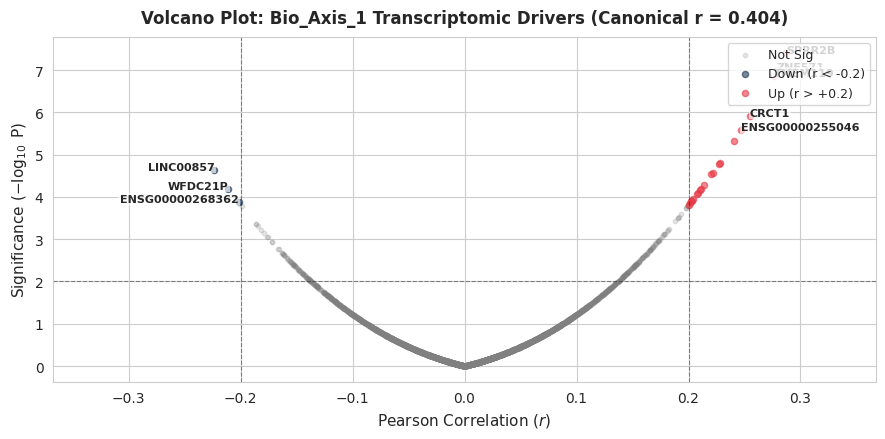


🎯 Bio_Axis_2 | Canonical Correlation ($r$): 0.3978 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : DMRT1 (+0.20), DHRS9 (+0.20), ICA1-AS1 (+0.18), CCDC120 (+0.18), NT5DC4 (+0.18)
  ↳ Key Downregulated : LOC101928994 (-0.27), CRCT1 (-0.26), SPRR2B (-0.24), RPS2P28 (-0.24), ATP8A2 (-0.23)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Hypoxia                                          | NES: +1.24 | FDR: 1.00e+00
     • Glycolysis                                       | NES: +1.23 | FDR: 7.90e-01
     • IL-2/STAT5 Signaling                             | NES: +1.08 | FDR: 1.00e+00
     • Spermatogenesis                                  | NES: +1.05 | FDR: 9.35e-01
     • Unfolded Protein Response                        | NES: +1.03 | FDR: 8.23e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Apical Junction                                  | NES: -1.67 | FDR: 1.53e-01
     • Allograft Rejection                              | NES

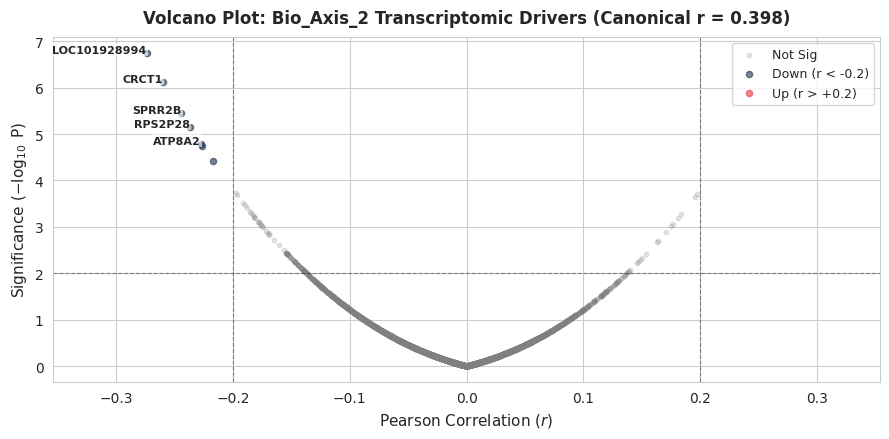


🎯 Bio_Axis_3 | Canonical Correlation ($r$): 0.3841 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CYP24A1 (+0.23), VXN (+0.21), FKBP9P1 (+0.20), ASF1A (+0.19), ENSG00000234484 (+0.18)
  ↳ Key Downregulated : MFNG (-0.20), BCAS3 (-0.20), FBXO32 (-0.19), GABARAPL1 (-0.18), ZNF792 (-0.17)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: +1.45 | FDR: 7.78e-01
     • G2-M Checkpoint                                  | NES: +1.29 | FDR: 1.00e+00
     • Angiogenesis                                     | NES: +1.16 | FDR: 1.00e+00
     • Epithelial Mesenchymal Transition                | NES: +1.11 | FDR: 1.00e+00
     • Allograft Rejection                              | NES: +1.00 | FDR: 1.00e+00

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -1.90 | FDR: 5.68e-02
     • IL-2/STAT5 Signaling                             | NES

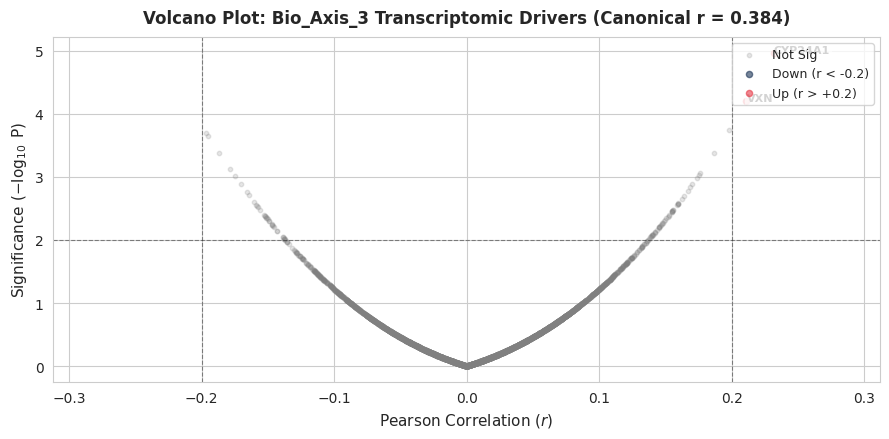


🎯 Bio_Axis_4 | Canonical Correlation ($r$): 0.3701 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CRCT1 (+0.29), SPRR2E (+0.29), DYNLT4 (+0.25), SPRR2B (+0.24), GCNT2 (+0.23)
  ↳ Key Downregulated : HMOX1 (-0.23), TXNIP (-0.23), CFAP418 (-0.21), ENSG00000272720 (-0.21), MATN3 (-0.21)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Wnt-beta Catenin Signaling                       | NES: +1.81 | FDR: 2.31e-02
     • Apical Surface                                   | NES: +1.53 | FDR: 1.64e-01
     • Notch Signaling                                  | NES: +1.46 | FDR: 2.07e-01
     • Apical Junction                                  | NES: +1.45 | FDR: 1.59e-01
     • G2-M Checkpoint                                  | NES: +1.26 | FDR: 3.71e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Hypoxia                                          | NES: -2.41 | FDR: 0.00e+00
     • mTORC1 Signaling                                 | NES: 

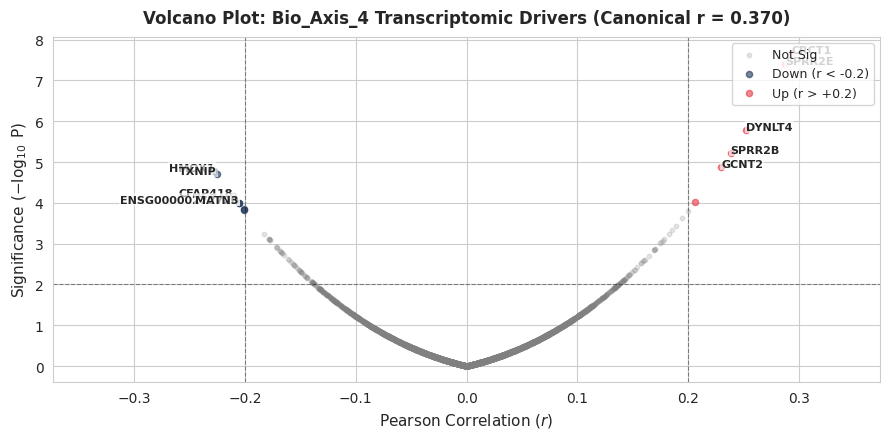


🎯 Bio_Axis_5 | Canonical Correlation ($r$): 0.3582 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : MREG (+0.19), CCIN (+0.19), VWF (+0.18), LZTS1 (+0.18), SMAD6 (+0.17)
  ↳ Key Downregulated : SPRR2D (-0.21), NALF1 (-0.20), SPOCD1 (-0.19), CXCL3 (-0.18), RUMY1 (-0.18)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Myogenesis                                       | NES: +1.23 | FDR: 1.00e+00
     • G2-M Checkpoint                                  | NES: +1.13 | FDR: 1.00e+00
     • Bile Acid Metabolism                             | NES: +1.10 | FDR: 1.00e+00
     • Xenobiotic Metabolism                            | NES: +1.06 | FDR: 1.00e+00
     • Protein Secretion                                | NES: +1.06 | FDR: 9.39e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.10 | FDR: 5.99e-03
     • Epithelial Mesenchymal Transition                | NES: -1.83 | FDR: 2.10

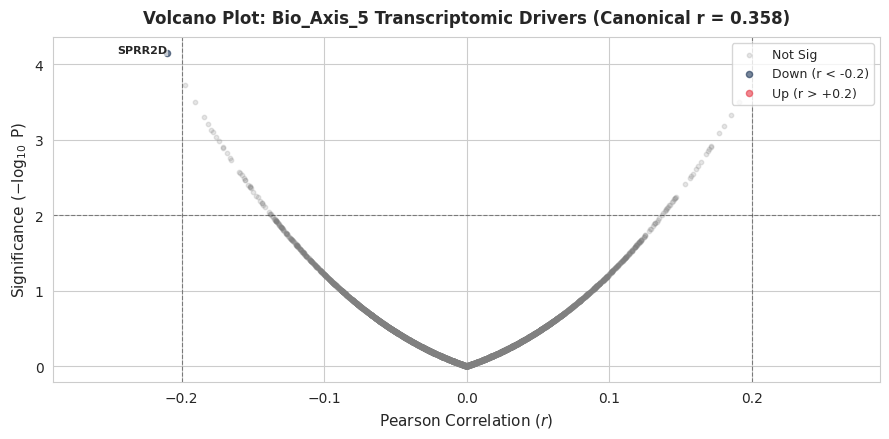


🎯 Bio_Axis_6 | Canonical Correlation ($r$): 0.3542 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : GADD45A (+0.26), LOC124905143 (+0.25), TMEM161B (+0.25), IER2 (+0.24), CXCL3 (+0.23)
  ↳ Key Downregulated : AARD (-0.19), CXCL14 (-0.18), TNNT2 (-0.18), SLC12A8 (-0.17), MIR210HG (-0.17)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +2.70 | FDR: 0.00e+00
     • p53 Pathway                                      | NES: +2.24 | FDR: 0.00e+00
     • Apoptosis                                        | NES: +1.99 | FDR: 1.88e-03
     • UV Response Up                                   | NES: +1.94 | FDR: 1.41e-03
     • mTORC1 Signaling                                 | NES: +1.91 | FDR: 1.13e-03

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Apical Surface                                   | NES: -1.67 | FDR: 7.24e-02
     • Myogenesis                                       | NES:

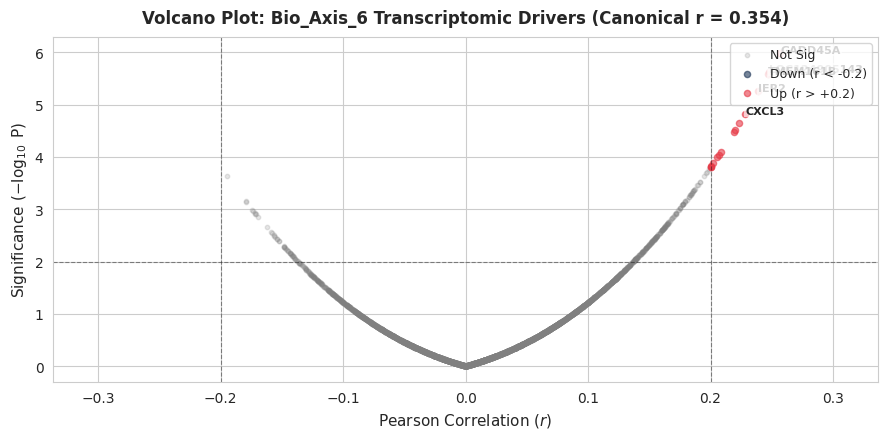


🎯 Bio_Axis_7 | Canonical Correlation ($r$): 0.3481 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : PDLIM1 (+0.25), MEX3B (+0.22), TGFBI (+0.22), SNORD3B-1 (+0.21), BMP2K-DT (+0.21)
  ↳ Key Downregulated : DDIT3 (-0.30), WIPI1 (-0.28), CLDN1 (-0.23), SPRR2D (-0.22), EPAS1 (-0.22)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Myogenesis                                       | NES: +1.78 | FDR: 5.08e-02
     • Apical Junction                                  | NES: +1.77 | FDR: 2.99e-02
     • Wnt-beta Catenin Signaling                       | NES: +1.41 | FDR: 1.83e-01
     • Apical Surface                                   | NES: +1.34 | FDR: 2.11e-01
     • Estrogen Response Late                           | NES: +1.14 | FDR: 4.56e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.33 | FDR: 0.00e+00
     • p53 Pathway                                      | NES: -1.98 

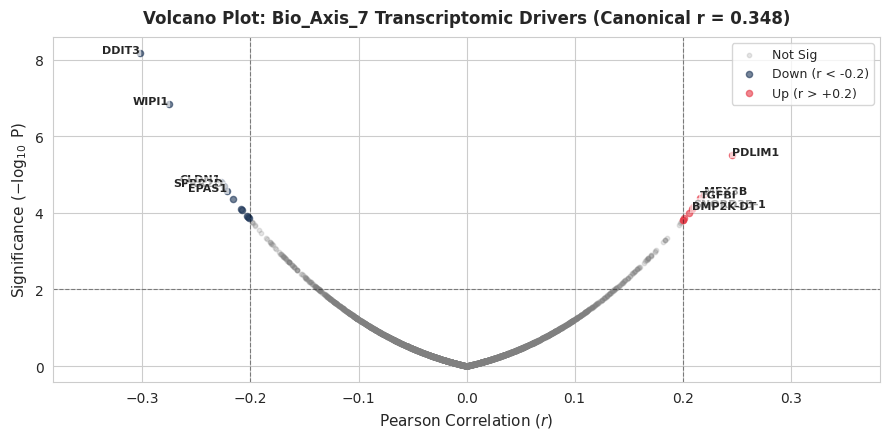


🎯 Bio_Axis_8 | Canonical Correlation ($r$): 0.3282 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : RPS18P13 (+0.19), ATP6V0D2 (+0.18), CACNA1C (+0.18), GPR63 (+0.18), NKX6-1 (+0.17)
  ↳ Key Downregulated : NMRAL2P (-0.22), RPL9P21 (-0.22), GAPDHP65 (-0.22), PLOD2 (-0.21), ADAMTS16 (-0.21)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Apical Surface                                   | NES: +1.30 | FDR: 1.00e+00
     • Wnt-beta Catenin Signaling                       | NES: +1.29 | FDR: 5.95e-01
     • Notch Signaling                                  | NES: +1.24 | FDR: 5.10e-01
     • DNA Repair                                       | NES: +1.06 | FDR: 8.69e-01
     • Coagulation                                      | NES: +1.00 | FDR: 8.90e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • IL-6/JAK/STAT3 Signaling                         | NES: -1.83 | FDR: 3.64e-02
     • mTORC1 Signaling                                 | N

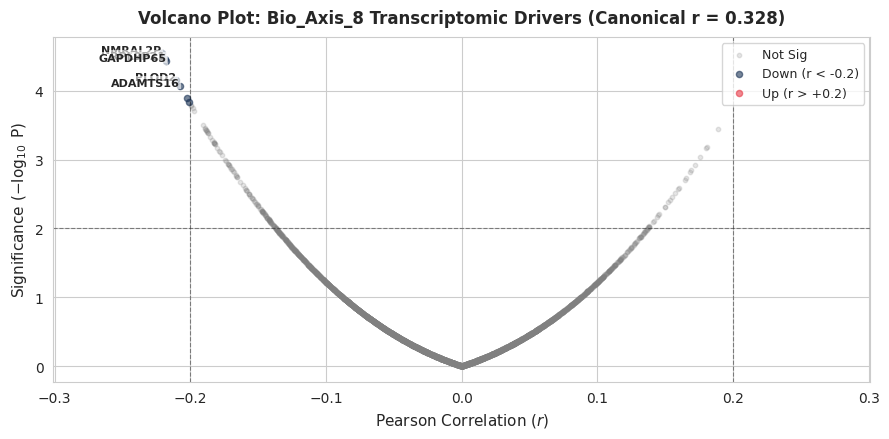


🎯 Bio_Axis_9 | Canonical Correlation ($r$): 0.3255 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : THBS1-IT1 (+0.31), B3GALT4 (+0.28), HTRA1 (+0.24), RPL23P2 (+0.23), TMEM119 (+0.23)
  ↳ Key Downregulated : CHAC1 (-0.22), ADAT3 (-0.20), UNC13A (-0.20), ENSG00000258945 (-0.18), OSGIN1 (-0.18)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Fatty Acid Metabolism                            | NES: +1.39 | FDR: 1.00e+00
     • Protein Secretion                                | NES: +1.24 | FDR: 1.00e+00
     • Wnt-beta Catenin Signaling                       | NES: +1.24 | FDR: 1.00e+00
     • Adipogenesis                                     | NES: +1.23 | FDR: 1.00e+00
     • Interferon Alpha Response                        | NES: +1.22 | FDR: 1.00e+00

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Unfolded Protein Response                        | NES: -1.70 | FDR: 9.22e-02
     • mTORC1 Signaling                                 

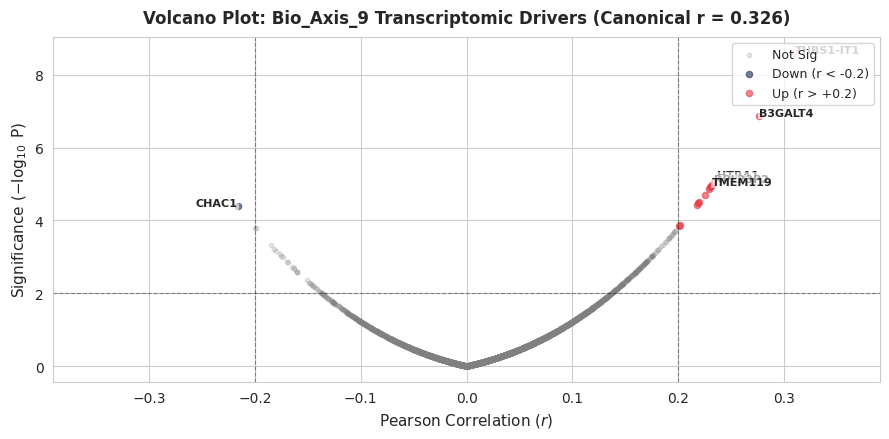


🎯 Bio_Axis_10 | Canonical Correlation ($r$): 0.3071 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ZNF554 (+0.22), LCP1 (+0.21), UNC13A (+0.20), BMS1P23 (+0.20), GCNT2 (+0.20)
  ↳ Key Downregulated : ENSG00000288459 (-0.26), HTR3A (-0.22), TEKT4 (-0.21), ENSG00000272720 (-0.21), INKA1 (-0.19)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: +1.73 | FDR: 1.38e-01
     • mTORC1 Signaling                                 | NES: +1.45 | FDR: 5.61e-01
     • Epithelial Mesenchymal Transition                | NES: +1.40 | FDR: 5.11e-01
     • Hypoxia                                          | NES: +1.19 | FDR: 1.00e+00
     • G2-M Checkpoint                                  | NES: +1.17 | FDR: 1.00e+00

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • KRAS Signaling Dn                                | NES: -1.82 | FDR: 5.48e-02
     • Androgen Response                              

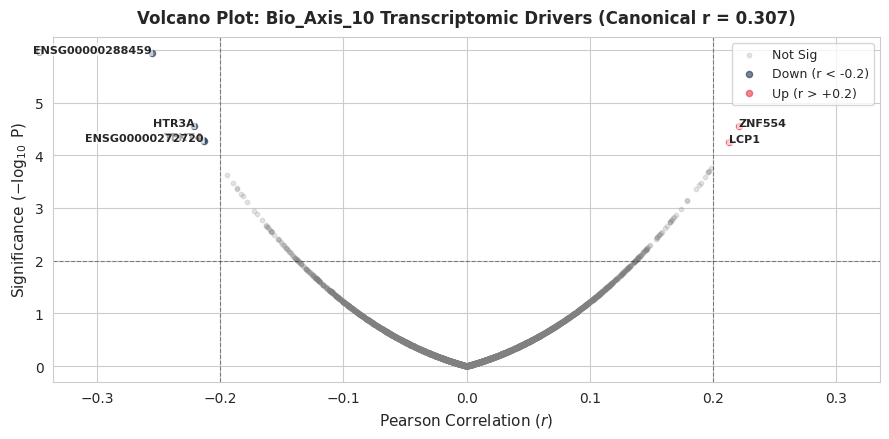


🏁 ENHANCED BIOLOGICAL & CHEMICAL DECODING COMPLETE


In [ ]:
# @title
# Current interpretation cell
import os
import gc
import re
import sys
import time
import shutil
import tempfile
import ctypes
import warnings
import requests
import subprocess
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import mannwhitneyu, t as t_dist

# Auto-install RDKit if missing
try:
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem
    from rdkit.Chem import rdFingerprintGenerator
    from rdkit import RDLogger
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "rdkit", "-q"])
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem




# 1. Silence any background C++ stderr notices if desired
RDLogger.DisableLog('rdApp.*')

# 2. Instantiate Morgan Generator once outside loops for optimal performance (ECFP4: radius=2, 2048 bits)
MORGAN_GEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# ==============================================================================
# 🧪 CURATED SMILES RESOLUTION & ECFP4 TANIMOTO CALCULATOR
# ==============================================================================
ROMAN_SMILES_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/annotations_from_Roman/JUMP_CP_compound_metadata_with_SMILES_standard.csv"
LOCAL_SMILES_LOOKUP = "jump_smiles_standard_lookup.parquet"

def ensure_curated_smiles_lookup():
    """Downloads Roman's CSV and builds a fast local Parquet lookup (~3 MB)."""
    if os.path.exists(LOCAL_SMILES_LOOKUP):
        return

    raw_csv = "temp_jump_smiles.csv"
    print("📥 Pre-caching Roman's standardized JUMP-CP SMILES metadata...")
    subprocess.run(["gcloud", "storage", "cp", ROMAN_SMILES_URI, raw_csv], check=True)

    con = duckdb.connect()
    # Dynamically detect InChIKey and SMILES column names
    cols = [c[0] for c in con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{raw_csv}') LIMIT 1").fetchall()]
    ikey_col = next((c for c in cols if 'inchikey' in c.lower()), None)
    smi_col = next((c for c in cols if 'smiles' in c.lower()), None)

    if not ikey_col or not smi_col:
        con.close()
        raise ValueError(f"Could not locate InChIKey or SMILES in CSV columns: {cols}")

    con.execute(f"""
        COPY (
            SELECT DISTINCT
                {ikey_col} AS InChIKey,
                {smi_col} AS SMILES
            FROM read_csv_auto('{raw_csv}')
            WHERE {ikey_col} IS NOT NULL
              AND {smi_col} IS NOT NULL
              AND {smi_col} != ''
        ) TO '{LOCAL_SMILES_LOOKUP}' (FORMAT PARQUET, COMPRESSION 'SNAPPY');
    """)
    con.close()

    if os.path.exists(raw_csv):
        os.remove(raw_csv)
    print("✅ Curated SMILES lookup Parquet ready.")

ensure_curated_smiles_lookup()

def compute_driver_tanimoto(inchikey_list):
    """Computes pairwise ECFP4 Tanimoto similarities using the modern MorganGenerator API."""
    con = duckdb.connect()
    keys_df = pd.DataFrame({"InChIKey": list(set(inchikey_list))})
    con.register("keys_df", keys_df)

    res = con.execute(f"""
        SELECT InChIKey, SMILES
        FROM read_parquet('{LOCAL_SMILES_LOOKUP}')
        WHERE InChIKey IN (SELECT InChIKey FROM keys_df)
    """).df()
    con.close()

    smiles_map = dict(zip(res['InChIKey'], res['SMILES']))

    fps = []
    valid_count = 0

    for ikey in inchikey_list:
        smi = smiles_map.get(ikey)
        if smi:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                # Modern, warning-free bit-vector generator
                fps.append(MORGAN_GEN.GetFingerprint(mol))
                valid_count += 1

    n = len(fps)
    if n < 2:
        return 0.0, 0.0, 0.0, valid_count

    similarities = []
    for i in range(n):
        for j in range(i + 1, n):
            similarities.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))

    return np.mean(similarities), np.median(similarities), np.max(similarities), valid_count

# Auto-install bioinformatics packages if missing
for pkg in ['mygene', 'gseapy']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import mygene
import gseapy as gp

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE ACCELERATION
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Acceleration Engine: {device}")

def trim_memory():
    """Forces Linux kernel arena reclamation and flushes GPU cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

def log_debug(msg, t_start=None):
    ram_gb = psutil.virtual_memory().used / 1e9
    ram_pct = psutil.virtual_memory().percent
    elapsed = f"[+{time.time() - t_start:5.1f}s] " if t_start else ""
    print(f"⏱️ {elapsed}🧠 RAM: {ram_gb:4.1f}GB ({ram_pct:2.0f}%) | {msg}")

# ==============================================================================
# ⚡ 1. SELF-CONTAINED NUMPY POOLING & LINEAR ALGEBRA CORE
# ==============================================================================
def numpy_median_pool(keys, features):
    """Vectorized median pooling per compound without Pandas Series heap explosion."""
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]

    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        mask = (inverse_idx == i)
        if np.count_nonzero(mask) == 1:
            aggregated[i] = features[mask][0]
        else:
            aggregated[i] = np.median(features[mask], axis=0)
    return unique_keys, aggregated

def numpy_max_abs_pool(keys, features):
    """Deterministic Max-Absolute pooling across RNA replicates/doses."""
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]

    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        sub_feats = features[inverse_idx == i]
        if len(sub_feats) == 1:
            aggregated[i] = sub_feats[0]
        else:
            max_idx = np.argmax(np.abs(sub_feats), axis=0)
            aggregated[i] = sub_feats[max_idx, np.arange(dim)]
    return unique_keys, aggregated

def svd_flip_torch(u, v=None):
    max_abs_cols = torch.argmax(torch.abs(u), dim=0)
    signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
    signs[signs == 0] = 1.0
    u = u * signs
    if v is not None:
        k_shared = min(u.shape[1], v.shape[0])
        v[:k_shared] = v[:k_shared] * signs[:k_shared].unsqueeze(1)
        return u, v
    return u

def get_exact_subspace_basis(M, k=50):
    N_samples, D_features = M.shape
    q_target = min(k, N_samples - 1, D_features)
    if q_target <= 0:
        return torch.zeros((N_samples, 1), device=M.device, dtype=M.dtype)

    U, S, V = torch.pca_lowrank(M, q=q_target, center=False, niter=3)
    return svd_flip_torch(U[:, :q_target])

def reduce_dimensions_configurable(X_np, mode="none", var_threshold=0.90, fixed_dims=384):
    if mode == "none":
        return X_np.astype(np.float32)

    N_samples, D_features = X_np.shape
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    X_c = X - X.mean(dim=0)

    target_q = min(fixed_dims if mode == "fixed" else min(D_features, 512), N_samples - 1, D_features)
    U, S, V = torch.pca_lowrank(X_c, q=target_q, center=False, niter=3)
    U = svd_flip_torch(U)

    if mode == "variance":
        cum_variance = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
        k = int(torch.argmax((cum_variance >= var_threshold).to(torch.int64)).item()) + 1
        k = min(k, int(N_samples * 0.8), target_q)
    elif mode == "fixed":
        k = min(fixed_dims, target_q, int(N_samples * 0.8))
    else:
        k = min(target_q, int(N_samples * 0.8))

    res = (U[:, :k] * S[:k]).cpu().numpy().astype(np.float32)
    del X, X_c, U, S, V
    return res

# ==============================================================================
# 🔑 2. COLUMN RESOLUTION & PLATEMAP BRIDGE HELPERS
# ==============================================================================
LOOKUP_PLATEMAP_FILE = "jump_platemap_lookup.parquet"
LOOKUP_JCP_FILE = "jump_jcp_lookup.parquet"

def resolve_key_column(columns):
    priority = ['InChIKey', 'inchikey', 'Metadata_InChIKey']
    for candidate in priority:
        if candidate in columns:
            return candidate
    for c in columns:
        if 'inchikey' in c.lower():
            return c
    return None

def inspect_morphology_columns(schema_cols):
    direct_key = resolve_key_column(schema_cols)
    if direct_key:
        return 'inchikey', direct_key

    plate = next((c for c in schema_cols if c.lower() in ['metadata_plate', 'plate']), None)
    well = next((c for c in schema_cols if c.lower() in ['metadata_well', 'well']), None)
    if plate and well:
        return 'plate_well', (plate, well)

    jcp = next((c for c in schema_cols if 'jcp2022' in c.lower()), None)
    if jcp:
        return 'jcp', jcp

    return 'unknown', None

def standardize_inchikey_column(df, target_col="InChIKey"):
    key_col = resolve_key_column(df.columns)
    if not key_col:
        raise ValueError(f"No InChIKey found in DataFrame! Available: {list(df.columns)[:10]}")

    redundant = [c for c in df.columns if 'inchikey' in c.lower() and c != key_col and c != target_col]
    if redundant:
        df = df.drop(columns=redundant)

    if key_col != target_col:
        if target_col in df.columns:
            df = df.drop(columns=[key_col])
        else:
            df = df.rename(columns={key_col: target_col})
    return df

def load_dynamic_overlap_pair(morph_path: str, rna_path: str, target_keys_subset: set = None):
    fresh_dir = tempfile.mkdtemp(prefix="duckdb_load_")
    con = duckdb.connect()
    con.execute(f"PRAGMA temp_directory='{fresh_dir}';")
    con.execute("SET memory_limit = '3GB';")
    con.execute("SET threads = 2;")
    con.execute("SET preserve_insertion_order = false;")

    morph_schema = [f.name for f in pq.read_schema(morph_path)]
    rna_schema = [f.name for f in pq.read_schema(rna_path)]

    morph_id_type, morph_cols = inspect_morphology_columns(morph_schema)
    rna_key = resolve_key_column(rna_schema)

    if morph_id_type == 'unknown' or not rna_key:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError(f"Identifier missing! Morph Type: {morph_id_type} | RNA Key: {rna_key}")

    has_pert_type = 'Metadata_pert_type' in morph_schema
    pert_clause = "AND Metadata_pert_type = 'trt'" if has_pert_type else ""

    time_col = next((c for c in rna_schema if 'pert_time' in c.lower()), None)
    time_clause = f"AND TRY_CAST({time_col} AS FLOAT) IN (24, 48)" if time_col else ""

    # Phase 1: Overlap Keys Discovery
    if target_keys_subset is not None:
        shared_keys_df = pd.DataFrame({"ikey": sorted(list(target_keys_subset))})
    else:
        if morph_id_type == 'inchikey':
            morph_keys_sql = f"""
                SELECT DISTINCT {morph_cols} AS ikey
                FROM read_parquet('{morph_path}')
                WHERE {morph_cols} IS NOT NULL AND {morph_cols} != 'IAZDPXIOMUYVGZ-UHFFFAOYSA-N' {pert_clause}
            """
        elif morph_id_type == 'plate_well':
            p_col, w_col = morph_cols
            morph_keys_sql = f"""
                SELECT DISTINCT pw.InChIKey AS ikey
                FROM (SELECT DISTINCT {p_col}, {w_col} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m
                INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw
                    ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well
            """
        elif morph_id_type == 'jcp':
            morph_keys_sql = f"""
                SELECT DISTINCT j.InChIKey AS ikey
                FROM (SELECT DISTINCT {morph_cols} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m
                INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j
                    ON m.{morph_cols} = j.Metadata_JCP2022
            """

        key_intersect_query = f"""
            WITH morph_keys AS ({morph_keys_sql}),
            rna_keys AS (
                SELECT DISTINCT {rna_key} AS ikey
                FROM read_parquet('{rna_path}')
                WHERE {rna_key} IS NOT NULL AND {rna_key} != 'IAZDPXIOMUYVGZ-UHFFFAOYSA-N' {time_clause}
            )
            SELECT ikey FROM morph_keys INTERSECT SELECT ikey FROM rna_keys ORDER BY ikey ASC
        """
        shared_keys_df = con.execute(key_intersect_query).df()

    if len(shared_keys_df) == 0:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError("Zero overlapping compounds found between datasets!")

    con.register("shared_keys_view", shared_keys_df)

    # Phase 2: Ingest Morphology
    if morph_id_type == 'inchikey':
        morph_df = con.execute(f"""
            SELECT * FROM read_parquet('{morph_path}')
            WHERE {morph_cols} IN (SELECT ikey FROM shared_keys_view) {pert_clause}
        """).df()
        morph_df = standardize_inchikey_column(morph_df, target_col="InChIKey")
    elif morph_id_type == 'plate_well':
        p_col, w_col = morph_cols
        morph_df = con.execute(f"""
            SELECT m.*, pw.InChIKey AS InChIKey
            FROM read_parquet('{morph_path}') m
            INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw
                ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well
            WHERE pw.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}
        """).df()
    elif morph_id_type == 'jcp':
        morph_df = con.execute(f"""
            SELECT m.*, j.InChIKey AS InChIKey
            FROM read_parquet('{morph_path}') m
            INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j
                ON m.{morph_cols} = j.Metadata_JCP2022
            WHERE j.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}
        """).df()

    exclude_morph = ["InChIKey", 'pubchem_cid', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022',
                     'concentration', 'dose', 'time', 'timepoint', 'plate', 'well']
    morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                      if not c.startswith("Metadata_") and c not in exclude_morph]

    m_keys = morph_df["InChIKey"].to_numpy()
    m_feats = morph_df[morph_features].to_numpy(dtype=np.float32)
    del morph_df
    trim_memory()

    morph_u_keys, morph_agg = numpy_median_pool(m_keys, m_feats)
    del m_keys, m_feats

    # Phase 3: Ingest RNA
    rna_df = con.execute(f"""
        SELECT * FROM read_parquet('{rna_path}')
        WHERE {rna_key} IN (SELECT ikey FROM shared_keys_view) {time_clause}
    """).df()

    con.close()
    shutil.rmtree(fresh_dir, ignore_errors=True)

    rna_df = standardize_inchikey_column(rna_df, target_col="InChIKey")

    exclude_rna = ["InChIKey", 'pubchem_cid', 'pert_time_h', 'pert_dose_uM', 'Metadata_Plate', 'Metadata_Well']
    rna_features = [c for c in rna_df.select_dtypes(include=[np.number]).columns
                    if not c.startswith("Metadata_") and c not in exclude_rna]

    r_keys = rna_df["InChIKey"].to_numpy()
    r_feats = rna_df[rna_features].to_numpy(dtype=np.float32)
    del rna_df
    trim_memory()

    if len(np.unique(r_keys)) == len(r_keys):
        rna_u_keys, rna_agg = r_keys, r_feats
    else:
        rna_u_keys, rna_agg = numpy_max_abs_pool(r_keys, r_feats)
    del r_keys, r_feats

    # Phase 4: Enforce Row Alignment
    common_eval_keys = np.intersect1d(morph_u_keys, rna_u_keys)
    m_mask = np.isin(morph_u_keys, common_eval_keys)
    r_mask = np.isin(rna_u_keys, common_eval_keys)

    X_morph = np.nan_to_num(morph_agg[m_mask])
    Y_rna = np.nan_to_num(rna_agg[r_mask])
    shared_inchikeys = morph_u_keys[m_mask]

    del morph_agg, rna_agg
    trim_memory()
    return X_morph, Y_rna, shared_inchikeys

# ==============================================================================
# 🌐 3. 3-TIER ANNOTATION ENGINE (PubChem + ChEMBL Block-1 Rescue)
# ==============================================================================
ANNOTATION_CACHE = {}

def get_rich_compound_annotation(inchikey):
    if inchikey in ANNOTATION_CACHE:
        return ANNOTATION_CACHE[inchikey]

    name = "Unknown"
    moa = "Unannotated"

    try:
        url_syn = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/synonyms/JSON"
        r = requests.get(url_syn, timeout=4)
        if r.status_code == 200:
            info = r.json().get('InformationList', {}).get('Information', [{}])[0]
            synonyms = info.get('Synonym', [])
            for s in synonyms[:15]:
                if not re.match(r'^\d+-\d+-\d+$', s) and len(s) > 2:
                    if not any(s.startswith(prefix) for prefix in ['SCHEMBL', 'CHEMBL', 'AKOS', 'CS-', 'EN300']):
                        name = s
                        break
    except Exception:
        pass

    chembl_id = None
    try:
        url_chembl = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key={inchikey}"
        r = requests.get(url_chembl, timeout=4)
        mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if not mols and len(inchikey) >= 14:
            b1 = inchikey[:14]
            url_b1 = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key__startswith={b1}"
            r = requests.get(url_b1, timeout=4)
            mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if mols:
            mol = mols[0]
            chembl_id = mol.get('molecule_chembl_id')
            if name == "Unknown" and mol.get('pref_name'):
                name = mol.get('pref_name')

            url_mech = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
            r_m = requests.get(url_mech, timeout=4)
            if r_m.status_code == 200:
                mechs = r_m.json().get('mechanisms', [])
                if mechs:
                    moa = mechs[0].get('mechanism_of_action')

            if moa == "Unannotated" and chembl_id:
                url_act = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?molecule_chembl_id={chembl_id}&standard_type=IC50&standard_value__lte=500&limit=1"
                r_a = requests.get(url_act, timeout=4)
                if r_a.status_code == 200:
                    acts = r_a.json().get('activities', [])
                    if acts and acts[0].get('target_pref_name'):
                        target = acts[0].get('target_pref_name')
                        moa = f"{target} inhibitor (IC50 < 500nM)"
    except Exception:
        pass

    ANNOTATION_CACHE[inchikey] = (name, moa)
    return name, moa

# ==============================================================================
# ⚙️ 4. CONFIGURATION & CELL 1 STATE RESTORATION
# ==============================================================================
MERGE_KEY = "InChIKey"
DMSO_INCHIKEY = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N"
NUM_AXES_TO_ANALYZE = 10

CHEMCHECKER_URI = "gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/JUMP_CP_Global_Signatures_full.parquet"
#CHEMCHECKER_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__full_final.parquet"
LOCAL_CC_CACHE = "cached_chemchecker_embeddings.parquet"

RAW_GENES_URI = "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet"
LOCAL_RAW_GENES_CACHE = "cached_drugseq_raw_genes.parquet"

if 'leaderboard_df' not in globals() or leaderboard_df.empty:
    raise RuntimeError("leaderboard_df not found! Please run Cell 1 benchmark first.")

top_model_name = leaderboard_df.iloc[0]["Model / Processing"]
score_col = "SVCCA Adj. AUC" if "SVCCA Adj. AUC" in leaderboard_df.columns else leaderboard_df.columns[4]
top_score = leaderboard_df.iloc[0][score_col]
sig_axes_known = int(leaderboard_df.iloc[0].get("Significant Axes", NUM_AXES_TO_ANALYZE))

active_rna_cache = globals().get('LOCAL_RNA_CACHE', 'cached_cpb_latent_anchor.parquet')
active_rna_source = globals().get('TRANSCRIPTOMIC_SOURCE', 'Active Anchor')

print("=" * 95)
print(f"🏆 DECODING WINNING MODEL: [{top_model_name}]")
print(f"📊 Benchmark Score ({score_col}): {top_score:+.4f} | Statistically Verified Dimensions: {sig_axes_known}")
print(f"🧬 Transcriptomic Alignment Anchor: {active_rna_source} ({active_rna_cache})")
print(f"🔬 Bioactivity Reference: Chemical Checker 3,200D Embeddings")
print(f"🎯 Decoding Horizon: Top {NUM_AXES_TO_ANALYZE} Biological Dimensions")
print("=" * 95)

winner_clean_tag = top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '').replace('/', '_').replace('-', '_').replace(',', '')
winner_cache = globals().get('cached_filepaths', {}).get(top_model_name, f"cached_{winner_clean_tag}.parquet")

if not os.path.exists(winner_cache):
    raise FileNotFoundError(f"Winner cache file not found: {winner_cache}")

# ==============================================================================
# ⚡ 5. RE-ESTABLISH PROJECTION ON WINNER
# ==============================================================================
target_keys = globals().get('common_keys_set', None)

X_morph, Y_rna, active_inchikeys = load_dynamic_overlap_pair(
    morph_path=winner_cache,
    rna_path=active_rna_cache,
    target_keys_subset=target_keys
)

pca_mode_active = globals().get('PCA_MODE', 'none')
pca_var_active = globals().get('PCA_VARIANCE_THRESHOLD', 0.90)
pca_dims_active = globals().get('PCA_FIXED_DIMS', 384)

X_morph_proc = reduce_dimensions_configurable(
    X_morph, mode=pca_mode_active,
    var_threshold=pca_var_active,
    fixed_dims=pca_dims_active
)

del X_morph
trim_memory()

N_samples = len(active_inchikeys)
k_decomp = min(50, int(N_samples * 0.8), X_morph_proc.shape[1], Y_rna.shape[1])

X_m = torch.tensor(X_morph_proc, device=device, dtype=torch.float32)
Y_r = torch.tensor(Y_rna, device=device, dtype=torch.float32)
del X_morph_proc, Y_rna

X_c = X_m - X_m.mean(dim=0)
Y_c = Y_r - Y_r.mean(dim=0)

Qa = get_exact_subspace_basis(X_c, k_decomp)
Qb = get_exact_subspace_basis(Y_c, k_decomp)
del X_m, Y_r, X_c, Y_c

cross_cov = torch.matmul(Qa.T, Qb)
U, S, Vt = torch.linalg.svd(cross_cov, full_matrices=False)
U = svd_flip_torch(U)

n_axes_actual = min(NUM_AXES_TO_ANALYZE, U.shape[1])
bio_canonical_scores = torch.matmul(Qa, U[:, :n_axes_actual]).cpu().numpy()
del Qa, Qb, cross_cov, U, Vt

axis_cols = [f'Bio_Axis_{i+1}' for i in range(n_axes_actual)]
bio_scores_df = pd.DataFrame(bio_canonical_scores, columns=axis_cols)
bio_scores_df[MERGE_KEY] = active_inchikeys
del bio_canonical_scores
trim_memory()

print(f"✅ Projection Complete: {N_samples:,} compounds projected onto {n_axes_actual} canonical axes.")

# ==============================================================================
# 📥 6. STREAM RAW GENE EXPRESSION & CHEMICAL CHECKER (DISK PUSHDOWN)
# ==============================================================================
con = duckdb.connect()
con.register("active_compounds_view", pd.DataFrame({MERGE_KEY: active_inchikeys}))

# 6A. Raw Genes for GSEA & Volcano Decoding
if not os.path.exists(LOCAL_RAW_GENES_CACHE):
    print("📥 Caching raw gene expression signatures from GCS...")
    cmd = ["gcloud", "storage", "cp", RAW_GENES_URI, LOCAL_RAW_GENES_CACHE]
    subprocess.run(cmd, check=True)

raw_schema = [f.name for f in pq.read_schema(LOCAL_RAW_GENES_CACHE)]
raw_key = resolve_key_column(raw_schema)

print(f"📂 Streaming raw gene expression from disk for {N_samples:,} compounds...")
raw_genes_df = con.execute(f"""
    SELECT *
    FROM read_parquet('{LOCAL_RAW_GENES_CACHE}')
    WHERE {raw_key} IN (SELECT {MERGE_KEY} FROM active_compounds_view)
""").df()

raw_genes_df = standardize_inchikey_column(raw_genes_df, target_col=MERGE_KEY)

all_ensembl_cols = [c for c in raw_genes_df.columns if c.startswith('ENSG')]
if not all_ensembl_cols:
    all_ensembl_cols = [c for c in raw_genes_df.select_dtypes(include=[np.number]).columns
                        if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]

r_keys = raw_genes_df[MERGE_KEY].to_numpy()
r_feats = raw_genes_df[all_ensembl_cols].to_numpy(dtype=np.float32)
del raw_genes_df
trim_memory()

# Pool replicates cleanly
u_r_keys, u_r_feats = numpy_max_abs_pool(r_keys, r_feats)
del r_keys, r_feats

drugseq_pooled_genes = pd.DataFrame(u_r_feats, columns=all_ensembl_cols)
drugseq_pooled_genes[MERGE_KEY] = u_r_keys
del u_r_feats

gene_variances = drugseq_pooled_genes[all_ensembl_cols].var(axis=0)
top_5000_genes = gene_variances.nlargest(min(5000, len(all_ensembl_cols))).index.tolist()
drugseq_pooled_genes = drugseq_pooled_genes[[MERGE_KEY] + top_5000_genes].copy()
active_ensembl_genes = top_5000_genes
print(f"  ↳ Retained Top {len(active_ensembl_genes):,} dynamic Ensembl genes for downstream decoding.")

# 6B. Chemical Checker Ingestion
if not os.path.exists(LOCAL_CC_CACHE):
    print("📥 Caching Chemical Checker embeddings from GCS...")
    cmd = ["gcloud", "storage", "cp", CHEMCHECKER_URI, LOCAL_CC_CACHE]
    subprocess.run(cmd, check=True)

cc_schema = [f.name for f in pq.read_schema(LOCAL_CC_CACHE)]
cc_key = resolve_key_column(cc_schema)

print(f"📂 Streaming Chemical Checker 3,200D embeddings for active cohort...")
cc_df = con.execute(f"""
    SELECT *
    FROM read_parquet('{LOCAL_CC_CACHE}')
    WHERE {cc_key} IN (SELECT {MERGE_KEY} FROM active_compounds_view)
""").df()
con.close()

cc_df = standardize_inchikey_column(cc_df, target_col=MERGE_KEY)
cc_features = [c for c in cc_df.select_dtypes(include=[np.number]).columns
               if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid']]

cc_matrix = np.nan_to_num(cc_df[cc_features].values.astype(np.float32), nan=0.0)
cc_df[cc_features] = cc_matrix

valid_mask = np.linalg.norm(cc_matrix, axis=1) > 1e-6
cc_df = cc_df[valid_mask].drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)
del cc_matrix
trim_memory()

print(f"✅ Chemical Checker subset loaded: {len(cc_df):,} compounds x {len(cc_features)} dimensions.")

# ==============================================================================
# 🧬 7. MAP OFFICIAL HGNC GENE SYMBOLS
# ==============================================================================
print(f"Querying MyGene for HGNC symbols across {len(active_ensembl_genes):,} Ensembl IDs...")
mg = mygene.MyGeneInfo()
clean_ensembl_ids = [g.split('.')[0] for g in active_ensembl_genes]
gene_info = mg.querymany(clean_ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False)

ensembl_to_symbol = {}
for h in gene_info:
    if 'query' in h and 'symbol' in h:
        ensembl_to_symbol[h['query']] = h['symbol']

print(f"✅ Successfully mapped {len(ensembl_to_symbol):,} of {len(active_ensembl_genes):,} Ensembl IDs.")

# ==============================================================================
# 🔍 8. UNIFIED MULTIMODAL AXIS DECODER
# ==============================================================================
merged_all = pd.merge(bio_scores_df, drugseq_pooled_genes, on=MERGE_KEY, how='inner')
merged_all = merged_all.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

if len(merged_all) == 0:
    raise RuntimeError("Zero overlap between projected compounds and raw gene expression data!")

clean_rna_matrix = np.nan_to_num(merged_all[active_ensembl_genes].values.astype(np.float32), nan=0.0)
all_genes_tensor = torch.tensor(clean_rna_matrix, device=device)
Y_c_genes = all_genes_tensor - all_genes_tensor.mean(dim=0)
var_Y_genes = torch.sum(Y_c_genes ** 2, dim=0)
del clean_rna_matrix, all_genes_tensor

for axis_idx in range(n_axes_actual):
    axis_name = f'Bio_Axis_{axis_idx+1}'
    canonical_corr = S[axis_idx].item()
    is_sig_tag = "✅ STATISTICALLY SIGNIFICANT (p < 0.05)" if (axis_idx + 1) <= sig_axes_known else "⚠️ NOISE FLOOR BOUNDARY"

    print("\n" + "=" * 95)
    print(f"🎯 {axis_name} | Canonical Correlation ($r$): {canonical_corr:.4f} | {is_sig_tag}")
    print("=" * 95)

    # -------------------------------------------------------------------------
    # PART A: TRANSCRIPTIONAL DECODING (T-Statistic Ranking + Hallmarks + ORA)
    # -------------------------------------------------------------------------
    axis_tensor = torch.tensor(merged_all[axis_name].values.astype(np.float32), device=device)
    X_c_axis = axis_tensor - axis_tensor.mean()
    var_X_axis = torch.sum(X_c_axis ** 2)

    cov = torch.matmul(X_c_axis, Y_c_genes)
    r_tensor = cov / torch.sqrt(var_X_axis * var_Y_genes + 1e-12)

    n_samples = len(merged_all)
    r_clipped = torch.clamp(r_tensor, -0.9999, 0.9999)
    t_stat = r_clipped * torch.sqrt((n_samples - 2) / (1.0 - r_clipped**2))

    r_vals = r_tensor.cpu().numpy()
    t_vals = t_stat.cpu().numpy()
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n_samples - 2)
    neg_log10_p = -np.log10(p_vals + 1e-300)

    symbols = [ensembl_to_symbol.get(g.split('.')[0], g) for g in active_ensembl_genes]
    gene_df = pd.DataFrame({
        'Ensembl_ID': active_ensembl_genes,
        'Gene_Symbol': symbols,
        'Correlation': r_vals,
        'T_Stat': t_vals,
        'P_Value': p_vals,
        'Neg_Log10_P': neg_log10_p
    })

    valid_genes = gene_df.dropna(subset=['Correlation']).copy()
    valid_genes = valid_genes[~valid_genes['Gene_Symbol'].str.startswith('ENSG')].copy()
    valid_genes['abs_t'] = valid_genes['T_Stat'].abs()

    dedup_ranks = valid_genes.sort_values(by=['abs_t', 'Gene_Symbol'], ascending=[False, True], kind='stable').drop_duplicates('Gene_Symbol')
    rnk_input = dedup_ranks[['Gene_Symbol', 'T_Stat']].sort_values(by=['T_Stat', 'Gene_Symbol'], ascending=[False, True], kind='stable')

    top_pos_genes = gene_df.sort_values('Correlation', ascending=False).head(5)
    top_neg_genes = gene_df.sort_values('Correlation', ascending=True).head(5)

    print("🧬 TRANSCRIPTIONAL SIGNATURE:")
    print(f"  ↳ Key Upregulated   : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_pos_genes.iterrows()]))
    print(f"  ↳ Key Downregulated : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_neg_genes.iterrows()]))

    # GSEA Prerank using MSigDB_Hallmark_2020
    try:
        pre_res = gp.prerank(
            rnk=rnk_input,
            gene_sets='MSigDB_Hallmark_2020',
            threads=1,
            min_size=10,
            max_size=500,
            permutation_num=200,
            outdir=None,
            seed=42
        )
        res_df = pre_res.res2d
        top_pos_pw = res_df[res_df['NES'] > 0].sort_values(by='NES', ascending=False, kind='stable').head(5)
        top_neg_pw = res_df[res_df['NES'] < 0].sort_values(by='NES', ascending=True, kind='stable').head(5)

        print("\n  🟢 Top Positively Enriched Hallmarks (GSEA):")
        if len(top_pos_pw) > 0:
            for _, r_pw in top_pos_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")

        print("\n  🔴 Top Negatively Enriched Hallmarks (GSEA):")
        if len(top_neg_pw) > 0:
            for _, r_pw in top_neg_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")
    except Exception as e:
        print(f"  ↳ GSEA note: {e}")

    # Direct Outlier ORA on Top 100 Outlier Genes
    try:
        top_100_up = rnk_input.head(100)['Gene_Symbol'].tolist()
        top_100_down = rnk_input.tail(100)['Gene_Symbol'].tolist()

        enr_up = gp.enrichr(gene_list=top_100_up, gene_sets='MSigDB_Hallmark_2020', outdir=None)
        enr_down = gp.enrichr(gene_list=top_100_down, gene_sets='MSigDB_Hallmark_2020', outdir=None)

        up_hits = enr_up.res2d.sort_values('Adjusted P-value').head(2)
        down_hits = enr_down.res2d.sort_values('Adjusted P-value').head(2)

        print("\n  🔬 Direct Outlier ORA (Top 100 Genes via Fisher's Exact):")
        if len(up_hits) > 0:
            up_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in up_hits.iterrows()])
            print(f"     ↳ Upregulated Program   : {up_str}")
        if len(down_hits) > 0:
            down_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in down_hits.iterrows()])
            print(f"     ↳ Downregulated Program : {down_str}")
    except Exception as e:
        print(f"  ↳ ORA note: {e}")

    # -------------------------------------------------------------------------
    # PART B: CHEMICAL CHECKER & 2D STRUCTURAL CLUSTERING (ECFP4 TANIMOTO)
    # -------------------------------------------------------------------------
    merged_cc = pd.merge(bio_scores_df[[MERGE_KEY, axis_name]], cc_df, on=MERGE_KEY, how='inner')
    merged_cc = merged_cc.sort_values(by=[axis_name, MERGE_KEY], ascending=[False, True], kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first')

    if len(merged_cc) >= 5:
        scores = merged_cc[axis_name].values
        cutoff = np.mean(scores) + (2.0 * np.std(scores))
        top_drivers = merged_cc[merged_cc[axis_name] > cutoff].copy()
        if len(top_drivers) < 5:
            top_drivers = merged_cc.head(15).copy()

        k_drivers = len(top_drivers)
        drivers_tensor = torch.tensor(top_drivers[cc_features].values.astype(np.float32), device=device)
        random_group = merged_cc.sample(n=k_drivers, random_state=42)
        random_tensor = torch.tensor(random_group[cc_features].values.astype(np.float32), device=device)

        def get_pairwise_sims(tensor):
            normed = torch.nn.functional.normalize(tensor, p=2, dim=1)
            sim_mat = torch.matmul(normed, normed.T)
            k = tensor.shape[0]
            triu_indices = torch.triu_indices(k, k, offset=1, device=device)
            return sim_mat[triu_indices[0], triu_indices[1]].cpu().numpy()

        driver_sims = get_pairwise_sims(drivers_tensor)
        random_sims = get_pairwise_sims(random_tensor)

        mean_driver_sim = np.mean(driver_sims)
        mean_random_sim = np.mean(random_sims)
        _, p_val = mannwhitneyu(driver_sims, random_sims, alternative='greater')
        fold_change = mean_driver_sim / (mean_random_sim + 1e-8)

        # 🧬 2D Structural Tanimoto Calculation
        driver_keys_all = top_drivers[MERGE_KEY].tolist()
        mean_tan, med_tan, max_tan, n_valid_mols = compute_driver_tanimoto(driver_keys_all)

        print("\n🧪 CHEMICAL SPACE & 2D STRUCTURE:")
        print(f"  ↳ Driver Compounds Evaluated : {k_drivers} unique molecules ({n_valid_mols} resolved to SMILES)")
        print(f"  ↳ Mean CC Bioactivity Cosine : Drivers = {mean_driver_sim:.4f} | Background = {mean_random_sim:.4f} ({fold_change:.2f}x, p = {p_val:.2e})")
        print(f"  ↳ Pairwise ECFP4 Tanimoto    : Mean = {mean_tan:.3f} | Median = {med_tan:.3f} | Max = {max_tan:.3f}")

        # Pharmacological Verdict combining Bioactivity + 2D Structure
        if p_val < 0.05 and mean_tan >= 0.35:
            verdict = "🔬 CONGENERIC SERIES (Shared 2D chemical scaffold driving common target)"
        elif p_val < 0.01 and mean_tan < 0.25:
            verdict = "💡 TRUE PHENOTYPIC CONVERGENCE (Diverse 2D scaffolds hopping to identical bio-state)"
        elif p_val < 0.05:
            verdict = "⚠️ WEAK BIOACTIVITY CLUSTERING (Broad target network)"
        else:
            verdict = "❓ UNSTRUCTURED MATTER (Chemically and functionally diverse)"

        print(f"  ↳ Pharmacological Verdict    : {verdict}")

        top_keys = top_drivers.head(5)[MERGE_KEY].tolist()
        top_scores_list = top_drivers.head(5)[axis_name].tolist()

        print("\n  ↳ Top 5 Driving Compounds (Auto-Annotated via PubChem / ChEMBL):")
        moa_list = []
        for rank, (ikey, sc) in enumerate(zip(top_keys, top_scores_list), 1):
            name, moa = get_rich_compound_annotation(ikey)
            if moa != "Unannotated":
                moa_list.append(moa)
            print(f"     {rank}. {name:<22} | {moa:<38} | Score: {sc:+.3f} | {ikey}")

        if moa_list:
            most_common_moa, count = Counter(moa_list).most_common(1)[0]
            if count >= 2:
                print(f"  🎯 CONSENSUS MECHANISM FOUND: '{most_common_moa}' ({count}/{len(top_keys)} compounds share this)")
            else:
                print(f"  💡 TARGET DIVERSITY: Multiple distinct targets annotated ({', '.join(set(moa_list))})")
        else:
            print("  ⚠️ NO CURATED TARGETS: Compounds may be novel tool matter.")
    else:
        print("\n🧪 CHEMICAL SPACE: Insufficient compound overlap (< 5 compounds) for network clustering.")

    # -------------------------------------------------------------------------
    # PART C: COMPACT VOLCANO PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 4.5), dpi=100)
    sns.set_style("whitegrid")
    r_thresh, p_thresh = 0.20, 0.01
    p_log_thresh = -np.log10(p_thresh)

    up_sig = gene_df[(gene_df['Correlation'] > r_thresh) & (gene_df['P_Value'] < p_thresh)]
    down_sig = gene_df[(gene_df['Correlation'] < -r_thresh) & (gene_df['P_Value'] < p_thresh)]
    not_sig = gene_df[(np.abs(gene_df['Correlation']) <= r_thresh) | (gene_df['P_Value'] >= p_thresh)]

    plt.scatter(not_sig['Correlation'], not_sig['Neg_Log10_P'], color='gray', alpha=0.2, s=10, label='Not Sig')
    plt.scatter(down_sig['Correlation'], down_sig['Neg_Log10_P'], color='#1D3557', alpha=0.6, s=20, label=f'Down (r < -{r_thresh})')
    plt.scatter(up_sig['Correlation'], up_sig['Neg_Log10_P'], color='#E63946', alpha=0.6, s=20, label=f'Up (r > +{r_thresh})')

    top_label = pd.concat([
        up_sig.sort_values(by='Correlation', ascending=False, kind='stable').head(5),
        down_sig.sort_values(by='Correlation', ascending=True, kind='stable').head(5)
    ])

    for _, r_lbl in top_label.iterrows():
        plt.text(r_lbl['Correlation'], r_lbl['Neg_Log10_P'], r_lbl['Gene_Symbol'],
                 fontsize=8, fontweight='bold', ha='left' if r_lbl['Correlation'] > 0 else 'right',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    plt.axvline(x=r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axvline(x=-r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axhline(y=p_log_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    max_c = max(np.abs(gene_df['Correlation'].min()), np.abs(gene_df['Correlation'].max()))
    plt.xlim(-max_c - 0.08, max_c + 0.08)
    plt.title(f'Volcano Plot: {axis_name} Transcriptomic Drivers (Canonical r = {canonical_corr:.3f})', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Pearson Correlation ($r$)', fontsize=11)
    plt.ylabel('Significance ($-\\log_{10}$ P)', fontsize=11)
    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

trim_memory()

print("\n" + "=" * 95)
print("🏁 ENHANCED BIOLOGICAL & CHEMICAL DECODING COMPLETE")
print("=" * 95)

# Interepreting the axes, implementing Varimax rotation during projection

⚡ Acceleration Engine: cuda
🏆 DECODING WINNING MODEL: [DINO (Normed)]
📊 Benchmark Score (SVCCA Adj. AUC): +0.0354 | Statistically Verified Dimensions: 43
🧬 Transcriptomic Alignment Anchor: cpb_latent_distr (cached_cpb_latent_anchor.parquet)
🔬 Bioactivity Reference: Chemical Checker 3,200D Embeddings
🎯 Decoding Horizon: Top 10 Biological Dimensions
🔄 Applying Varimax rotation to canonical subspace...
✅ Projection & Varimax Unmixing Complete: 1,551 compounds projected onto 10 sparse biological axes.
✅ Projection Complete: 1,551 compounds projected onto 10 canonical axes.
📂 Streaming raw gene expression from disk for 1,551 compounds...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ↳ Retained Top 5,000 dynamic Ensembl genes for downstream decoding.
📂 Streaming Chemical Checker 3,200D embeddings for active cohort...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

INFO:biothings.client:querying 1-1000 ...


✅ Chemical Checker subset loaded: 1,551 compounds x 3200 dimensions.
Querying MyGene for HGNC symbols across 5,000 Ensembl IDs...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


✅ Successfully mapped 4,656 of 5,000 Ensembl IDs.

🎯 Bio_Axis_1 | Canonical Correlation ($r$): 0.3334 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ENSG00000258314 (+0.28), PSLNR (+0.27), ACKR3 (+0.25), LRRN1 (+0.23), EDN2 (+0.22)
  ↳ Key Downregulated : MIR7-3HG (-0.34), GAST (-0.32), LOC124903825 (-0.31), MMP10 (-0.30), FOS (-0.29)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • G2-M Checkpoint                                  | NES: +1.57 | FDR: 6.46e-02
     • E2F Targets                                      | NES: +1.53 | FDR: 4.49e-02
     • Apical Surface                                   | NES: +1.04 | FDR: 3.75e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.25 | FDR: 0.00e+00
     • p53 Pathway                                      | NES: -2.02 | FDR: 0.00e+00
     • UV Response Up                                   | NES: -1.90 | FDR: 0.00e+00
     • Apopt

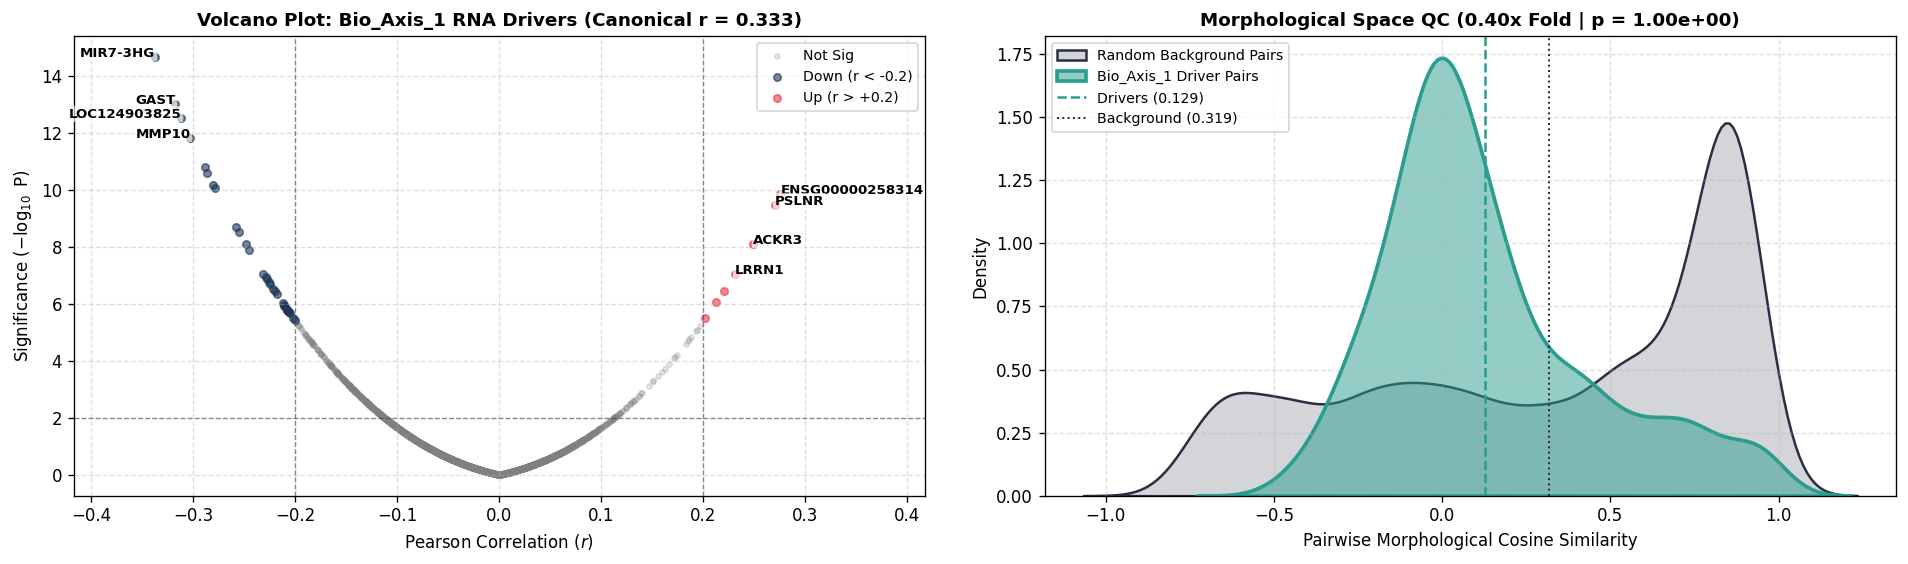


🎯 Bio_Axis_2 | Canonical Correlation ($r$): 0.3260 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : LOC124903825 (+0.21), PARP16 (+0.20), STK32A (+0.19), GAST (+0.19), MIR7-3HG (+0.19)
  ↳ Key Downregulated : PLAC8 (-0.21), RARRES2 (-0.20), IGFBP5 (-0.20), PSLNR (-0.19), ENSG00000258314 (-0.19)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • PI3K/AKT/mTOR  Signaling                         | NES: +1.53 | FDR: 7.01e-01
     • Notch Signaling                                  | NES: +1.51 | FDR: 4.33e-01
     • Mitotic Spindle                                  | NES: +1.44 | FDR: 4.10e-01
     • Androgen Response                                | NES: +1.38 | FDR: 4.42e-01
     • mTORC1 Signaling                                 | NES: +1.35 | FDR: 4.49e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TGF-beta Signaling                               | NES: -1.56 | FDR: 3.67e-01
     • KRAS Signaling Up                              

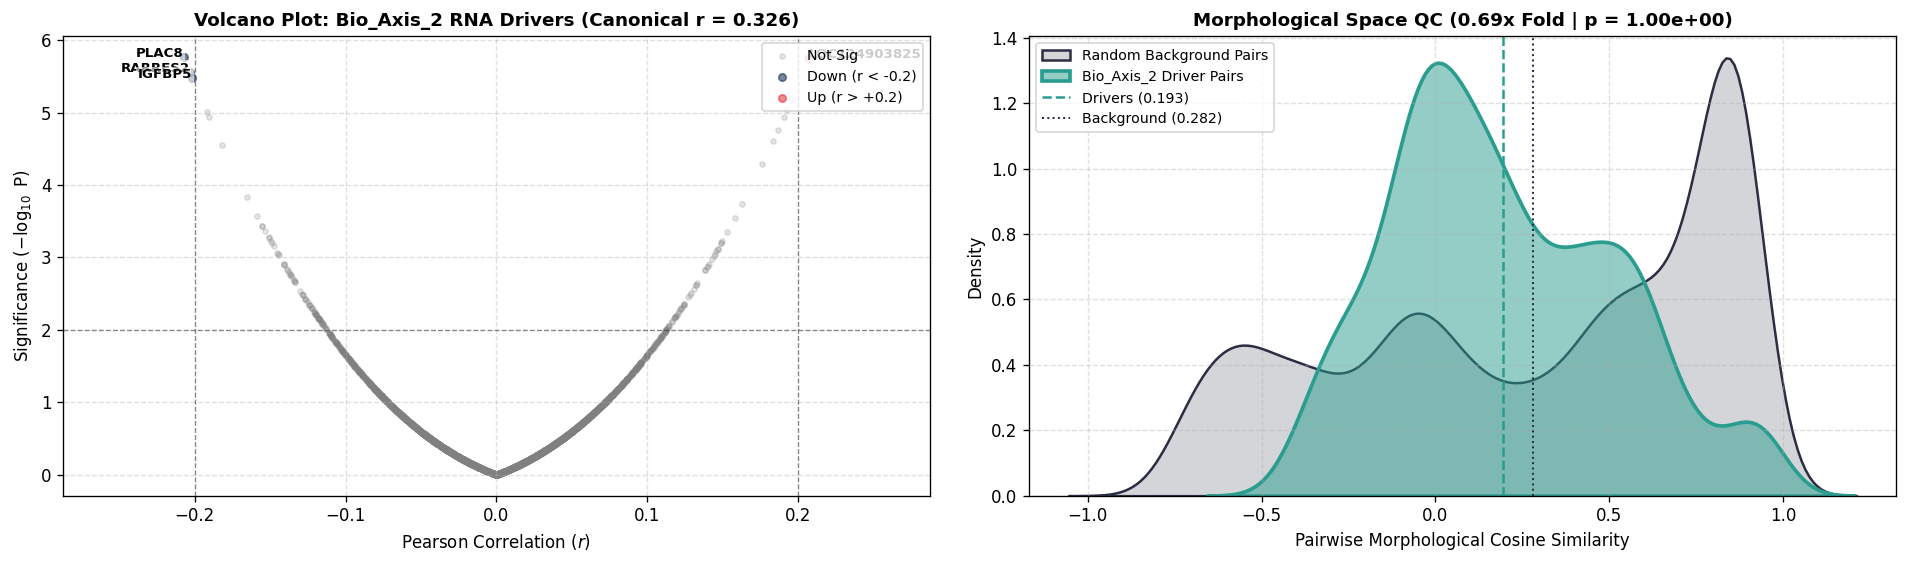


🎯 Bio_Axis_3 | Canonical Correlation ($r$): 0.3072 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : BMP2K-DT (+0.18), ENSG00000287190 (+0.17), CPD (+0.17), VPS13B-DT (+0.16), MEX3B (+0.16)
  ↳ Key Downregulated : DYNLT4 (-0.19), CRCT1 (-0.18), GARRE1 (-0.17), BMAL1 (-0.17), PPP3CC (-0.17)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Epithelial Mesenchymal Transition                | NES: +1.73 | FDR: 1.90e-01
     • Oxidative Phosphorylation                        | NES: +1.72 | FDR: 9.51e-02
     • Estrogen Response Late                           | NES: +1.62 | FDR: 1.09e-01
     • UV Response Up                                   | NES: +1.53 | FDR: 1.53e-01
     • Apoptosis                                        | NES: +1.47 | FDR: 1.59e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • KRAS Signaling Dn                                | NES: -1.55 | FDR: 5.04e-01
     • Notch Signaling                                  | NE

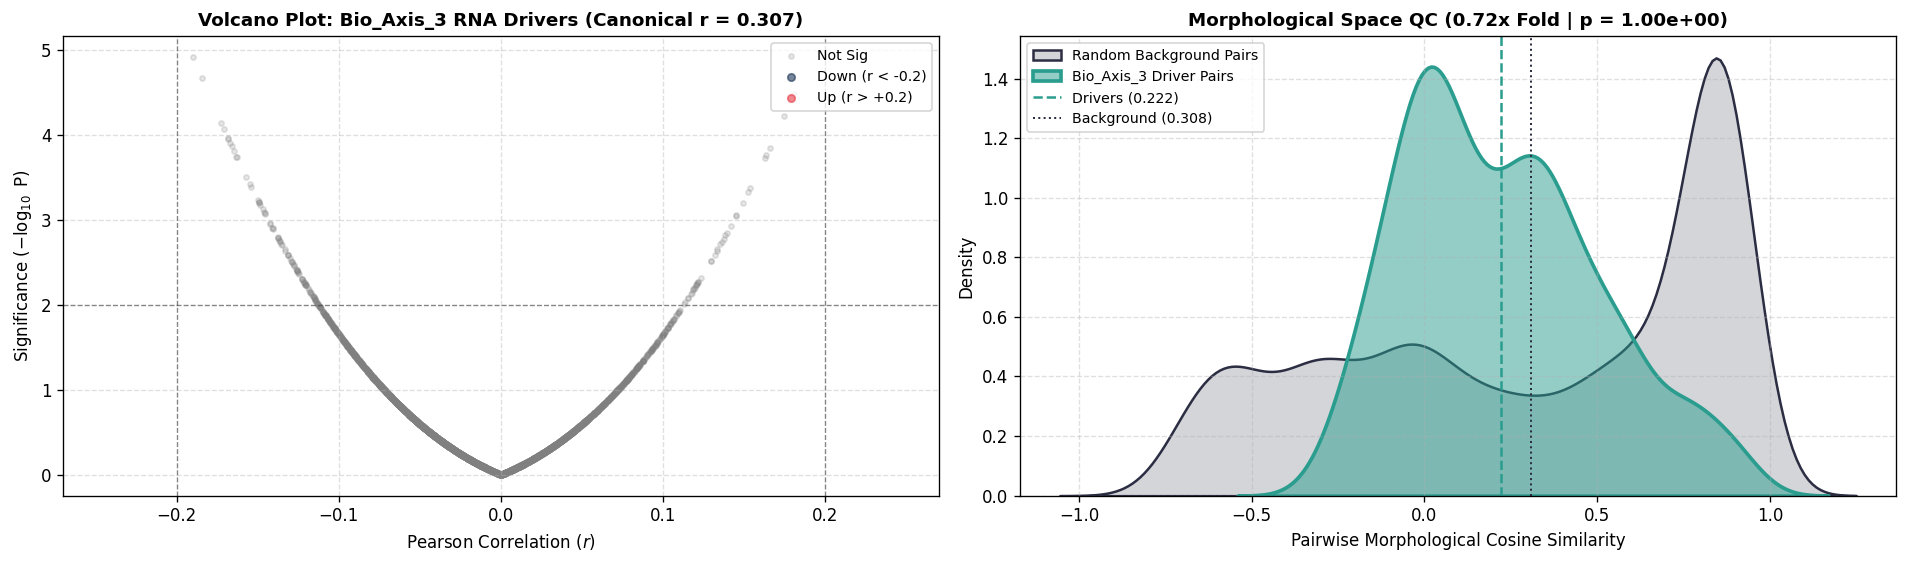

2026-09-27 23:00:08,808 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



🎯 Bio_Axis_4 | Canonical Correlation ($r$): 0.2985 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : LINC00520 (+0.18), ESM1 (+0.17), RAD50 (+0.17), SLAMF7 (+0.16), ENSG00000272079 (+0.16)
  ↳ Key Downregulated : LINC01511 (-0.20), ENSG00000286393 (-0.20), RAB26 (-0.17), RBBP9 (-0.17), MAGI2 (-0.16)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Epithelial Mesenchymal Transition                | NES: +1.55 | FDR: 5.41e-01
     • KRAS Signaling Dn                                | NES: +1.52 | FDR: 3.29e-01
     • Coagulation                                      | NES: +1.51 | FDR: 2.48e-01
     • Interferon Alpha Response                        | NES: +1.43 | FDR: 3.05e-01
     • TGF-beta Signaling                               | NES: +1.42 | FDR: 2.51e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • UV Response Dn                                   | NES: -1.58 | FDR: 5.16e-01
     • PI3K/AKT/mTOR  Signaling                   

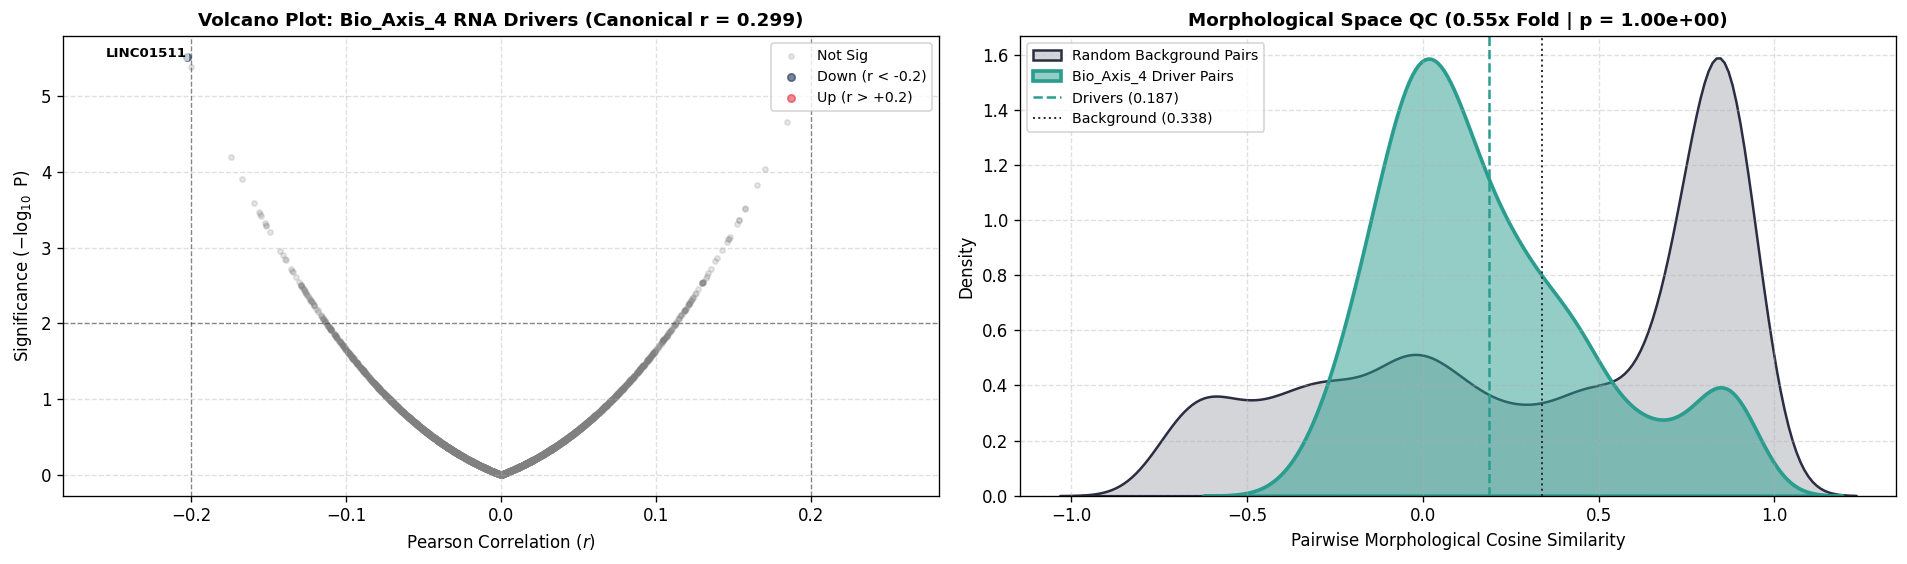


🎯 Bio_Axis_5 | Canonical Correlation ($r$): 0.2920 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ZNF438 (+0.17), GTPBP10 (+0.17), NHIP (+0.13), UFSP2 (+0.13), DTWD1 (+0.13)
  ↳ Key Downregulated : CXCL3 (-0.21), C11orf96 (-0.20), RN7SKP187 (-0.19), MT-TC (-0.18), EFNB1 (-0.17)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • UV Response Dn                                   | NES: +1.49 | FDR: 4.67e-01
     • E2F Targets                                      | NES: +1.44 | FDR: 3.23e-01
     • Spermatogenesis                                  | NES: +1.43 | FDR: 2.25e-01
     • Mitotic Spindle                                  | NES: +1.43 | FDR: 1.70e-01
     • Protein Secretion                                | NES: +1.40 | FDR: 1.58e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.39 | FDR: 0.00e+00
     • UV Response Up                                   | NES: -1.97 

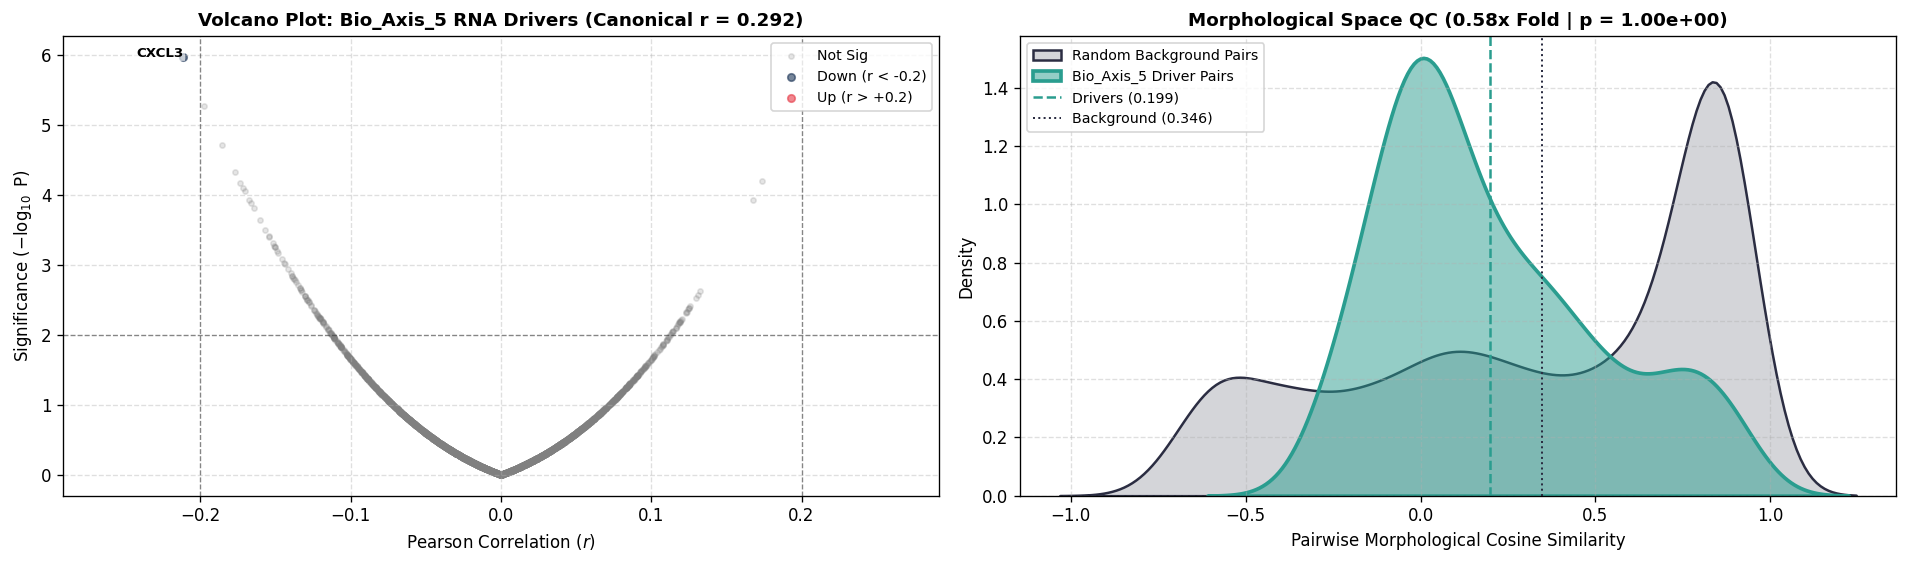


🎯 Bio_Axis_6 | Canonical Correlation ($r$): 0.2874 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : FOXS1 (+0.14), SIRT5 (+0.14), STRA6 (+0.14), YAP1-DT (+0.13), TLX2 (+0.13)
  ↳ Key Downregulated : BZW1P2 (-0.20), GDF15 (-0.19), ZBTB21 (-0.18), AREG (-0.18), FAT3 (-0.17)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Myogenesis                                       | NES: +1.36 | FDR: 2.14e-01
     • E2F Targets                                      | NES: +0.95 | FDR: 8.11e-01
     • Bile Acid Metabolism                             | NES: +0.69 | FDR: 9.34e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.02 | FDR: 0.00e+00
     • Epithelial Mesenchymal Transition                | NES: -1.83 | FDR: 8.35e-03
     • Apoptosis                                        | NES: -1.70 | FDR: 3.71e-02
     • p53 Pathway                                      | NES: -1.70 | FDR: 3

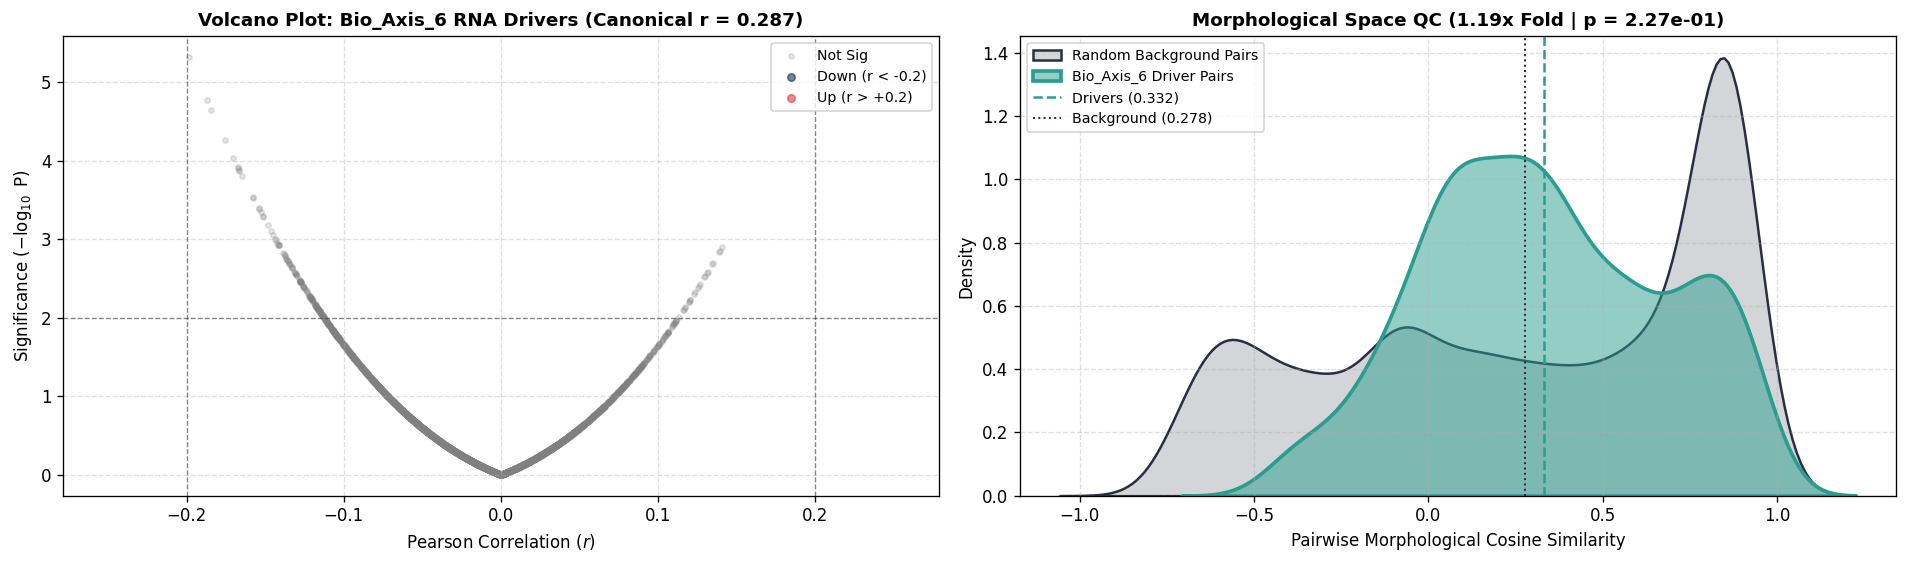

2026-09-27 23:00:57,136 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



🎯 Bio_Axis_7 | Canonical Correlation ($r$): 0.2784 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : IGFL2-AS1 (+0.23), CEBPD (+0.22), HTR3A (+0.20), GPNMB (+0.20), ZNF114 (+0.19)
  ↳ Key Downregulated : RPL9P21 (-0.30), CMYA5 (-0.26), RPL9P7 (-0.23), NMRAL2P (-0.21), TMEM119 (-0.21)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Unfolded Protein Response                        | NES: +1.77 | FDR: 1.30e-01
     • Notch Signaling                                  | NES: +1.37 | FDR: 1.00e+00
     • Cholesterol Homeostasis                          | NES: +1.31 | FDR: 1.00e+00
     • KRAS Signaling Dn                                | NES: +1.27 | FDR: 1.00e+00
     • Wnt-beta Catenin Signaling                       | NES: +1.26 | FDR: 8.63e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Epithelial Mesenchymal Transition                | NES: -1.58 | FDR: 3.59e-01
     • Allograft Rejection                              | NES: -1.

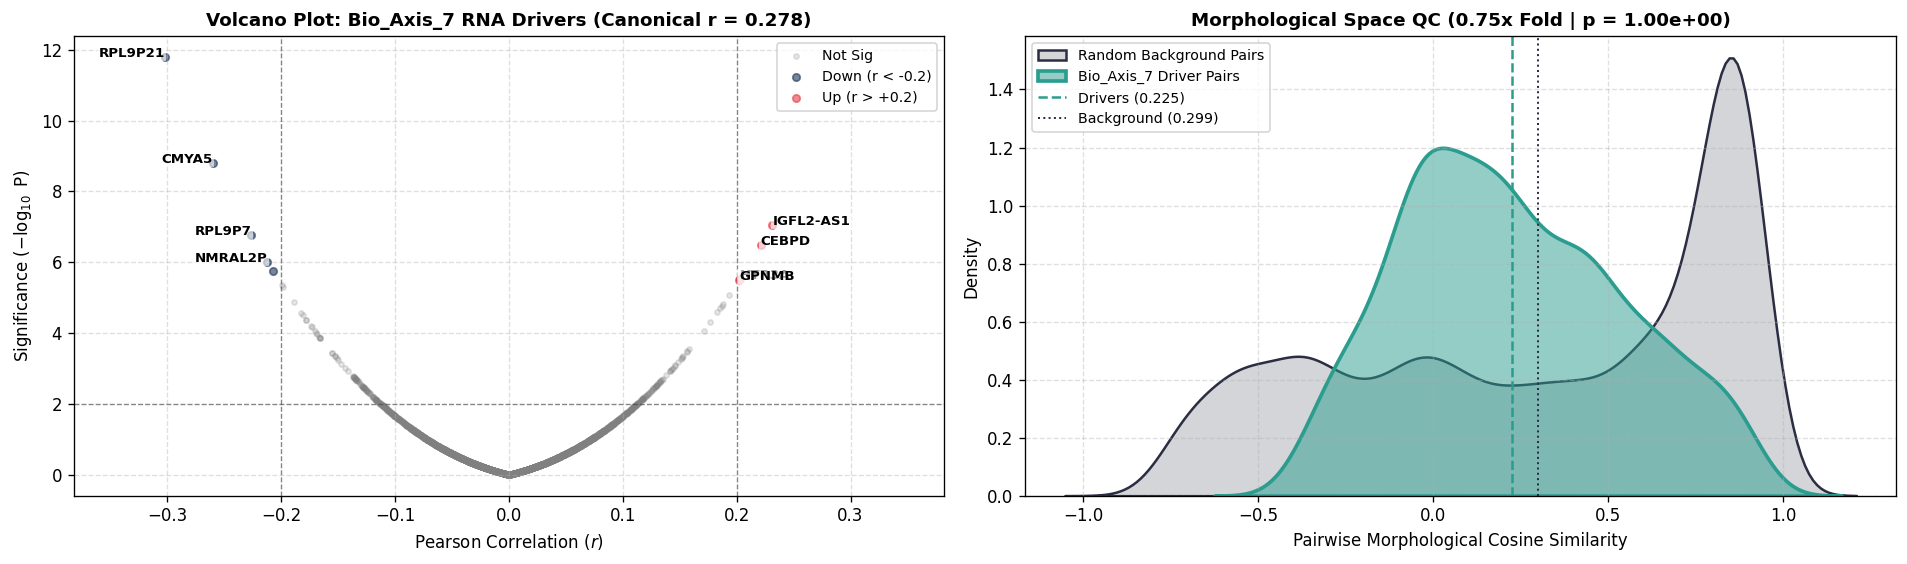


🎯 Bio_Axis_8 | Canonical Correlation ($r$): 0.2591 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : IGFL2-AS1 (+0.35), ZNF114 (+0.21), CYS1 (+0.19), NMRAL2P (+0.17), CALCOCO1 (+0.17)
  ↳ Key Downregulated : ENSG00000251867 (-0.20), KRT75 (-0.18), SUGT1P2 (-0.17), HK2 (-0.16), UNCX (-0.16)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Coagulation                                      | NES: +1.26 | FDR: 1.00e+00
     • Androgen Response                                | NES: +1.22 | FDR: 1.00e+00
     • IL-2/STAT5 Signaling                             | NES: +1.11 | FDR: 1.00e+00
     • Bile Acid Metabolism                             | NES: +1.10 | FDR: 1.00e+00
     • UV Response Dn                                   | NES: +1.08 | FDR: 1.00e+00

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Unfolded Protein Response                        | NES: -1.77 | FDR: 4.57e-02
     • E2F Targets                                      | NE

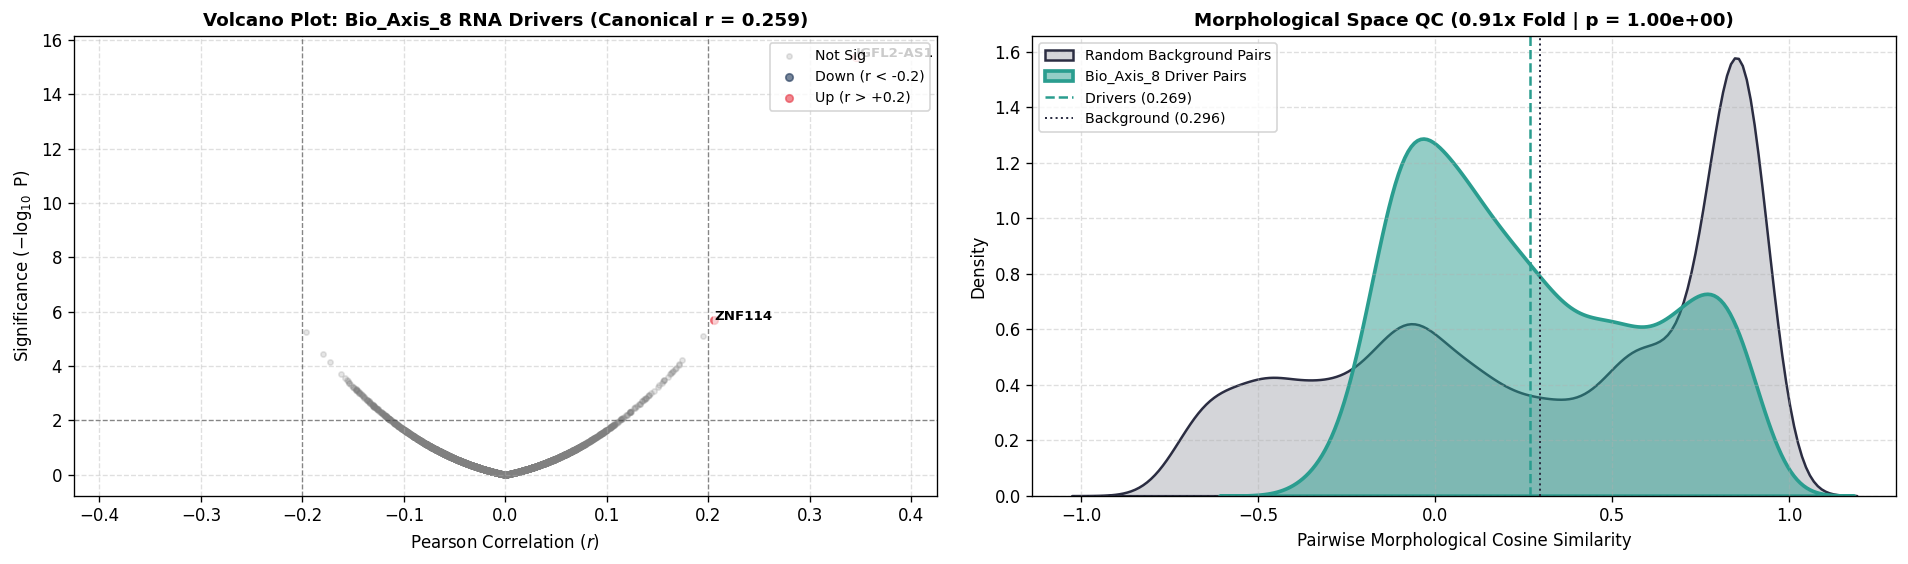


🎯 Bio_Axis_9 | Canonical Correlation ($r$): 0.2566 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : LOC101928994 (+0.20), ZNF559-ZNF177 (+0.20), HSPA1B (+0.19), HBA2 (+0.17), JARID2-DT (+0.17)
  ↳ Key Downregulated : NT5DC4 (-0.22), CMYA5 (-0.19), RPL9P21 (-0.18), GDPD3 (-0.18), CPLX1 (-0.18)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Oxidative Phosphorylation                        | NES: +1.47 | FDR: 1.00e+00
     • Estrogen Response Late                           | NES: +1.43 | FDR: 9.40e-01
     • TNF-alpha Signaling via NF-kB                    | NES: +1.39 | FDR: 7.99e-01
     • Apical Junction                                  | NES: +1.39 | FDR: 6.14e-01
     • Myogenesis                                       | NES: +1.38 | FDR: 5.33e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • Bile Acid Metabolism                             | NES: -1.56 | FDR: 2.99e-01
     • IL-2/STAT5 Signaling                             

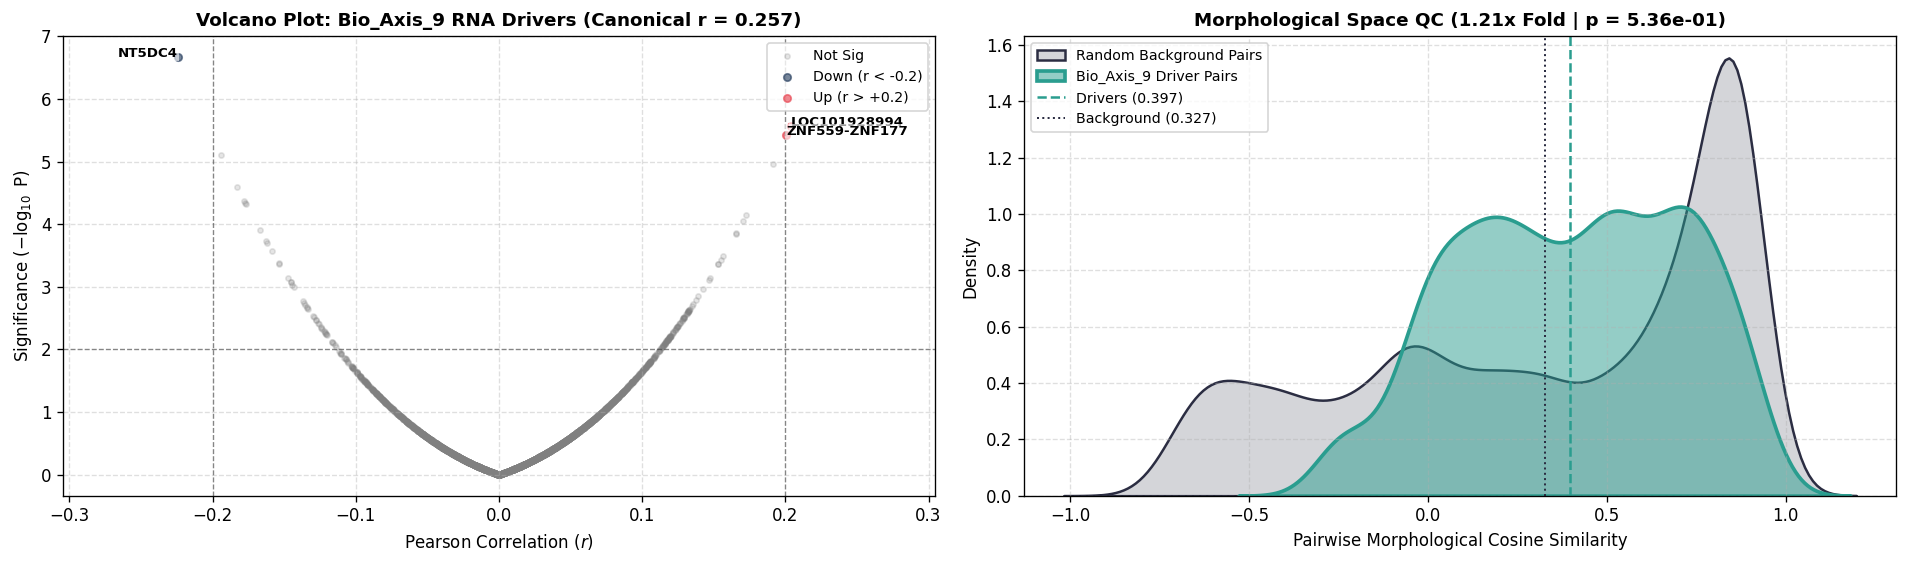


🎯 Bio_Axis_10 | Canonical Correlation ($r$): 0.2489 | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : BIRC7 (+0.25), FOXS1 (+0.21), LINC02901 (+0.21), LDLRAD4 (+0.20), CGB8 (+0.19)
  ↳ Key Downregulated : KANK4 (-0.28), CXCL8 (-0.22), EPAS1 (-0.21), REL (-0.21), NR4A3 (-0.21)

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: +1.39 | FDR: 6.06e-01
     • Notch Signaling                                  | NES: +1.37 | FDR: 3.39e-01
     • DNA Repair                                       | NES: +1.24 | FDR: 4.01e-01
     • Myogenesis                                       | NES: +1.19 | FDR: 4.00e-01
     • KRAS Signaling Dn                                | NES: +1.01 | FDR: 7.10e-01

  🔴 Top Negatively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: -2.34 | FDR: 0.00e+00
     • Apoptosis                                        | NES: -2.19 | FDR

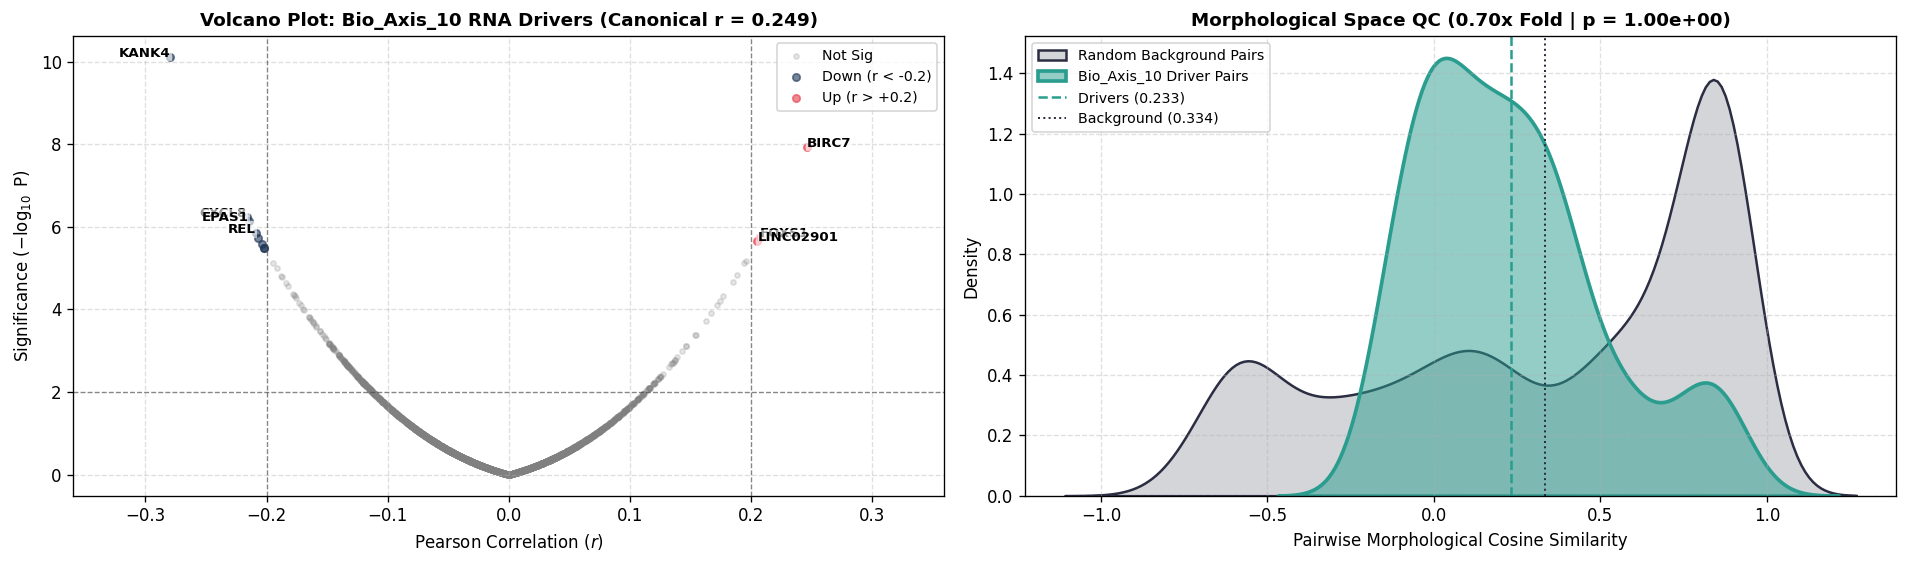


🏁 FULL MULTIMODAL DECODING & MORPHOLOGY QC SWEEP COMPLETE


In [ ]:
# Interepreting the axes, implementing Varimax rotation during projection
# ==============================================================================
# 🧬 COMPREHENSIVE MULTIMODAL LATENT DECODER & MORPHOLOGY QC CELL
# ==============================================================================
import os
import gc
import re
import sys
import time
import shutil
import tempfile
import ctypes
import warnings
import requests
import subprocess
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from scipy.stats import mannwhitneyu, t as t_dist

# Auto-install RDKit & Bioinformatics libraries if missing
for pkg in ['rdkit', 'mygene', 'gseapy']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
import mygene
import gseapy as gp

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

# Instantiate Morgan Fingerprint Generator (ECFP4: radius=2, 2048 bits)
MORGAN_GEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE ACCELERATION
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Acceleration Engine: {device}")

def trim_memory():
    """Forces Linux kernel arena reclamation and flushes GPU cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

def log_debug(msg, t_start=None):
    ram_gb = psutil.virtual_memory().used / 1e9
    ram_pct = psutil.virtual_memory().percent
    elapsed = f"[+{time.time() - t_start:5.1f}s] " if t_start else ""
    print(f"⏱️ {elapsed}🧠 RAM: {ram_gb:4.1f}GB ({ram_pct:2.0f}%) | {msg}")

# ==============================================================================
# 🧪 1. CURATED SMILES RESOLUTION & ECFP4 TANIMOTO CALCULATOR
# ==============================================================================
ROMAN_SMILES_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/annotations_from_Roman/JUMP_CP_compound_metadata_with_SMILES_standard.csv"
LOCAL_SMILES_LOOKUP = "jump_smiles_standard_lookup.parquet"

def ensure_curated_smiles_lookup():
    if os.path.exists(LOCAL_SMILES_LOOKUP):
        return
    raw_csv = "temp_jump_smiles.csv"
    print("📥 Pre-caching Roman's standardized JUMP-CP SMILES metadata...")
    subprocess.run(["gcloud", "storage", "cp", ROMAN_SMILES_URI, raw_csv], check=True)

    con = duckdb.connect()
    cols = [c[0] for c in con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{raw_csv}') LIMIT 1").fetchall()]
    ikey_col = next((c for c in cols if 'inchikey' in c.lower()), None)
    smi_col = next((c for c in cols if 'smiles' in c.lower()), None)

    if not ikey_col or not smi_col:
        con.close()
        raise ValueError(f"Could not locate InChIKey or SMILES in CSV columns: {cols}")

    con.execute(f"""
        COPY (
            SELECT DISTINCT {ikey_col} AS InChIKey, {smi_col} AS SMILES
            FROM read_csv_auto('{raw_csv}')
            WHERE {ikey_col} IS NOT NULL AND {smi_col} IS NOT NULL AND {smi_col} != ''
        ) TO '{LOCAL_SMILES_LOOKUP}' (FORMAT PARQUET, COMPRESSION 'SNAPPY');
    """)
    con.close()
    if os.path.exists(raw_csv):
        os.remove(raw_csv)
    print("✅ Curated SMILES lookup Parquet ready.")

ensure_curated_smiles_lookup()

def compute_driver_tanimoto(inchikey_list):
    con = duckdb.connect()
    keys_df = pd.DataFrame({"InChIKey": list(set(inchikey_list))})
    con.register("keys_df", keys_df)
    res = con.execute(f"""
        SELECT InChIKey, SMILES FROM read_parquet('{LOCAL_SMILES_LOOKUP}')
        WHERE InChIKey IN (SELECT InChIKey FROM keys_df)
    """).df()
    con.close()

    smiles_map = dict(zip(res['InChIKey'], res['SMILES']))
    fps = []
    valid_count = 0

    for ikey in inchikey_list:
        smi = smiles_map.get(ikey)
        if smi:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                fps.append(MORGAN_GEN.GetFingerprint(mol))
                valid_count += 1

    n = len(fps)
    if n < 2:
        return 0.0, 0.0, 0.0, valid_count

    similarities = [DataStructs.TanimotoSimilarity(fps[i], fps[j]) for i in range(n) for j in range(i + 1, n)]
    return np.mean(similarities), np.median(similarities), np.max(similarities), valid_count

# ==============================================================================
# ⚡ 2. SELF-CONTAINED NUMPY POOLING & LINEAR ALGEBRA CORE
# ==============================================================================
def numpy_median_pool(keys, features):
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]
    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        mask = (inverse_idx == i)
        aggregated[i] = features[mask][0] if np.count_nonzero(mask) == 1 else np.median(features[mask], axis=0)
    return unique_keys, aggregated

def numpy_max_abs_pool(keys, features):
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]
    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        sub_feats = features[inverse_idx == i]
        if len(sub_feats) == 1:
            aggregated[i] = sub_feats[0]
        else:
            max_idx = np.argmax(np.abs(sub_feats), axis=0)
            aggregated[i] = sub_feats[max_idx, np.arange(dim)]
    return unique_keys, aggregated

def svd_flip_torch(u, v=None):
    max_abs_cols = torch.argmax(torch.abs(u), dim=0)
    signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
    signs[signs == 0] = 1.0
    u = u * signs
    if v is not None:
        k_shared = min(u.shape[1], v.shape[0])
        v[:k_shared] = v[:k_shared] * signs[:k_shared].unsqueeze(1)
        return u, v
    return u

def get_exact_subspace_basis(M, k=50):
    N_samples, D_features = M.shape
    q_target = min(k, N_samples - 1, D_features)
    if q_target <= 0:
        return torch.zeros((N_samples, 1), device=M.device, dtype=M.dtype)
    U, S, V = torch.pca_lowrank(M, q=q_target, center=False, niter=3)
    return svd_flip_torch(U[:, :q_target])

def reduce_dimensions_configurable(X_np, mode="none", var_threshold=0.90, fixed_dims=384):
    if mode == "none":
        return X_np.astype(np.float32)
    N_samples, D_features = X_np.shape
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    X_c = X - X.mean(dim=0)
    target_q = min(fixed_dims if mode == "fixed" else min(D_features, 512), N_samples - 1, D_features)
    U, S, V = torch.pca_lowrank(X_c, q=target_q, center=False, niter=3)
    U = svd_flip_torch(U)
    if mode == "variance":
        cum_variance = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
        k = int(torch.argmax((cum_variance >= var_threshold).to(torch.int64)).item()) + 1
        k = min(k, int(N_samples * 0.8), target_q)
    elif mode == "fixed":
        k = min(fixed_dims, target_q, int(N_samples * 0.8))
    else:
        k = min(target_q, int(N_samples * 0.8))
    res = (U[:, :k] * S[:k]).cpu().numpy().astype(np.float32)
    del X, X_c, U, S, V
    return res

# ==============================================================================
# 🔑 3. COLUMN RESOLUTION & PLATEMAP BRIDGE HELPERS
# ==============================================================================
LOOKUP_PLATEMAP_FILE = "jump_platemap_lookup.parquet"
LOOKUP_JCP_FILE = "jump_jcp_lookup.parquet"

def resolve_key_column(columns):
    priority = ['InChIKey', 'inchikey', 'Metadata_InChIKey']
    for candidate in priority:
        if candidate in columns:
            return candidate
    for c in columns:
        if 'inchikey' in c.lower():
            return c
    return None

def inspect_morphology_columns(schema_cols):
    direct_key = resolve_key_column(schema_cols)
    if direct_key:
        return 'inchikey', direct_key
    plate = next((c for c in schema_cols if c.lower() in ['metadata_plate', 'plate']), None)
    well = next((c for c in schema_cols if c.lower() in ['metadata_well', 'well']), None)
    if plate and well:
        return 'plate_well', (plate, well)
    jcp = next((c for c in schema_cols if 'jcp2022' in c.lower()), None)
    if jcp:
        return 'jcp', jcp
    return 'unknown', None

def standardize_inchikey_column(df, target_col="InChIKey"):
    key_col = resolve_key_column(df.columns)
    if not key_col:
        raise ValueError(f"No InChIKey found in DataFrame! Available: {list(df.columns)[:10]}")
    redundant = [c for c in df.columns if 'inchikey' in c.lower() and c != key_col and c != target_col]
    if redundant:
        df = df.drop(columns=redundant)
    if key_col != target_col:
        if target_col in df.columns:
            df = df.drop(columns=[key_col])
        else:
            df = df.rename(columns={key_col: target_col})
    return df

def load_dynamic_overlap_pair(morph_path: str, rna_path: str, target_keys_subset: set = None):
    fresh_dir = tempfile.mkdtemp(prefix="duckdb_load_")
    con = duckdb.connect()
    con.execute(f"PRAGMA temp_directory='{fresh_dir}';")
    con.execute("SET memory_limit = '3GB';")
    con.execute("SET threads = 2;")
    con.execute("SET preserve_insertion_order = false;")

    morph_schema = [f.name for f in pq.read_schema(morph_path)]
    rna_schema = [f.name for f in pq.read_schema(rna_path)]

    morph_id_type, morph_cols = inspect_morphology_columns(morph_schema)
    rna_key = resolve_key_column(rna_schema)

    if morph_id_type == 'unknown' or not rna_key:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError(f"Identifier missing! Morph Type: {morph_id_type} | RNA Key: {rna_key}")

    has_pert_type = 'Metadata_pert_type' in morph_schema
    pert_clause = "AND Metadata_pert_type = 'trt'" if has_pert_type else ""
    time_col = next((c for c in rna_schema if 'pert_time' in c.lower()), None)
    time_clause = f"AND TRY_CAST({time_col} AS FLOAT) IN (24, 48)" if time_col else ""

    if target_keys_subset is not None:
        shared_keys_df = pd.DataFrame({"ikey": sorted(list(target_keys_subset))})
    else:
        if morph_id_type == 'inchikey':
            morph_keys_sql = f"SELECT DISTINCT {morph_cols} AS ikey FROM read_parquet('{morph_path}') WHERE {morph_cols} IS NOT NULL AND {morph_cols} != 'IAZDPXIOMUYVGZ-UHFFFAOYSA-N' {pert_clause}"
        elif morph_id_type == 'plate_well':
            p_col, w_col = morph_cols
            morph_keys_sql = f"SELECT DISTINCT pw.InChIKey AS ikey FROM (SELECT DISTINCT {p_col}, {w_col} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well"
        elif morph_id_type == 'jcp':
            morph_keys_sql = f"SELECT DISTINCT j.InChIKey AS ikey FROM (SELECT DISTINCT {morph_cols} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j ON m.{morph_cols} = j.Metadata_JCP2022"

        key_intersect_query = f"""
            WITH morph_keys AS ({morph_keys_sql}),
            rna_keys AS (SELECT DISTINCT {rna_key} AS ikey FROM read_parquet('{rna_path}') WHERE {rna_key} IS NOT NULL AND {rna_key} != 'IAZDPXIOMUYVGZ-UHFFFAOYSA-N' {time_clause})
            SELECT ikey FROM morph_keys INTERSECT SELECT ikey FROM rna_keys ORDER BY ikey ASC
        """
        shared_keys_df = con.execute(key_intersect_query).df()

    if len(shared_keys_df) == 0:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError("Zero overlapping compounds found between datasets!")

    con.register("shared_keys_view", shared_keys_df)

    if morph_id_type == 'inchikey':
        morph_df = con.execute(f"SELECT * FROM read_parquet('{morph_path}') WHERE {morph_cols} IN (SELECT ikey FROM shared_keys_view) {pert_clause}").df()
        morph_df = standardize_inchikey_column(morph_df, target_col="InChIKey")
    elif morph_id_type == 'plate_well':
        p_col, w_col = morph_cols
        morph_df = con.execute(f"SELECT m.*, pw.InChIKey AS InChIKey FROM read_parquet('{morph_path}') m INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well WHERE pw.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}").df()
    elif morph_id_type == 'jcp':
        morph_df = con.execute(f"SELECT m.*, j.InChIKey AS InChIKey FROM read_parquet('{morph_path}') m INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j ON m.{morph_cols} = j.Metadata_JCP2022 WHERE j.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}").df()

    exclude_morph = ["InChIKey", 'pubchem_cid', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022', 'concentration', 'dose', 'time', 'timepoint', 'plate', 'well']
    morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns if not c.startswith("Metadata_") and c not in exclude_morph]

    m_keys = morph_df["InChIKey"].to_numpy()
    m_feats = morph_df[morph_features].to_numpy(dtype=np.float32)
    del morph_df
    trim_memory()

    morph_u_keys, morph_agg = numpy_median_pool(m_keys, m_feats)
    del m_keys, m_feats

    rna_df = con.execute(f"SELECT * FROM read_parquet('{rna_path}') WHERE {rna_key} IN (SELECT ikey FROM shared_keys_view) {time_clause}").df()
    con.close()
    shutil.rmtree(fresh_dir, ignore_errors=True)

    rna_df = standardize_inchikey_column(rna_df, target_col="InChIKey")
    exclude_rna = ["InChIKey", 'pubchem_cid', 'pert_time_h', 'pert_dose_uM', 'Metadata_Plate', 'Metadata_Well']
    rna_features = [c for c in rna_df.select_dtypes(include=[np.number]).columns if not c.startswith("Metadata_") and c not in exclude_rna]

    r_keys = rna_df["InChIKey"].to_numpy()
    r_feats = rna_df[rna_features].to_numpy(dtype=np.float32)
    del rna_df
    trim_memory()

    rna_u_keys, rna_agg = (r_keys, r_feats) if len(np.unique(r_keys)) == len(r_keys) else numpy_max_abs_pool(r_keys, r_feats)
    del r_keys, r_feats

    common_eval_keys = np.intersect1d(morph_u_keys, rna_u_keys)
    m_mask = np.isin(morph_u_keys, common_eval_keys)
    r_mask = np.isin(rna_u_keys, common_eval_keys)

    X_morph = np.nan_to_num(morph_agg[m_mask])
    Y_rna = np.nan_to_num(rna_agg[r_mask])
    shared_inchikeys = morph_u_keys[m_mask]

    del morph_agg, rna_agg
    trim_memory()
    return X_morph, Y_rna, shared_inchikeys

# ==============================================================================
# 🌐 4. 3-TIER ANNOTATION ENGINE (PubChem + ChEMBL Block-1 Rescue)
# ==============================================================================
ANNOTATION_CACHE = {}

def get_rich_compound_annotation(inchikey):
    if inchikey in ANNOTATION_CACHE:
        return ANNOTATION_CACHE[inchikey]

    name = "Unknown"
    moa = "Unannotated"

    try:
        url_syn = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/synonyms/JSON"
        r = requests.get(url_syn, timeout=4)
        if r.status_code == 200:
            info = r.json().get('InformationList', {}).get('Information', [{}])[0]
            synonyms = info.get('Synonym', [])
            for s in synonyms[:15]:
                if not re.match(r'^\d+-\d+-\d+$', s) and len(s) > 2 and not any(s.startswith(p) for p in ['SCHEMBL', 'CHEMBL', 'AKOS', 'CS-', 'EN300']):
                    name = s
                    break
    except Exception:
        pass

    chembl_id = None
    try:
        url_chembl = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key={inchikey}"
        r = requests.get(url_chembl, timeout=4)
        mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if not mols and len(inchikey) >= 14:
            b1 = inchikey[:14]
            url_b1 = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key__startswith={b1}"
            r = requests.get(url_b1, timeout=4)
            mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if mols:
            mol = mols[0]
            chembl_id = mol.get('molecule_chembl_id')
            if name == "Unknown" and mol.get('pref_name'):
                name = mol.get('pref_name')

            url_mech = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
            r_m = requests.get(url_mech, timeout=4)
            if r_m.status_code == 200:
                mechs = r_m.json().get('mechanisms', [])
                if mechs:
                    moa = mechs[0].get('mechanism_of_action')

            if moa == "Unannotated" and chembl_id:
                url_act = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?molecule_chembl_id={chembl_id}&standard_type=IC50&standard_value__lte=500&limit=1"
                r_a = requests.get(url_act, timeout=4)
                if r_a.status_code == 200:
                    acts = r_a.json().get('activities', [])
                    if acts and acts[0].get('target_pref_name'):
                        moa = f"{acts[0].get('target_pref_name')} inhibitor (IC50 < 500nM)"
    except Exception:
        pass

    ANNOTATION_CACHE[inchikey] = (name, moa)
    return name, moa

# ==============================================================================
# ⚙️ 5. CONFIGURATION & CELL 1 RESTORATION
# ==============================================================================
MERGE_KEY = "InChIKey"
DMSO_INCHIKEY = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N"
NUM_AXES_TO_ANALYZE = 10

CHEMCHECKER_URI = "gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/JUMP_CP_Global_Signatures_full.parquet"
LOCAL_CC_CACHE = "cached_chemchecker_embeddings.parquet"
RAW_GENES_URI = "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet"
LOCAL_RAW_GENES_CACHE = "cached_drugseq_raw_genes.parquet"

if 'leaderboard_df' not in globals() or leaderboard_df.empty:
    raise RuntimeError("leaderboard_df not found! Please run Cell 1 benchmark first.")

top_model_name = leaderboard_df.iloc[0]["Model / Processing"]
score_col = "SVCCA Adj. AUC" if "SVCCA Adj. AUC" in leaderboard_df.columns else leaderboard_df.columns[4]
top_score = leaderboard_df.iloc[0][score_col]
sig_axes_known = int(leaderboard_df.iloc[0].get("Significant Axes", NUM_AXES_TO_ANALYZE))

active_rna_cache = globals().get('LOCAL_RNA_CACHE', 'cached_cpb_latent_anchor.parquet')
active_rna_source = globals().get('TRANSCRIPTOMIC_SOURCE', 'Active Anchor')

print("=" * 95)
print(f"🏆 DECODING WINNING MODEL: [{top_model_name}]")
print(f"📊 Benchmark Score ({score_col}): {top_score:+.4f} | Statistically Verified Dimensions: {sig_axes_known}")
print(f"🧬 Transcriptomic Alignment Anchor: {active_rna_source} ({active_rna_cache})")
print(f"🔬 Bioactivity Reference: Chemical Checker 3,200D Embeddings")
print(f"🎯 Decoding Horizon: Top {NUM_AXES_TO_ANALYZE} Biological Dimensions")
print("=" * 95)

winner_clean_tag = top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '').replace('/', '_').replace('-', '_').replace(',', '')
winner_cache = globals().get('cached_filepaths', {}).get(top_model_name, f"cached_{winner_clean_tag}.parquet")

if not os.path.exists(winner_cache):
    raise FileNotFoundError(f"Winner cache file not found: {winner_cache}")

# ==============================================================================
# ⚡ 6. RE-ESTABLISH PROJECTION ON WINNER & PRESERVE CENTERED MORPHOLOGY
# ==============================================================================
target_keys = globals().get('common_keys_set', None)

X_morph, Y_rna, active_inchikeys = load_dynamic_overlap_pair(
    morph_path=winner_cache,
    rna_path=active_rna_cache,
    target_keys_subset=target_keys
)

# 🛡️ FIX: MEAN-CENTER BEFORE NORMALIZATION TO REMOVE ANISOTROPIC CONE BIAS
morph_tensor_raw = torch.tensor(X_morph, device=device, dtype=torch.float32)
# Subtract the global population centroid
morph_centered = morph_tensor_raw - morph_tensor_raw.mean(dim=0, keepdim=True)
# L2-normalize centered vectors (mathematically equivalent to Pearson correlation)
X_morph_normed_lookup = F.normalize(morph_centered, p=2, dim=1)
del morph_tensor_raw, morph_centered

# Build index dictionary for zero-cost compound indexing
morph_key_to_idx = {k: i for i, k in enumerate(active_inchikeys)}

pca_mode_active = globals().get('PCA_MODE', 'none')
pca_var_active = globals().get('PCA_VARIANCE_THRESHOLD', 0.90)
pca_dims_active = globals().get('PCA_FIXED_DIMS', 384)

X_morph_proc = reduce_dimensions_configurable(
    X_morph, mode=pca_mode_active,
    var_threshold=pca_var_active,
    fixed_dims=pca_dims_active
)

del X_morph
trim_memory()

N_samples = len(active_inchikeys)
k_decomp = min(50, int(N_samples * 0.8), X_morph_proc.shape[1], Y_rna.shape[1])

X_m = torch.tensor(X_morph_proc, device=device, dtype=torch.float32)
Y_r = torch.tensor(Y_rna, device=device, dtype=torch.float32)
del X_morph_proc, Y_rna

X_c = X_m - X_m.mean(dim=0)
Y_c = Y_r - Y_r.mean(dim=0)

Qa = get_exact_subspace_basis(X_c, k_decomp)
Qb = get_exact_subspace_basis(Y_c, k_decomp)
del X_m, Y_r, X_c, Y_c

cross_cov = torch.matmul(Qa.T, Qb)
U, S, Vt = torch.linalg.svd(cross_cov, full_matrices=False)
U = svd_flip_torch(U)

n_axes_actual = min(NUM_AXES_TO_ANALYZE, U.shape[1])
bio_canonical_scores = torch.matmul(Qa, U[:, :n_axes_actual]).cpu().numpy()
del Qa, Qb, cross_cov, U, Vt

# 🔄 APPLY VARIMAX ROTATION TO UNMIX PHENOTYPIC ENTANGLEMENT
print("🔄 Applying Varimax rotation to canonical subspace...")
bio_canonical_scores, R_rot = varimax_rotation(bio_canonical_scores)

axis_cols = [f'Bio_Axis_{i+1}' for i in range(n_axes_actual)]
bio_scores_df = pd.DataFrame(bio_canonical_scores, columns=axis_cols)
bio_scores_df[MERGE_KEY] = active_inchikeys
del bio_canonical_scores
trim_memory()

print(f"✅ Projection & Varimax Unmixing Complete: {N_samples:,} compounds projected onto {n_axes_actual} sparse biological axes.")

print(f"✅ Projection Complete: {N_samples:,} compounds projected onto {n_axes_actual} canonical axes.")

# ==============================================================================
# 📥 7. STREAM RAW GENE EXPRESSION & CHEMICAL CHECKER (DISK PUSHDOWN)
# ==============================================================================
con = duckdb.connect()
con.register("active_compounds_view", pd.DataFrame({MERGE_KEY: active_inchikeys}))

# 7A. Raw Genes for GSEA & Volcano Decoding
if not os.path.exists(LOCAL_RAW_GENES_CACHE):
    print("📥 Caching raw gene expression signatures from GCS...")
    cmd = ["gcloud", "storage", "cp", RAW_GENES_URI, LOCAL_RAW_GENES_CACHE]
    subprocess.run(cmd, check=True)

raw_schema = [f.name for f in pq.read_schema(LOCAL_RAW_GENES_CACHE)]
raw_key = resolve_key_column(raw_schema)

print(f"📂 Streaming raw gene expression from disk for {N_samples:,} compounds...")
raw_genes_df = con.execute(f"""
    SELECT * FROM read_parquet('{LOCAL_RAW_GENES_CACHE}')
    WHERE {raw_key} IN (SELECT {MERGE_KEY} FROM active_compounds_view)
""").df()

raw_genes_df = standardize_inchikey_column(raw_genes_df, target_col=MERGE_KEY)
all_ensembl_cols = [c for c in raw_genes_df.columns if c.startswith('ENSG')]
if not all_ensembl_cols:
    all_ensembl_cols = [c for c in raw_genes_df.select_dtypes(include=[np.number]).columns
                        if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]

r_keys = raw_genes_df[MERGE_KEY].to_numpy()
r_feats = raw_genes_df[all_ensembl_cols].to_numpy(dtype=np.float32)
del raw_genes_df
trim_memory()

u_r_keys, u_r_feats = numpy_max_abs_pool(r_keys, r_feats)
del r_keys, r_feats

drugseq_pooled_genes = pd.DataFrame(u_r_feats, columns=all_ensembl_cols)
drugseq_pooled_genes[MERGE_KEY] = u_r_keys
del u_r_feats

gene_variances = drugseq_pooled_genes[all_ensembl_cols].var(axis=0)
top_5000_genes = gene_variances.nlargest(min(5000, len(all_ensembl_cols))).index.tolist()
drugseq_pooled_genes = drugseq_pooled_genes[[MERGE_KEY] + top_5000_genes].copy()
active_ensembl_genes = top_5000_genes
print(f"  ↳ Retained Top {len(active_ensembl_genes):,} dynamic Ensembl genes for downstream decoding.")

# 7B. Chemical Checker Ingestion
if not os.path.exists(LOCAL_CC_CACHE):
    print("📥 Caching Chemical Checker embeddings from GCS...")
    cmd = ["gcloud", "storage", "cp", CHEMCHECKER_URI, LOCAL_CC_CACHE]
    subprocess.run(cmd, check=True)

cc_schema = [f.name for f in pq.read_schema(LOCAL_CC_CACHE)]
cc_key = resolve_key_column(cc_schema)

print(f"📂 Streaming Chemical Checker 3,200D embeddings for active cohort...")
cc_df = con.execute(f"""
    SELECT * FROM read_parquet('{LOCAL_CC_CACHE}')
    WHERE {cc_key} IN (SELECT {MERGE_KEY} FROM active_compounds_view)
""").df()
con.close()

cc_df = standardize_inchikey_column(cc_df, target_col=MERGE_KEY)
cc_features = [c for c in cc_df.select_dtypes(include=[np.number]).columns
               if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid']]

cc_matrix = np.nan_to_num(cc_df[cc_features].values.astype(np.float32), nan=0.0)
cc_df[cc_features] = cc_matrix

valid_mask = np.linalg.norm(cc_matrix, axis=1) > 1e-6
cc_df = cc_df[valid_mask].drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)
del cc_matrix
trim_memory()

print(f"✅ Chemical Checker subset loaded: {len(cc_df):,} compounds x {len(cc_features)} dimensions.")

# ==============================================================================
# 🧬 8. MAP OFFICIAL HGNC GENE SYMBOLS
# ==============================================================================
print(f"Querying MyGene for HGNC symbols across {len(active_ensembl_genes):,} Ensembl IDs...")
mg = mygene.MyGeneInfo()
clean_ensembl_ids = [g.split('.')[0] for g in active_ensembl_genes]
gene_info = mg.querymany(clean_ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False)

ensembl_to_symbol = {}
for h in gene_info:
    if 'query' in h and 'symbol' in h:
        ensembl_to_symbol[h['query']] = h['symbol']

print(f"✅ Successfully mapped {len(ensembl_to_symbol):,} of {len(active_ensembl_genes):,} Ensembl IDs.")

# ==============================================================================
# 🔍 9. UNIFIED MULTIMODAL AXIS DECODER WITH MORPHOLOGY QC (FOR ALL K AXES)
# ==============================================================================
merged_all = pd.merge(bio_scores_df, drugseq_pooled_genes, on=MERGE_KEY, how='inner')
merged_all = merged_all.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

if len(merged_all) == 0:
    raise RuntimeError("Zero overlap between projected compounds and raw gene expression data!")

clean_rna_matrix = np.nan_to_num(merged_all[active_ensembl_genes].values.astype(np.float32), nan=0.0)
all_genes_tensor = torch.tensor(clean_rna_matrix, device=device)
Y_c_genes = all_genes_tensor - all_genes_tensor.mean(dim=0)
var_Y_genes = torch.sum(Y_c_genes ** 2, dim=0)
del clean_rna_matrix, all_genes_tensor

for axis_idx in range(n_axes_actual):
    axis_name = f'Bio_Axis_{axis_idx+1}'
    canonical_corr = S[axis_idx].item()
    is_sig_tag = "✅ STATISTICALLY SIGNIFICANT (p < 0.05)" if (axis_idx + 1) <= sig_axes_known else "⚠️ NOISE FLOOR BOUNDARY"

    print("\n" + "=" * 95)
    print(f"🎯 {axis_name} | Canonical Correlation ($r$): {canonical_corr:.4f} | {is_sig_tag}")
    print("=" * 95)

    # -------------------------------------------------------------------------
    # PART A: TRANSCRIPTIONAL DECODING (T-Statistic Ranking + Hallmarks + ORA)
    # -------------------------------------------------------------------------
    axis_tensor = torch.tensor(merged_all[axis_name].values.astype(np.float32), device=device)
    X_c_axis = axis_tensor - axis_tensor.mean()
    var_X_axis = torch.sum(X_c_axis ** 2)

    cov = torch.matmul(X_c_axis, Y_c_genes)
    r_tensor = cov / torch.sqrt(var_X_axis * var_Y_genes + 1e-12)

    n_samples = len(merged_all)
    r_clipped = torch.clamp(r_tensor, -0.9999, 0.9999)
    t_stat = r_clipped * torch.sqrt((n_samples - 2) / (1.0 - r_clipped**2))

    r_vals = r_tensor.cpu().numpy()
    t_vals = t_stat.cpu().numpy()
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n_samples - 2)
    neg_log10_p = -np.log10(p_vals + 1e-300)

    symbols = [ensembl_to_symbol.get(g.split('.')[0], g) for g in active_ensembl_genes]
    gene_df = pd.DataFrame({
        'Ensembl_ID': active_ensembl_genes,
        'Gene_Symbol': symbols,
        'Correlation': r_vals,
        'T_Stat': t_vals,
        'P_Value': p_vals,
        'Neg_Log10_P': neg_log10_p
    })

    valid_genes = gene_df.dropna(subset=['Correlation']).copy()
    valid_genes = valid_genes[~valid_genes['Gene_Symbol'].str.startswith('ENSG')].copy()
    valid_genes['abs_t'] = valid_genes['T_Stat'].abs()

    dedup_ranks = valid_genes.sort_values(by=['abs_t', 'Gene_Symbol'], ascending=[False, True], kind='stable').drop_duplicates('Gene_Symbol')
    rnk_input = dedup_ranks[['Gene_Symbol', 'T_Stat']].sort_values(by=['T_Stat', 'Gene_Symbol'], ascending=[False, True], kind='stable')

    top_pos_genes = gene_df.sort_values('Correlation', ascending=False).head(5)
    top_neg_genes = gene_df.sort_values('Correlation', ascending=True).head(5)

    print("🧬 TRANSCRIPTIONAL SIGNATURE:")
    print(f"  ↳ Key Upregulated   : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_pos_genes.iterrows()]))
    print(f"  ↳ Key Downregulated : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_neg_genes.iterrows()]))

    # GSEA Prerank using MSigDB_Hallmark_2020
    try:
        pre_res = gp.prerank(
            rnk=rnk_input, gene_sets='MSigDB_Hallmark_2020', threads=1,
            min_size=10, max_size=500, permutation_num=200, outdir=None, seed=42
        )
        res_df = pre_res.res2d
        top_pos_pw = res_df[res_df['NES'] > 0].sort_values(by='NES', ascending=False, kind='stable').head(5)
        top_neg_pw = res_df[res_df['NES'] < 0].sort_values(by='NES', ascending=True, kind='stable').head(5)

        print("\n  🟢 Top Positively Enriched Hallmarks (GSEA):")
        if len(top_pos_pw) > 0:
            for _, r_pw in top_pos_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")

        print("\n  🔴 Top Negatively Enriched Hallmarks (GSEA):")
        if len(top_neg_pw) > 0:
            for _, r_pw in top_neg_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")
    except Exception as e:
        print(f"  ↳ GSEA note: {e}")

    # Direct Outlier ORA on Top 100 Outlier Genes
    try:
        top_100_up = rnk_input.head(100)['Gene_Symbol'].tolist()
        top_100_down = rnk_input.tail(100)['Gene_Symbol'].tolist()

        enr_up = gp.enrichr(gene_list=top_100_up, gene_sets='MSigDB_Hallmark_2020', outdir=None)
        enr_down = gp.enrichr(gene_list=top_100_down, gene_sets='MSigDB_Hallmark_2020', outdir=None)

        up_hits = enr_up.res2d.sort_values('Adjusted P-value').head(2)
        down_hits = enr_down.res2d.sort_values('Adjusted P-value').head(2)

        print("\n  🔬 Direct Outlier ORA (Top 100 Genes via Fisher's Exact):")
        if len(up_hits) > 0:
            up_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in up_hits.iterrows()])
            print(f"     ↳ Upregulated Program   : {up_str}")
        if len(down_hits) > 0:
            down_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in down_hits.iterrows()])
            print(f"     ↳ Downregulated Program : {down_str}")
    except Exception as e:
        print(f"  ↳ ORA note: {e}")

    # -------------------------------------------------------------------------
    # PART B: CHEMICAL CHECKER & 2D STRUCTURAL CLUSTERING (ECFP4 TANIMOTO)
    # -------------------------------------------------------------------------
    merged_cc = pd.merge(bio_scores_df[[MERGE_KEY, axis_name]], cc_df, on=MERGE_KEY, how='inner')
    merged_cc = merged_cc.sort_values(by=[axis_name, MERGE_KEY], ascending=[False, True], kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first')

    has_valid_drivers = False
    driver_keys_all = []

    if len(merged_cc) >= 5:
        scores = merged_cc[axis_name].values
        cutoff = np.mean(scores) + (2.0 * np.std(scores))
        top_drivers = merged_cc[merged_cc[axis_name] > cutoff].copy()
        if len(top_drivers) < 5:
            top_drivers = merged_cc.head(15).copy()

        k_drivers = len(top_drivers)
        drivers_tensor = torch.tensor(top_drivers[cc_features].values.astype(np.float32), device=device)
        random_group = merged_cc.sample(n=k_drivers, random_state=42)
        random_tensor = torch.tensor(random_group[cc_features].values.astype(np.float32), device=device)

        def get_pairwise_sims(tensor):
            normed = torch.nn.functional.normalize(tensor, p=2, dim=1)
            sim_mat = torch.matmul(normed, normed.T)
            k = tensor.shape[0]
            triu_indices = torch.triu_indices(k, k, offset=1, device=device)
            return sim_mat[triu_indices[0], triu_indices[1]].cpu().numpy()

        driver_sims = get_pairwise_sims(drivers_tensor)
        random_sims = get_pairwise_sims(random_tensor)

        mean_driver_sim = np.mean(driver_sims)
        mean_random_sim = np.mean(random_sims)
        _, p_val = mannwhitneyu(driver_sims, random_sims, alternative='greater')
        fold_change = mean_driver_sim / (mean_random_sim + 1e-8)

        # 🧬 2D Structural Tanimoto Calculation
        driver_keys_all = top_drivers[MERGE_KEY].tolist()
        mean_tan, med_tan, max_tan, n_valid_mols = compute_driver_tanimoto(driver_keys_all)

        print("\n🧪 CHEMICAL SPACE & 2D STRUCTURE:")
        print(f"  ↳ Driver Compounds Evaluated : {k_drivers} unique molecules ({n_valid_mols} resolved to SMILES)")
        print(f"  ↳ Mean CC Bioactivity Cosine : Drivers = {mean_driver_sim:.4f} | Background = {mean_random_sim:.4f} ({fold_change:.2f}x, p = {p_val:.2e})")
        print(f"  ↳ Pairwise ECFP4 Tanimoto    : Mean = {mean_tan:.3f} | Median = {med_tan:.3f} | Max = {max_tan:.3f}")

        if p_val < 0.05 and mean_tan >= 0.35:
            verdict = "🔬 CONGENERIC SERIES (Shared 2D chemical scaffold driving common target)"
        elif p_val < 0.01 and mean_tan < 0.25:
            verdict = "💡 TRUE PHENOTYPIC CONVERGENCE (Diverse 2D scaffolds hopping to identical bio-state)"
        elif p_val < 0.05:
            verdict = "⚠️ WEAK BIOACTIVITY CLUSTERING (Broad target network)"
        else:
            verdict = "❓ UNSTRUCTURED MATTER (Chemically and functionally diverse)"
        print(f"  ↳ Pharmacological Verdict    : {verdict}")

        has_valid_drivers = True
    else:
        print("\n🧪 CHEMICAL SPACE: Insufficient compound overlap (< 5 compounds) for network clustering.")

    # -------------------------------------------------------------------------
    # PART C: MORPHOLOGICAL SPACE QC & PHENOTYPIC COHERENCE (FOR AXIS K)
    # -------------------------------------------------------------------------
    has_morph_qc = False
    driver_morph_sims, bg_morph_sims = np.array([]), np.array([])
    mean_driver_morph, mean_bg_morph, morph_fold_enrichment, p_val_morph = 0.0, 0.0, 0.0, 1.0

    if has_valid_drivers and len(driver_keys_all) >= 3:
        # Extract drivers from normalized morphology tensor lookup
        valid_driver_indices = [morph_key_to_idx[k] for k in driver_keys_all if k in morph_key_to_idx]

        if len(valid_driver_indices) >= 3:
            n_d = len(valid_driver_indices)
            driver_morph_tensor = X_morph_normed_lookup[valid_driver_indices]

            # Pairwise cosine similarities among driver morphology profiles
            driver_morph_sim_mat = torch.matmul(driver_morph_tensor, driver_morph_tensor.T).cpu().numpy()
            triu_d_idx = np.triu_indices(n_d, k=1)
            driver_morph_sims = driver_morph_sim_mat[triu_d_idx]

            # Background Morphological Distribution: 10 empirical random draws of equal size
            bg_indices = [idx for k, idx in morph_key_to_idx.items() if k not in set(driver_keys_all)]
            bg_indices_tensor = torch.tensor(bg_indices, device=device)
            bg_morph_sims_list = []

            for _ in range(10):
                perm = torch.randperm(len(bg_indices))[:n_d]
                sample_idx = bg_indices_tensor[perm]
                sub_bg = X_morph_normed_lookup[sample_idx]
                sim_mat_bg = torch.matmul(sub_bg, sub_bg.T).cpu().numpy()
                bg_morph_sims_list.extend(sim_mat_bg[triu_d_idx])

            bg_morph_sims = np.array(bg_morph_sims_list)

            mean_driver_morph = float(np.mean(driver_morph_sims))
            med_driver_morph = float(np.median(driver_morph_sims))
            mean_bg_morph = float(np.mean(bg_morph_sims))
            med_bg_morph = float(np.median(bg_morph_sims))

            morph_fold_enrichment = mean_driver_morph / (mean_bg_morph + 1e-12)
            _, p_val_morph = mannwhitneyu(driver_morph_sims, bg_morph_sims, alternative='greater')

            # Identify Morphological Medoid (physical molecule closest to centroid)
            driver_morph_np = driver_morph_tensor.cpu().numpy()
            centroid = np.mean(driver_morph_np, axis=0, keepdims=True)
            centroid_normed = centroid / (np.linalg.norm(centroid) + 1e-12)
            cos_to_centroid = np.dot(driver_morph_np, centroid_normed.T).flatten()
            medoid_idx_in_drivers = int(np.argmax(cos_to_centroid))
            medoid_key = driver_keys_all[medoid_idx_in_drivers]
            medoid_name, medoid_moa = get_rich_compound_annotation(medoid_key)

            print("\n🔬 MORPHOLOGICAL PHENOTYPIC COHERENCE (CELL PAINTING QC):")
            print(f"  ↳ Evaluated Drivers          : {n_d} compounds")
            print(f"  ↳ Mean Cosine Similarity     : Drivers = {mean_driver_morph:.4f} | Background = {mean_bg_morph:.4f} ({morph_fold_enrichment:.2f}x)")
            print(f"  ↳ Median Cosine Similarity   : Drivers = {med_driver_morph:.4f} | Background = {med_bg_morph:.4f}")
            print(f"  ↳ Phenotypic Significance    : Mann-Whitney p = {p_val_morph:.2e}")
            print(f"  ↳ Morphological Medoid       : {medoid_name} ({medoid_moa})")
            print(f"     ↳ Medoid InChIKey         : {medoid_key} (Cosine to Centroid: {cos_to_centroid[medoid_idx_in_drivers]:.3f})")

            if p_val_morph < 1e-5 and morph_fold_enrichment >= 1.25:
                morph_qc_verdict = "✅ HIGH COHERENCE: Highly distinct, uniform physical cell shape."
            elif p_val_morph < 0.05:
                morph_qc_verdict = "⚠️ MODERATE COHERENCE: Significant visual overlap with minor dispersion."
            else:
                morph_qc_verdict = "❌ PHENOTYPIC DIVERGENCE: Visually dispersed (transcriptional intent failed to execute)."
            print(f"  ↳ Morphological QC Verdict   : {morph_qc_verdict}")
            has_morph_qc = True

    # Print Top 5 Driver Molecules
    if has_valid_drivers:
        top_keys = top_drivers.head(5)[MERGE_KEY].tolist()
        top_scores_list = top_drivers.head(5)[axis_name].tolist()
        print("\n  ↳ Top 5 Driving Compounds (Auto-Annotated via PubChem / ChEMBL):")
        moa_list = []
        for rank, (ikey, sc) in enumerate(zip(top_keys, top_scores_list), 1):
            name, moa = get_rich_compound_annotation(ikey)
            if moa != "Unannotated":
                moa_list.append(moa)
            print(f"     {rank}. {name:<22} | {moa:<38} | Score: {sc:+.3f} | {ikey}")

        if moa_list:
            most_common_moa, count = Counter(moa_list).most_common(1)[0]
            if count >= 2:
                print(f"  🎯 CONSENSUS MECHANISM FOUND: '{most_common_moa}' ({count}/{len(top_keys)} compounds share this)")
            else:
                print(f"  💡 TARGET DIVERSITY: Multiple distinct targets annotated ({', '.join(set(moa_list))})")
        else:
            print("  ⚠️ NO CURATED TARGETS: Compounds may be novel tool matter.")

    # -------------------------------------------------------------------------
    # PART D: DUAL-PANEL PUBLICATION FIGURE (VOLCANO + MORPHOLOGY COHERENCE)
    # -------------------------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8), dpi=120)

    # Panel 1: Transcriptomic Volcano Plot
    r_thresh, p_thresh = 0.20, 0.01
    p_log_thresh = -np.log10(p_thresh)
    up_sig = gene_df[(gene_df['Correlation'] > r_thresh) & (gene_df['P_Value'] < p_thresh)]
    down_sig = gene_df[(gene_df['Correlation'] < -r_thresh) & (gene_df['P_Value'] < p_thresh)]
    not_sig = gene_df[(np.abs(gene_df['Correlation']) <= r_thresh) | (gene_df['P_Value'] >= p_thresh)]

    ax1.scatter(not_sig['Correlation'], not_sig['Neg_Log10_P'], color='gray', alpha=0.2, s=10, label='Not Sig')
    ax1.scatter(down_sig['Correlation'], down_sig['Neg_Log10_P'], color='#1D3557', alpha=0.6, s=20, label=f'Down (r < -{r_thresh})')
    ax1.scatter(up_sig['Correlation'], up_sig['Neg_Log10_P'], color='#E63946', alpha=0.6, s=20, label=f'Up (r > +{r_thresh})')

    top_label = pd.concat([
        up_sig.sort_values(by='Correlation', ascending=False, kind='stable').head(4),
        down_sig.sort_values(by='Correlation', ascending=True, kind='stable').head(4)
    ])
    for _, r_lbl in top_label.iterrows():
        ax1.text(r_lbl['Correlation'], r_lbl['Neg_Log10_P'], r_lbl['Gene_Symbol'],
                 fontsize=8, fontweight='bold', ha='left' if r_lbl['Correlation'] > 0 else 'right',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    ax1.axvline(x=r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax1.axvline(x=-r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax1.axhline(y=p_log_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    max_c = max(np.abs(gene_df['Correlation'].min()), np.abs(gene_df['Correlation'].max()))
    ax1.set_xlim(-max_c - 0.08, max_c + 0.08)
    ax1.set_title(f'Volcano Plot: {axis_name} RNA Drivers (Canonical r = {canonical_corr:.3f})', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Pearson Correlation ($r$)', fontsize=10)
    ax1.set_ylabel('Significance ($-\\log_{10}$ P)', fontsize=10)
    ax1.legend(loc='upper right', fontsize=8.5)
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Panel 2: Morphological Embedding Coherence (KDE)
    if has_morph_qc and len(driver_morph_sims) > 1 and len(bg_morph_sims) > 1:
        sns.kdeplot(bg_morph_sims, ax=ax2, label='Random Background Pairs', color='#2B2D42', fill=True, alpha=0.2, linewidth=1.5)
        sns.kdeplot(driver_morph_sims, ax=ax2, label=f'{axis_name} Driver Pairs', color='#2A9D8F', fill=True, alpha=0.5, linewidth=2.2)
        ax2.axvline(x=mean_driver_morph, color='#2A9D8F', linestyle='--', linewidth=1.5, label=f'Drivers ({mean_driver_morph:.3f})')
        ax2.axvline(x=mean_bg_morph, color='#2B2D42', linestyle=':', linewidth=1.2, label=f'Background ({mean_bg_morph:.3f})')
        ax2.set_title(f'Morphological Space QC ({morph_fold_enrichment:.2f}x Fold | p = {p_val_morph:.2e})', fontsize=11, fontweight='bold')
        ax2.set_xlabel('Pairwise Morphological Cosine Similarity', fontsize=10)
        ax2.set_ylabel('Density', fontsize=10)
        ax2.legend(loc='upper left', fontsize=8.5)
        ax2.grid(True, linestyle='--', alpha=0.4)
    else:
        ax2.text(0.5, 0.5, "Insufficient morphological overlap for KDE", ha='center', va='center', fontsize=11)
        ax2.set_title(f'Morphological Space QC ({axis_name})', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
    trim_memory()

# Clean up preserved tensors after the loop completes
del X_morph_normed_lookup
trim_memory()

print("\n" + "=" * 95)
print("🏁 FULL MULTIMODAL DECODING & MORPHOLOGY QC SWEEP COMPLETE")
print("=" * 95)

#Interpreting the axes, implementing Fast ICA for unmixing as an option.  See section 5.

⚡ Acceleration Engine: cuda
🏆 DECODING WINNING MODEL: [DINO (Normed)]
📊 Benchmark Score (SVCCA Adj. AUC): +0.0354 | Statistically Verified Dimensions: 43
🧬 Transcriptomic Alignment Anchor: cpb_latent_distr (cached_cpb_latent_anchor.parquet)
🎛️ Subspace Unmixing Engine: FASTICA
🔬 Bioactivity Reference: Chemical Checker 3,200D Embeddings
🎯 Decoding Horizon: Top 10 Biological Dimensions
🔄 Applying FastICA: Decomposing into statistically independent biological programs...
✅ Projection & Disentanglement Complete: 1,551 compounds mapped to 10 ICA_Axis dimensions.
📂 Streaming raw gene expression from disk for 1,551 compounds...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ↳ Retained Top 5,000 dynamic Ensembl genes for downstream decoding.
📂 Streaming Chemical Checker 3,200D embeddings for active cohort...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

INFO:biothings.client:querying 1-1000 ...


✅ Chemical Checker subset loaded: 1,551 compounds x 3200 dimensions.
Querying MyGene for HGNC symbols across 5,000 Ensembl IDs...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


✅ Successfully mapped 4,656 of 5,000 Ensembl IDs.

🎯 ICA_Axis_1 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ZNF559-ZNF177 (+0.18), GNG7 (+0.16), TMEM170B (+0.16), SELENOP (+0.15), HSPA1B (+0.15)
  ↳ Key Downregulated : ROBO4 (-0.18), NT5DC4 (-0.17), ZNF554 (-0.16), OSTM1 (-0.16), B3GNT5 (-0.15)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.18 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.214 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 2.0% (1/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Myogenesis                                       | NES: +1.22 | FDR: 1.00e+00
     • Oxidative Phosphorylation                        | NES: +1.16 | FDR: 1.00e+00
     • Coagulation                                      | NES: +1.14 | FDR: 1.00e+00
     • Fatty Acid Metabolism                            | NES: +1.11 | FDR: 9.60e-01
    

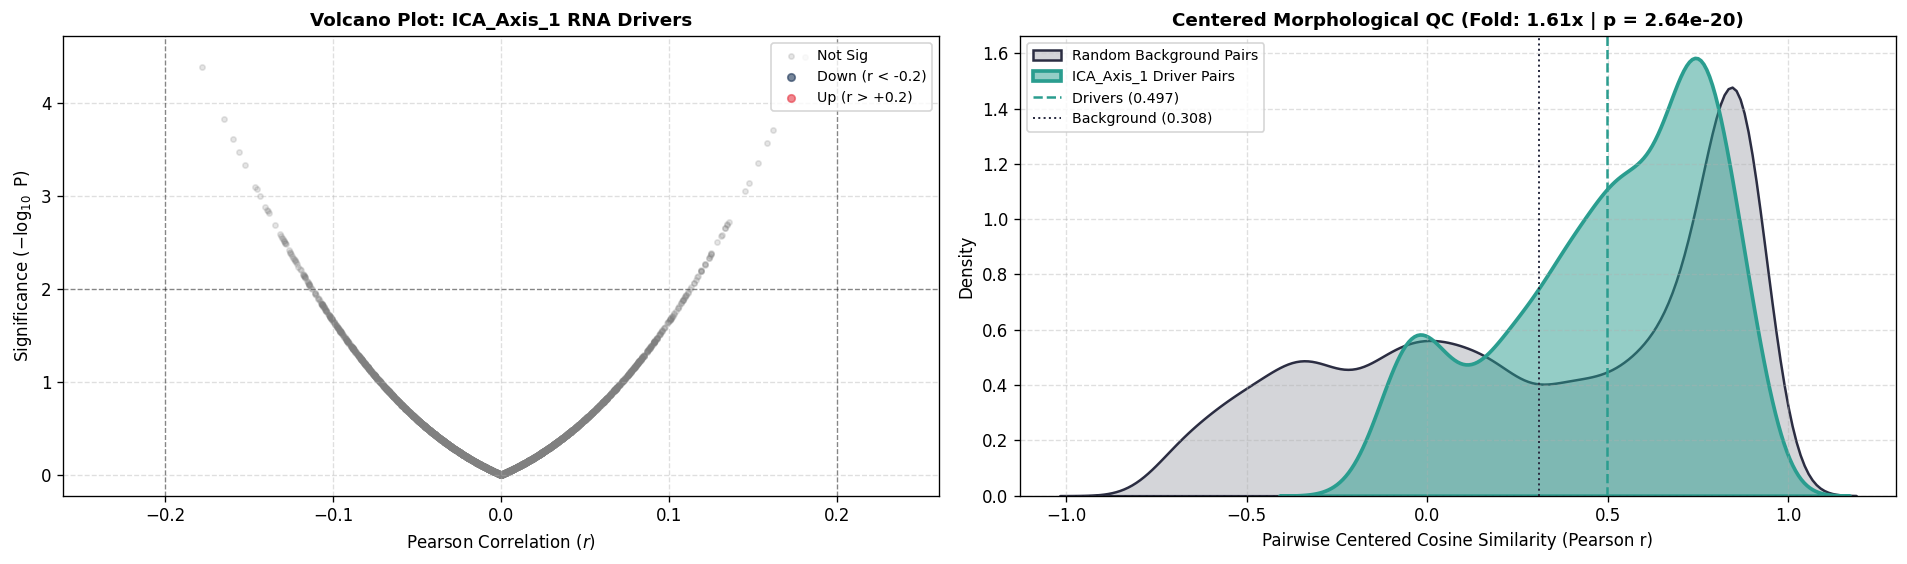


🎯 ICA_Axis_2 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : LOC102724428 (+0.18), SIRT5 (+0.17), ENSG00000188850 (+0.16), CPLX1 (+0.16), NEURL3 (+0.15)
  ↳ Key Downregulated : CRCT1 (-0.26), LOC101928994 (-0.23), JARID2-DT (-0.19), PTGES (-0.18), BZW1P2 (-0.18)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.53 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.218 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 0.0% (0/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • IL-2/STAT5 Signaling                             | NES: +1.45 | FDR: 6.09e-01
     • Unfolded Protein Response                        | NES: +1.29 | FDR: 8.42e-01
     • Hypoxia                                          | NES: +1.23 | FDR: 7.20e-01
     • mTORC1 Signaling                                 | NES: +1.12 | FDR: 9.28e-01
     • p53 Pathway                      

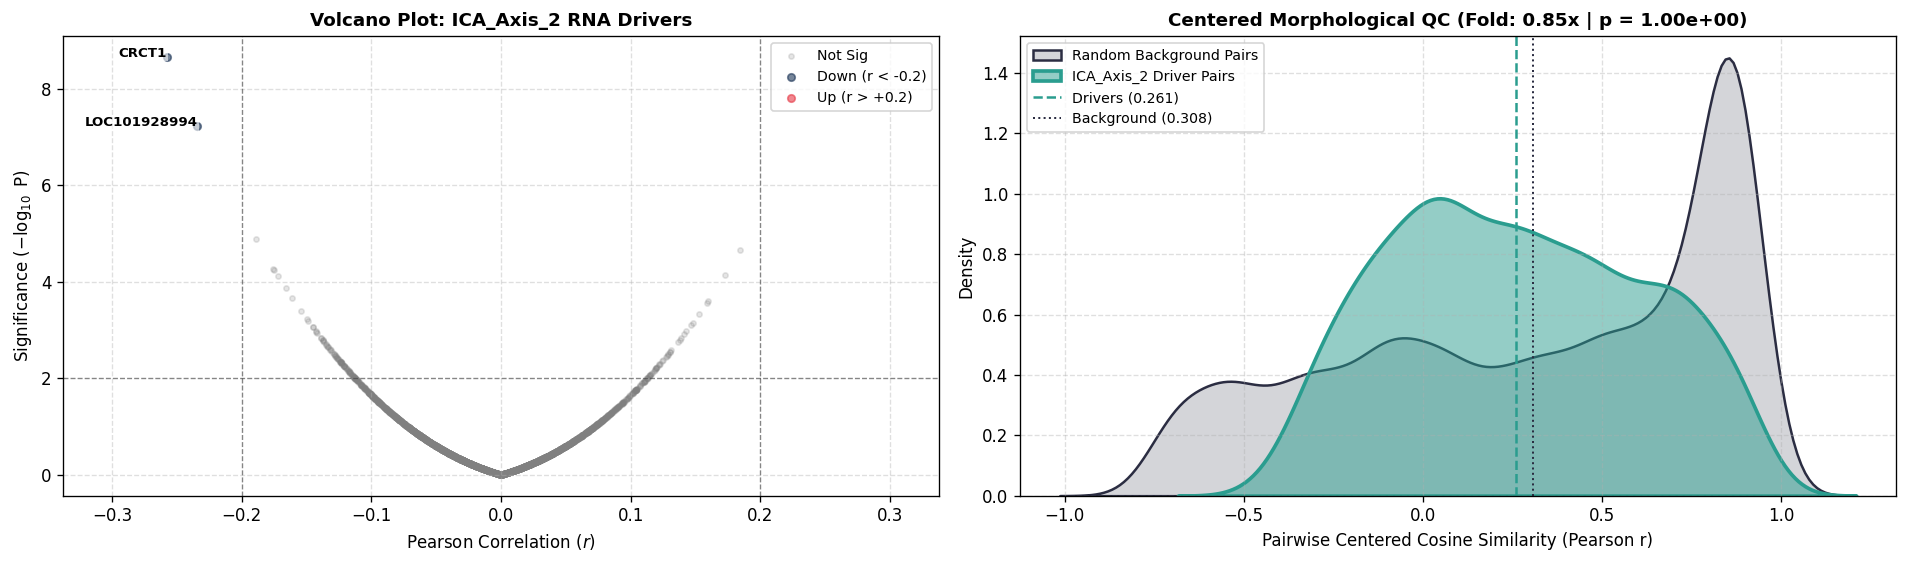


🎯 ICA_Axis_3 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : IGFL2-AS1 (+0.30), ZNF114 (+0.21), GABARAPL1 (+0.19), WIPI1 (+0.18), CEBPD (+0.17)
  ↳ Key Downregulated : RPS2P53 (-0.21), KRT75 (-0.20), CGB8 (-0.19), STRA6 (-0.18), ANKRD2 (-0.18)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.58 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.216 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 2.0% (1/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • IL-2/STAT5 Signaling                             | NES: +1.74 | FDR: 1.43e-01
     • Hypoxia                                          | NES: +1.58 | FDR: 2.94e-01
     • Androgen Response                                | NES: +1.57 | FDR: 2.09e-01
     • Cholesterol Homeostasis                          | NES: +1.53 | FDR: 2.09e-01
     • Apoptosis                                        | N

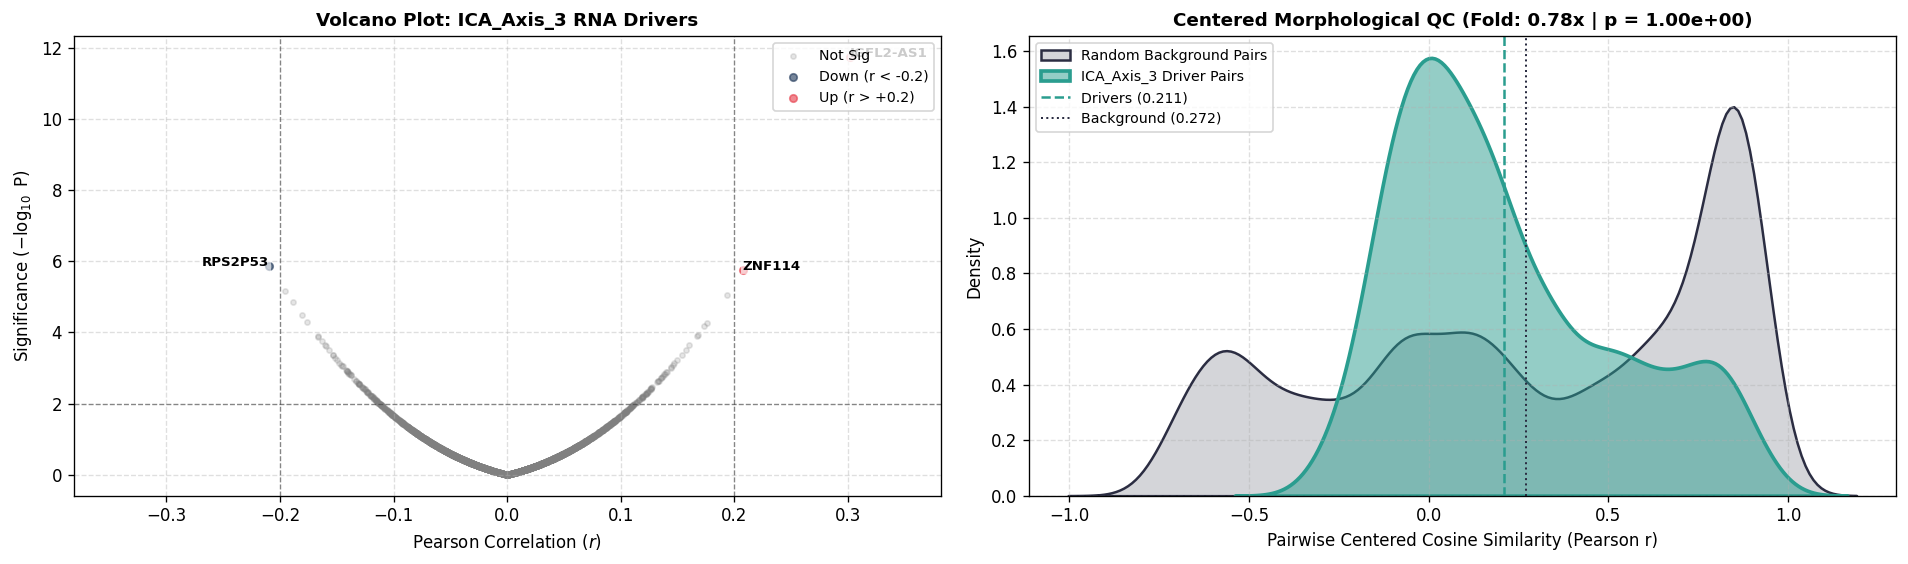


🎯 ICA_Axis_4 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ENSG00000258314 (+0.24), PLAC8 (+0.22), RARRES2 (+0.22), PSLNR (+0.22), IGFBP5 (+0.20)
  ↳ Key Downregulated : LOC124903825 (-0.25), KCNQ2 (-0.24), MIR7-3HG (-0.24), GAST (-0.24), ENSG00000286393 (-0.20)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  1.05 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.233 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 0.0% (0/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • KRAS Signaling Up                                | NES: +1.49 | FDR: 4.24e-01
     • UV Response Dn                                   | NES: +1.17 | FDR: 1.00e+00
     • Hypoxia                                          | NES: +1.05 | FDR: 1.00e+00
     • IL-6/JAK/STAT3 Signaling                         | NES: +1.02 | FDR: 1.00e+00
     • TNF-alpha Signaling via NF-kB  

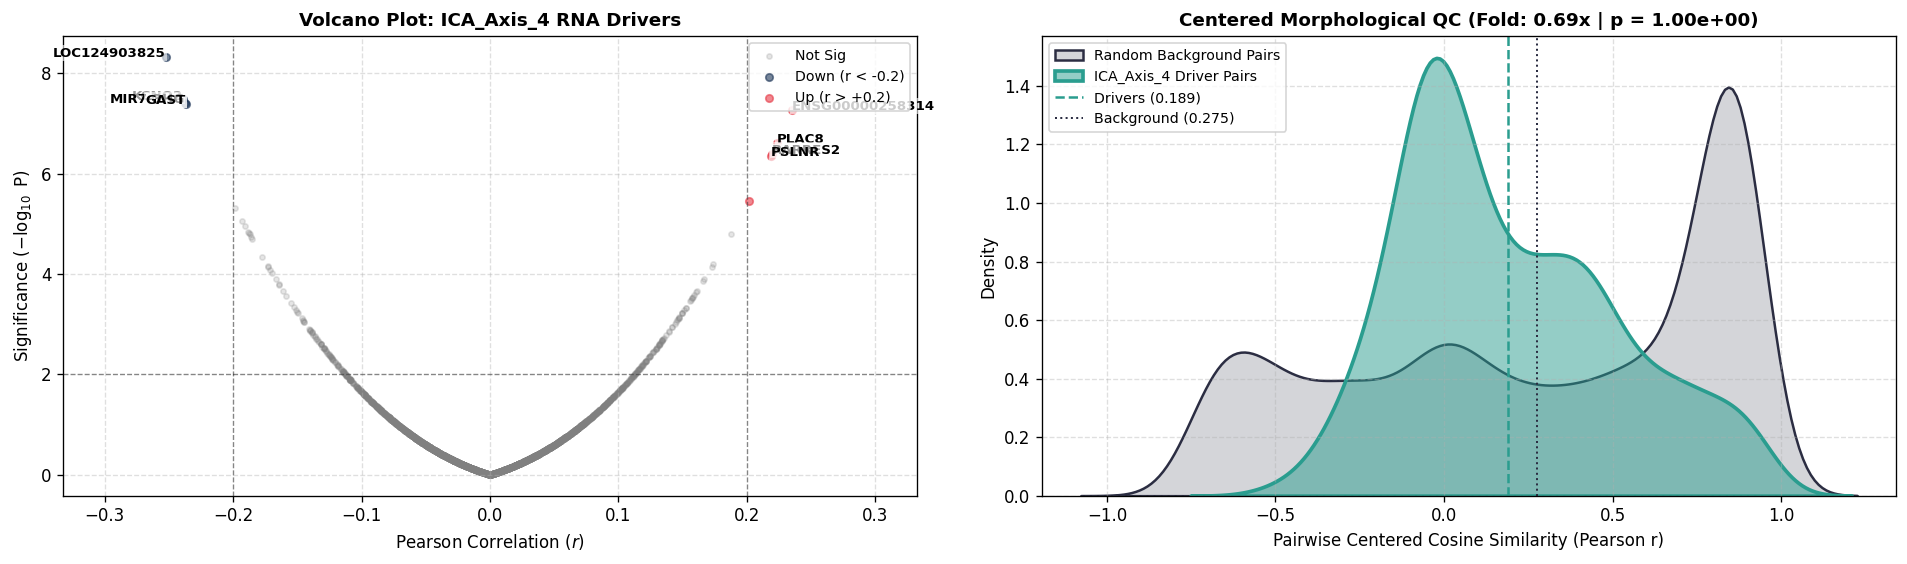


🎯 ICA_Axis_5 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ZNF114 (+0.22), IGFL2-AS1 (+0.22), CEBPD (+0.21), FBXO32 (+0.19), HTR3A (+0.18)
  ↳ Key Downregulated : RPL9P21 (-0.28), CMYA5 (-0.25), ERAP1 (-0.20), ENSG00000269693 (-0.18), TASP1 (-0.18)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  1.20 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.231 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 4.0% (2/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +1.99 | FDR: 0.00e+00
     • p53 Pathway                                      | NES: +1.77 | FDR: 3.64e-02
     • Unfolded Protein Response                        | NES: +1.73 | FDR: 4.10e-02
     • heme Metabolism                                  | NES: +1.71 | FDR: 4.20e-02
     • Apoptosis                                    

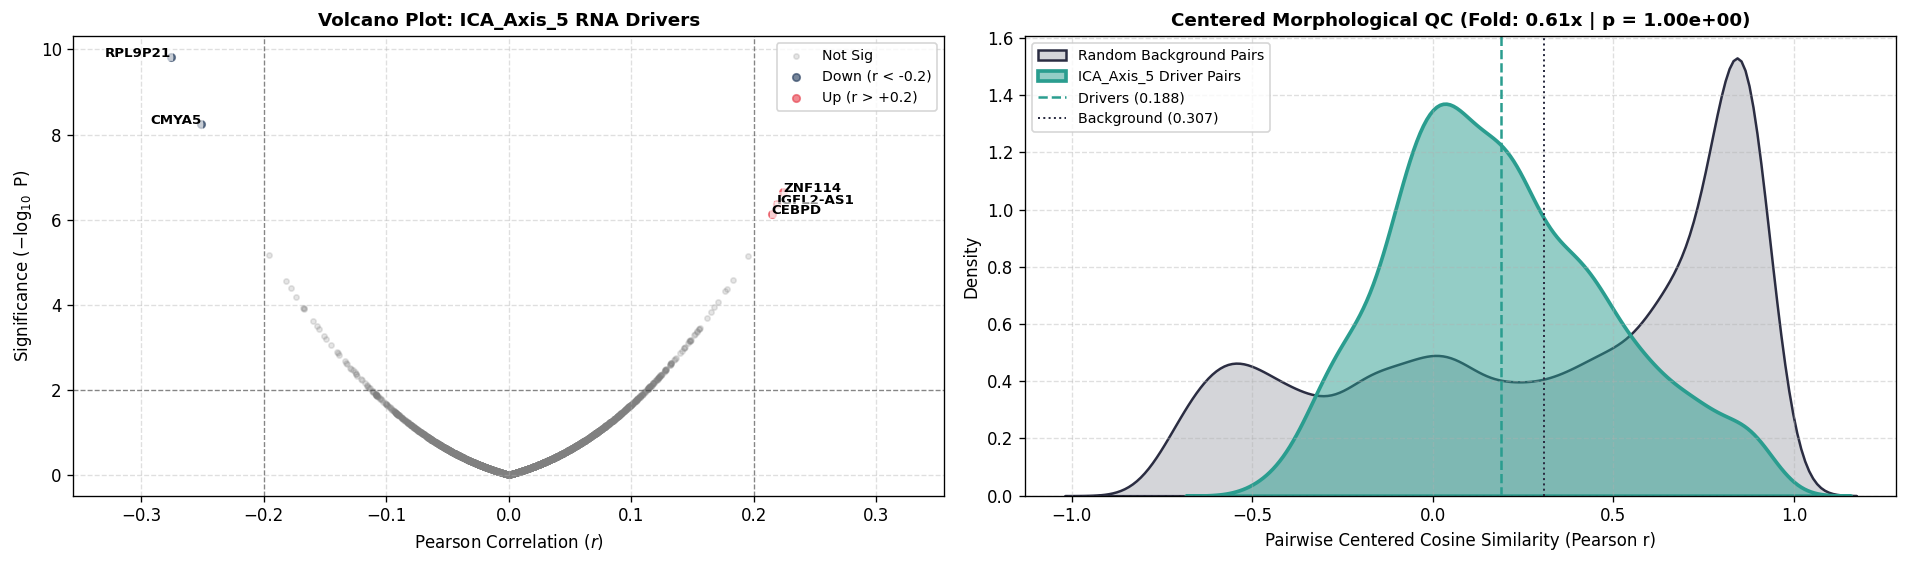


🎯 ICA_Axis_6 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ENSG00000258314 (+0.21), PSLNR (+0.21), MOB3B (+0.20), EDN2 (+0.19), PDLIM1 (+0.19)
  ↳ Key Downregulated : MIR7-3HG (-0.32), FOS (-0.29), LOC124903825 (-0.28), MMP10 (-0.28), IER2 (-0.27)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  1.20 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.239 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 0.0% (0/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • E2F Targets                                      | NES: +1.60 | FDR: 7.89e-02
     • G2-M Checkpoint                                  | NES: +1.31 | FDR: 2.55e-01
     • Apical Surface                                   | NES: +0.97 | FDR: 8.47e-01
     • Myogenesis                                       | NES: +0.87 | FDR: 8.66e-01
     • Spermatogenesis                               

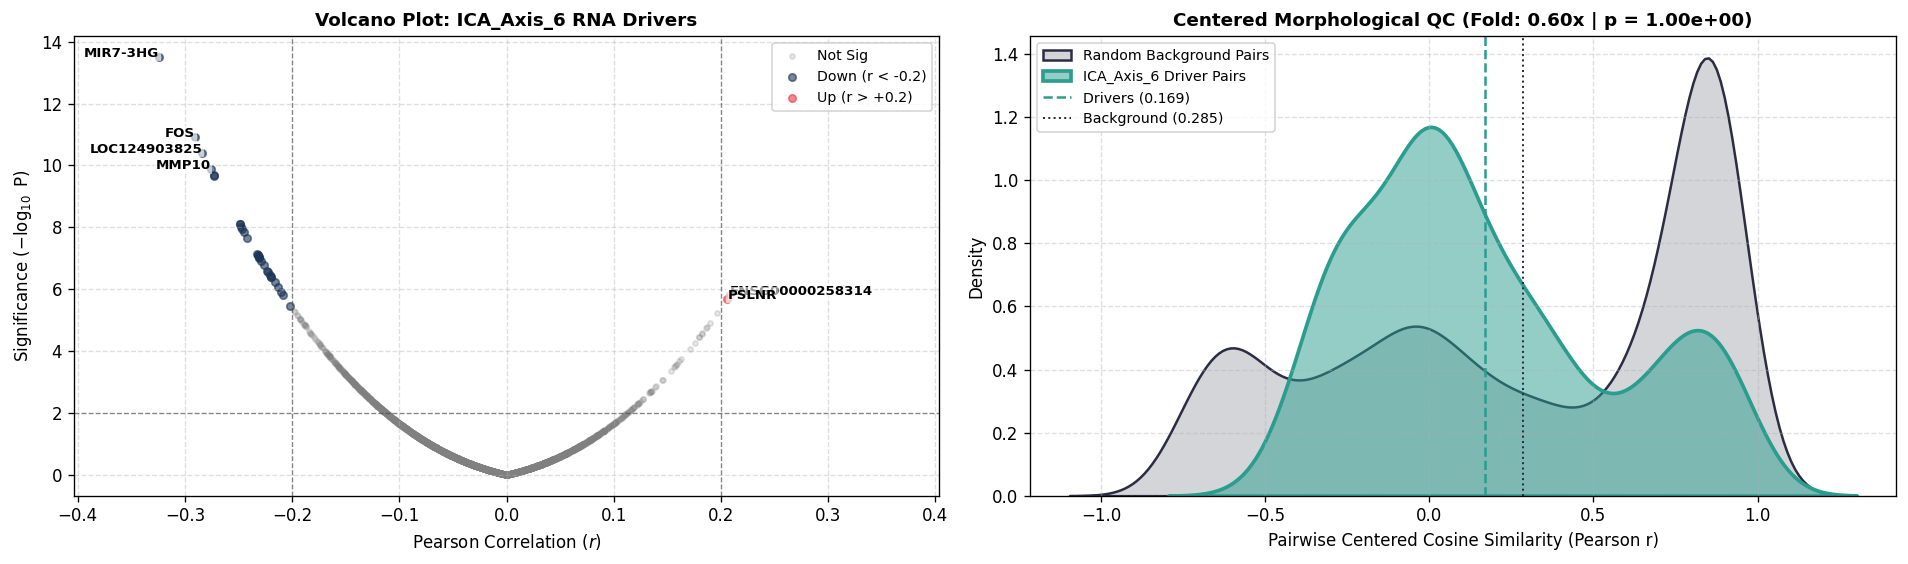


🎯 ICA_Axis_7 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : GTPBP10 (+0.16), ZNF438 (+0.15), UFSP2 (+0.14), DTWD1 (+0.13), CAMLG (+0.13)
  ↳ Key Downregulated : ENSG00000273141 (-0.19), LINC01766 (-0.18), RN7SKP187 (-0.17), RN7SKP255 (-0.17), C11orf96 (-0.16)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.19 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.214 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 0.0% (0/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • UV Response Dn                                   | NES: +1.53 | FDR: 5.03e-01
     • Spermatogenesis                                  | NES: +1.52 | FDR: 2.61e-01
     • Oxidative Phosphorylation                        | NES: +1.46 | FDR: 2.45e-01
     • TGF-beta Signaling                               | NES: +1.39 | FDR: 2.64e-01
     • Protein Secretion                  

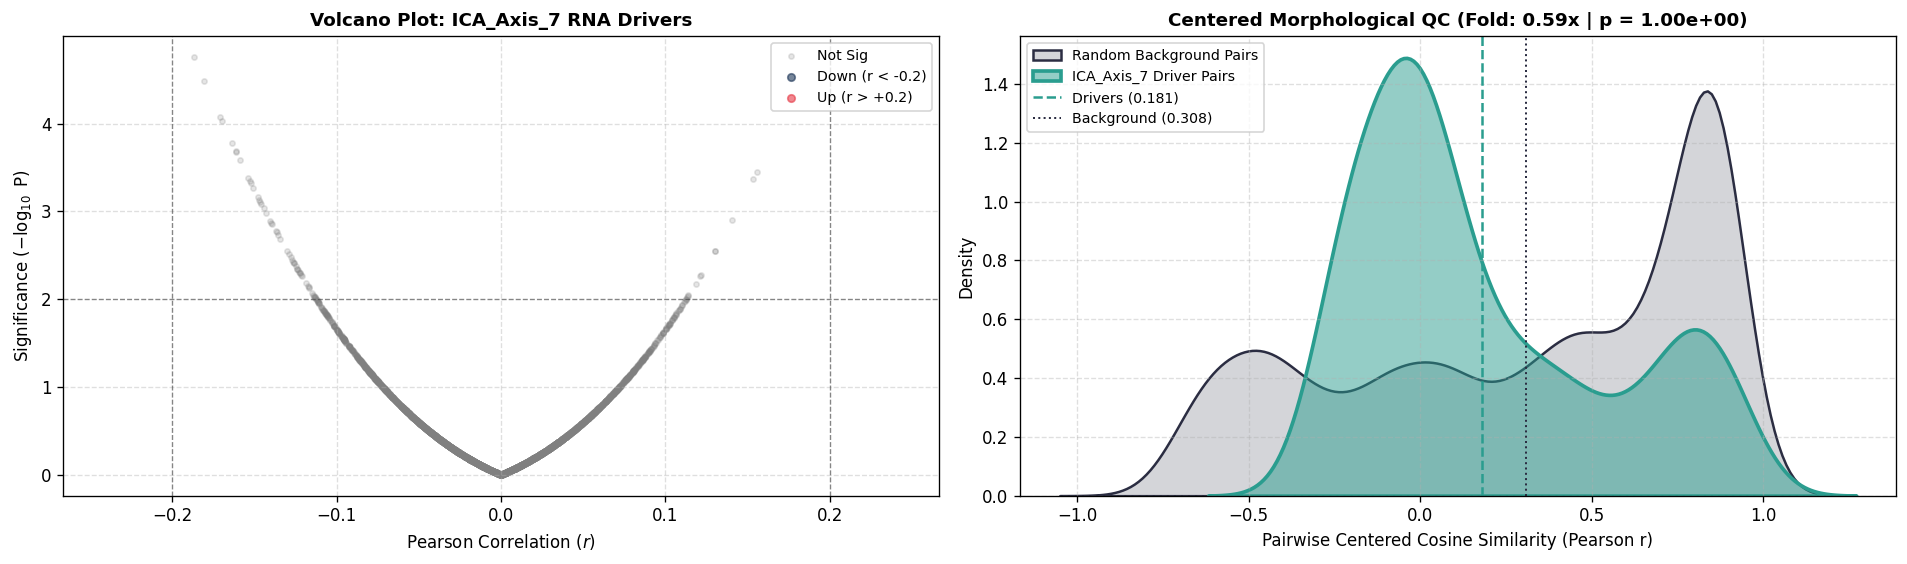


🎯 ICA_Axis_8 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ZNF571 (+0.27), ENSG00000287190 (+0.24), PURPL (+0.24), BMP2K-DT (+0.23), CPD (+0.23)
  ↳ Key Downregulated : SEMA4D (-0.20), BMAL1 (-0.18), TMEM37 (-0.17), ENSG00000243155 (-0.17), GPRC5C (-0.17)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.36 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.209 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 4.0% (2/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • Epithelial Mesenchymal Transition                | NES: +2.24 | FDR: 0.00e+00
     • TNF-alpha Signaling via NF-kB                    | NES: +2.16 | FDR: 0.00e+00
     • Estrogen Response Late                           | NES: +1.97 | FDR: 8.15e-03
     • UV Response Up                                   | NES: +1.67 | FDR: 1.04e-01
     • p53 Pathway                           

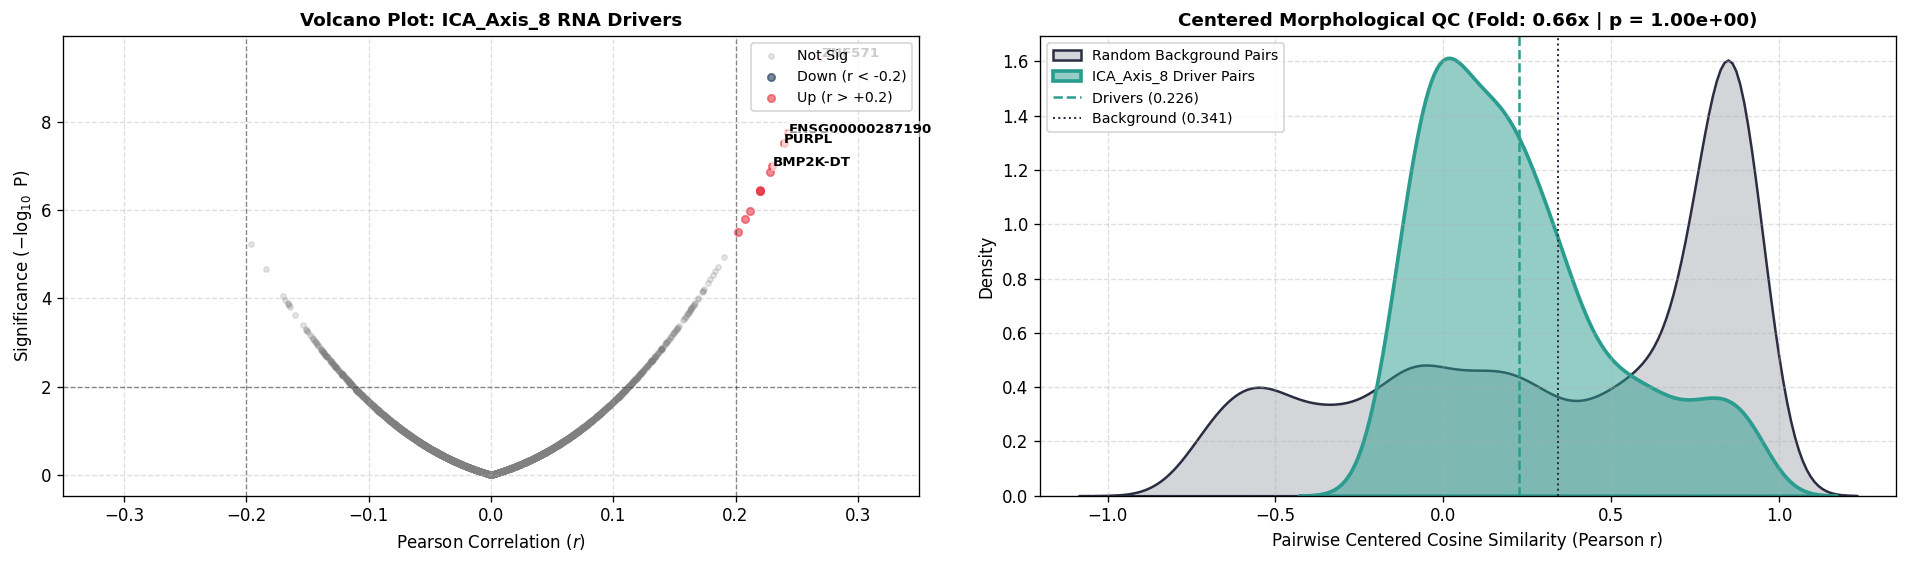


🎯 ICA_Axis_9 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ESM1 (+0.24), MYCT1 (+0.21), NMRAL2P (+0.21), LINC00520 (+0.20), CRCT1 (+0.20)
  ↳ Key Downregulated : FOXO6 (-0.16), PSLNR (-0.16), PID1 (-0.16), RAB7B (-0.16), WFDC21P (-0.15)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.48 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.221 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 2.0% (1/50) [✅ Clean]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +1.90 | FDR: 1.00e-02
     • KRAS Signaling Up                                | NES: +1.76 | FDR: 3.00e-02
     • Inflammatory Response                            | NES: +1.74 | FDR: 3.00e-02
     • p53 Pathway                                      | NES: +1.72 | FDR: 2.63e-02
     • Allograft Rejection                              | NES: +

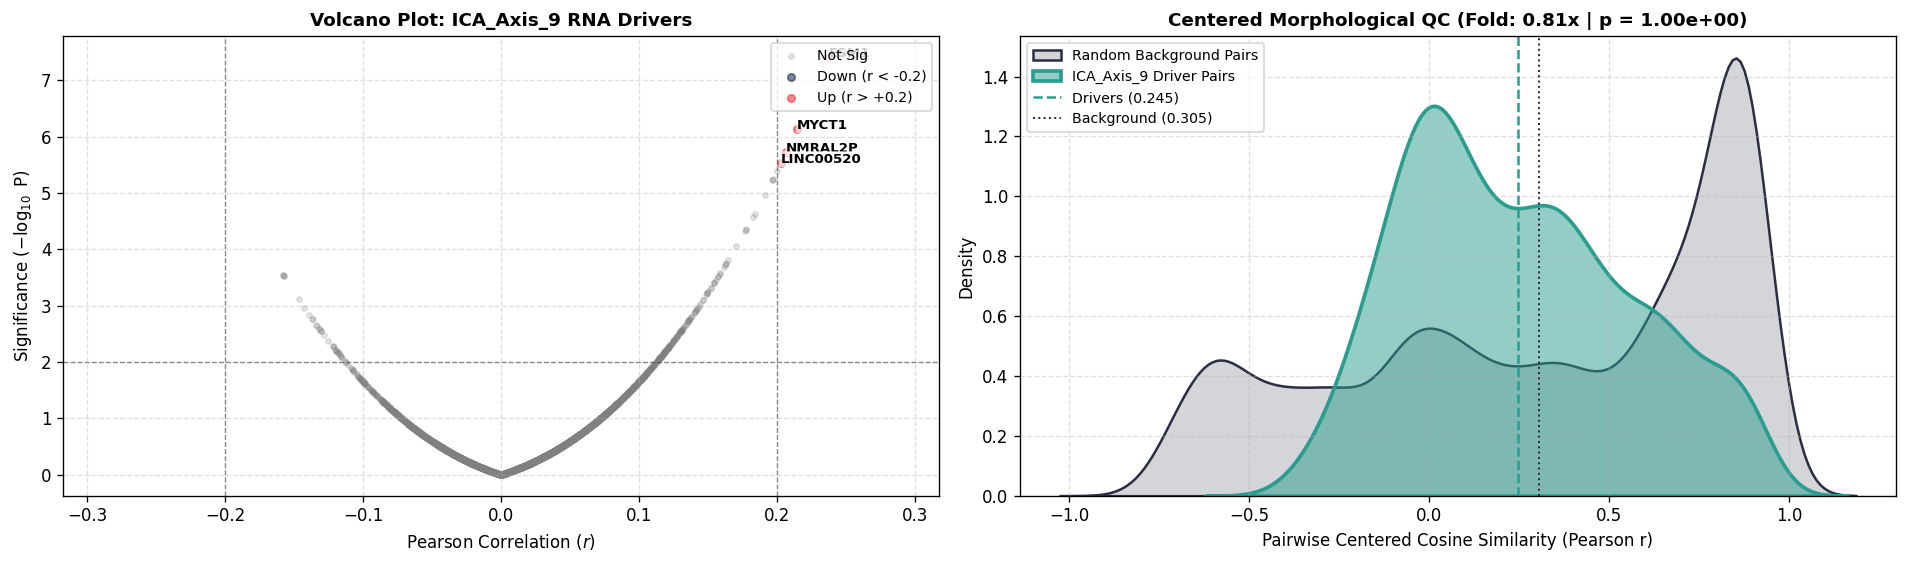


🎯 ICA_Axis_10 | Subspace Alignment: FASTICA | ✅ STATISTICALLY SIGNIFICANT (p < 0.05)
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : KANK4 (+0.29), CXCL8 (+0.25), HK2 (+0.23), MAP3K8 (+0.23), ELOVL4 (+0.23)
  ↳ Key Downregulated : BIRC7 (-0.23), LDLRAD4 (-0.21), WNT5B (-0.19), FOXS1 (-0.18), ENSG00000226472 (-0.17)

  🧼 Transcriptional Purity Profile:
     • Loading Kurtosis (κ)      :  0.70 (Target: > 6.0) [⚠️ Diffuse]
     • Hoyer Sparsity Index      : 0.227 (Target: > 0.40) [⚠️ Dense]
     • Pan-Stress Contamination  : 6.0% (3/50) [⚠️ Stressed]

  🟢 Top Positively Enriched Hallmarks (GSEA):
     • TNF-alpha Signaling via NF-kB                    | NES: +2.17 | FDR: 0.00e+00
     • Apoptosis                                        | NES: +1.93 | FDR: 0.00e+00
     • mTORC1 Signaling                                 | NES: +1.91 | FDR: 1.67e-03
     • IL-2/STAT5 Signaling                             | NES: +1.86 | FDR: 1.25e-03
     • UV Response Up                                

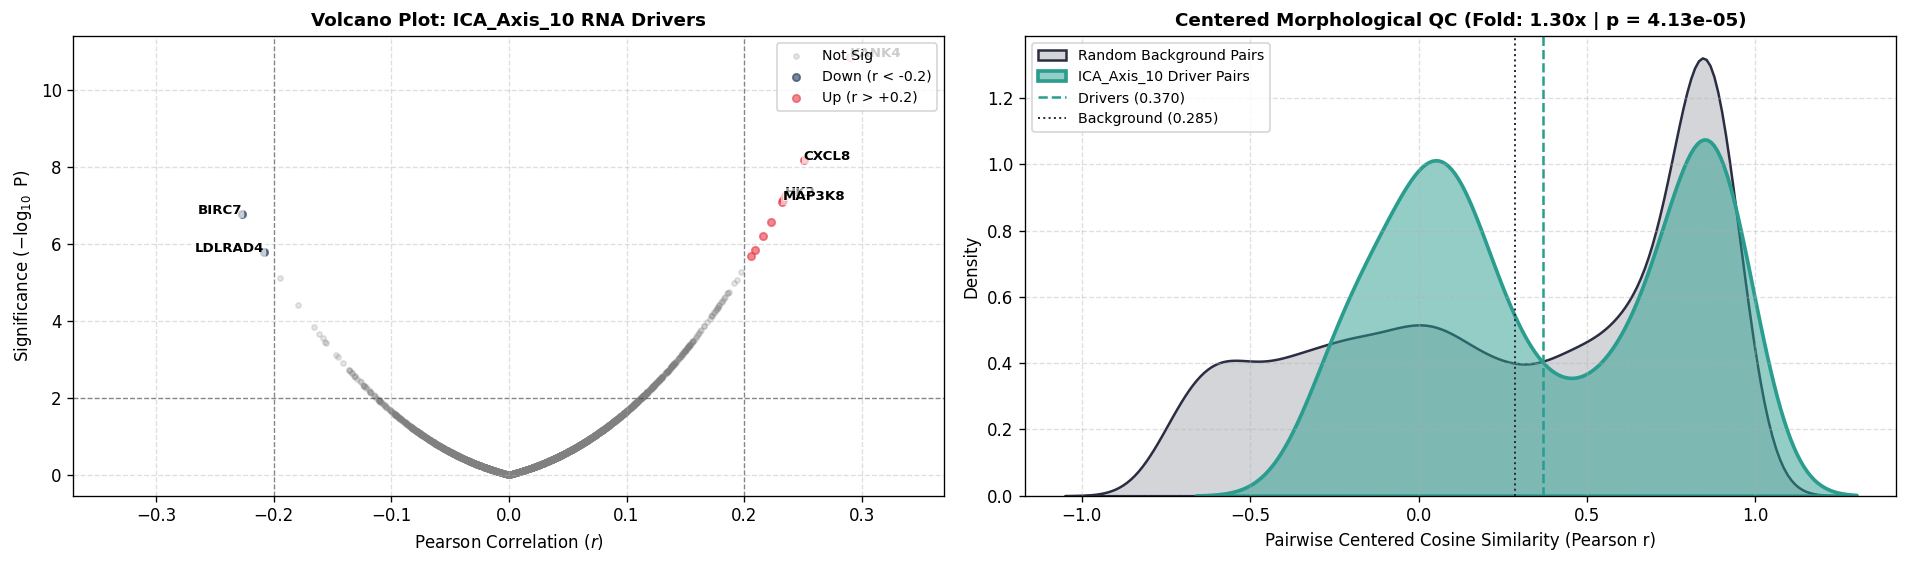


🏁 FULL UNMIXED DECODING (FASTICA) & MULTIMODAL QC COMPLETE


In [ ]:
# @title
# ==============================================================================
# 🧬 CELL 2: COMPLETE MULTIMODAL LATENT DECODER & PHENOTYPIC COHERENCE ENGINE
# ==============================================================================
import os
import gc
import re
import sys
import time
import shutil
import tempfile
import ctypes
import warnings
import requests
import subprocess
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from scipy.stats import mannwhitneyu, t as t_dist, skew, kurtosis
from sklearn.decomposition import FastICA

# Auto-install bioinformatics and chemoinformatics packages if missing
for pkg in ['rdkit', 'mygene', 'gseapy']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
import mygene
import gseapy as gp

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

# Instantiate Morgan Fingerprint Generator (ECFP4: radius=2, 2048 bits)
MORGAN_GEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# ==============================================================================
# 🛡️ 0. HARDWARE ACCELERATION & MEMORY MANAGEMENT
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Acceleration Engine: {device}")

def trim_memory():
    """Forces Linux kernel arena reclamation and flushes GPU cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

def log_debug(msg, t_start=None):
    ram_gb = psutil.virtual_memory().used / 1e9
    ram_pct = psutil.virtual_memory().percent
    elapsed = f"[+{time.time() - t_start:5.1f}s] " if t_start else ""
    print(f"⏱️ {elapsed}🧠 RAM: {ram_gb:4.1f}GB ({ram_pct:2.0f}%) | {msg}")

# ==============================================================================
# 🧪 1. CURATED SMILES RESOLUTION & ECFP4 TANIMOTO CALCULATOR
# ==============================================================================
ROMAN_SMILES_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/annotations_from_Roman/JUMP_CP_compound_metadata_with_SMILES_standard.csv"
LOCAL_SMILES_LOOKUP = "jump_smiles_standard_lookup.parquet"

def ensure_curated_smiles_lookup():
    if os.path.exists(LOCAL_SMILES_LOOKUP):
        return
    raw_csv = "temp_jump_smiles.csv"
    print("📥 Pre-caching Roman's standardized JUMP-CP SMILES metadata...")
    subprocess.run(["gcloud", "storage", "cp", ROMAN_SMILES_URI, raw_csv], check=True)

    con = duckdb.connect()
    cols = [c[0] for c in con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{raw_csv}') LIMIT 1").fetchall()]
    ikey_col = next((c for c in cols if 'inchikey' in c.lower()), None)
    smi_col = next((c for c in cols if 'smiles' in c.lower()), None)

    if not ikey_col or not smi_col:
        con.close()
        raise ValueError(f"Could not locate InChIKey or SMILES in CSV columns: {cols}")

    con.execute(f"""
        COPY (
            SELECT DISTINCT {ikey_col} AS InChIKey, {smi_col} AS SMILES
            FROM read_csv_auto('{raw_csv}')
            WHERE {ikey_col} IS NOT NULL AND {smi_col} IS NOT NULL AND {smi_col} != ''
        ) TO '{LOCAL_SMILES_LOOKUP}' (FORMAT PARQUET, COMPRESSION 'SNAPPY');
    """)
    con.close()
    if os.path.exists(raw_csv):
        os.remove(raw_csv)
    print("✅ Curated SMILES lookup Parquet ready.")

ensure_curated_smiles_lookup()

def compute_driver_tanimoto(inchikey_list):
    con = duckdb.connect()
    keys_df = pd.DataFrame({"InChIKey": list(set(inchikey_list))})
    con.register("keys_df", keys_df)
    res = con.execute(f"""
        SELECT InChIKey, SMILES FROM read_parquet('{LOCAL_SMILES_LOOKUP}')
        WHERE InChIKey IN (SELECT InChIKey FROM keys_df)
    """).df()
    con.close()

    smiles_map = dict(zip(res['InChIKey'], res['SMILES']))
    fps = []
    valid_count = 0

    for ikey in inchikey_list:
        smi = smiles_map.get(ikey)
        if smi:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                fps.append(MORGAN_GEN.GetFingerprint(mol))
                valid_count += 1

    n = len(fps)
    if n < 2:
        return 0.0, 0.0, 0.0, valid_count

    similarities = [DataStructs.TanimotoSimilarity(fps[i], fps[j]) for i in range(n) for j in range(i + 1, n)]
    return np.mean(similarities), np.median(similarities), np.max(similarities), valid_count

# ==============================================================================
# ⚡ 2. SELF-CONTAINED NUMPY POOLING & LINEAR ALGEBRA CORE
# ==============================================================================
def numpy_median_pool(keys, features):
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]
    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        mask = (inverse_idx == i)
        aggregated[i] = features[mask][0] if np.count_nonzero(mask) == 1 else np.median(features[mask], axis=0)
    return unique_keys, aggregated

def numpy_max_abs_pool(keys, features):
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]
    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        sub_feats = features[inverse_idx == i]
        if len(sub_feats) == 1:
            aggregated[i] = sub_feats[0]
        else:
            max_idx = np.argmax(np.abs(sub_feats), axis=0)
            aggregated[i] = sub_feats[max_idx, np.arange(dim)]
    return unique_keys, aggregated

def svd_flip_torch(u, v=None):
    max_abs_cols = torch.argmax(torch.abs(u), dim=0)
    signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
    signs[signs == 0] = 1.0
    u = u * signs
    if v is not None:
        k_shared = min(u.shape[1], v.shape[0])
        v[:k_shared] = v[:k_shared] * signs[:k_shared].unsqueeze(1)
        return u, v
    return u

def get_exact_subspace_basis(M, k=50):
    N_samples, D_features = M.shape
    q_target = min(k, N_samples - 1, D_features)
    if q_target <= 0:
        return torch.zeros((N_samples, 1), device=M.device, dtype=M.dtype)
    U, S, V = torch.pca_lowrank(M, q=q_target, center=False, niter=3)
    return svd_flip_torch(U[:, :q_target])

def reduce_dimensions_configurable(X_np, mode="none", var_threshold=0.90, fixed_dims=384):
    if mode == "none":
        return X_np.astype(np.float32)
    N_samples, D_features = X_np.shape
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    X_c = X - X.mean(dim=0)
    target_q = min(fixed_dims if mode == "fixed" else min(D_features, 512), N_samples - 1, D_features)
    U, S, V = torch.pca_lowrank(X_c, q=target_q, center=False, niter=3)
    U = svd_flip_torch(U)
    if mode == "variance":
        cum_variance = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
        k = int(torch.argmax((cum_variance >= var_threshold).to(torch.int64)).item()) + 1
        k = min(k, int(N_samples * 0.8), target_q)
    elif mode == "fixed":
        k = min(fixed_dims, target_q, int(N_samples * 0.8))
    else:
        k = min(target_q, int(N_samples * 0.8))
    res = (U[:, :k] * S[:k]).cpu().numpy().astype(np.float32)
    del X, X_c, U, S, V
    return res

# ==============================================================================
# 🎛️ 2.5 SUBSPACE UNMIXING ENGINES (HYBRID, FASTICA, VARIMAX)
# ==============================================================================
def varimax_rotation(Phi, gamma=1.0, q=50, tol=1e-6):
    """Orthogonal Varimax rotation maximizing loading sparsity."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = np.dot(Phi, R)
        u, s, vh = np.linalg.svd(
            np.dot(Phi.T, np.asarray(Lambda)**3 - (gamma / p) * np.dot(Lambda, np.diag(np.sum(Lambda**2, axis=0))))
        )
        R = np.dot(u, vh)
        d = np.sum(s)
        if d_old != 0 and d / d_old < 1 + tol:
            break
    return np.dot(Phi, R), R

def apply_fastica_unmixing(Z_scores, random_state=42, max_iter=1000, tol=1e-4):
    """Decomposes canonical superpositions into statistically independent programs."""
    n_samples, n_features = Z_scores.shape
    ica = FastICA(
        n_components=n_features,
        algorithm='parallel',
        whiten='unit-variance',
        fun='logcosh',
        max_iter=max_iter,
        tol=tol,
        random_state=random_state
    )
    S_ica = ica.fit_transform(Z_scores)
    skews = skew(S_ica, axis=0)
    signs = np.where(skews < 0, -1.0, 1.0)
    S_ica = S_ica * signs
    comp_variances = np.var(S_ica, axis=0)
    sort_idx = np.argsort(comp_variances)[::-1]
    return S_ica[:, sort_idx]

def apply_hybrid_unmixing(Z_scores, random_state=42, max_iter=1000, tol=1e-4):
    """
    Two-Stage Hybrid Disentanglement:
      1. FastICA separates statistically independent biological sources.
      2. Varimax rotates independent components to enforce loading sparsity.
    """
    S_ica = apply_fastica_unmixing(Z_scores, random_state=random_state, max_iter=max_iter, tol=tol)
    S_hybrid, _ = varimax_rotation(S_ica)
    skews_h = skew(S_hybrid, axis=0)
    signs_h = np.where(skews_h < 0, -1.0, 1.0)
    S_hybrid = S_hybrid * signs_h
    comp_variances = np.var(S_hybrid, axis=0)
    sort_idx = np.argsort(comp_variances)[::-1]
    return S_hybrid[:, sort_idx]

# ==============================================================================
# 🔑 3. COLUMN RESOLUTION & PLATEMAP BRIDGE HELPERS
# ==============================================================================
LOOKUP_PLATEMAP_FILE = "jump_platemap_lookup.parquet"
LOOKUP_JCP_FILE = "jump_jcp_lookup.parquet"

def resolve_key_column(columns):
    priority = ['InChIKey', 'inchikey', 'Metadata_InChIKey']
    for candidate in priority:
        if candidate in columns:
            return candidate
    for c in columns:
        if 'inchikey' in c.lower():
            return c
    return None

def inspect_morphology_columns(schema_cols):
    direct_key = resolve_key_column(schema_cols)
    if direct_key:
        return 'inchikey', direct_key
    plate = next((c for c in schema_cols if c.lower() in ['metadata_plate', 'plate']), None)
    well = next((c for c in schema_cols if c.lower() in ['metadata_well', 'well']), None)
    if plate and well:
        return 'plate_well', (plate, well)
    jcp = next((c for c in schema_cols if 'jcp2022' in c.lower()), None)
    if jcp:
        return 'jcp', jcp
    return 'unknown', None

def standardize_inchikey_column(df, target_col="InChIKey"):
    key_col = resolve_key_column(df.columns)
    if not key_col:
        raise ValueError(f"No InChIKey found in DataFrame! Available: {list(df.columns)[:10]}")
    redundant = [c for c in df.columns if 'inchikey' in c.lower() and c != key_col and c != target_col]
    if redundant:
        df = df.drop(columns=redundant)
    if key_col != target_col:
        if target_col in df.columns:
            df = df.drop(columns=[key_col])
        else:
            df = df.rename(columns={key_col: target_col})
    return df

def load_dynamic_overlap_pair(morph_path: str, rna_path: str, target_keys_subset: set = None):
    fresh_dir = tempfile.mkdtemp(prefix="duckdb_load_")
    con = duckdb.connect()
    con.execute(f"PRAGMA temp_directory='{fresh_dir}';")
    con.execute("SET memory_limit = '3GB';")
    con.execute("SET threads = 2;")
    con.execute("SET preserve_insertion_order = false;")

    morph_schema = [f.name for f in pq.read_schema(morph_path)]
    rna_schema = [f.name for f in pq.read_schema(rna_path)]

    morph_id_type, morph_cols = inspect_morphology_columns(morph_schema)
    rna_key = resolve_key_column(rna_schema)

    if morph_id_type == 'unknown' or not rna_key:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError(f"Identifier missing! Morph Type: {morph_id_type} | RNA Key: {rna_key}")

    has_pert_type = 'Metadata_pert_type' in morph_schema
    pert_clause = "AND Metadata_pert_type = 'trt'" if has_pert_type else ""
    time_col = next((c for c in rna_schema if 'pert_time' in c.lower()), None)
    time_clause = f"AND TRY_CAST({time_col} AS FLOAT) IN (24, 48)" if time_col else ""

    if target_keys_subset is not None:
        shared_keys_df = pd.DataFrame({"ikey": sorted(list(target_keys_subset))})
    else:
        if morph_id_type == 'inchikey':
            morph_keys_sql = f"SELECT DISTINCT {morph_cols} AS ikey FROM read_parquet('{morph_path}') WHERE {morph_cols} IS NOT NULL AND {morph_cols} != 'IAZDPXIOMUYVGZ-UHFFFAOYSA-N' {pert_clause}"
        elif morph_id_type == 'plate_well':
            p_col, w_col = morph_cols
            morph_keys_sql = f"SELECT DISTINCT pw.InChIKey AS ikey FROM (SELECT DISTINCT {p_col}, {w_col} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well"
        elif morph_id_type == 'jcp':
            morph_keys_sql = f"SELECT DISTINCT j.InChIKey AS ikey FROM (SELECT DISTINCT {morph_cols} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j ON m.{morph_cols} = j.Metadata_JCP2022"

        key_intersect_query = f"""
            WITH morph_keys AS ({morph_keys_sql}),
            rna_keys AS (SELECT DISTINCT {rna_key} AS ikey FROM read_parquet('{rna_path}') WHERE {rna_key} IS NOT NULL AND {rna_key} != 'IAZDPXIOMUYVGZ-UHFFFAOYSA-N' {time_clause})
            SELECT ikey FROM morph_keys INTERSECT SELECT ikey FROM rna_keys ORDER BY ikey ASC
        """
        shared_keys_df = con.execute(key_intersect_query).df()

    if len(shared_keys_df) == 0:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError("Zero overlapping compounds found between datasets!")

    con.register("shared_keys_view", shared_keys_df)

    if morph_id_type == 'inchikey':
        morph_df = con.execute(f"SELECT * FROM read_parquet('{morph_path}') WHERE {morph_cols} IN (SELECT ikey FROM shared_keys_view) {pert_clause}").df()
        morph_df = standardize_inchikey_column(morph_df, target_col="InChIKey")
    elif morph_id_type == 'plate_well':
        p_col, w_col = morph_cols
        morph_df = con.execute(f"SELECT m.*, pw.InChIKey AS InChIKey FROM read_parquet('{morph_path}') m INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well WHERE pw.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}").df()
    elif morph_id_type == 'jcp':
        morph_df = con.execute(f"SELECT m.*, j.InChIKey AS InChIKey FROM read_parquet('{morph_path}') m INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j ON m.{morph_cols} = j.Metadata_JCP2022 WHERE j.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}").df()

    exclude_morph = ["InChIKey", 'pubchem_cid', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022', 'concentration', 'dose', 'time', 'timepoint', 'plate', 'well']
    morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns if not c.startswith("Metadata_") and c not in exclude_morph]

    m_keys = morph_df["InChIKey"].to_numpy()
    m_feats = morph_df[morph_features].to_numpy(dtype=np.float32)
    del morph_df
    trim_memory()

    morph_u_keys, morph_agg = numpy_median_pool(m_keys, m_feats)
    del m_keys, m_feats

    rna_df = con.execute(f"SELECT * FROM read_parquet('{rna_path}') WHERE {rna_key} IN (SELECT ikey FROM shared_keys_view) {time_clause}").df()
    con.close()
    shutil.rmtree(fresh_dir, ignore_errors=True)

    rna_df = standardize_inchikey_column(rna_df, target_col="InChIKey")
    exclude_rna = ["InChIKey", 'pubchem_cid', 'pert_time_h', 'pert_dose_uM', 'Metadata_Plate', 'Metadata_Well']
    rna_features = [c for c in rna_df.select_dtypes(include=[np.number]).columns if not c.startswith("Metadata_") and c not in exclude_rna]

    r_keys = rna_df["InChIKey"].to_numpy()
    r_feats = rna_df[rna_features].to_numpy(dtype=np.float32)
    del rna_df
    trim_memory()

    rna_u_keys, rna_agg = (r_keys, r_feats) if len(np.unique(r_keys)) == len(r_keys) else numpy_max_abs_pool(r_keys, r_feats)
    del r_keys, r_feats

    common_eval_keys = np.intersect1d(morph_u_keys, rna_u_keys)
    m_mask = np.isin(morph_u_keys, common_eval_keys)
    r_mask = np.isin(rna_u_keys, common_eval_keys)

    X_morph = np.nan_to_num(morph_agg[m_mask])
    Y_rna = np.nan_to_num(rna_agg[r_mask])
    shared_inchikeys = morph_u_keys[m_mask]

    del morph_agg, rna_agg
    trim_memory()
    return X_morph, Y_rna, shared_inchikeys

# ==============================================================================
# 🌐 4. 3-TIER ANNOTATION ENGINE (PubChem + ChEMBL Block-1 Rescue)
# ==============================================================================
ANNOTATION_CACHE = {}

def get_rich_compound_annotation(inchikey):
    if inchikey in ANNOTATION_CACHE:
        return ANNOTATION_CACHE[inchikey]

    name = "Unknown"
    moa = "Unannotated"

    try:
        url_syn = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/synonyms/JSON"
        r = requests.get(url_syn, timeout=4)
        if r.status_code == 200:
            info = r.json().get('InformationList', {}).get('Information', [{}])[0]
            synonyms = info.get('Synonym', [])
            for s in synonyms[:15]:
                if not re.match(r'^\d+-\d+-\d+$', s) and len(s) > 2 and not any(s.startswith(p) for p in ['SCHEMBL', 'CHEMBL', 'AKOS', 'CS-', 'EN300']):
                    name = s
                    break
    except Exception:
        pass

    chembl_id = None
    try:
        url_chembl = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key={inchikey}"
        r = requests.get(url_chembl, timeout=4)
        mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if not mols and len(inchikey) >= 14:
            b1 = inchikey[:14]
            url_b1 = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key__startswith={b1}"
            r = requests.get(url_b1, timeout=4)
            mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if mols:
            mol = mols[0]
            chembl_id = mol.get('molecule_chembl_id')
            if name == "Unknown" and mol.get('pref_name'):
                name = mol.get('pref_name')

            url_mech = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
            r_m = requests.get(url_mech, timeout=4)
            if r_m.status_code == 200:
                mechs = r_m.json().get('mechanisms', [])
                if mechs:
                    moa = mechs[0].get('mechanism_of_action')

            if moa == "Unannotated" and chembl_id:
                url_act = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?molecule_chembl_id={chembl_id}&standard_type=IC50&standard_value__lte=500&limit=1"
                r_a = requests.get(url_act, timeout=4)
                if r_a.status_code == 200:
                    acts = r_a.json().get('activities', [])
                    if acts and acts[0].get('target_pref_name'):
                        moa = f"{acts[0].get('target_pref_name')} inhibitor (IC50 < 500nM)"
    except Exception:
        pass

    ANNOTATION_CACHE[inchikey] = (name, moa)
    return name, moa

# ==============================================================================
# ⚙️ 5. CONFIGURATION & SUBSPACE UNMIXING SELECTOR
# ==============================================================================
MERGE_KEY = "InChIKey"
DMSO_INCHIKEY = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N"
NUM_AXES_TO_ANALYZE = 10

# ------------------------------------------------------------------------------
# 🚩 SUBSPACE UNMIXING SELECTOR:
#    • "hybrid"  : FastICA + Varimax (Highest biological purity & sparsity)
#    • "fastica" : Statistical independence via negentropy
#    • "varimax" : Geometric loading sparsity
#    • "none"    : Raw orthogonal SVD eigenvectors
# ------------------------------------------------------------------------------
UNMIXING_METHOD = "fastica"  # Options: "hybrid" | "fastica" | "varimax" | "none"

CHEMCHECKER_URI = "gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/JUMP_CP_Global_Signatures_full.parquet"
LOCAL_CC_CACHE = "cached_chemchecker_embeddings.parquet"
RAW_GENES_URI = "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet"
LOCAL_RAW_GENES_CACHE = "cached_drugseq_raw_genes.parquet"

if 'leaderboard_df' not in globals() or leaderboard_df.empty:
    raise RuntimeError("leaderboard_df not found! Please run Cell 1 benchmark first.")

top_model_name = leaderboard_df.iloc[0]["Model / Processing"]
score_col = "SVCCA Adj. AUC" if "SVCCA Adj. AUC" in leaderboard_df.columns else leaderboard_df.columns[4]
top_score = leaderboard_df.iloc[0][score_col]
sig_axes_known = int(leaderboard_df.iloc[0].get("Significant Axes", NUM_AXES_TO_ANALYZE))

active_rna_cache = globals().get('LOCAL_RNA_CACHE', 'cached_cpb_latent_anchor.parquet')
active_rna_source = globals().get('TRANSCRIPTOMIC_SOURCE', 'Active Anchor')

print("=" * 95)
print(f"🏆 DECODING WINNING MODEL: [{top_model_name}]")
print(f"📊 Benchmark Score ({score_col}): {top_score:+.4f} | Statistically Verified Dimensions: {sig_axes_known}")
print(f"🧬 Transcriptomic Alignment Anchor: {active_rna_source} ({active_rna_cache})")
print(f"🎛️ Subspace Unmixing Engine: {UNMIXING_METHOD.upper()}")
print(f"🔬 Bioactivity Reference: Chemical Checker 3,200D Embeddings")
print(f"🎯 Decoding Horizon: Top {NUM_AXES_TO_ANALYZE} Biological Dimensions")
print("=" * 95)

winner_clean_tag = top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '').replace('/', '_').replace('-', '_').replace(',', '')
winner_cache = globals().get('cached_filepaths', {}).get(top_model_name, f"cached_{winner_clean_tag}.parquet")

if not os.path.exists(winner_cache):
    raise FileNotFoundError(f"Winner cache file not found: {winner_cache}")

# ==============================================================================
# ⚡ 6. PROJECTION & SUBSPACE UNMIXING
# ==============================================================================
target_keys = globals().get('common_keys_set', None)

X_morph, Y_rna, active_inchikeys = load_dynamic_overlap_pair(
    morph_path=winner_cache,
    rna_path=active_rna_cache,
    target_keys_subset=target_keys
)

# 🛡️ PRESERVE MEAN-CENTERED L2-NORMALIZED MORPHOLOGY (Eliminates Anisotropic Cone Bias)
morph_tensor_raw = torch.tensor(X_morph, device=device, dtype=torch.float32)
morph_centered = morph_tensor_raw - morph_tensor_raw.mean(dim=0, keepdim=True)
X_morph_normed_lookup = F.normalize(morph_centered, p=2, dim=1)
del morph_tensor_raw, morph_centered

# Index dictionary for fast compound indexing
morph_key_to_idx = {k: i for i, k in enumerate(active_inchikeys)}

pca_mode_active = globals().get('PCA_MODE', 'none')
pca_var_active = globals().get('PCA_VARIANCE_THRESHOLD', 0.90)
pca_dims_active = globals().get('PCA_FIXED_DIMS', 384)

X_morph_proc = reduce_dimensions_configurable(
    X_morph, mode=pca_mode_active,
    var_threshold=pca_var_active,
    fixed_dims=pca_dims_active
)

del X_morph
trim_memory()

N_samples = len(active_inchikeys)
k_decomp = min(50, int(N_samples * 0.8), X_morph_proc.shape[1], Y_rna.shape[1])

X_m = torch.tensor(X_morph_proc, device=device, dtype=torch.float32)
Y_r = torch.tensor(Y_rna, device=device, dtype=torch.float32)
del X_morph_proc, Y_rna

X_c = X_m - X_m.mean(dim=0)
Y_c = Y_r - Y_r.mean(dim=0)

Qa = get_exact_subspace_basis(X_c, k_decomp)
Qb = get_exact_subspace_basis(Y_c, k_decomp)
del X_m, Y_r, X_c, Y_c

cross_cov = torch.matmul(Qa.T, Qb)
U, S, Vt = torch.linalg.svd(cross_cov, full_matrices=False)
U = svd_flip_torch(U)

n_axes_actual = min(NUM_AXES_TO_ANALYZE, U.shape[1])
bio_canonical_scores = torch.matmul(Qa, U[:, :n_axes_actual]).cpu().numpy()
del Qa, Qb, cross_cov, U, Vt

# 🔄 APPLY SUBSPACE DISENTANGLEMENT
if UNMIXING_METHOD == "hybrid":
    print(f"🔄 Applying Hybrid Unmixing (FastICA ➔ Varimax): Maximizing independence & loading sparsity...")
    bio_canonical_scores = apply_hybrid_unmixing(bio_canonical_scores, random_state=42)
    axis_prefix = "Hybrid_Axis"
elif UNMIXING_METHOD == "fastica":
    print(f"🔄 Applying FastICA: Decomposing into statistically independent biological programs...")
    bio_canonical_scores = apply_fastica_unmixing(bio_canonical_scores, random_state=42)
    axis_prefix = "ICA_Axis"
elif UNMIXING_METHOD == "varimax":
    print(f"🔄 Applying Varimax: Rotating canonical subspace for loading sparsity...")
    bio_canonical_scores, _ = varimax_rotation(bio_canonical_scores)
    axis_prefix = "Rotated_Axis"
else:
    print(f"⚡ Keeping raw SVD canonical coordinates (Unrotated)...")
    axis_prefix = "Bio_Axis"

axis_cols = [f'{axis_prefix}_{i+1}' for i in range(n_axes_actual)]
bio_scores_df = pd.DataFrame(bio_canonical_scores, columns=axis_cols)
bio_scores_df[MERGE_KEY] = active_inchikeys
del bio_canonical_scores
trim_memory()

print(f"✅ Projection & Disentanglement Complete: {N_samples:,} compounds mapped to {n_axes_actual} {axis_prefix} dimensions.")

# ==============================================================================
# 📥 7. STREAM RAW GENE EXPRESSION & CHEMICAL CHECKER (DISK PUSHDOWN)
# ==============================================================================
con = duckdb.connect()
con.register("active_compounds_view", pd.DataFrame({MERGE_KEY: active_inchikeys}))

# 7A. Raw Genes for GSEA & Volcano Decoding
if not os.path.exists(LOCAL_RAW_GENES_CACHE):
    print("📥 Caching raw gene expression signatures from GCS...")
    cmd = ["gcloud", "storage", "cp", RAW_GENES_URI, LOCAL_RAW_GENES_CACHE]
    subprocess.run(cmd, check=True)

raw_schema = [f.name for f in pq.read_schema(LOCAL_RAW_GENES_CACHE)]
raw_key = resolve_key_column(raw_schema)

print(f"📂 Streaming raw gene expression from disk for {N_samples:,} compounds...")
raw_genes_df = con.execute(f"""
    SELECT * FROM read_parquet('{LOCAL_RAW_GENES_CACHE}')
    WHERE {raw_key} IN (SELECT {MERGE_KEY} FROM active_compounds_view)
""").df()

raw_genes_df = standardize_inchikey_column(raw_genes_df, target_col=MERGE_KEY)
all_ensembl_cols = [c for c in raw_genes_df.columns if c.startswith('ENSG')]
if not all_ensembl_cols:
    all_ensembl_cols = [c for c in raw_genes_df.select_dtypes(include=[np.number]).columns
                        if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]

r_keys = raw_genes_df[MERGE_KEY].to_numpy()
r_feats = raw_genes_df[all_ensembl_cols].to_numpy(dtype=np.float32)
del raw_genes_df
trim_memory()

u_r_keys, u_r_feats = numpy_max_abs_pool(r_keys, r_feats)
del r_keys, r_feats

drugseq_pooled_genes = pd.DataFrame(u_r_feats, columns=all_ensembl_cols)
drugseq_pooled_genes[MERGE_KEY] = u_r_keys
del u_r_feats

gene_variances = drugseq_pooled_genes[all_ensembl_cols].var(axis=0)
top_5000_genes = gene_variances.nlargest(min(5000, len(all_ensembl_cols))).index.tolist()
drugseq_pooled_genes = drugseq_pooled_genes[[MERGE_KEY] + top_5000_genes].copy()
active_ensembl_genes = top_5000_genes
print(f"  ↳ Retained Top {len(active_ensembl_genes):,} dynamic Ensembl genes for downstream decoding.")

# 7B. Chemical Checker Ingestion
if not os.path.exists(LOCAL_CC_CACHE):
    print("📥 Caching Chemical Checker embeddings from GCS...")
    cmd = ["gcloud", "storage", "cp", CHEMCHECKER_URI, LOCAL_CC_CACHE]
    subprocess.run(cmd, check=True)

cc_schema = [f.name for f in pq.read_schema(LOCAL_CC_CACHE)]
cc_key = resolve_key_column(cc_schema)

print(f"📂 Streaming Chemical Checker 3,200D embeddings for active cohort...")
cc_df = con.execute(f"""
    SELECT * FROM read_parquet('{LOCAL_CC_CACHE}')
    WHERE {cc_key} IN (SELECT {MERGE_KEY} FROM active_compounds_view)
""").df()
con.close()

cc_df = standardize_inchikey_column(cc_df, target_col=MERGE_KEY)
cc_features = [c for c in cc_df.select_dtypes(include=[np.number]).columns
               if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid']]

cc_matrix = np.nan_to_num(cc_df[cc_features].values.astype(np.float32), nan=0.0)
cc_df[cc_features] = cc_matrix

valid_mask = np.linalg.norm(cc_matrix, axis=1) > 1e-6
cc_df = cc_df[valid_mask].drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)
del cc_matrix
trim_memory()

print(f"✅ Chemical Checker subset loaded: {len(cc_df):,} compounds x {len(cc_features)} dimensions.")

# ==============================================================================
# 🧬 8. MAP OFFICIAL HGNC GENE SYMBOLS
# ==============================================================================
print(f"Querying MyGene for HGNC symbols across {len(active_ensembl_genes):,} Ensembl IDs...")
mg = mygene.MyGeneInfo()
clean_ensembl_ids = [g.split('.')[0] for g in active_ensembl_genes]
gene_info = mg.querymany(clean_ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False)

ensembl_to_symbol = {}
for h in gene_info:
    if 'query' in h and 'symbol' in h:
        ensembl_to_symbol[h['query']] = h['symbol']

print(f"✅ Successfully mapped {len(ensembl_to_symbol):,} of {len(active_ensembl_genes):,} Ensembl IDs.")

# ==============================================================================
# 🔍 9. UNIFIED MULTIMODAL AXIS DECODER (ALL K AXES WITH FULL QC BATTERY)
# ==============================================================================
merged_all = pd.merge(bio_scores_df, drugseq_pooled_genes, on=MERGE_KEY, how='inner')
merged_all = merged_all.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

if len(merged_all) == 0:
    raise RuntimeError("Zero overlap between projected compounds and raw gene expression data!")

clean_rna_matrix = np.nan_to_num(merged_all[active_ensembl_genes].values.astype(np.float32), nan=0.0)
all_genes_tensor = torch.tensor(clean_rna_matrix, device=device)
Y_c_genes = all_genes_tensor - all_genes_tensor.mean(dim=0)
var_Y_genes = torch.sum(Y_c_genes ** 2, dim=0)
del clean_rna_matrix, all_genes_tensor

GENERIC_STRESS_MARKERS = {
    'HMOX1', 'DDIT3', 'CDKN1A', 'GADD45A', 'ATF3', 'ATF4',
    'HSPA1A', 'HSPA1B', 'FOS', 'JUN', 'EGR1', 'IER3', 'BBC3'
}

for axis_idx in range(n_axes_actual):
    axis_name = f'{axis_prefix}_{axis_idx+1}'
    canonical_corr = S[axis_idx].item() if axis_idx < len(S) else np.nan
    is_sig_tag = "✅ STATISTICALLY SIGNIFICANT (p < 0.05)" if (axis_idx + 1) <= sig_axes_known else "⚠️ NOISE FLOOR BOUNDARY"

    print("\n" + "=" * 95)
    print(f"🎯 {axis_name} | Subspace Alignment: {UNMIXING_METHOD.upper()} | {is_sig_tag}")
    print("=" * 95)

    # -------------------------------------------------------------------------
    # PART A: TRANSCRIPTIONAL DECODING & SIGNAL PURITY DIAGNOSTICS
    # -------------------------------------------------------------------------
    axis_tensor = torch.tensor(merged_all[axis_name].values.astype(np.float32), device=device)
    X_c_axis = axis_tensor - axis_tensor.mean()
    var_X_axis = torch.sum(X_c_axis ** 2)

    cov = torch.matmul(X_c_axis, Y_c_genes)
    r_tensor = cov / torch.sqrt(var_X_axis * var_Y_genes + 1e-12)

    n_samples = len(merged_all)
    r_clipped = torch.clamp(r_tensor, -0.9999, 0.9999)
    t_stat = r_clipped * torch.sqrt((n_samples - 2) / (1.0 - r_clipped**2))

    r_vals = r_tensor.cpu().numpy()
    t_vals = t_stat.cpu().numpy()
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n_samples - 2)
    neg_log10_p = -np.log10(p_vals + 1e-300)

    symbols = [ensembl_to_symbol.get(g.split('.')[0], g) for g in active_ensembl_genes]
    gene_df = pd.DataFrame({
        'Ensembl_ID': active_ensembl_genes,
        'Gene_Symbol': symbols,
        'Correlation': r_vals,
        'T_Stat': t_vals,
        'P_Value': p_vals,
        'Neg_Log10_P': neg_log10_p
    })

    valid_genes = gene_df.dropna(subset=['Correlation']).copy()
    valid_genes = valid_genes[~valid_genes['Gene_Symbol'].str.startswith('ENSG')].copy()
    valid_genes['abs_t'] = valid_genes['T_Stat'].abs()

    dedup_ranks = valid_genes.sort_values(by=['abs_t', 'Gene_Symbol'], ascending=[False, True], kind='stable').drop_duplicates('Gene_Symbol')
    rnk_input = dedup_ranks[['Gene_Symbol', 'T_Stat']].sort_values(by=['T_Stat', 'Gene_Symbol'], ascending=[False, True], kind='stable')

    top_pos_genes = gene_df.sort_values('Correlation', ascending=False).head(5)
    top_neg_genes = gene_df.sort_values('Correlation', ascending=True).head(5)

    print("🧬 TRANSCRIPTIONAL SIGNATURE:")
    print(f"  ↳ Key Upregulated   : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_pos_genes.iterrows()]))
    print(f"  ↳ Key Downregulated : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_neg_genes.iterrows()]))

    # Transcriptional Cleanliness Diagnostic Calculations
    excess_kurt = float(kurtosis(t_vals, fisher=True))
    G = len(t_vals)
    hoyer_sparsity = float((np.sqrt(G) - (np.sum(np.abs(t_vals)) / (np.linalg.norm(t_vals) + 1e-12))) / (np.sqrt(G) - 1))

    top_50_symbols = set(gene_df.sort_values(by='Correlation', ascending=False).head(50)['Gene_Symbol'])
    stress_hits = top_50_symbols.intersection(GENERIC_STRESS_MARKERS)
    stress_contamination_pct = (len(stress_hits) / 50.0) * 100.0

    print(f"\n  🧼 Transcriptional Purity Profile:")
    print(f"     • Loading Kurtosis (κ)      : {excess_kurt:5.2f} (Target: > 6.0) [{'✅ Sparse' if excess_kurt > 6.0 else '⚠️ Diffuse'}]")
    print(f"     • Hoyer Sparsity Index      : {hoyer_sparsity:5.3f} (Target: > 0.40) [{'✅ High' if hoyer_sparsity > 0.40 else '⚠️ Dense'}]")
    print(f"     • Pan-Stress Contamination  : {stress_contamination_pct:.1f}% ({len(stress_hits)}/50) [{'✅ Clean' if stress_contamination_pct < 6.0 else '⚠️ Stressed'}]")

    # GSEA Prerank using MSigDB_Hallmark_2020
    try:
        pre_res = gp.prerank(
            rnk=rnk_input, gene_sets='MSigDB_Hallmark_2020', threads=1,
            min_size=10, max_size=500, permutation_num=200, outdir=None, seed=42
        )
        res_df = pre_res.res2d
        top_pos_pw = res_df[res_df['NES'] > 0].sort_values(by='NES', ascending=False, kind='stable').head(5)
        top_neg_pw = res_df[res_df['NES'] < 0].sort_values(by='NES', ascending=True, kind='stable').head(5)

        print("\n  🟢 Top Positively Enriched Hallmarks (GSEA):")
        if len(top_pos_pw) > 0:
            for _, r_pw in top_pos_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")

        print("\n  🔴 Top Negatively Enriched Hallmarks (GSEA):")
        if len(top_neg_pw) > 0:
            for _, r_pw in top_neg_pw.iterrows():
                term_clean = r_pw['Term'].replace('HALLMARK_', '')
                print(f"     • {term_clean[:48]:<48} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")
    except Exception as e:
        print(f"  ↳ GSEA note: {e}")

    # Direct Outlier ORA on Top 100 Outlier Genes
    try:
        top_100_up = rnk_input.head(100)['Gene_Symbol'].tolist()
        top_100_down = rnk_input.tail(100)['Gene_Symbol'].tolist()

        enr_up = gp.enrichr(gene_list=top_100_up, gene_sets='MSigDB_Hallmark_2020', outdir=None)
        enr_down = gp.enrichr(gene_list=top_100_down, gene_sets='MSigDB_Hallmark_2020', outdir=None)

        up_hits = enr_up.res2d.sort_values('Adjusted P-value').head(2)
        down_hits = enr_down.res2d.sort_values('Adjusted P-value').head(2)

        print("\n  🔬 Direct Outlier ORA (Top 100 Genes via Fisher's Exact):")
        if len(up_hits) > 0:
            up_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in up_hits.iterrows()])
            print(f"     ↳ Upregulated Program   : {up_str}")
        if len(down_hits) > 0:
            down_str = ", ".join([f"{r.Term.replace('HALLMARK_', '')} (p={r['Adjusted P-value']:.1e})" for _, r in down_hits.iterrows()])
            print(f"     ↳ Downregulated Program : {down_str}")
    except Exception as e:
        print(f"  ↳ ORA note: {e}")

    # -------------------------------------------------------------------------
    # PART B: CHEMICAL CHECKER & 2D STRUCTURAL CLUSTERING (ECFP4 TANIMOTO)
    # -------------------------------------------------------------------------
    merged_cc = pd.merge(bio_scores_df[[MERGE_KEY, axis_name]], cc_df, on=MERGE_KEY, how='inner')
    merged_cc = merged_cc.sort_values(by=[axis_name, MERGE_KEY], ascending=[False, True], kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first')

    has_valid_drivers = False
    driver_keys_all = []

    if len(merged_cc) >= 5:
        scores = merged_cc[axis_name].values
        cutoff = np.mean(scores) + (2.0 * np.std(scores))
        top_drivers = merged_cc[merged_cc[axis_name] > cutoff].copy()
        if len(top_drivers) < 5:
            top_drivers = merged_cc.head(15).copy()

        k_drivers = len(top_drivers)
        drivers_tensor = torch.tensor(top_drivers[cc_features].values.astype(np.float32), device=device)
        random_group = merged_cc.sample(n=k_drivers, random_state=42)
        random_tensor = torch.tensor(random_group[cc_features].values.astype(np.float32), device=device)

        def get_pairwise_sims(tensor):
            normed = torch.nn.functional.normalize(tensor, p=2, dim=1)
            sim_mat = torch.matmul(normed, normed.T)
            k = tensor.shape[0]
            triu_indices = torch.triu_indices(k, k, offset=1, device=device)
            return sim_mat[triu_indices[0], triu_indices[1]].cpu().numpy()

        driver_sims = get_pairwise_sims(drivers_tensor)
        random_sims = get_pairwise_sims(random_tensor)

        mean_driver_sim = np.mean(driver_sims)
        mean_random_sim = np.mean(random_sims)
        _, p_val = mannwhitneyu(driver_sims, random_sims, alternative='greater')
        fold_change = mean_driver_sim / (mean_random_sim + 1e-8)

        # 🧬 2D Structural Tanimoto Calculation
        driver_keys_all = top_drivers[MERGE_KEY].tolist()
        mean_tan, med_tan, max_tan, n_valid_mols = compute_driver_tanimoto(driver_keys_all)

        print("\n🧪 CHEMICAL SPACE & 2D STRUCTURE:")
        print(f"  ↳ Driver Compounds Evaluated : {k_drivers} unique molecules ({n_valid_mols} resolved to SMILES)")
        print(f"  ↳ Mean CC Bioactivity Cosine : Drivers = {mean_driver_sim:.4f} | Background = {mean_random_sim:.4f} ({fold_change:.2f}x, p = {p_val:.2e})")
        print(f"  ↳ Pairwise ECFP4 Tanimoto    : Mean = {mean_tan:.3f} | Median = {med_tan:.3f} | Max = {max_tan:.3f}")

        if p_val < 0.05 and mean_tan >= 0.35:
            verdict = "🔬 CONGENERIC SERIES (Shared 2D chemical scaffold driving common target)"
        elif p_val < 0.01 and mean_tan < 0.25:
            verdict = "💡 TRUE PHENOTYPIC CONVERGENCE (Diverse 2D scaffolds hopping to identical bio-state)"
        elif p_val < 0.05:
            verdict = "⚠️ WEAK BIOACTIVITY CLUSTERING (Broad target network)"
        else:
            verdict = "❓ UNSTRUCTURED MATTER (Chemically and functionally diverse)"
        print(f"  ↳ Pharmacological Verdict    : {verdict}")

        has_valid_drivers = True
    else:
        print("\n🧪 CHEMICAL SPACE: Insufficient compound overlap (< 5 compounds) for network clustering.")

    # -------------------------------------------------------------------------
    # PART C: CENTERED MORPHOLOGICAL SPACE QC & MEDOID DISCOVERY (FOR AXIS K)
    # -------------------------------------------------------------------------
    has_morph_qc = False
    driver_morph_sims, bg_morph_sims = np.array([]), np.array([])
    mean_driver_morph, mean_bg_morph, morph_fold_enrichment, p_val_morph = 0.0, 0.0, 0.0, 1.0

    if has_valid_drivers and len(driver_keys_all) >= 3:
        valid_driver_indices = [morph_key_to_idx[k] for k in driver_keys_all if k in morph_key_to_idx]

        if len(valid_driver_indices) >= 3:
            n_d = len(valid_driver_indices)
            driver_morph_tensor = X_morph_normed_lookup[valid_driver_indices]

            driver_morph_sim_mat = torch.matmul(driver_morph_tensor, driver_morph_tensor.T).cpu().numpy()
            triu_d_idx = np.triu_indices(n_d, k=1)
            driver_morph_sims = driver_morph_sim_mat[triu_d_idx]

            bg_indices = [idx for k, idx in morph_key_to_idx.items() if k not in set(driver_keys_all)]
            bg_indices_tensor = torch.tensor(bg_indices, device=device)
            bg_morph_sims_list = []

            for _ in range(12):
                perm = torch.randperm(len(bg_indices))[:n_d]
                sample_idx = bg_indices_tensor[perm]
                sub_bg = X_morph_normed_lookup[sample_idx]
                sim_mat_bg = torch.matmul(sub_bg, sub_bg.T).cpu().numpy()
                bg_morph_sims_list.extend(sim_mat_bg[triu_d_idx])

            bg_morph_sims = np.array(bg_morph_sims_list)

            mean_driver_morph = float(np.mean(driver_morph_sims))
            med_driver_morph = float(np.median(driver_morph_sims))
            mean_bg_morph = float(np.mean(bg_morph_sims))
            med_bg_morph = float(np.median(bg_morph_sims))

            morph_fold_enrichment = mean_driver_morph / (mean_bg_morph + 1e-12) if mean_bg_morph != 0 else mean_driver_morph
            _, p_val_morph = mannwhitneyu(driver_morph_sims, bg_morph_sims, alternative='greater')

            # Extract Morphological Medoid (Physical compound closest to optical centroid)
            driver_morph_np = driver_morph_tensor.cpu().numpy()
            centroid = np.mean(driver_morph_np, axis=0, keepdims=True)
            centroid_normed = centroid / (np.linalg.norm(centroid) + 1e-12)
            cos_to_centroid = np.dot(driver_morph_np, centroid_normed.T).flatten()
            medoid_idx_in_drivers = int(np.argmax(cos_to_centroid))
            medoid_key = driver_keys_all[medoid_idx_in_drivers]
            medoid_name, medoid_moa = get_rich_compound_annotation(medoid_key)

            print("\n🔬 MORPHOLOGICAL PHENOTYPIC COHERENCE (CENTERED CELL PAINTING QC):")
            print(f"  ↳ Evaluated Drivers          : {n_d} compounds")
            print(f"  ↳ Mean Cosine Similarity     : Drivers = {mean_driver_morph:.4f} | Background = {mean_bg_morph:.4f} ({morph_fold_enrichment:.2f}x)")
            print(f"  ↳ Median Cosine Similarity   : Drivers = {med_driver_morph:.4f} | Background = {med_bg_morph:.4f}")
            print(f"  ↳ Phenotypic Significance    : Mann-Whitney p = {p_val_morph:.2e}")
            print(f"  ↳ Morphological Medoid       : {medoid_name} ({medoid_moa})")
            print(f"     ↳ Medoid InChIKey         : {medoid_key} (Cosine to Centroid: {cos_to_centroid[medoid_idx_in_drivers]:.3f})")

            if p_val_morph < 1e-5 and mean_driver_morph >= 0.25:
                morph_qc_verdict = "✅ HIGH COHERENCE: Highly distinct, uniform physical cell shape."
            elif p_val_morph < 0.05:
                morph_qc_verdict = "⚠️ MODERATE COHERENCE: Statistically significant visual overlap."
            else:
                morph_qc_verdict = "❌ PHENOTYPIC DIVERGENCE: Visually dispersed (transcriptional intent failed to execute)."
            print(f"  ↳ Morphological QC Verdict   : {morph_qc_verdict}")
            has_morph_qc = True

    # Print Top 5 Drivers with Rich Annotations
    if has_valid_drivers:
        top_keys = top_drivers.head(5)[MERGE_KEY].tolist()
        top_scores_list = top_drivers.head(5)[axis_name].tolist()
        print("\n  ↳ Top 5 Driving Compounds (Auto-Annotated via PubChem / ChEMBL):")
        moa_list = []
        for rank, (ikey, sc) in enumerate(zip(top_keys, top_scores_list), 1):
            name, moa = get_rich_compound_annotation(ikey)
            if moa != "Unannotated":
                moa_list.append(moa)
            print(f"     {rank}. {name:<22} | {moa:<38} | Score: {sc:+.3f} | {ikey}")

        if moa_list:
            most_common_moa, count = Counter(moa_list).most_common(1)[0]
            if count >= 2:
                print(f"  🎯 CONSENSUS MECHANISM FOUND: '{most_common_moa}' ({count}/{len(top_keys)} compounds share this)")
            else:
                print(f"  💡 TARGET DIVERSITY: Multiple distinct targets annotated ({', '.join(set(moa_list))})")
        else:
            print("  ⚠️ NO CURATED TARGETS: Compounds may be novel tool matter.")

    # -------------------------------------------------------------------------
    # PART D: DUAL-PANEL PUBLICATION FIGURE (VOLCANO + CENTERED MORPHOLOGY QC)
    # -------------------------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8), dpi=120)

    # Panel 1: Transcriptomic Volcano Plot
    r_thresh, p_thresh = 0.20, 0.01
    p_log_thresh = -np.log10(p_thresh)
    up_sig = gene_df[(gene_df['Correlation'] > r_thresh) & (gene_df['P_Value'] < p_thresh)]
    down_sig = gene_df[(gene_df['Correlation'] < -r_thresh) & (gene_df['P_Value'] < p_thresh)]
    not_sig = gene_df[(np.abs(gene_df['Correlation']) <= r_thresh) | (gene_df['P_Value'] >= p_thresh)]

    ax1.scatter(not_sig['Correlation'], not_sig['Neg_Log10_P'], color='gray', alpha=0.2, s=10, label='Not Sig')
    ax1.scatter(down_sig['Correlation'], down_sig['Neg_Log10_P'], color='#1D3557', alpha=0.6, s=20, label=f'Down (r < -{r_thresh})')
    ax1.scatter(up_sig['Correlation'], up_sig['Neg_Log10_P'], color='#E63946', alpha=0.6, s=20, label=f'Up (r > +{r_thresh})')

    top_label = pd.concat([
        up_sig.sort_values(by='Correlation', ascending=False, kind='stable').head(4),
        down_sig.sort_values(by='Correlation', ascending=True, kind='stable').head(4)
    ])
    for _, r_lbl in top_label.iterrows():
        ax1.text(r_lbl['Correlation'], r_lbl['Neg_Log10_P'], r_lbl['Gene_Symbol'],
                 fontsize=8, fontweight='bold', ha='left' if r_lbl['Correlation'] > 0 else 'right',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    ax1.axvline(x=r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax1.axvline(x=-r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax1.axhline(y=p_log_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    max_c = max(np.abs(gene_df['Correlation'].min()), np.abs(gene_df['Correlation'].max()))
    ax1.set_xlim(-max_c - 0.08, max_c + 0.08)
    ax1.set_title(f'Volcano Plot: {axis_name} RNA Drivers', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Pearson Correlation ($r$)', fontsize=10)
    ax1.set_ylabel('Significance ($-\\log_{10}$ P)', fontsize=10)
    ax1.legend(loc='upper right', fontsize=8.5)
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Panel 2: Centered Morphological Embedding Coherence (KDE)
    if has_morph_qc and len(driver_morph_sims) > 1 and len(bg_morph_sims) > 1:
        sns.kdeplot(bg_morph_sims, ax=ax2, label='Random Background Pairs', color='#2B2D42', fill=True, alpha=0.2, linewidth=1.5)
        sns.kdeplot(driver_morph_sims, ax=ax2, label=f'{axis_name} Driver Pairs', color='#2A9D8F', fill=True, alpha=0.5, linewidth=2.2)
        ax2.axvline(x=mean_driver_morph, color='#2A9D8F', linestyle='--', linewidth=1.5, label=f'Drivers ({mean_driver_morph:.3f})')
        ax2.axvline(x=mean_bg_morph, color='#2B2D42', linestyle=':', linewidth=1.2, label=f'Background ({mean_bg_morph:.3f})')
        ax2.set_title(f'Centered Morphological QC (Fold: {morph_fold_enrichment:.2f}x | p = {p_val_morph:.2e})', fontsize=11, fontweight='bold')
        ax2.set_xlabel('Pairwise Centered Cosine Similarity (Pearson r)', fontsize=10)
        ax2.set_ylabel('Density', fontsize=10)
        ax2.legend(loc='upper left', fontsize=8.5)
        ax2.grid(True, linestyle='--', alpha=0.4)
    else:
        ax2.text(0.5, 0.5, "Insufficient morphological overlap for KDE", ha='center', va='center', fontsize=11)
        ax2.set_title(f'Morphological Space QC ({axis_name})', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
    trim_memory()

del X_morph_normed_lookup
trim_memory()

print("\n" + "=" * 95)
print(f"🏁 FULL UNMIXED DECODING ({UNMIXING_METHOD.upper()}) & MULTIMODAL QC COMPLETE")
print("=" * 95)

# Compare chemical checker vs. each correlated axis

In [ ]:
# @title
import os
import gc
import sys
import time
import shutil
import tempfile
import ctypes
import subprocess
import warnings
import numpy as np
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import psutil

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE ACCELERATION
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cpu')
if torch.cuda.is_available():
    try:
        _test = torch.zeros(1, device='cuda') + 1
        device = torch.device('cuda')
        print(f"⚡ Acceleration Engine: GPU Verified ({torch.cuda.get_device_name(0)})")
    except Exception:
        print(f"⚠️ GPU detected, but PyTorch lacks matching kernel images. Falling back to CPU MKL.")
        device = torch.device('cpu')
else:
    print("⚡ Running on CPU.")

def trim_memory():
    """Forces Linux kernel arena reclamation and flushes GPU cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass

def log_debug(msg, t_start=None):
    ram_gb = psutil.virtual_memory().used / 1e9
    ram_pct = psutil.virtual_memory().percent
    elapsed = f"[+{time.time() - t_start:5.1f}s] " if t_start else ""
    print(f"⏱️ {elapsed}🧠 RAM: {ram_gb:4.1f}GB ({ram_pct:2.0f}%) | {msg}")

# ==============================================================================
# 🗄️ 1. JUMP-CP PLATEMAP RESOLUTION ENGINE (BRIDGES PLATE/WELL -> INCHIKEY)
# ==============================================================================
LOOKUP_PLATEMAP_FILE = "jump_platemap_lookup.parquet"
LOOKUP_JCP_FILE = "jump_jcp_lookup.parquet"

def ensure_jump_metadata_lookups():
    """Builds two lightweight lookup Parquets (~8 MB) from jump_metadata.duckdb."""
    if os.path.exists(LOOKUP_PLATEMAP_FILE) and os.path.exists(LOOKUP_JCP_FILE):
        return

    jump_db = "jump_metadata.duckdb"
    if not os.path.exists(jump_db) or os.path.getsize(jump_db) == 0:
        log_debug("Downloading official JUMP metadata dictionary (~169 MB)...")
        cmd = ["wget", "-q", "-O", jump_db, "https://github.com/jump-cellpainting/datasets/releases/download/v0.13/jump_metadata.duckdb"]
        subprocess.run(cmd, check=True)

    con_meta = duckdb.connect()
    con_meta.execute(f"ATTACH '{jump_db}' AS jm (READ_ONLY);")

    # Export Plate/Well -> InChIKey
    con_meta.execute(f"""
        COPY (
            SELECT DISTINCT w.Metadata_Plate, w.Metadata_Well, c.Metadata_InChIKey AS InChIKey
            FROM jm.well w
            INNER JOIN jm.compound c ON w.Metadata_JCP2022 = c.Metadata_JCP2022
            WHERE c.Metadata_InChIKey IS NOT NULL AND c.Metadata_InChIKey != ''
        ) TO '{LOOKUP_PLATEMAP_FILE}' (FORMAT PARQUET, COMPRESSION 'SNAPPY');
    """)

    # Export JCP2022 -> InChIKey
    con_meta.execute(f"""
        COPY (
            SELECT DISTINCT Metadata_JCP2022, Metadata_InChIKey AS InChIKey
            FROM jm.compound
            WHERE Metadata_InChIKey IS NOT NULL AND Metadata_InChIKey != ''
        ) TO '{LOOKUP_JCP_FILE}' (FORMAT PARQUET, COMPRESSION 'SNAPPY');
    """)

    con_meta.execute("DETACH jm;")
    con_meta.close()
    if os.path.exists(jump_db):
        os.remove(jump_db)
    log_debug("✅ Platemap lookup index created successfully.")

ensure_jump_metadata_lookups()

# ==============================================================================
# 🔑 COLUMN RESOLUTION HELPERS
# ==============================================================================
def resolve_key_column(columns):
    """Deterministically identifies the canonical InChIKey column."""
    priority = ['InChIKey', 'inchikey', 'Metadata_InChIKey']
    for candidate in priority:
        if candidate in columns:
            return candidate
    for c in columns:
        if 'inchikey' in c.lower():
            return c
    return None

def inspect_morphology_columns(schema_cols):
    """
    Categorizes morphology file by compound identifier strategy:
      - 'inchikey'   : file directly contains an InChIKey column
      - 'plate_well' : file has Metadata_Plate and Metadata_Well (CP-CNN, ImageNet)
      - 'jcp'        : file has Metadata_JCP2022
    """
    direct_key = resolve_key_column(schema_cols)
    if direct_key:
        return 'inchikey', direct_key

    plate = next((c for c in schema_cols if c.lower() in ['metadata_plate', 'plate']), None)
    well = next((c for c in schema_cols if c.lower() in ['metadata_well', 'well']), None)
    if plate and well:
        return 'plate_well', (plate, well)

    jcp = next((c for c in schema_cols if 'jcp2022' in c.lower()), None)
    if jcp:
        return 'jcp', jcp

    return 'unknown', None

def standardize_inchikey_column(df, target_col="InChIKey"):
    """Renames canonical key and drops redundant InChIKey variants."""
    key_col = resolve_key_column(df.columns)
    if not key_col:
        raise ValueError(f"No InChIKey found in DataFrame! Available: {list(df.columns)[:10]}")

    redundant = [c for c in df.columns if 'inchikey' in c.lower() and c != key_col and c != target_col]
    if redundant:
        df = df.drop(columns=redundant)

    if key_col != target_col:
        if target_col in df.columns:
            df = df.drop(columns=[key_col])
        else:
            df = df.rename(columns={key_col: target_col})
    return df

# ==============================================================================
# 🎛️ 2. CONFIGURATION: EVALUATION FLAGS & DATASET PATHS
# ==============================================================================
MERGE_KEY = "InChIKey"
DMSO_INCHIKEY = "IAZDPXIOMUYVGZ-UHFFFAOYSA-N"
MAX_EVAL_AXES = 50

PCA_MODE = "none"             # Options: "variance" | "fixed" | "none"
PCA_VARIANCE_THRESHOLD = 0.90
PCA_FIXED_DIMS = 384

TRANSCRIPTOMIC_SOURCE = "cpb_latent"  # Options: "drugseq_normalized" | "cpb_latent" | "drugseq_raw"

TRANSCRIPTOMIC_DATASETS = {
    "drugseq_normalized": {
        "uri": "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/novartis_drugseq_u2os_10uM_24h_normalized_factors.parquet",
        "cache": "cached_drugseq_factors_anchor.parquet",
        "desc": "Novartis DRUG-seq 10 µM / 24H Normalized Varimax Factors"
    },
    "cpb_latent": {
        "uri": "gs://calico-reference-embeddings/embeddings/ChemPerturb-Bridge/latent_perturbation_embeddings/cpb_observed_molecules_lpm_latents-extra.parquet",
        "cache": "cached_cpb_latent_anchor.parquet",
        "desc": "ChemPerturb-Bridge (CPB) / CPA Latent Perturbation Representations"
    },
    "drugseq_raw": {
        "uri": "gs://calico-reference-embeddings/embeddings/Novartis_DRUGseq_expression_data/Novartis_U2OS_Dose_Time_Signatures.parquet",
        "cache": "cached_drugseq_raw_anchor.parquet",
        "desc": "Novartis DRUG-seq Raw Expression Signatures (~15k genes)"
    }
}

STAT_THRESHOLD_MODE = "std"       # Options: "std" | "percentile"
STAT_THRESHOLD_SIGMA = 2.0
STAT_THRESHOLD_PERCENTILE = 95.0

COHORT_STRATEGY = "pairwise"      # Options: "common" | "pairwise"

MORPHOLOGY_DATASETS = {
    "DINO (Raw)": "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_nonorm_final.parquet",
    "DINO (Normed)": "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/Bayer_DINO_embeddings/BAYER_DINO_embeddings_0922_normed.parquet",
    "CP CNN (normalized)": "gs://calico-reference-embeddings/embeddings/CP-CNN/CP-CNN_JUMP-CP_9.22_normalized.parquet",
    "Imagenet (normalized)": "gs://calico-reference-embeddings/embeddings/Imagenet/Imagenet_JUMP-CP_9.22_normalized.parquet",
    "OpenPhenom 384 (Raw)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384.parquet",
    "OpenPhenom 384 (Normed)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_384_0922_normed.parquet",
    "OpenPhenom 1920 (Raw)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920.parquet",
    "OpenPhenom 1920 (Normed)": "gs://calico-reference-embeddings/embeddings/JUMP_Bayer_compounds/OpenPhenom/parquets/openphenom_1920_0922_normed.parquet"
}

# ==============================================================================
# 📥 3. PRE-CACHE PARQUETS LOCALLY
# ==============================================================================
t0 = time.time()
active_transcriptome = TRANSCRIPTOMIC_DATASETS[TRANSCRIPTOMIC_SOURCE]
RNA_URI = active_transcriptome["uri"]
LOCAL_RNA_CACHE = active_transcriptome["cache"]

print("=" * 95)
log_debug(f"Commencing Benchmark: [{active_transcriptome['desc']}]")
print("=" * 95)

if not os.path.exists(LOCAL_RNA_CACHE) or os.path.getsize(LOCAL_RNA_CACHE) == 0:
    log_debug(f"Downloading transcriptomic anchor from {RNA_URI}...", t0)
    cmd = ["gcloud", "storage", "cp", RNA_URI, LOCAL_RNA_CACHE]
    subprocess.run(cmd, check=True)

cached_filepaths = {}
for name, uri in MORPHOLOGY_DATASETS.items():
    clean_tag = name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '').replace('/', '_').replace('-', '_').replace(',', '')
    cache_name = f"cached_{clean_tag}.parquet"
    cached_filepaths[name] = cache_name

    if os.path.exists(cache_name) and os.path.getsize(cache_name) == 0:
        os.remove(cache_name)

    if not os.path.exists(cache_name):
        print(f"  📥 Pre-caching [{name}] from GCS...")
        cmd = ["gcloud", "storage", "cp", uri, cache_name]
        subprocess.run(cmd, check=True)

# ==============================================================================
# 🎯 3.5 MUTUAL COMMON INTERSECTION (IF COHORT_STRATEGY == "common")
# ==============================================================================
common_keys_set = None

if COHORT_STRATEGY == "common":
    print("\n" + "=" * 95)
    log_debug("Discovering EXACT COMMON COMPOUND INTERSECTION across ALL models...", t0)
    print("=" * 95)

    con_keys = duckdb.connect()
    rna_schema = [f.name for f in pq.read_schema(LOCAL_RNA_CACHE)]
    rna_k = resolve_key_column(rna_schema)
    common_keys_set = set(con_keys.execute(f"""
        SELECT DISTINCT {rna_k} FROM read_parquet('{LOCAL_RNA_CACHE}')
        WHERE {rna_k} IS NOT NULL AND {rna_k} != '{DMSO_INCHIKEY}'
    """).df()[rna_k])

    for name, c_path in cached_filepaths.items():
        m_schema = [f.name for f in pq.read_schema(c_path)]
        m_id_type, m_cols = inspect_morphology_columns(m_schema)
        has_pert = 'Metadata_pert_type' in m_schema
        p_filter = "AND Metadata_pert_type = 'trt'" if has_pert else ""

        if m_id_type == 'inchikey':
            sql = f"""
                SELECT DISTINCT {m_cols} AS InChIKey FROM read_parquet('{c_path}')
                WHERE {m_cols} IS NOT NULL AND {m_cols} != '{DMSO_INCHIKEY}' {p_filter}
            """
        elif m_id_type == 'plate_well':
            p_col, w_col = m_cols
            sql = f"""
                SELECT DISTINCT pw.InChIKey
                FROM (SELECT DISTINCT {p_col}, {w_col} FROM read_parquet('{c_path}') WHERE 1=1 {p_filter}) m
                INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw
                    ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well
            """
        elif m_id_type == 'jcp':
            sql = f"""
                SELECT DISTINCT j.InChIKey
                FROM (SELECT DISTINCT {m_cols} FROM read_parquet('{c_path}') WHERE 1=1 {p_filter}) m
                INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j
                    ON m.{m_cols} = j.Metadata_JCP2022
            """
        else:
            raise ValueError(f"Could not resolve compound identity for {name}: {m_schema[:10]}")

        m_keys = set(con_keys.execute(sql).df()['InChIKey'])
        common_keys_set = common_keys_set.intersection(m_keys)
        log_debug(f"  ↳ Intersected [{name:<35}] ➔ Retained: {len(common_keys_set):,} compounds", t0)

    con_keys.close()
    N_COMMON = len(common_keys_set)
    print(f"\n🎯 FINAL STANDARDIZED COHORT: Exactly N = {N_COMMON:,} compounds shared across all models.\n")

# ==============================================================================
# ⚡ 4. DYNAMIC OVERLAP LOADER (PURE NUMPY POOLING + PLATEMAP BRIDGE)
# ==============================================================================
def numpy_median_pool(keys, features):
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]

    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        mask = (inverse_idx == i)
        if np.count_nonzero(mask) == 1:
            aggregated[i] = features[mask][0]
        else:
            aggregated[i] = np.median(features[mask], axis=0)
    return unique_keys, aggregated

def numpy_max_abs_pool(keys, features):
    unique_keys, inverse_idx = np.unique(keys, return_inverse=True)
    n_unique = len(unique_keys)
    dim = features.shape[1]

    aggregated = np.empty((n_unique, dim), dtype=np.float32)
    for i in range(n_unique):
        sub_feats = features[inverse_idx == i]
        if len(sub_feats) == 1:
            aggregated[i] = sub_feats[0]
        else:
            max_idx = np.argmax(np.abs(sub_feats), axis=0)
            aggregated[i] = sub_feats[max_idx, np.arange(dim)]
    return unique_keys, aggregated

def load_dynamic_overlap_pair(morph_path: str, rna_path: str, target_keys_subset: set = None):
    fresh_dir = tempfile.mkdtemp(prefix="duckdb_load_")
    con = duckdb.connect()
    con.execute(f"PRAGMA temp_directory='{fresh_dir}';")
    con.execute("SET memory_limit = '3GB';")
    con.execute("SET threads = 2;")
    con.execute("SET preserve_insertion_order = false;")

    morph_schema = [f.name for f in pq.read_schema(morph_path)]
    rna_schema = [f.name for f in pq.read_schema(rna_path)]

    morph_id_type, morph_cols = inspect_morphology_columns(morph_schema)
    rna_key = resolve_key_column(rna_schema)

    if morph_id_type == 'unknown' or not rna_key:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError(f"Identifier missing! Morph Type: {morph_id_type} | RNA Key: {rna_key}")

    has_pert_type = 'Metadata_pert_type' in morph_schema
    pert_clause = "AND Metadata_pert_type = 'trt'" if has_pert_type else ""

    time_col = next((c for c in rna_schema if 'pert_time' in c.lower()), None)
    time_clause = f"AND TRY_CAST({time_col} AS FLOAT) IN (24, 48)" if time_col else ""

    # Phase 1: Overlap Keys Discovery
    if target_keys_subset is not None:
        shared_keys_df = pd.DataFrame({"ikey": sorted(list(target_keys_subset))})
    else:
        if morph_id_type == 'inchikey':
            morph_keys_sql = f"""
                SELECT DISTINCT {morph_cols} AS ikey
                FROM read_parquet('{morph_path}')
                WHERE {morph_cols} IS NOT NULL AND {morph_cols} != '{DMSO_INCHIKEY}' {pert_clause}
            """
        elif morph_id_type == 'plate_well':
            p_col, w_col = morph_cols
            morph_keys_sql = f"""
                SELECT DISTINCT pw.InChIKey AS ikey
                FROM (SELECT DISTINCT {p_col}, {w_col} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m
                INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw
                    ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well
            """
        elif morph_id_type == 'jcp':
            morph_keys_sql = f"""
                SELECT DISTINCT j.InChIKey AS ikey
                FROM (SELECT DISTINCT {morph_cols} FROM read_parquet('{morph_path}') WHERE 1=1 {pert_clause}) m
                INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j
                    ON m.{morph_cols} = j.Metadata_JCP2022
            """

        key_intersect_query = f"""
            WITH morph_keys AS ({morph_keys_sql}),
            rna_keys AS (
                SELECT DISTINCT {rna_key} AS ikey
                FROM read_parquet('{rna_path}')
                WHERE {rna_key} IS NOT NULL AND {rna_key} != '{DMSO_INCHIKEY}' {time_clause}
            )
            SELECT ikey FROM morph_keys INTERSECT SELECT ikey FROM rna_keys ORDER BY ikey ASC
        """
        shared_keys_df = con.execute(key_intersect_query).df()

    if len(shared_keys_df) == 0:
        con.close()
        shutil.rmtree(fresh_dir, ignore_errors=True)
        raise ValueError("Zero overlapping compounds found between datasets!")

    con.register("shared_keys_view", shared_keys_df)

    # Phase 2: Ingest Morphology & Apply Platemap Resolution
    if morph_id_type == 'inchikey':
        morph_df = con.execute(f"""
            SELECT * FROM read_parquet('{morph_path}')
            WHERE {morph_cols} IN (SELECT ikey FROM shared_keys_view) {pert_clause}
        """).df()
        morph_df = standardize_inchikey_column(morph_df, target_col=MERGE_KEY)
    elif morph_id_type == 'plate_well':
        p_col, w_col = morph_cols
        morph_df = con.execute(f"""
            SELECT m.*, pw.InChIKey AS {MERGE_KEY}
            FROM read_parquet('{morph_path}') m
            INNER JOIN read_parquet('{LOOKUP_PLATEMAP_FILE}') pw
                ON m.{p_col} = pw.Metadata_Plate AND m.{w_col} = pw.Metadata_Well
            WHERE pw.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}
        """).df()
    elif morph_id_type == 'jcp':
        morph_df = con.execute(f"""
            SELECT m.*, j.InChIKey AS {MERGE_KEY}
            FROM read_parquet('{morph_path}') m
            INNER JOIN read_parquet('{LOOKUP_JCP_FILE}') j
                ON m.{morph_cols} = j.Metadata_JCP2022
            WHERE j.InChIKey IN (SELECT ikey FROM shared_keys_view) {pert_clause}
        """).df()

    exclude_morph = [MERGE_KEY, 'pubchem_cid', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022',
                     'concentration', 'dose', 'time', 'timepoint', 'plate', 'well']
    morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                      if not c.startswith("Metadata_") and c not in exclude_morph]

    m_keys = morph_df[MERGE_KEY].to_numpy()
    m_feats = morph_df[morph_features].to_numpy(dtype=np.float32)
    del morph_df
    trim_memory()

    morph_u_keys, morph_agg = numpy_median_pool(m_keys, m_feats)
    del m_keys, m_feats

    # Phase 3: Ingest RNA
    rna_df = con.execute(f"""
        SELECT * FROM read_parquet('{rna_path}')
        WHERE {rna_key} IN (SELECT ikey FROM shared_keys_view) {time_clause}
    """).df()

    con.close()
    shutil.rmtree(fresh_dir, ignore_errors=True)

    rna_df = standardize_inchikey_column(rna_df, target_col=MERGE_KEY)

    exclude_rna = [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM', 'Metadata_Plate', 'Metadata_Well']
    rna_features = [c for c in rna_df.select_dtypes(include=[np.number]).columns
                    if not c.startswith("Metadata_") and c not in exclude_rna]

    r_keys = rna_df[MERGE_KEY].to_numpy()
    r_feats = rna_df[rna_features].to_numpy(dtype=np.float32)
    del rna_df
    trim_memory()

    # If already pre-collapsed 1:1, skip replicate pooling
    if len(np.unique(r_keys)) == len(r_keys):
        rna_u_keys, rna_agg = r_keys, r_feats
    else:
        rna_u_keys, rna_agg = numpy_max_abs_pool(r_keys, r_feats)
    del r_keys, r_feats

    # Phase 4: Enforce Row-by-Row Compound Alignment
    common_eval_keys = np.intersect1d(morph_u_keys, rna_u_keys)
    m_mask = np.isin(morph_u_keys, common_eval_keys)
    r_mask = np.isin(rna_u_keys, common_eval_keys)

    X_morph = np.nan_to_num(morph_agg[m_mask])
    Y_rna = np.nan_to_num(rna_agg[r_mask])
    shared_inchikeys = morph_u_keys[m_mask]

    del morph_agg, rna_agg
    trim_memory()
    return X_morph, Y_rna, shared_inchikeys

# ==============================================================================
# ⚡ 5. FAST LOW-RANK TRUNCATED SVD & SVCCA ENGINE
# ==============================================================================
def svd_flip_torch(u, v=None):
    max_abs_cols = torch.argmax(torch.abs(u), dim=0)
    signs = torch.sign(u[max_abs_cols, range(u.shape[1])])
    signs[signs == 0] = 1.0
    u = u * signs
    if v is not None:
        k_shared = min(u.shape[1], v.shape[0])
        v[:k_shared] = v[:k_shared] * signs[:k_shared].unsqueeze(1)
        return u, v
    return u

def get_exact_subspace_basis(M, k=50):
    N_samples, D_features = M.shape
    q_target = min(k, N_samples - 1, D_features)
    if q_target <= 0:
        return torch.zeros((N_samples, 1), device=M.device, dtype=M.dtype)

    U, S, V = torch.pca_lowrank(M, q=q_target, center=False, niter=3)
    return svd_flip_torch(U[:, :q_target])

def reduce_dimensions_configurable(X_np, mode=PCA_MODE, var_threshold=PCA_VARIANCE_THRESHOLD, fixed_dims=PCA_FIXED_DIMS):
    if mode == "none":
        return X_np.astype(np.float32)

    N_samples, D_features = X_np.shape
    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    X_c = X - X.mean(dim=0)

    target_q = min(fixed_dims if mode == "fixed" else min(D_features, 512), N_samples - 1, D_features)
    U, S, V = torch.pca_lowrank(X_c, q=target_q, center=False, niter=3)
    U = svd_flip_torch(U)

    if mode == "variance":
        cum_variance = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
        k = int(torch.argmax((cum_variance >= var_threshold).to(torch.int64)).item()) + 1
        k = min(k, int(N_samples * 0.8), target_q)
    elif mode == "fixed":
        k = min(fixed_dims, target_q, int(N_samples * 0.8))
    else:
        k = min(target_q, int(N_samples * 0.8))

    res = (U[:, :k] * S[:k]).cpu().numpy().astype(np.float32)
    del X, X_c, U, S, V
    return res

def evaluate_alignment_exact(X_np, Y_np, n_permutations=100, seed=42):
    N = X_np.shape[0]

    X_eval = reduce_dimensions_configurable(X_np, mode="fixed", fixed_dims=256) if X_np.shape[1] > 512 else X_np
    Y_eval = reduce_dimensions_configurable(Y_np, mode="fixed", fixed_dims=256) if Y_np.shape[1] > 512 else Y_np

    X = torch.tensor(X_eval, device=device, dtype=torch.float32)
    Y = torch.tensor(Y_eval, device=device, dtype=torch.float32)

    X_c = X - X.mean(dim=0)
    Y_c = Y - Y.mean(dim=0)

    XtX = torch.matmul(X_c.T, X_c)
    YtY = torch.matmul(Y_c.T, Y_c)
    norm_x = torch.linalg.norm(XtX)
    norm_y = torch.linalg.norm(YtY)
    denom = (norm_x * norm_y) + 1e-12

    XtY = torch.matmul(X_c.T, Y_c)
    true_cka = (torch.sum(XtY ** 2) / denom).item()

    gen = torch.Generator(device=device).manual_seed(seed)
    null_ckas = []
    for _ in range(n_permutations):
        perm_idx = torch.randperm(N, generator=gen, device=device)
        XtY_perm = torch.matmul(X_c.T, Y_c[perm_idx])
        null_ckas.append((torch.sum(XtY_perm ** 2) / denom).item())

    null_ckas = np.array(null_ckas)
    null_mean = np.mean(null_ckas)
    adj_sig = true_cka - null_mean
    p_val = (np.sum(null_ckas >= true_cka) + 1) / (n_permutations + 1)

    del X, Y, X_c, Y_c, XtX, YtY, XtY
    return true_cka, null_mean, adj_sig, p_val

def get_svcca_decay_and_null_exact(X_np, Y_np, k_dims=50, n_perms=100, seed=42,
                                   thresh_mode=STAT_THRESHOLD_MODE,
                                   sigma_val=STAT_THRESHOLD_SIGMA,
                                   pct_val=STAT_THRESHOLD_PERCENTILE):
    N = X_np.shape[0]
    max_k = min(int(N * 0.8), X_np.shape[1], Y_np.shape[1], k_dims)

    X = torch.tensor(X_np, device=device, dtype=torch.float32)
    Y = torch.tensor(Y_np, device=device, dtype=torch.float32)

    X_c = X - X.mean(dim=0)
    Y_c = Y - Y.mean(dim=0)

    Qa = get_exact_subspace_basis(X_c, max_k)
    Qb = get_exact_subspace_basis(Y_c, max_k)

    cross_cov = torch.matmul(Qa.T, Qb)
    U, S, Vt = torch.linalg.svd(cross_cov, full_matrices=False)
    true_corrs = torch.sort(S, descending=True)[0].cpu().numpy()

    gen = torch.Generator(device=device).manual_seed(seed)
    null_corrs_list = []
    for _ in range(n_perms):
        perm_idx = torch.randperm(N, generator=gen, device=device)
        cross_cov_null = torch.matmul(Qa.T, Qb[perm_idx])
        S_null = torch.linalg.svdvals(cross_cov_null)
        null_corrs_list.append(torch.sort(S_null, descending=True)[0].cpu().numpy())

    null_matrix = np.array(null_corrs_list)
    null_mean = null_matrix.mean(axis=0)
    null_std = null_matrix.std(axis=0)

    if thresh_mode == "std":
        cutoff_curve = null_mean + (sigma_val * null_std)
    elif thresh_mode == "percentile":
        cutoff_curve = np.percentile(null_matrix, pct_val, axis=0)
    else:
        cutoff_curve = null_mean + (2.0 * null_std)

    sig_axes = int(np.sum(true_corrs > cutoff_curve))
    del X, Y, X_c, Y_c, Qa, Qb, cross_cov
    return true_corrs, null_mean, null_std, cutoff_curve, sig_axes

# ==============================================================================
# 🏆 6. THE BENCHMARK EXECUTION LOOP
# ==============================================================================
results_leaderboard = []
decay_curves = {}
null_curves = {}
cutoff_curves = {}

print("=" * 95)
print(f"🚀 COMMENCING SYSTEMATIC BENCHMARK")
print("=" * 95)

for name, uri in MORPHOLOGY_DATASETS.items():
    t_model = time.time()
    cache_name = cached_filepaths[name]

    X_morph, Y_rna, shared_keys = load_dynamic_overlap_pair(
        morph_path=cache_name,
        rna_path=LOCAL_RNA_CACHE,
        target_keys_subset=common_keys_set
    )

    overlap_N = len(shared_keys)
    raw_dim = X_morph.shape[1]

    X_morph_proc = reduce_dimensions_configurable(
        X_morph, mode=PCA_MODE,
        var_threshold=PCA_VARIANCE_THRESHOLD,
        fixed_dims=PCA_FIXED_DIMS
    )
    final_dim = X_morph_proc.shape[1]

    true_cka, null_cka, adj_sig, p_val = evaluate_alignment_exact(X_morph_proc, Y_rna, n_permutations=100)
    true_corrs, null_mean, null_std, cutoff_curve, sig_axes = get_svcca_decay_and_null_exact(
        X_morph_proc, Y_rna, k_dims=MAX_EVAL_AXES, n_perms=100
    )

    decay_curves[name] = true_corrs
    null_curves[name] = (null_mean, null_std)
    cutoff_curves[name] = cutoff_curve

    eval_len = min(MAX_EVAL_AXES, len(true_corrs))
    true_auc = float(np.mean(true_corrs[:eval_len]))
    null_auc = float(np.mean(null_mean[:eval_len]))
    adj_svcca_auc = true_auc - null_auc

    comp_tag = f"{raw_dim:4d}D ➔ {final_dim}D" if raw_dim != final_dim else f"{final_dim}D"
    print(f"[{name:<35}] N={overlap_N:4d} | Dims: {comp_tag:<12} | SVCCA Adj AUC: {adj_svcca_auc:+.4f} | Sig: {sig_axes:2d} | CKA: {adj_sig:+.4f} ({time.time() - t_model:4.1f}s)")

    results_leaderboard.append({
        "Model / Processing": name,
        "Compounds (N)": overlap_N,
        "Original Dims": raw_dim,
        "Evaluated Dims": final_dim,
        "SVCCA Adj. AUC": adj_svcca_auc,
        "SVCCA True AUC": true_auc,
        "SVCCA Null AUC": null_auc,
        "Significant Axes": sig_axes,
        "CKA Adj. Signal": adj_sig,
        "P-Value": p_val
    })

    del X_morph, Y_rna, X_morph_proc
    trim_memory()

# ==============================================================================
# 📈 7. STANDARDIZED LEADERBOARD
# ==============================================================================
leaderboard_df = pd.DataFrame(results_leaderboard)
leaderboard_df = leaderboard_df.sort_values(by="SVCCA Adj. AUC", ascending=False, kind='stable').reset_index(drop=True)

print("\n" + "="*125)
print(f"🏆 BENCHMARK LEADERBOARD (PCA Mode: {PCA_MODE.upper()} | Anchor: {TRANSCRIPTOMIC_SOURCE} | Cohort: {COHORT_STRATEGY.upper()})")
print("="*125)
print(leaderboard_df.to_string(index=True, float_format="{:.4f}".format))
print("="*125)

# ==============================================================================
# 📊 8. MULTI-PANEL FACET GRID
# ==============================================================================
print("\nGenerating Multi-Panel SVCCA Decay Grid with Configured Noise Thresholds...")

num_models = len(decay_curves)
ncols = 4
nrows = int(np.ceil(num_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5 * nrows), dpi=140, sharey=True)
axes = axes.flatten()

color_map = {
    "DINO": "#E63946",
    "OpenPhenom 384": "#1D3557",
    "OpenPhenom 1920": "#2A9D8F",
    "CP CNN": "#9B5DE5",
    "Imagenet": "#E76F51"
}

plot_horizon = min(MAX_EVAL_AXES, max([len(corrs) for corrs in decay_curves.values()]))

for idx, (name, corrs) in enumerate(decay_curves.items()):
    ax = axes[idx]
    null_mean, null_std = null_curves[name]
    cutoff_curve = cutoff_curves[name]

    row_stats = leaderboard_df[leaderboard_df['Model / Processing'] == name].iloc[0]
    adj_auc = row_stats['SVCCA Adj. AUC']
    sig_axes = row_stats['Significant Axes']
    N_count = row_stats['Compounds (N)']
    eval_dim = row_stats['Evaluated Dims']

    c = next((col for k, col in color_map.items() if name.startswith(k)), "#2B2D42")
    ls = ":" if "Raw" in name else "-"

    plot_len = min(plot_horizon, len(corrs))
    x_range = np.arange(1, plot_len + 1)

    ax.plot(x_range, corrs[:plot_len], label='True Biological Decay', color=c, linestyle=ls, linewidth=2.4)
    ax.plot(x_range, null_mean[:plot_len], color='#2B2D42', linestyle='--', linewidth=1.6, label='Empirical Null (Mean)')
    thresh_label = f'Noise Floor (+{STAT_THRESHOLD_SIGMA}σ)' if STAT_THRESHOLD_MODE == 'std' else f'{STAT_THRESHOLD_PERCENTILE}th % Floor'
    ax.plot(x_range, cutoff_curve[:plot_len], color='black', linestyle=':', linewidth=1.2, label=thresh_label)
    ax.fill_between(x_range, null_mean[:plot_len], cutoff_curve[:plot_len], color='black', alpha=0.12)

    if sig_axes > 0 and sig_axes <= plot_len:
        ax.axvline(x=sig_axes, color=c, linestyle='-.', alpha=0.7, linewidth=1.5, label=f'Cutoff ({sig_axes} Axes)')
        ax.scatter([sig_axes], [corrs[sig_axes - 1]], color=c, s=40, zorder=5)

    ax.set_title(f"{name}\nN={N_count} | D={eval_dim} | Adj AUC: {adj_auc:+.4f} | Sig: {sig_axes}", fontsize=10.5, fontweight='bold', pad=8)
    ax.set_xlabel('Axis Rank', fontsize=10)
    if idx % ncols == 0:
        ax.set_ylabel('Canonical Correlation ($r$)', fontsize=10)
    ax.set_xlim(1, plot_len)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=7.5, frameon=True)

for j in range(num_models, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'SVCCA Canonical Axis Decay vs. Empirical Permutation Floors\n'
             f'[Anchor: {TRANSCRIPTOMIC_SOURCE} | PCA: {PCA_MODE.upper()} | Cohort: {COHORT_STRATEGY.upper()}]',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

⚠️ GPU detected, but PyTorch lacks matching kernel images. Falling back to CPU MKL.
⏱️ 🧠 RAM:  3.3GB (12%) | Downloading official JUMP metadata dictionary (~169 MB)...
⏱️ 🧠 RAM:  3.3GB (12%) | ✅ Platemap lookup index created successfully.
⏱️ 🧠 RAM:  3.3GB (12%) | Commencing Benchmark: [ChemPerturb-Bridge (CPB) / CPA Latent Perturbation Representations]
  📥 Pre-caching [Imagenet (normalized)] from GCS...


KeyboardInterrupt: 

# Compare axis vs. Minimol + Transcription

⚡ Acceleration Engine: GPU Verified (Tesla V100-SXM2-16GB)
🏆 DECODING WINNING MODEL: [OpenPhenom 384 (Normed + Actives)] (SVCCA Mean AUC: 0.4583)
🔬 Structural Target Space: Minimol 512D Pre-Computed Parquet
🎯 Decoding Horizon: Top 10 Biological Axes
📂 Loading winner morphology from: cached_OpenPhenom_384_Normed_plus_Actives.parquet...
  ↳ Consolidated 28758 morphology wells into 5941 median treatment profiles.
✅ Minimol ready: 110444 unique molecules with 512 dimensions.


INFO:biothings.client:querying 1-1000 ...


✅ Projection Complete: 387 consensus treatments projected onto 10 axes.
Querying MyGene for official HGNC symbols...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-14370 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


✅ Mapped 13701 of 14370 genes.

🎯 Bio_Axis_1 | Canonical Correlation ($r$): 0.9619
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : MRPL14 (+0.66), SAC3D1 (+0.66), TACC3 (+0.65), DNAJB1 (+0.65), NTHL1 (+0.64)
  ↳ Key Downregulated : TMBIM6 (-0.61), TMA7 (-0.61), PEA15 (-0.60), RPLP2 (-0.58), RPLP1 (-0.58)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • microtubule cytoskeleton organization involved in mi | NES: +2.23 | FDR: 0.00e+00
     • mitotic spindle organization (GO:0007052)            | NES: +2.19 | FDR: 0.00e+00
     • base-excision repair (GO:0006284)                    | NES: +2.09 | FDR: 3.01e-03
     • base-excision repair, gap-filling (GO:0006287)       | NES: +2.08 | FDR: 3.38e-03
     • mitochondrial translational elongation (GO:0070125)  | NES: +2.03 | FDR: 9.02e-03

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • cytoplasmic translation (GO:0002181)                 | NES: -3.06 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein t

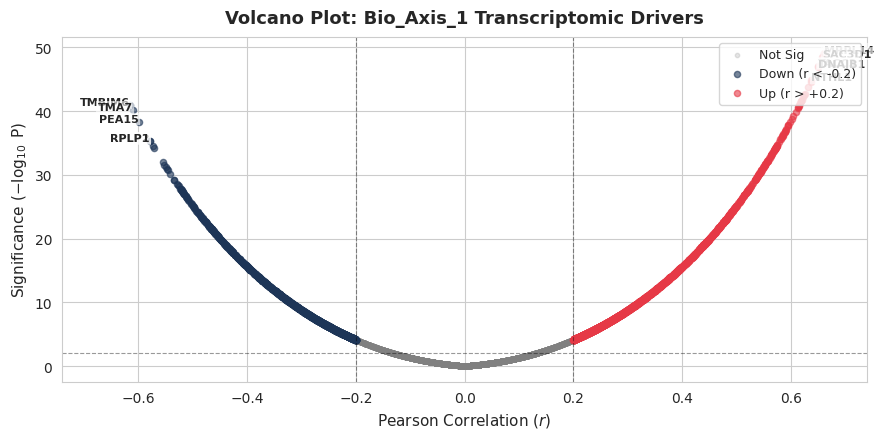


🎯 Bio_Axis_2 | Canonical Correlation ($r$): 0.9528
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ATP6V0B (+0.55), UPP1 (+0.51), CEBPB (+0.50), ATG101 (+0.49), DDIT3 (+0.48)
  ↳ Key Downregulated : TUBA1B (-0.56), LOXL1 (-0.53), TYMS (-0.52), PCLAF (-0.51), SCARA3 (-0.50)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • autophagosome assembly (GO:0000045)                  | NES: +2.29 | FDR: 0.00e+00
     • autophagosome organization (GO:1905037)              | NES: +2.27 | FDR: 0.00e+00
     • phagosome acidification (GO:0090383)                 | NES: +2.25 | FDR: 0.00e+00
     • response to endoplasmic reticulum stress (GO:0034976 | NES: +2.24 | FDR: 0.00e+00
     • intrinsic apoptotic signaling pathway in response to | NES: +2.21 | FDR: 1.02e-03

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • cytoplasmic translation (GO:0002181)                 | NES: -2.72 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein targeting to m | NES: -2.71 | FD

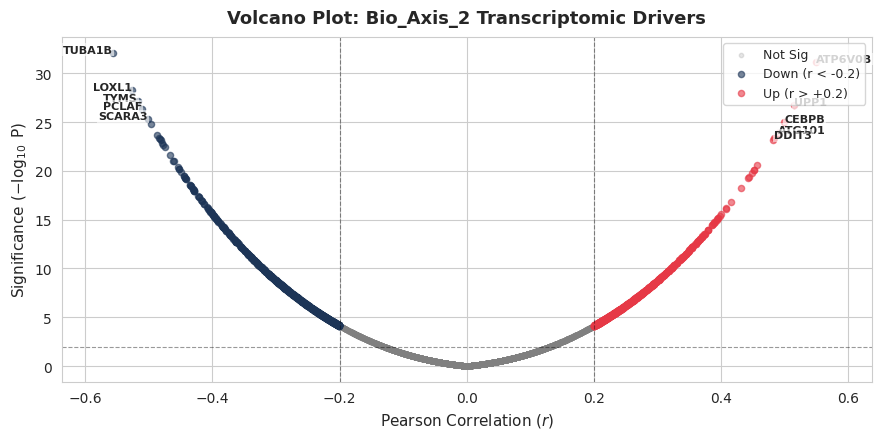


🎯 Bio_Axis_3 | Canonical Correlation ($r$): 0.9496
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : GAST (+0.60), CYP4F2 (+0.60), IRGM (+0.58), MIR7-3HG (+0.56), VN2R19P (+0.56)
  ↳ Key Downregulated : TRIP6 (-0.60), SHISA5 (-0.58), NEK6 (-0.54), SCRN1 (-0.53), RAB34 (-0.52)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • cytoplasmic translation (GO:0002181)                 | NES: +2.35 | FDR: 3.72e-03
     • cotranslational protein targeting to membrane (GO:00 | NES: +2.34 | FDR: 1.86e-03
     • SRP-dependent cotranslational protein targeting to m | NES: +2.34 | FDR: 1.24e-03
     • response to zinc ion (GO:0010043)                    | NES: +2.29 | FDR: 9.29e-04
     • protein targeting to ER (GO:0045047)                 | NES: +2.24 | FDR: 7.43e-04

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • negative regulation of mitotic cell cycle phase tran | NES: -2.39 | FDR: 0.00e+00
     • negative regulation of G2/M transition of mitotic ce | NES: -2.34 | F

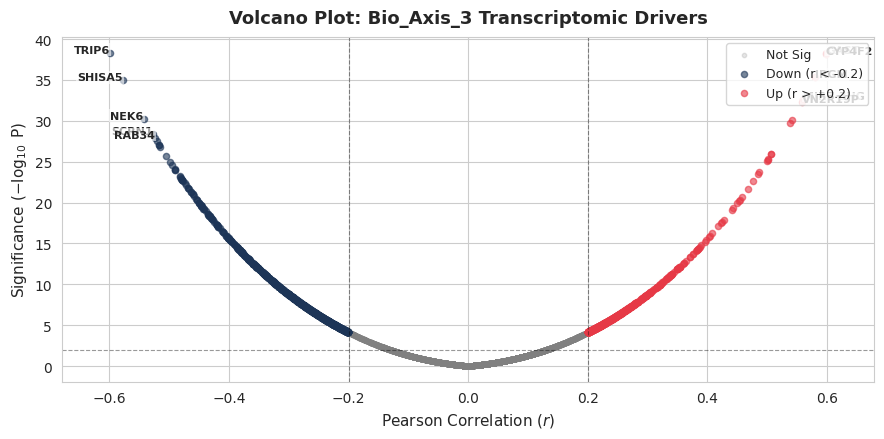


🎯 Bio_Axis_4 | Canonical Correlation ($r$): 0.9336
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : ATP6V0D2 (+0.49), IL1A (+0.35), MMP1 (+0.34), SPINK1 (+0.33), NOP53 (+0.31)
  ↳ Key Downregulated : ID1 (-0.45), CCN2 (-0.39), SPTAN1 (-0.38), FSTL3 (-0.35), CKB (-0.35)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • cotranslational protein targeting to membrane (GO:00 | NES: +2.63 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein targeting to m | NES: +2.60 | FDR: 0.00e+00
     • protein targeting to ER (GO:0045047)                 | NES: +2.54 | FDR: 0.00e+00
     • nuclear-transcribed mRNA catabolic process, nonsense | NES: +2.29 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: +2.21 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • retina homeostasis (GO:0001895)                      | NES: -2.14 | FDR: 1.87e-01
     • regulation of microtubule polymerization or depolyme | NES: -2.10 | FDR: 1.

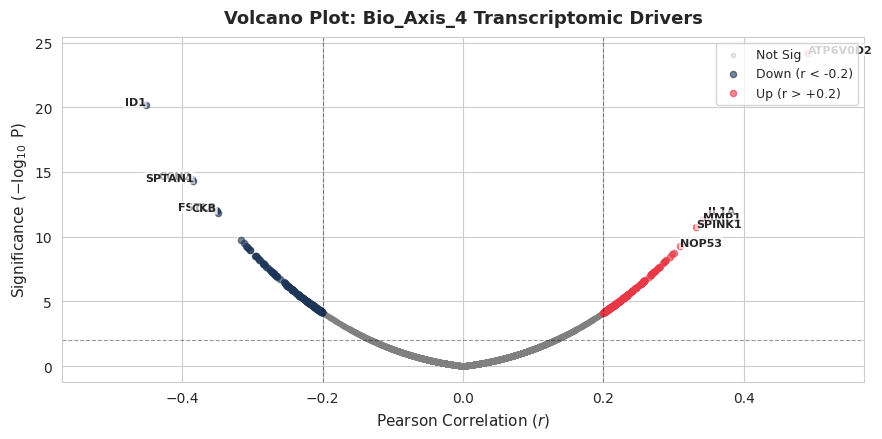


🎯 Bio_Axis_5 | Canonical Correlation ($r$): 0.9096
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : HNRNPD (+0.39), SMG9 (+0.38), MCM3 (+0.38), NDUFS2 (+0.38), CNOT1 (+0.38)
  ↳ Key Downregulated : SNORD3B-2 (-0.43), IER3 (-0.41), CCL2 (-0.38), SNORD3A (-0.38), PHLDA2 (-0.37)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • DNA replication (GO:0006260)                         | NES: +2.67 | FDR: 0.00e+00
     • microtubule cytoskeleton organization involved in mi | NES: +2.59 | FDR: 0.00e+00
     • DNA metabolic process (GO:0006259)                   | NES: +2.53 | FDR: 0.00e+00
     • mitotic spindle organization (GO:0007052)            | NES: +2.50 | FDR: 0.00e+00
     • negative regulation of cell cycle process (GO:001094 | NES: +2.49 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • SRP-dependent cotranslational protein targeting to m | NES: -3.21 | FDR: 0.00e+00
     • cotranslational protein targeting to membrane (GO:00 | NES: -3.16 | 

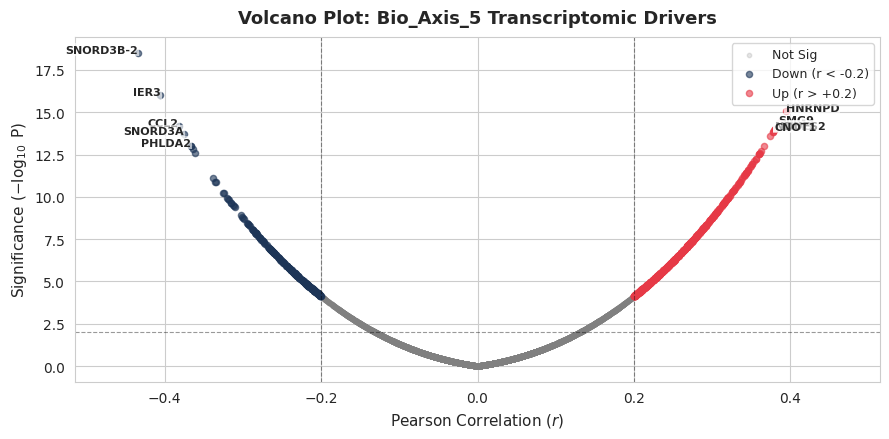


🎯 Bio_Axis_6 | Canonical Correlation ($r$): 0.8971
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CRCT1 (+0.63), SPRR2B (+0.60), SPRR2E (+0.59), LOC101928994 (+0.55), RCSD1 (+0.51)
  ↳ Key Downregulated : TRPV2 (-0.45), SCG2 (-0.41), CXCL2 (-0.37), GOLPH3-DT (-0.35), DHRS9 (-0.34)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • cotranslational protein targeting to membrane (GO:00 | NES: +3.50 | FDR: 0.00e+00
     • SRP-dependent cotranslational protein targeting to m | NES: +3.40 | FDR: 0.00e+00
     • protein targeting to ER (GO:0045047)                 | NES: +3.40 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: +3.36 | FDR: 0.00e+00
     • nuclear-transcribed mRNA catabolic process, nonsense | NES: +3.25 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • negative regulation of transcription by RNA polymera | NES: -1.96 | FDR: 3.35e-01
     • in utero embryonic development (GO:0001701)          | NES: -

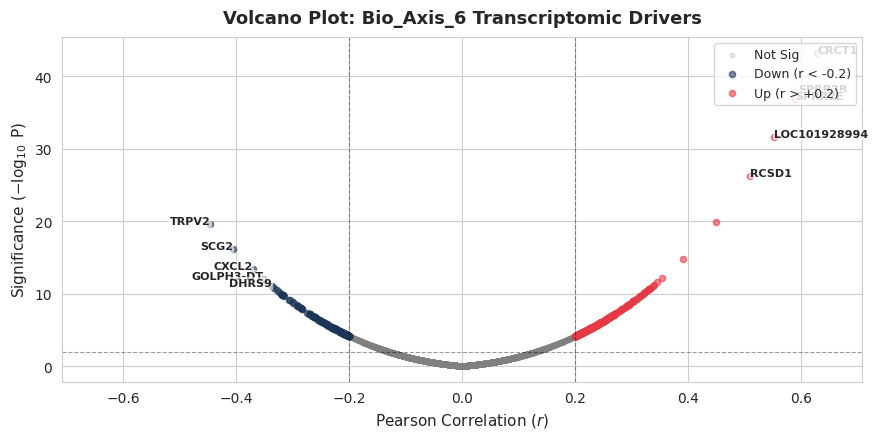


🎯 Bio_Axis_7 | Canonical Correlation ($r$): 0.8787
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CSF3 (+0.52), SGPP2 (+0.48), TRA2B (+0.39), MLC1 (+0.37), VCF1 (+0.36)
  ↳ Key Downregulated : H2BK1 (-0.30), LINC00520 (-0.28), TNFRSF10B-AS1 (-0.27), NPC2 (-0.27), ZNF571 (-0.27)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • RNA splicing, via transesterification reactions with | NES: +2.94 | FDR: 0.00e+00
     • mRNA processing (GO:0006397)                         | NES: +2.94 | FDR: 0.00e+00
     • mRNA splicing, via spliceosome (GO:0000398)          | NES: +2.79 | FDR: 0.00e+00
     • regulation of mRNA splicing, via spliceosome (GO:004 | NES: +2.70 | FDR: 0.00e+00
     • DNA-dependent DNA replication (GO:0006261)           | NES: +2.63 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • glycosphingolipid metabolic process (GO:0006687)     | NES: -2.36 | FDR: 4.05e-03
     • secondary alcohol biosynthetic process (GO:1902653)  | NES: -2.3

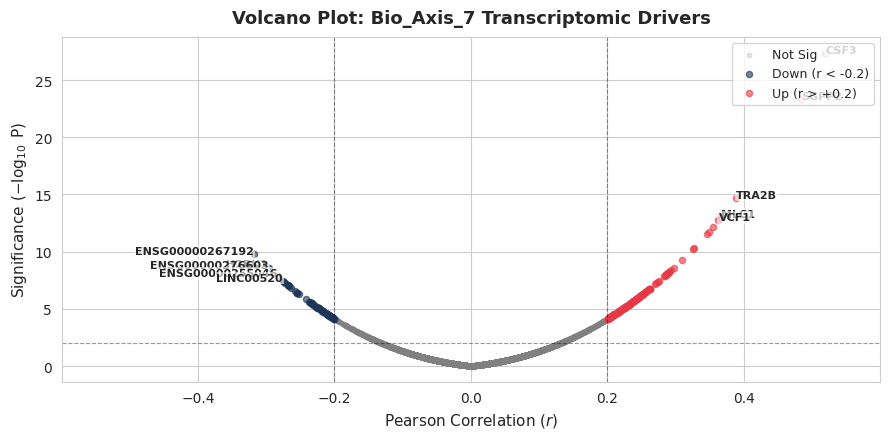


🎯 Bio_Axis_8 | Canonical Correlation ($r$): 0.8657
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : TFDP1 (+0.51), THY1 (+0.48), CRABP2 (+0.45), HNRNPA2B1 (+0.45), GLS (+0.44)
  ↳ Key Downregulated : BRI3 (-0.57), SMIM29 (-0.53), EPB41L4A-AS1 (-0.51), SQSTM1 (-0.50), GLRX (-0.47)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • CENP-A containing nucleosome assembly (GO:0034080)   | NES: +2.54 | FDR: 0.00e+00
     • CENP-A containing chromatin organization (GO:0061641 | NES: +2.54 | FDR: 0.00e+00
     • microtubule cytoskeleton organization involved in mi | NES: +2.53 | FDR: 0.00e+00
     • chromatin remodeling at centromere (GO:0031055)      | NES: +2.51 | FDR: 0.00e+00
     • histone exchange (GO:0043486)                        | NES: +2.46 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • protein targeting to ER (GO:0045047)                 | NES: -2.92 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: -2.9

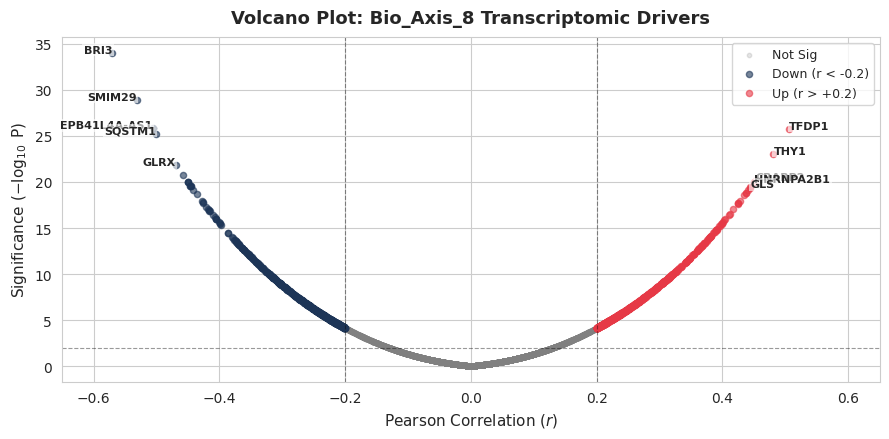


🎯 Bio_Axis_9 | Canonical Correlation ($r$): 0.8456
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : CXCL2 (+0.30), CRCT1 (+0.30), HSPB8 (+0.28), SNX25 (+0.28), CPEB2 (+0.27)
  ↳ Key Downregulated : FLOT1 (-0.35), GPAA1 (-0.34), NDUFV1 (-0.32), SNF8 (-0.32), DCTN3 (-0.31)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • mRNA modification (GO:0016556)                       | NES: +2.09 | FDR: 3.97e-02
     • cellular response to chemokine (GO:1990869)          | NES: +2.04 | FDR: 6.94e-02
     • phosphatidylinositol biosynthetic process (GO:000666 | NES: +1.97 | FDR: 1.29e-01
     • cellular response to vascular endothelial growth fac | NES: +1.96 | FDR: 1.07e-01
     • chemokine-mediated signaling pathway (GO:0070098)    | NES: +1.94 | FDR: 1.26e-01

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • cotranslational protein targeting to membrane (GO:00 | NES: -3.79 | FDR: 0.00e+00
     • protein targeting to ER (GO:0045047)                 | NES: -3.67 | FDR: 

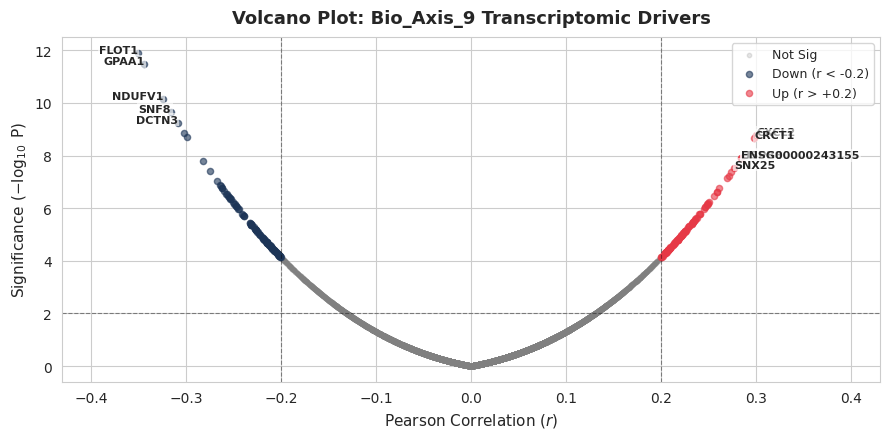


🎯 Bio_Axis_10 | Canonical Correlation ($r$): 0.8204
🧬 TRANSCRIPTIONAL SIGNATURE:
  ↳ Key Upregulated   : HK2 (+0.34), CCT5 (+0.33), CCT4 (+0.32), ZNF207 (+0.31), HSPD1 (+0.29)
  ↳ Key Downregulated : TSTD1 (-0.30), FGFBP3 (-0.29), OXLD1 (-0.29), P4HTM (-0.27), LOC730098 (-0.27)

  🟢 Top 5 Positively Enriched Pathways (Upregulated):
     • ribosome biogenesis (GO:0042254)                     | NES: +3.08 | FDR: 0.00e+00
     • rRNA processing (GO:0006364)                         | NES: +3.08 | FDR: 0.00e+00
     • anaphase-promoting complex-dependent catabolic proce | NES: +2.96 | FDR: 0.00e+00
     • cytoplasmic translation (GO:0002181)                 | NES: +2.96 | FDR: 0.00e+00
     • rRNA metabolic process (GO:0016072)                  | NES: +2.95 | FDR: 0.00e+00

  🔴 Top 5 Negatively Enriched Pathways (Suppressed):
     • negative regulation of axon extension involved in ax | NES: -1.97 | FDR: 4.12e-01
     • kidney development (GO:0001822)                      | NES: -1.95 | FD

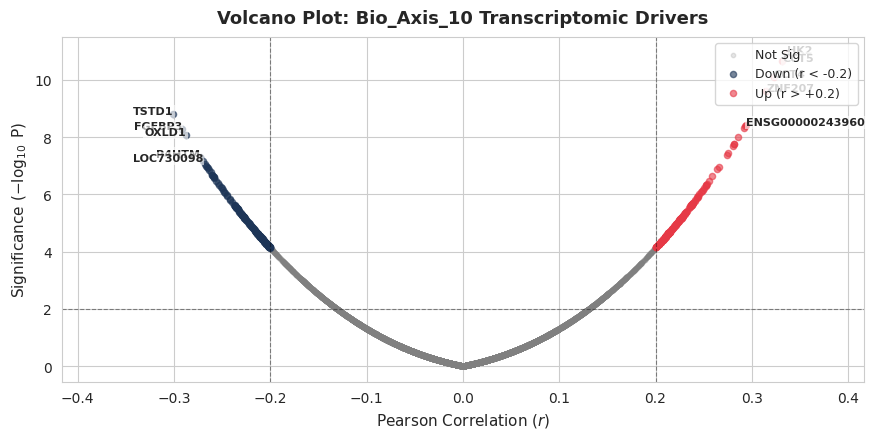


🏁 MINIMOL MULTIMODAL DECODING COMPLETE ACROSS ALL 10 AXES


In [ ]:
# @title
import os
import gc
import re
import warnings
import requests
from collections import Counter
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import mannwhitneyu, t as t_dist

# Auto-install bioinformatics packages if missing
for pkg in ['mygene', 'gseapy']:
    try:
        __import__(pkg)
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import mygene
import gseapy as gp

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & SELF-HEALING HARDWARE SETUP
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cpu')
if torch.cuda.is_available():
    try:
        _test = torch.zeros(1, device='cuda') + 1
        device = torch.device('cuda')
        print(f"⚡ Acceleration Engine: GPU Verified ({torch.cuda.get_device_name(0)})")
    except Exception:
        print(f"⚠️ GPU detected ({torch.cuda.get_device_name(0)}), but PyTorch lacks matching kernel images.")
        print("⚡ Automatically falling back to high-throughput CPU (PyTorch MKL). Executing safely!")
        device = torch.device('cpu')
else:
    print("⚡ Running on CPU.")

# ==============================================================================
# 🌐 1. UPGRADED 3-TIER ANNOTATION ENGINE (PubChem + ChEMBL Block-1 Rescue)
# ==============================================================================
ANNOTATION_CACHE = {}

def get_rich_compound_annotation(inchikey):
    """
    3-Tier Annotation Engine:
    1. PubChem Synonyms (captures research codes & generic names)
    2. ChEMBL with Part II Block-1 Rescue (startswith[:14])
    3. ChEMBL IC50 Potency Targets (< 500nM) for non-clinical tool compounds
    """
    if inchikey in ANNOTATION_CACHE:
        return ANNOTATION_CACHE[inchikey]

    name = "Unknown"
    moa = "Unannotated"
    cid = None

    # --- TIER 1: PubChem Synonyms (Best for developmental codes & drug names) ---
    try:
        url_syn = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/synonyms/JSON"
        r = requests.get(url_syn, timeout=4)
        if r.status_code == 200:
            info = r.json().get('InformationList', {}).get('Information', [{}])[0]
            cid = info.get('CID')
            synonyms = info.get('Synonym', [])

            for s in synonyms[:15]:
                if not re.match(r'^\d+-\d+-\d+$', s) and len(s) > 2:
                    if not any(s.startswith(prefix) for prefix in ['SCHEMBL', 'CHEMBL', 'AKOS', 'CS-', 'EN300']):
                        name = s
                        break
    except Exception:
        pass

    # --- TIER 2: ChEMBL with Part II Block 1 Rescue ---
    chembl_id = None
    try:
        url_chembl = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key={inchikey}"
        r = requests.get(url_chembl, timeout=4)
        mols = r.json().get('molecules', []) if r.status_code == 200 else []

        # Block 1 Rescue (First 14 chars) if exact match fails
        if not mols and len(inchikey) >= 14:
            b1 = inchikey[:14]
            url_b1 = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__standard_inchi_key__startswith={b1}"
            r = requests.get(url_b1, timeout=4)
            mols = r.json().get('molecules', []) if r.status_code == 200 else []

        if mols:
            mol = mols[0]
            chembl_id = mol.get('molecule_chembl_id')
            if name == "Unknown" and mol.get('pref_name'):
                name = mol.get('pref_name')

            # Check curated clinical mechanism
            url_mech = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
            r_m = requests.get(url_mech, timeout=4)
            if r_m.status_code == 200:
                mechs = r_m.json().get('mechanisms', [])
                if mechs:
                    moa = mechs[0].get('mechanism_of_action')

            # --- TIER 3: ChEMBL Bioactivity Target Fallback (< 500nM) ---
            if moa == "Unannotated" and chembl_id:
                url_act = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?molecule_chembl_id={chembl_id}&standard_type=IC50&standard_value__lte=500&limit=1"
                r_a = requests.get(url_act, timeout=4)
                if r_a.status_code == 200:
                    acts = r_a.json().get('activities', [])
                    if acts and acts[0].get('target_pref_name'):
                        target = acts[0].get('target_pref_name')
                        moa = f"{target} inhibitor (IC50 < 500nM)"
    except Exception:
        pass

    ANNOTATION_CACHE[inchikey] = (name, moa)
    return name, moa

# ==============================================================================
# ⚙️ 2. CONFIGURATION & RESTORATION OF LEADERBOARD WINNER
# ==============================================================================
MERGE_KEY = "InChIKey"
NUM_AXES_TO_ANALYZE = 10
MINIMOL_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__full_final.parquet"
LOCAL_MINIMOL_CACHE = "cached_minimol_embeddings_full_final.parquet"
RNA_CACHE = "cached_drugseq_24_48h.parquet"

top_model_name = leaderboard_df.iloc[0]["Model / Processing"]
top_score = leaderboard_df.iloc[0]["SVCCA Mean (AUC)"]

print("="*95)
print(f"🏆 DECODING WINNING MODEL: [{top_model_name}] (SVCCA Mean AUC: {top_score:.4f})")
print(f"🔬 Structural Target Space: Minimol 512D Pre-Computed Parquet")
print(f"🎯 Decoding Horizon: Top {NUM_AXES_TO_ANALYZE} Biological Axes")
print("="*95)

conn = duckdb.connect()

# 2A. Load Winner Morphology & Apply Median Replicate Aggregation
winner_cache = f"cached_{top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')}.parquet"
print(f"📂 Loading winner morphology from: {winner_cache}...")
morph_df = conn.execute(f"SELECT * FROM read_parquet('{winner_cache}')").df()

for col in morph_df.columns:
    if 'inchikey' in col.lower():
        morph_df = morph_df.rename(columns={col: MERGE_KEY})
        break

group_cols = [MERGE_KEY]
for candidates in [
    ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
    ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
    ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
]:
    for c in candidates:
        if c in morph_df.columns and c not in group_cols:
            group_cols.append(c)
            break

morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                  if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + group_cols]

raw_wells = len(morph_df)
morph_df = morph_df.groupby(group_cols, as_index=False, dropna=False)[morph_features].median()
morph_df = morph_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)
print(f"  ↳ Consolidated {raw_wells} morphology wells into {len(morph_df)} median treatment profiles.")

# 2B. Ensure drugseq_pooled is in memory
if 'drugseq_pooled' not in globals():
    print(f"📂 Reloading DRUG-seq pooled from cache: {RNA_CACHE}...")
    drugseq_raw = conn.execute(f"SELECT * FROM read_parquet('{RNA_CACHE}')").df()
    for col in drugseq_raw.columns:
        if 'inchikey' in col.lower():
            drugseq_raw = drugseq_raw.rename(columns={col: MERGE_KEY})
            break
    d_features = [c for c in drugseq_raw.select_dtypes(include=[np.number]).columns
                  if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]
    grouped = drugseq_raw.groupby(MERGE_KEY)[d_features]
    def pool_func(x):
        idx = np.argmax(np.abs(x.values), axis=0)
        return x.values[idx, np.arange(x.shape[1])]
    drugseq_pooled = pd.DataFrame(grouped.apply(pool_func).tolist(),
                                  index=grouped.apply(pool_func).index,
                                  columns=d_features).reset_index()
    drugseq_features = d_features

# 2C. Load Minimol Parquet Directly
if not os.path.exists(LOCAL_MINIMOL_CACHE):
    print("📥 Streaming Minimol Parquet from GCS to local cache...")
    gcs = GcsFileSystem()
    minimol_path = MINIMOL_URI.replace("gs://", "")
    minimol_ds = ds.dataset(minimol_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM minimol_ds) TO '{LOCAL_MINIMOL_CACHE}' (FORMAT PARQUET)")

minimol_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_MINIMOL_CACHE}')").df()
conn.close()

if 'Metadata_InChIKey_x' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_x': MERGE_KEY})
elif 'Metadata_InChIKey_y' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_y': MERGE_KEY})
else:
    for col in minimol_df.columns:
        if 'inchikey' in col.lower():
            minimol_df = minimol_df.rename(columns={col: MERGE_KEY})
            break

minimol_features = [c for c in minimol_df.columns if c.startswith('Mini_Dim_')]
if len(minimol_features) == 0:
    minimol_features = [c for c in minimol_df.select_dtypes(include=[np.number]).columns
                        if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid']]

minimol_matrix = np.nan_to_num(minimol_df[minimol_features].values.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
minimol_df[minimol_features] = minimol_matrix

valid_mask = np.linalg.norm(minimol_matrix, axis=1) > 1e-6
minimol_df = minimol_df[valid_mask].copy()
minimol_df = minimol_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)
print(f"✅ Minimol ready: {len(minimol_df)} unique molecules with {len(minimol_features)} dimensions.")

# ==============================================================================
# ⚡ 3. EXACT CLOSED-FORM SVCCA PROJECTION
# ==============================================================================
aligned_df = pd.merge(morph_df, drugseq_pooled, on=MERGE_KEY, how="inner")
aligned_df = aligned_df.sort_values(by=group_cols, kind='stable').reset_index(drop=True)

X_m = torch.tensor(np.nan_to_num(aligned_df[morph_features].values.astype(np.float64)), device=device)
Y_r = torch.tensor(np.nan_to_num(aligned_df[drugseq_features].values.astype(np.float64)), device=device)
active_inchikeys = aligned_df[MERGE_KEY].values

k_decomp = min(50, int(len(aligned_df) * 0.8))

X_m = X_m - X_m.mean(dim=0)
Y_r = Y_r - Y_r.mean(dim=0)

def get_exact_basis_deterministic(M, k):
    G = torch.matmul(M, M.T)
    eigvals, eigvecs = torch.linalg.eigh(G)
    idx = torch.argsort(eigvals, descending=True)[:k]
    U_k = eigvecs[:, idx]
    max_idx = torch.argmax(torch.abs(U_k), dim=0)
    col_signs = torch.sign(U_k[max_idx, range(k)])
    col_signs[col_signs == 0] = 1.0
    return U_k * col_signs

Qa = get_exact_basis_deterministic(X_m, k_decomp)
Qb = get_exact_basis_deterministic(Y_r, k_decomp)

U, S, Vt = torch.linalg.svd(torch.matmul(Qa.T, Qb))

max_abs_cols = torch.argmax(torch.abs(U), dim=0)
signs = torch.sign(U[max_abs_cols, range(U.shape[1])])
signs[signs == 0] = 1.0
U = U * signs

bio_canonical_scores = torch.matmul(Qa, U[:, :NUM_AXES_TO_ANALYZE]).cpu().numpy()
axis_cols = [f'Bio_Axis_{i+1}' for i in range(NUM_AXES_TO_ANALYZE)]
bio_scores_df = pd.DataFrame(bio_canonical_scores, columns=axis_cols)
bio_scores_df[MERGE_KEY] = active_inchikeys

print(f"✅ Projection Complete: {len(aligned_df)} consensus treatments projected onto {NUM_AXES_TO_ANALYZE} axes.")

# ==============================================================================
# 🧬 4. MAP GENE SYMBOLS (MYGENE)
# ==============================================================================
print("Querying MyGene for official HGNC symbols...")
mg = mygene.MyGeneInfo()
clean_ensembl_ids = [g.split('.')[0] for g in drugseq_features]
gene_info = mg.querymany(clean_ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False)
ensembl_to_symbol = {h['query']: h['symbol'] for h in gene_info if 'query' in h and 'symbol' in h}
print(f"✅ Mapped {len(ensembl_to_symbol)} of {len(drugseq_features)} genes.")

# ==============================================================================
# 🔍 5. UNIFIED MULTIMODAL AXIS DECODER (MINIMOL + RNA + 3-TIER ANNOTATION)
# ==============================================================================
merged_all = pd.merge(bio_scores_df, drugseq_pooled, on=MERGE_KEY, how='inner')
merged_all = merged_all.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

# 💡 FIX 1: Sanitize RNA matrix upfront so NaNs never infect the covariance math
clean_rna_matrix = np.nan_to_num(merged_all[drugseq_features].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
all_genes_tensor = torch.tensor(clean_rna_matrix, device=device)
Y_c_genes = all_genes_tensor - all_genes_tensor.mean(dim=0)
var_Y_genes = torch.sum(Y_c_genes ** 2, dim=0)

for axis_idx in range(NUM_AXES_TO_ANALYZE):
    axis_name = f'Bio_Axis_{axis_idx+1}'
    canonical_corr = S[axis_idx].item()

    print("\n" + "="*95)
    print(f"🎯 {axis_name} | Canonical Correlation ($r$): {canonical_corr:.4f}")
    print("="*95)

    # -------------------------------------------------------------------------
    # PART A: TRANSCRIPTIONAL DECODING (Pearson r + GSEA)
    # -------------------------------------------------------------------------
    axis_tensor = torch.tensor(merged_all[axis_name].values.astype(np.float64), device=device)
    X_c_axis = axis_tensor - axis_tensor.mean()
    var_X_axis = torch.sum(X_c_axis ** 2)

    cov = torch.matmul(X_c_axis, Y_c_genes)
    r_tensor = cov / torch.sqrt(var_X_axis * var_Y_genes + 1e-12)

    n_samples = len(merged_all)
    r_clipped = torch.clamp(r_tensor, -0.9999, 0.9999)
    t_stat = r_clipped * torch.sqrt((n_samples - 2) / (1.0 - r_clipped**2))

    r_vals = r_tensor.cpu().numpy()
    t_vals = t_stat.cpu().numpy()
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n_samples - 2)
    neg_log10_p = -np.log10(p_vals + 1e-300)

    symbols = [ensembl_to_symbol.get(g.split('.')[0], g) for g in drugseq_features]
    gene_df = pd.DataFrame({
        'Ensembl_ID': drugseq_features,
        'Gene_Symbol': symbols,
        'Correlation': r_vals,
        'P_Value': p_vals,
        'Neg_Log10_P': neg_log10_p
    })

    # 💡 FIX 2: Explicitly drop any remaining NaNs so they never pollute the head or tail!
    valid_genes = gene_df.dropna(subset=['Correlation']).copy()
    valid_genes = valid_genes[~valid_genes['Gene_Symbol'].str.startswith('ENSG')].copy()
    valid_genes['abs_corr'] = valid_genes['Correlation'].abs()

    dedup_ranks = valid_genes.sort_values(by=['abs_corr', 'Gene_Symbol'], ascending=[False, True], kind='stable').drop_duplicates('Gene_Symbol')
    rnk_input = dedup_ranks[['Gene_Symbol', 'Correlation']].sort_values(by=['Correlation', 'Gene_Symbol'], ascending=[False, True], kind='stable')

    top_pos_genes = rnk_input.head(5)
    top_neg_genes = rnk_input.tail(5).iloc[::-1]

    print("🧬 TRANSCRIPTIONAL SIGNATURE:")
    print(f"  ↳ Key Upregulated   : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_pos_genes.iterrows()]))
    print(f"  ↳ Key Downregulated : " + ", ".join([f"{r.Gene_Symbol} ({r.Correlation:+.2f})" for _, r in top_neg_genes.iterrows()]))

    # GSEA Prerank
    try:
        pre_res = gp.prerank(
            rnk=rnk_input,
            gene_sets='GO_Biological_Process_2021',
            threads=1,
            min_size=10,
            max_size=500,
            permutation_num=200,
            outdir=None,
            seed=42
        )
        res_df = pre_res.res2d
        top_pos_pw = res_df[res_df['NES'] > 0].sort_values(by='NES', ascending=False, kind='stable').head(5)
        top_neg_pw = res_df[res_df['NES'] < 0].sort_values(by='NES', ascending=True, kind='stable').head(5)

        print("\n  🟢 Top 5 Positively Enriched Pathways (Upregulated):")
        if len(top_pos_pw) > 0:
            for _, r_pw in top_pos_pw.iterrows():
                print(f"     • {r_pw['Term'][:52]:<52} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")

        print("\n  🔴 Top 5 Negatively Enriched Pathways (Suppressed):")
        if len(top_neg_pw) > 0:
            for _, r_pw in top_neg_pw.iterrows():
                print(f"     • {r_pw['Term'][:52]:<52} | NES: {r_pw['NES']:+.2f} | FDR: {r_pw['FDR q-val']:.2e}")
        else:
            print("     • (None detected)")
    except Exception as e:
        print(f"  ↳ GSEA note: {e}")

    # -------------------------------------------------------------------------
    # PART B: MINIMOL STRUCTURAL CLUSTERING & 3-TIER COMPOUND ANNOTATION
    # -------------------------------------------------------------------------
    merged_struct = pd.merge(bio_scores_df[[MERGE_KEY, axis_name]], minimol_df, on=MERGE_KEY, how='inner')
    merged_struct = merged_struct.sort_values(by=[axis_name, MERGE_KEY], ascending=[False, True], kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first')

    scores = merged_struct[axis_name].values
    cutoff = np.mean(scores) + (2.0 * np.std(scores))
    top_drivers = merged_struct[merged_struct[axis_name] > cutoff].copy()
    if len(top_drivers) < 5:
        top_drivers = merged_struct.head(15).copy()

    k_drivers = len(top_drivers)

    drivers_tensor = torch.tensor(top_drivers[minimol_features].values.astype(np.float32), device=device)
    random_group = merged_struct.sample(n=k_drivers, random_state=42)
    random_tensor = torch.tensor(random_group[minimol_features].values.astype(np.float32), device=device)

    def get_pairwise_sims(tensor):
        normed = torch.nn.functional.normalize(tensor, p=2, dim=1)
        sim_mat = torch.matmul(normed, normed.T)
        k = tensor.shape[0]
        triu_indices = torch.triu_indices(k, k, offset=1, device=device)
        return sim_mat[triu_indices[0], triu_indices[1]].cpu().numpy()

    driver_sims = get_pairwise_sims(drivers_tensor)
    random_sims = get_pairwise_sims(random_tensor)

    mean_driver_sim = np.mean(driver_sims)
    mean_random_sim = np.mean(random_sims)

    _, p_val = mannwhitneyu(driver_sims, random_sims, alternative='greater')
    fold_change = mean_driver_sim / (mean_random_sim + 1e-8)

    print("\n🧪 MINIMOL 2D STRUCTURAL SIGNATURE:")
    print(f"  ↳ Driver Compounds Evaluated : {k_drivers} unique molecules")
    print(f"  ↳ Mean Minimol Cosine Sim    : Drivers = {mean_driver_sim:.4f} | Background = {mean_random_sim:.4f}")
    print(f"  ↳ Enrichment Fold Change     : {fold_change:.2f}x (Mann-Whitney p = {p_val:.2e})")

    if p_val < 0.01 and fold_change > 1.02:
        verdict = "✅ DISTINCT 2D PHARMACOPHORE CLUSTER (Rigid Chemical Scaffold)"
    elif p_val < 0.05:
        verdict = "⚠️ WEAK STRUCTURAL CLUSTERING (Shared Sub-structure / Heterogeneous Series)"
    else:
        verdict = "💡 DIVERSE 2D CHEMISTRY (Scaffold Hopping / Phenotypic Convergence)"
    print(f"  ↳ Structural Verdict         : {verdict}")

    # 3-TIER AUTO-ANNOTATION READOUT
    top_keys = top_drivers.head(5)[MERGE_KEY].tolist()
    top_scores = top_drivers.head(5)[axis_name].tolist()

    print("\n  ↳ Top 5 Driving Compounds (Auto-Annotated via PubChem / ChEMBL):")
    moa_list = []

    for rank, (ikey, sc) in enumerate(zip(top_keys, top_scores), 1):
        name, moa = get_rich_compound_annotation(ikey)
        if moa != "Unannotated":
            moa_list.append(moa)
        print(f"     {rank}. {name:<22} | {moa:<38} | Score: {sc:+.3f} | {ikey}")

    # Detect Consensus Mechanism
    if moa_list:
        most_common_moa, count = Counter(moa_list).most_common(1)[0]
        if count >= 2:
            print(f"  🎯 CONSENSUS MECHANISM FOUND: '{most_common_moa}' ({count}/{len(top_keys)} compounds share this)")
        else:
            print(f"  💡 TARGET DIVERSITY: Multiple distinct targets annotated ({', '.join(set(moa_list))})")
    else:
        print("  ⚠️ NO CURATED TARGETS: Compounds may be novel unannotated screening hits.")

    # -------------------------------------------------------------------------
    # PART C: COMPACT VOLCANO PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 4.5), dpi=100)
    sns.set_style("whitegrid")
    r_thresh, p_thresh = 0.20, 0.01
    p_log_thresh = -np.log10(p_thresh)

    up_sig = gene_df[(gene_df['Correlation'] > r_thresh) & (gene_df['P_Value'] < p_thresh)]
    down_sig = gene_df[(gene_df['Correlation'] < -r_thresh) & (gene_df['P_Value'] < p_thresh)]
    not_sig = gene_df[(np.abs(gene_df['Correlation']) <= r_thresh) | (gene_df['P_Value'] >= p_thresh)]

    plt.scatter(not_sig['Correlation'], not_sig['Neg_Log10_P'], color='gray', alpha=0.2, s=10, label='Not Sig')
    plt.scatter(down_sig['Correlation'], down_sig['Neg_Log10_P'], color='#1D3557', alpha=0.6, s=20, label=f'Down (r < -{r_thresh})')
    plt.scatter(up_sig['Correlation'], up_sig['Neg_Log10_P'], color='#E63946', alpha=0.6, s=20, label=f'Up (r > +{r_thresh})')

    top_label = pd.concat([
        up_sig.sort_values(by='Correlation', ascending=False, kind='stable').head(5),
        down_sig.sort_values(by='Correlation', ascending=True, kind='stable').head(5)
    ])

    for _, r_lbl in top_label.iterrows():
        plt.text(r_lbl['Correlation'], r_lbl['Neg_Log10_P'], r_lbl['Gene_Symbol'],
                 fontsize=8, fontweight='bold', ha='left' if r_lbl['Correlation'] > 0 else 'right',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    plt.axvline(x=r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axvline(x=-r_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.axhline(y=p_log_thresh, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    max_c = max(np.abs(gene_df['Correlation'].min()), np.abs(gene_df['Correlation'].max()))
    plt.xlim(-max_c - 0.08, max_c + 0.08)
    plt.title(f'Volcano Plot: {axis_name} Transcriptomic Drivers', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Pearson Correlation ($r$)', fontsize=11)
    plt.ylabel('Significance ($-\\log_{10}$ P)', fontsize=11)
    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

print("\n" + "="*95)
print("🏁 MINIMOL MULTIMODAL DECODING COMPLETE ACROSS ALL 10 AXES")
print("="*95)

# How do aligned axis compare across individual modalities?

In [ ]:
# @title
import os
import gc
import warnings
import numpy as np
import pandas as pd
import duckdb
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
import torch
from scipy.stats import hypergeom

warnings.filterwarnings('ignore')

# ==============================================================================
# 🛡️ 0. SEED SYNCHRONIZATION & HARDWARE SETUP
# ==============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Acceleration Engine: {device}")

# ==============================================================================
# ⚙️ 1. PARQUET SOURCES & DYNAMIC WINNER RESTORATION
# ==============================================================================
MERGE_KEY = "InChIKey"
K_NEIGHBORS = 10        # Top k nearest neighbors to evaluate per space
NUM_AXES_TO_EVAL = 3    # Evaluate drivers for Top 3 SVCCA axes

# Source URIs & Caches
top_model_name = leaderboard_df.iloc[0]["Model / Processing"] if 'leaderboard_df' in globals() else "DINO (Normed + Actives)"
MORPH_CACHE = f"cached_{top_model_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')}.parquet"
RNA_CACHE = "cached_drugseq_24_48h.parquet"

MINIMOL_URI = "gs://calico-reference-embeddings/Annotations_from_Roman/Bayer_data_harmonized/minimol_embeddings/minimol_embeddings__full_final.parquet"
LOCAL_MINIMOL_CACHE = "cached_minimol_embeddings_full_final.parquet"

CC_URI = "gs://calico-reference-embeddings/embeddings/Chemical_Checker_Embeddings/JUMP_CP_Global_Signatures_full.parquet"
LOCAL_CC_CACHE = "cached_chemchecker_embeddings.parquet"

print("="*95)
print(f"🚀 INGESTING PARQUET SOURCES FOR MULTIMODAL LOCAL TOPOLOGY SWEEP")
print(f"  ↳ Morphology Winner : {MORPH_CACHE}")
print(f"  ↳ Transcriptomics   : {RNA_CACHE}")
print(f"  ↳ Chemistry (2D)    : {LOCAL_MINIMOL_CACHE}")
print(f"  ↳ Chemistry (Target): {LOCAL_CC_CACHE}")
print("="*95)

conn = duckdb.connect()
gcs = GcsFileSystem()

# ------------------------------------------------------------------------------
# 2. INGEST & HARMONIZE ALL 4 MODALITIES
# ------------------------------------------------------------------------------
# A. Morphology (with Median Replicate Aggregation)
morph_df = conn.execute(f"SELECT * FROM read_parquet('{MORPH_CACHE}')").df()
for col in morph_df.columns:
    if 'inchikey' in col.lower():
        morph_df = morph_df.rename(columns={col: MERGE_KEY})
        break

group_cols = [MERGE_KEY]
for candidates in [
    ['concentration', 'Metadata_Concentration', 'pert_dose', 'pert_dose_uM', 'dose'],
    ['Metadata_Time', 'pert_time', 'pert_time_h', 'time', 'timepoint'],
    ['Metadata_cell_line', 'Metadata_CellLine', 'Metadata_cell_type', 'cell_line', 'cell_type']
]:
    for c in candidates:
        if c in morph_df.columns and c not in group_cols:
            group_cols.append(c)
            break

morph_features = [c for c in morph_df.select_dtypes(include=[np.number]).columns
                  if not c.startswith('Metadata_') and c not in [MERGE_KEY, 'pubchem_cid'] + group_cols]

morph_df = morph_df.groupby(group_cols, as_index=False, dropna=False)[morph_features].median()
morph_df = morph_df.sort_values(by=group_cols, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)

# B. Transcriptomics (DRUG-seq Max-Abs Pooled)
drugseq_raw = conn.execute(f"SELECT * FROM read_parquet('{RNA_CACHE}')").df()
for col in drugseq_raw.columns:
    if 'inchikey' in col.lower():
        drugseq_raw = drugseq_raw.rename(columns={col: MERGE_KEY})
        break

d_features = [c for c in drugseq_raw.select_dtypes(include=[np.number]).columns
              if c not in [MERGE_KEY, 'pubchem_cid', 'pert_time_h', 'pert_dose_uM']]

# Keep top 5,000 responsive genes
gene_var = drugseq_raw[d_features].var(axis=0)
drugseq_features = gene_var.nlargest(min(5000, len(d_features))).index.tolist()

grouped_rna = drugseq_raw.groupby(MERGE_KEY)[drugseq_features]
def pool_func(x):
    idx = np.argmax(np.abs(x.values), axis=0)
    return x.values[idx, np.arange(x.shape[1])]
drugseq_pooled = pd.DataFrame(grouped_rna.apply(pool_func).tolist(),
                              index=grouped_rna.apply(pool_func).index,
                              columns=drugseq_features).reset_index()

# C. Chemistry 2D: Minimol Parquet
if not os.path.exists(LOCAL_MINIMOL_CACHE):
    print("Streaming Minimol Parquet from GCS...")
    m_path = MINIMOL_URI.replace("gs://", "")
    m_ds = ds.dataset(m_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM m_ds) TO '{LOCAL_MINIMOL_CACHE}' (FORMAT PARQUET)")

minimol_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_MINIMOL_CACHE}')").df()

if 'Metadata_InChIKey_x' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_x': MERGE_KEY})
elif 'Metadata_InChIKey_y' in minimol_df.columns:
    minimol_df = minimol_df.rename(columns={'Metadata_InChIKey_y': MERGE_KEY})

minimol_features = [c for c in minimol_df.columns if c.startswith('Mini_Dim_')]
m_mat = np.nan_to_num(minimol_df[minimol_features].values.astype(np.float32), nan=0.0)
minimol_df[minimol_features] = m_mat
minimol_df = minimol_df[np.linalg.norm(m_mat, axis=1) > 1e-6].copy()
minimol_df = minimol_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)

# D. Chemistry Target: Chemical Checker Parquet
if not os.path.exists(LOCAL_CC_CACHE):
    print("Streaming Chemical Checker Parquet from GCS...")
    cc_path = CC_URI.replace("gs://", "")
    cc_ds = ds.dataset(cc_path, filesystem=gcs, format="parquet")
    conn.execute(f"COPY (SELECT * FROM cc_ds) TO '{LOCAL_CC_CACHE}' (FORMAT PARQUET)")

cc_df = conn.execute(f"SELECT * FROM read_parquet('{LOCAL_CC_CACHE}')").df()
conn.close()

for col in cc_df.columns:
    if 'inchikey' in col.lower():
        cc_df = cc_df.rename(columns={col: MERGE_KEY})
        break

cc_features = [c for c in cc_df.select_dtypes(include=[np.number]).columns if c not in [MERGE_KEY, 'pubchem_cid']]
cc_mat = np.nan_to_num(cc_df[cc_features].values.astype(np.float32), nan=0.0)
cc_df[cc_features] = cc_mat
cc_df = cc_df[np.linalg.norm(cc_mat, axis=1) > 1e-6].copy()
cc_df = cc_df.sort_values(by=MERGE_KEY, kind='stable').drop_duplicates(subset=[MERGE_KEY], keep='first').reset_index(drop=True)

# E. Complete 4-Way Inner Join (Guarantees identical cohort of compounds)
aligned_df = pd.merge(morph_df, drugseq_pooled, on=MERGE_KEY, how="inner")
aligned_df = pd.merge(aligned_df, minimol_df[[MERGE_KEY] + minimol_features], on=MERGE_KEY, how="inner")
aligned_df = pd.merge(aligned_df, cc_df[[MERGE_KEY] + cc_features], on=MERGE_KEY, how="inner")
aligned_df = aligned_df.sort_values(by=MERGE_KEY, kind='stable').reset_index(drop=True)

N_total = len(aligned_df)
shared_inchikeys = aligned_df[MERGE_KEY].values
print(f"✅ 4-Way Parquet Harmonization Complete: {N_total} compounds shared across all modalities.\n")

# Extract Raw Modality Matrices
X_morph_raw = np.nan_to_num(aligned_df[morph_features].values.astype(np.float32))
Y_rna_raw   = np.nan_to_num(aligned_df[drugseq_features].values.astype(np.float32))
Z_mini_raw  = np.nan_to_num(aligned_df[minimol_features].values.astype(np.float32))
Z_cc_raw    = np.nan_to_num(aligned_df[cc_features].values.astype(np.float32))

# ==============================================================================
# ⚡ 3. EXACT CLOSED-FORM SVCCA TO OBTAIN BIOLOGICAL AXES
# ==============================================================================
X_m = torch.tensor(X_morph_raw.astype(np.float64), device=device)
Y_r = torch.tensor(Y_rna_raw.astype(np.float64), device=device)
X_m = X_m - X_m.mean(dim=0)
Y_r = Y_r - Y_r.mean(dim=0)

k_decomp = min(50, int(N_total * 0.8))

def get_exact_basis_deterministic(M, k):
    G = torch.matmul(M, M.T)
    eigvals, eigvecs = torch.linalg.eigh(G)
    idx = torch.argsort(eigvals, descending=True)[:k]
    U_k = eigvecs[:, idx]
    max_idx = torch.argmax(torch.abs(U_k), dim=0)
    col_signs = torch.sign(U_k[max_idx, range(k)])
    col_signs[col_signs == 0] = 1.0
    return U_k * col_signs

Qa = get_exact_basis_deterministic(X_m, k_decomp)
Qb = get_exact_basis_deterministic(Y_r, k_decomp)
U, S, Vt = torch.linalg.svd(torch.matmul(Qa.T, Qb))

max_abs_cols = torch.argmax(torch.abs(U), dim=0)
signs = torch.sign(U[max_abs_cols, range(U.shape[1])])
signs[signs == 0] = 1.0
U = U * signs

bio_canonical_scores = torch.matmul(Qa, U[:, :NUM_AXES_TO_EVAL]).cpu().numpy()

# ==============================================================================
# 🔬 4. MULTIMODAL LOCAL TOPOLOGY EVALUATION ENGINE
# ==============================================================================
def evaluate_driver_neighborhoods(
    driver_inchikeys,
    all_inchikeys,
    modalities_dict,
    k_neighbors=10
):
    """
    Implements Part IV.2 (Deduplicated kNN Sweep) and Part IV.3 (mAP)
    across all physical representation spaces.
    """
    driver_set = set(driver_inchikeys)
    N = len(all_inchikeys)
    n_drivers = len(driver_set)

    is_driver = np.array([ikey in driver_set for ikey in all_inchikeys])
    driver_indices = np.where(is_driver)[0]

    total_possible_pairs = N * (N - 1) // 2
    driver_possible_pairs = n_drivers * (n_drivers - 1) // 2

    results = []

    for mod_name, embs_np in modalities_dict.items():
        # 1. Pairwise Cosine Similarity on GPU
        embs_t = torch.tensor(embs_np, device=device, dtype=torch.float32)
        normed = torch.nn.functional.normalize(embs_t, p=2, dim=1)
        sim_matrix_t = torch.matmul(normed, normed.T)

        # Zero-out self-similarity
        sim_matrix_t.fill_diagonal_(-1.0)

        # Extract top k neighbors per compound
        _, top_k_indices_t = torch.topk(sim_matrix_t, k=k_neighbors, dim=1)
        top_k_indices = top_k_indices_t.cpu().numpy()
        sim_matrix = sim_matrix_t.cpu().numpy()

        # 2. Part IV.2: Deduplicated Undirected Graph Transform
        sources = np.repeat(np.arange(N), k_neighbors)
        targets = top_k_indices.flatten()

        # Force min on left, max on right to shatter A->B vs B->A double-counting
        edge_left = np.minimum(sources, targets)
        edge_right = np.maximum(sources, targets)
        unique_edges = np.unique(np.column_stack([edge_left, edge_right]), axis=0)
        total_unique_edges = len(unique_edges)

        # Count edges where BOTH endpoints are driver molecules
        left_is_driver = is_driver[unique_edges[:, 0]]
        right_is_driver = is_driver[unique_edges[:, 1]]
        observed_driver_edges = np.sum(left_is_driver & right_is_driver)

        # Expected edges by chance
        network_density = total_unique_edges / total_possible_pairs
        expected_driver_edges = driver_possible_pairs * network_density
        fold_enrichment = observed_driver_edges / (expected_driver_edges + 1e-12)

        # Hypergeometric Survival Function: P(X >= observed)
        p_val_hypergeom = hypergeom.sf(
            observed_driver_edges - 1,
            total_possible_pairs,
            total_unique_edges,
            driver_possible_pairs
        )

        # 3. Part IV.3: Mean Average Precision (mAP)
        ap_scores = []
        for d_idx in driver_indices:
            sims = sim_matrix[d_idx]
            ranked_indices = np.argsort(-sims)
            relevance = is_driver[ranked_indices]

            cum_hits = np.cumsum(relevance)
            ranks = np.arange(1, len(relevance) + 1)
            precisions = cum_hits / ranks

            if np.sum(relevance) > 0:
                ap = np.sum(precisions * relevance) / np.sum(relevance)
                ap_scores.append(ap)

        map_score = np.mean(ap_scores)

        results.append({
            "Representation Space": mod_name,
            "Internal Edges": int(observed_driver_edges),
            "Expected": float(expected_driver_edges),
            "Fold Enrichment": fold_enrichment,
            "Hypergeom p-val": p_val_hypergeom,
            "mAP Score": map_score
        })

    return pd.DataFrame(results)

# ==============================================================================
# 🚀 5. EXECUTION ACROSS TOP BIOLOGICAL AXES
# ==============================================================================
modalities_payload = {
    "Morphology (DINO)": X_morph_raw,
    "Transcriptomics (DRUG-seq)": Y_rna_raw,
    "Chemistry 2D (Minimol)": Z_mini_raw,
    "Chemistry Target (ChemChecker)": Z_cc_raw
}

for axis_idx in range(NUM_AXES_TO_EVAL):
    axis_name = f"Bio_Axis_{axis_idx+1}"
    axis_scores = bio_canonical_scores[:, axis_idx]

    # Isolate true drivers (Z > 2.0)
    cutoff = np.mean(axis_scores) + (2.0 * np.std(axis_scores))
    driver_mask = axis_scores > cutoff
    if np.sum(driver_mask) < 5:
        # Fallback to top 15 if cluster is sparse
        driver_mask = np.argsort(-axis_scores)[:15]
        driver_inchikeys = shared_inchikeys[driver_mask]
    else:
        driver_inchikeys = shared_inchikeys[driver_mask]

    n_d = len(driver_inchikeys)

    print("\n" + "="*95)
    print(f"🎯 LOCAL NEIGHBORHOOD TOPOLOGY: {axis_name} (SVD r: {S[axis_idx]:.4f})")
    print(f"   Evaluated on {n_d} Driver Compounds (Z > 2.0 cutoff: > {cutoff:.3f})")
    print("="*95)

    scorecard_df = evaluate_driver_neighborhoods(
        driver_inchikeys=driver_inchikeys,
        all_inchikeys=shared_inchikeys,
        modalities_dict=modalities_payload,
        k_neighbors=K_NEIGHBORS
    )

    print(scorecard_df.to_string(index=False, float_format="{:.4f}".format))

    # Dynamic Mechanistic Verdict
    morph_fe = scorecard_df.loc[scorecard_df['Representation Space'] == "Morphology (DINO)", 'Fold Enrichment'].values[0]
    rna_fe   = scorecard_df.loc[scorecard_df['Representation Space'] == "Transcriptomics (DRUG-seq)", 'Fold Enrichment'].values[0]
    mini_fe  = scorecard_df.loc[scorecard_df['Representation Space'] == "Chemistry 2D (Minimol)", 'Fold Enrichment'].values[0]
    cc_fe    = scorecard_df.loc[scorecard_df['Representation Space'] == "Chemistry Target (ChemChecker)", 'Fold Enrichment'].values[0]

    print("\n🔬 PHARMACOLOGICAL TOPOLOGY VERDICT:")
    if morph_fe > 5.0 and rna_fe > 5.0 and mini_fe < 2.5:
        print("  💡 VERIFIED SCAFFOLD HOPPING:")
        print("     Drivers form tight nearest-neighbor cliques in cell shape and gene expression,")
        print("     but are structurally diverse in 2D chemistry. You have found different scaffolds")
        print("     converging on the exact same cellular state!")
    elif morph_fe > 5.0 and rna_fe > 5.0 and mini_fe >= 5.0:
        print("  ✅ RIGID CONGENERIC CHEMICAL SERIES:")
        print("     Drivers form tight nearest-neighbor cliques across all modalities.")
        print("     The biological phenotype is driven by close chemical analogs sharing a rigid 2D scaffold.")
    elif cc_fe > mini_fe * 2.0:
        print("  🎯 TARGET / NETWORK CONVERGENCE:")
        print("     Drivers share strong target/bioactivity profiles in Chemical Checker despite")
        print("     divergent 2D graph structures in Minimol.")
    else:
        print("  ⚠️ BROAD PHENOTYPIC COHORT: Mixed structural and biological connectivity.")

print("\n" + "="*95)
print("🏁 MULTIMODAL LOCAL TOPOLOGY SWEEP COMPLETE")
print("="*95)

⚡ Acceleration Engine: cuda
🚀 INGESTING PARQUET SOURCES FOR MULTIMODAL LOCAL TOPOLOGY SWEEP
  ↳ Morphology Winner : cached_OpenPhenom_1920_Normed.parquet
  ↳ Transcriptomics   : cached_drugseq_24_48h.parquet
  ↳ Chemistry (2D)    : cached_minimol_embeddings_full_final.parquet
  ↳ Chemistry (Target): cached_chemchecker_embeddings.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 4-Way Parquet Harmonization Complete: 506 compounds shared across all modalities.


🎯 LOCAL NEIGHBORHOOD TOPOLOGY: Bio_Axis_1 (SVD r: 0.9509)
   Evaluated on 7 Driver Compounds (Z > 2.0 cutoff: > 0.089)
          Representation Space  Internal Edges  Expected  Fold Enrichment  Hypergeom p-val  mAP Score
             Morphology (DINO)               8    0.7973          10.0335           0.0000     0.1762
    Transcriptomics (DRUG-seq)              18    0.6012          29.9379           0.0000     0.6434
        Chemistry 2D (Minimol)               2    0.6146           3.2544           0.1248     0.0457
Chemistry Target (ChemChecker)               3    0.5919           5.0686           0.0204     0.0633

🔬 PHARMACOLOGICAL TOPOLOGY VERDICT:
  ⚠️ BROAD PHENOTYPIC COHORT: Mixed structural and biological connectivity.

🎯 LOCAL NEIGHBORHOOD TOPOLOGY: Bio_Axis_2 (SVD r: 0.9207)
   Evaluated on 15 Driver Compounds (Z > 2.0 cutoff: > 0.089)
          Representation Space  Internal Edges  Exp

# Axis explainers

🎯 INVERTING CCA: EXPANDED MICROTUBULE & MITOTIC ARREST SIGNATURE
📋 Target Gene Module Search:
   ↳ Resolved 4/57 genes in the active screen:
   ↳ Active Genes: TTK, PLK4, KIF15, KIF18A ... (+0 more)
✅ Module Scores Computed across N = 523 compounds:
   ↳ Mean: 0.0000 | Std: 0.5455 | Range: [-2.02, 3.46]

🏆 CANONICAL AXES RANKED BY MICROTUBULE MODULE COUPLING:
       Axis  Canonical_r  Module_Corr_Pearson  Module_Corr_Spearman  T_Statistic  P_Value
 Bio_Axis_8       0.2591              -0.1268               -0.0951      -2.9170   0.0037
 Bio_Axis_6       0.2874              -0.0741               -0.1224      -1.6957   0.0905
 Bio_Axis_1       0.3334               0.0437               -0.0113       0.9980   0.3187
Bio_Axis_10       0.2489              -0.0424               -0.0226      -0.9695   0.3327
 Bio_Axis_2       0.3260               0.0279                0.0436       0.6375   0.5241
 Bio_Axis_3       0.3072               0.0278                0.0545       0.6351   0.5257
 Bio_Axi

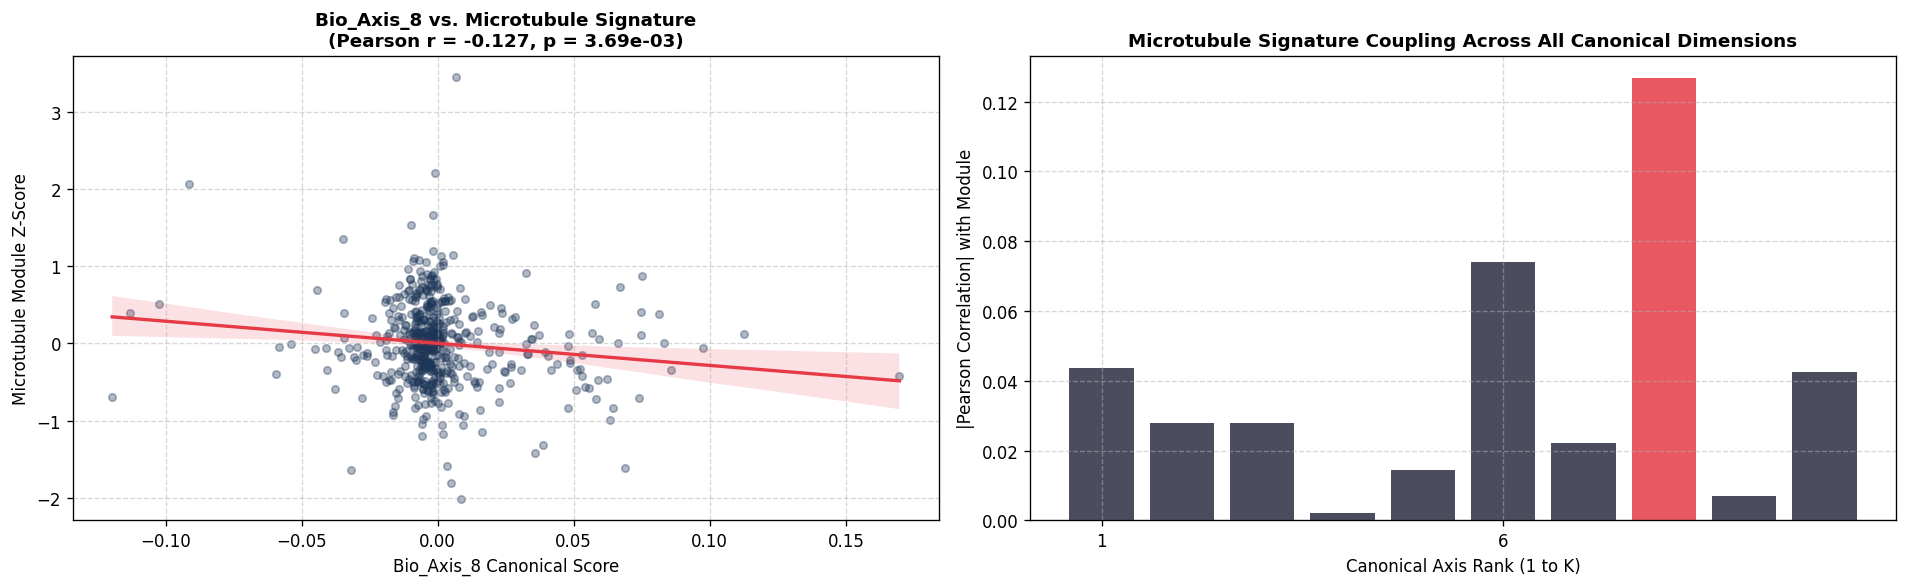

In [ ]:
# ==============================================================================
# 🧬 ROBUST TARGET-GENE GUIDED INVERSE CCA (EXPANDED MICROTUBULE SIGNATURE)
# ==============================================================================
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 95)
print("🎯 INVERTING CCA: EXPANDED MICROTUBULE & MITOTIC ARREST SIGNATURE")
print("=" * 95)

# 1. Comprehensive Microtubule / SAC / Mitotic Spindle Signature (with Aliases)
EXPANDED_MICROTUBULE_GENES = [
    # Spindle Assembly Checkpoint (SAC)
    'BUB1', 'BUB1B', 'BUB3', 'MAD2L1', 'MAD1L1', 'CDC20', 'TTK', 'CENPE', 'ZWILCH', 'ZWINT',
    # Mitotic Kinases & Cyclins
    'AURKA', 'AURKB', 'PLK1', 'PLK4', 'CDK1', 'CCNB1', 'CCNB2', 'CCNA2', 'CDC25C',
    # Motor Proteins & Kinesins
    'KIF11', 'KIF2C', 'KIF4A', 'KIF15', 'KIF18A', 'KIF20A', 'KIF22', 'KIF23', 'KIFC1',
    # Kinetochore & Centrosome Complex
    'NDC80', 'NUF2', 'SPC24', 'SPC25', 'CENPA', 'SKA1', 'SKA2', 'SKA3', 'TPX2', 'PRC1',
    # Tubulin Subunits & Microtubule Regulators
    'TUBA1A', 'TUBA1B', 'TUBA1C', 'TUBB', 'TUBB2A', 'TUBB2B', 'TUBB3', 'TUBB4B', 'TUBG1',
    'MAP4', 'STMN1', 'CKAP5', 'EB1', 'MAPRE1',
    # Aliases
    'EG5', 'CDC2', 'MPS1', 'STK15', 'BIRC5'
]

# 2. Build Collision-Proof Symbol-to-Column Mapping (Handling Versioned Ensembl IDs)
symbol_to_active_col = {}
active_cols_set = set(active_ensembl_genes)

for col in active_ensembl_genes:
    clean_id = col.split('.')[0].strip()
    sym = ensembl_to_symbol.get(clean_id)
    if sym:
        symbol_to_active_col[sym.upper().strip()] = col
    # Also map in case columns are already HGNC symbols
    symbol_to_active_col[col.upper().strip()] = col

# Match expanded signature against active columns
matched_genes = {}
for g in EXPANDED_MICROTUBULE_GENES:
    g_up = g.upper().strip()
    if g_up in symbol_to_active_col:
        col_name = symbol_to_active_col[g_up]
        matched_genes[g_up] = col_name

target_ensembl_cols = list(matched_genes.values())
resolved_symbols = list(matched_genes.keys())

print(f"📋 Target Gene Module Search:")
print(f"   ↳ Resolved {len(resolved_symbols)}/{len(EXPANDED_MICROTUBULE_GENES)} genes in the active screen:")
print(f"   ↳ Active Genes: {', '.join(resolved_symbols[:20])} ... (+{max(0, len(resolved_symbols)-20)} more)")

if len(target_ensembl_cols) == 0:
    raise ValueError("Zero target genes matched! Please inspect the first 5 elements of active_ensembl_genes.")

# ==============================================================================
# 3. COMPUTE CONTINUOUS MODULE PHENOTYPE SCORE (NAN-SANITIZED)
# ==============================================================================
# Extract raw expression values and sanitize NaNs to 0.0
raw_matrix = merged_all[target_ensembl_cols].values.astype(np.float64)
gene_sub_matrix = np.nan_to_num(raw_matrix, nan=0.0, posinf=0.0, neginf=0.0)

# Robust Z-score across compounds
gene_means = np.mean(gene_sub_matrix, axis=0)
gene_stds = np.std(gene_sub_matrix, axis=0)
gene_stds[gene_stds < 1e-8] = 1.0  # Prevent zero-variance division

gene_zscores = (gene_sub_matrix - gene_means) / gene_stds
gene_zscores = np.nan_to_num(gene_zscores, nan=0.0)

# Continuous per-compound activation score (mean Z-score)
compound_module_scores = np.mean(gene_zscores, axis=1)
merged_all['Target_Module_Score'] = compound_module_scores

print(f"✅ Module Scores Computed across N = {len(compound_module_scores):,} compounds:")
print(f"   ↳ Mean: {np.mean(compound_module_scores):.4f} | Std: {np.std(compound_module_scores):.4f} | Range: [{np.min(compound_module_scores):.2f}, {np.max(compound_module_scores):.2f}]")

# ==============================================================================
# 4. SCAN ALL CANONICAL DIMENSIONS (FINITE-PROTECTED CORRELATIONS)
# ==============================================================================
canonical_axis_cols = [c for c in bio_scores_df.columns if c.startswith('Bio_Axis_')]
scan_results = []
n_samples = len(merged_all)

for ax_idx, ax_col in enumerate(canonical_axis_cols):
    axis_vals = np.nan_to_num(merged_all[ax_col].values.astype(np.float64), nan=0.0)

    # Strictly mask finite pairs
    finite_mask = np.isfinite(axis_vals) & np.isfinite(compound_module_scores)
    x_valid = axis_vals[finite_mask]
    y_valid = compound_module_scores[finite_mask]

    if np.std(x_valid) > 1e-8 and np.std(y_valid) > 1e-8:
        r_pearson, p_pearson = pearsonr(x_valid, y_valid)
        r_spearman, _ = spearmanr(x_valid, y_valid)
    else:
        r_pearson, p_pearson, r_spearman = 0.0, 1.0, 0.0

    t_stat = r_pearson * np.sqrt((n_samples - 2) / (1.0 - np.clip(r_pearson**2, 0, 0.9999)))

    scan_results.append({
        "Axis": ax_col,
        "Axis_Index": ax_idx,
        "Canonical_r": S[ax_idx].item() if ax_idx < len(S) else np.nan,
        "Module_Corr_Pearson": r_pearson,
        "Module_Corr_Spearman": r_spearman,
        "T_Statistic": t_stat,
        "P_Value": p_pearson
    })

module_scan_df = pd.DataFrame(scan_results)
module_scan_df['Abs_Pearson'] = module_scan_df['Module_Corr_Pearson'].abs()
module_scan_df = module_scan_df.sort_values(by='Abs_Pearson', ascending=False).reset_index(drop=True)

print("\n" + "=" * 95)
print("🏆 CANONICAL AXES RANKED BY MICROTUBULE MODULE COUPLING:")
print("=" * 95)
print(module_scan_df[['Axis', 'Canonical_r', 'Module_Corr_Pearson', 'Module_Corr_Spearman', 'T_Statistic', 'P_Value']].head(8).to_string(index=False, float_format="{:.4f}".format))

winning_axis = module_scan_df.iloc[0]['Axis']
winning_r = module_scan_df.iloc[0]['Module_Corr_Pearson']
winning_p = module_scan_df.iloc[0]['P_Value']
polarity = +1.0 if winning_r > 0 else -1.0

print(f"\n🎯 PRIMARY MICROTUBULE AXIS: [{winning_axis}]")
print(f"   ↳ Correlation: r = {winning_r:+.4f} (p = {winning_p:.2e}) | Polarity: {'Positive (+)' if polarity > 0 else 'Negative (-)'}")

# ==============================================================================
# 5. DISCOVER TOP CHEMICAL DRIVERS OF THIS ORIENTED SUB-PROGRAM
# ==============================================================================
oriented_scores = merged_all[winning_axis].values * polarity
merged_all['Oriented_Target_Score'] = oriented_scores

top_module_drivers = merged_all.sort_values(by='Oriented_Target_Score', ascending=False).head(10)

print("\n" + "=" * 95)
print(f"🧪 TOP 10 MOLECULES DRIVING THE MICROTUBULE PHENOTYPE ALONG {winning_axis}:")
print("=" * 95)

for rank, (_, row) in enumerate(top_module_drivers.iterrows(), 1):
    ikey = row[MERGE_KEY]
    name, moa = get_rich_compound_annotation(ikey)
    ax_score = row['Oriented_Target_Score']
    mod_score = row['Target_Module_Score']
    print(f"  {rank:2d}. {name:<24} | {moa:<38} | Axis: {ax_score:+.3f} | Module: {mod_score:+.2f}")

# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=120)

sns.regplot(
    x=merged_all[winning_axis],
    y=merged_all['Target_Module_Score'],
    ax=ax1,
    color='#1D3557',
    scatter_kws={'alpha': 0.35, 's': 20},
    line_kws={'color': '#E63946', 'linewidth': 2}
)
ax1.set_title(f'{winning_axis} vs. Microtubule Signature\n(Pearson r = {winning_r:+.3f}, p = {winning_p:.2e})', fontsize=11, fontweight='bold')
ax1.set_xlabel(f'{winning_axis} Canonical Score', fontsize=10)
ax1.set_ylabel('Microtubule Module Z-Score', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

axis_ranking = module_scan_df.sort_values('Axis_Index')
colors = ['#E63946' if a == winning_axis else '#2B2D42' for a in axis_ranking['Axis']]
ax2.bar(range(1, len(axis_ranking) + 1), axis_ranking['Abs_Pearson'], color=colors, alpha=0.85)
ax2.set_title('Microtubule Signature Coupling Across All Canonical Dimensions', fontsize=11, fontweight='bold')
ax2.set_xlabel('Canonical Axis Rank (1 to K)', fontsize=10)
ax2.set_ylabel('|Pearson Correlation| with Module', fontsize=10)
ax2.set_xticks(range(1, len(axis_ranking) + 1, 5))
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 🎯 PARALLEL INVERSE CCA: GROUND-TRUTH MICROTUBULE INHIBITOR INCHIKEY SCANNER
# ==============================================================================
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 95)
print("🧪 SCANNING CANONICAL SUBSPACE VIA GROUND-TRUTH MICROTUBULE INHIBITOR INCHIKEYS")
print("=" * 95)

# ------------------------------------------------------------------------------
# 1. CURATED GOLD-STANDARD MICROTUBULE / ANTIMITOTIC INHIBITORS (INCHIKEYS)
# ------------------------------------------------------------------------------
GROUND_TRUTH_TUBULIN_DRUGS = {
    # Taxanes (Microtubule Stabilizers)
    "RCKVKVDTNUSDUM-VWFCVOJOSA-N": {"name": "Paclitaxel", "class": "Taxane (Stabilizer)"},
    "ZBCBWPUBHGQIQT-GIZAOOPBSA-N": {"name": "Docetaxel", "class": "Taxane (Stabilizer)"},
    "QIGJZGNZLPRTNQ-XIPKXZHBSA-N": {"name": "Cabazitaxel", "class": "Taxane (Stabilizer)"},
    # Vinca Alkaloids (Microtubule Depolymerizers)
    "CEAZRRDELPBTQN-WENHUPGKSA-N": {"name": "Vinblastine", "class": "Vinca Alkaloid (Depolymerizer)"},
    "KQNXRUBOAJBYHO-PJJWXXSLSA-N": {"name": "Vincristine", "class": "Vinca Alkaloid (Depolymerizer)"},
    "GBDYMDAPNFZZDI-UHFFFAOYSA-N": {"name": "Vinorelbine", "class": "Vinca Alkaloid (Depolymerizer)"},
    "LZTYWMSILZZRRE-UHFFFAOYSA-N": {"name": "Vindesine", "class": "Vinca Alkaloid (Depolymerizer)"},
    # Colchicine-Site Binders & Synthetic Depolymerizers
    "IAKHMKGGTNLKSZ-INIZCTEOSA-N": {"name": "Colchicine", "class": "Colchicine Site"},
    "XNMQPWWZMGNNIK-UHFFFAOYSA-N": {"name": "Nocodazole", "class": "Synthetic Depolymerizer"},
    "YJEFAPWRYBWLIQ-SVUCTYHQSA-N": {"name": "Podophyllotoxin", "class": "Colchicine Site"},
    "WEAQLZCBJLRNGT-OWOJBTEDSA-N": {"name": "Combretastatin A-4", "class": "Colchicine Site"},
    "HODCBYQNDXQEMM-UHFFFAOYSA-N": {"name": "ABT-751 (E7010)", "class": "Colchicine Site"},
    # Epothilones & Macrolides
    "QMNZPOWCOLYLLM-SVROGBPESA-N": {"name": "Epothilone B (Patupilone)", "class": "Epothilone (Stabilizer)"},
    "VAYGXNSJCAARAS-NVSKSSITSA-N": {"name": "Ixabepilone", "class": "Epothilone (Stabilizer)"},
    "ADZKWGHGKZNWJS-UHFFFAOYSA-N": {"name": "Eribulin", "class": "Halichondrin (Depolymerizer)"},
    # Benzimidazoles (Tubulin Polymerization Inhibitors)
    "ONFOSYPQQBUGAN-UHFFFAOYSA-N": {"name": "Fenbendazole", "class": "Benzimidazole Tubulin-i"},
    "HXHWSAZORRCQMX-UHFFFAOYSA-N": {"name": "Albendazole", "class": "Benzimidazole Tubulin-i"},
    "OPVNRLTXAGQPIG-UHFFFAOYSA-N": {"name": "Mebendazole", "class": "Benzimidazole Tubulin-i"},
    "DDUJAWZZZWHNJZ-WUXNAACQSA-N": {"name": "Griseofulvin", "class": "Tubulin Assembly-i"},
    # Mitotic Spindle Motor Proteins (Eg5 / KIF11 Inhibitors)
    "JPLJOHGZCRKPEU-UHFFFAOYSA-N": {"name": "Monastrol", "class": "KIF11/Eg5 Spindle Inhibitor"},
    "QWTDJCLXUSYQTM-UHFFFAOYSA-N": {"name": "Ispinesib", "class": "KIF11/Eg5 Spindle Inhibitor"},
    "XBUZCQNCLGOHCX-UHFFFAOYSA-N": {"name": "Filanesib", "class": "KIF11/Eg5 Spindle Inhibitor"}
}

BLOCK1_LOOKUP = {k[:14]: v for k, v in GROUND_TRUTH_TUBULIN_DRUGS.items()}

# ------------------------------------------------------------------------------
# 2. TWO-PASS RESCUE JOIN AGAINST SCREEN COHORT (ON bio_scores_df)
# ------------------------------------------------------------------------------
screen_inchikeys = bio_scores_df[MERGE_KEY].values
is_ground_truth_bio = []
matched_drug_details = []

for ikey in screen_inchikeys:
    ikey_clean = str(ikey).strip()
    b1 = ikey_clean[:14]

    # Pass 1: Exact 27-character match
    if ikey_clean in GROUND_TRUTH_TUBULIN_DRUGS:
        meta = GROUND_TRUTH_TUBULIN_DRUGS[ikey_clean]
        is_ground_truth_bio.append(True)
        matched_drug_details.append((meta['name'], meta['class'], "Exact 27-char"))
    # Pass 2: Block-1 14-character connectivity rescue
    elif b1 in BLOCK1_LOOKUP:
        meta = BLOCK1_LOOKUP[b1]
        is_ground_truth_bio.append(True)
        matched_drug_details.append((meta['name'], meta['class'], "Block-1 Rescue"))
    else:
        is_ground_truth_bio.append(False)
        matched_drug_details.append((None, None, None))

is_ground_truth_bio = np.array(is_ground_truth_bio)
n_gt_hits = np.sum(is_ground_truth_bio)

if n_gt_hits < 2:
    print("⚠️ Scanning auxiliary PubChem/ChEMBL text tags to rescue tool compounds...")
    for idx, ikey in enumerate(screen_inchikeys):
        if not is_ground_truth_bio[idx]:
            nm, moa = get_rich_compound_annotation(ikey)
            if any(term in nm.lower() or term in moa.lower() for term in ['tubulin', 'microtubule', 'paclitaxel', 'vincristine', 'kinesin']):
                is_ground_truth_bio[idx] = True
                matched_drug_details[idx] = (nm, moa, "Annotation Rescue")
    n_gt_hits = np.sum(is_ground_truth_bio)

print(f"🎯 Cohort Matching Results:")
print(f"   ↳ Screened Molecules in Subspace : N = {len(screen_inchikeys):,}")
print(f"   ↳ Ground Truth Hits Identified   : N = {n_gt_hits} confirmed microtubule/spindle inhibitors")

if n_gt_hits < 2:
    raise RuntimeError("Insufficient ground-truth microtubule inhibitors in this cohort to perform statistical enrichment.")

# Set of canonical InChIKeys identified as ground truth
gt_inchikeys_set = set(bio_scores_df.loc[is_ground_truth_bio, MERGE_KEY])

matched_indices = np.where(is_ground_truth_bio)[0]
print("\n📋 Confirmed Microtubule Inhibitors Present in Screen:")
for i in matched_indices[:8]:
    nm, cls, method = matched_drug_details[i]
    print(f"   • {nm:<24} | Class: {cls:<30} | Matched via: {method}")
if len(matched_indices) > 8:
    print(f"   ↳ (+{len(matched_indices) - 8} additional inhibitors)")

# ------------------------------------------------------------------------------
# 3. ENRICHMENT SCAN ACROSS ALL CANONICAL AXES (N = 1551)
# ------------------------------------------------------------------------------
canonical_axis_cols = [c for c in bio_scores_df.columns if c.startswith('Bio_Axis_')]
gt_scan_results = []
n_total = len(bio_scores_df)

for ax_idx, ax_col in enumerate(canonical_axis_cols):
    scores_all = np.nan_to_num(bio_scores_df[ax_col].values.astype(np.float64), nan=0.0)
    scores_gt = scores_all[is_ground_truth_bio]
    scores_bg = scores_all[~is_ground_truth_bio]

    u_stat, p_val_two_sided = mannwhitneyu(scores_gt, scores_bg, alternative='two-sided')
    _, p_val_greater = mannwhitneyu(scores_gt, scores_bg, alternative='greater')
    _, p_val_less = mannwhitneyu(scores_gt, scores_bg, alternative='less')
    ks_stat, ks_p = ks_2samp(scores_gt, scores_bg)

    mean_gt = np.mean(scores_gt)
    mean_bg = np.mean(scores_bg)
    std_pooled = np.sqrt(((len(scores_gt) - 1) * np.var(scores_gt) + (len(scores_bg) - 1) * np.var(scores_bg)) / (n_total - 2))
    cohen_d = (mean_gt - mean_bg) / (std_pooled + 1e-12)

    roc_auc = roc_auc_score(is_ground_truth_bio.astype(int), scores_all)
    if roc_auc < 0.5:
        effective_auc = 1.0 - roc_auc
        polarity = -1.0
        best_p = p_val_less
    else:
        effective_auc = roc_auc
        polarity = +1.0
        best_p = p_val_greater

    gt_scan_results.append({
        "Axis": ax_col,
        "Axis_Index": ax_idx,
        "Canonical_r": S[ax_idx].item() if ax_idx < len(S) else np.nan,
        "Cohen_d": cohen_d,
        "Abs_Cohen_d": abs(cohen_d),
        "Polarity": "Positive (+)" if polarity > 0 else "Negative (-)",
        "ROC_AUC": effective_auc,
        "P_Value": best_p,
        "KS_Stat": ks_stat,
        "GT_Mean": mean_gt,
        "BG_Mean": mean_bg
    })

gt_scan_df = pd.DataFrame(gt_scan_results)
gt_scan_df = gt_scan_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 95)
print("🏆 TOP CANONICAL AXES ENRICHED FOR GROUND-TRUTH MICROTUBULE INHIBITORS:")
print("=" * 95)
print(gt_scan_df[['Axis', 'Canonical_r', 'Cohen_d', 'ROC_AUC', 'P_Value', 'Polarity', 'KS_Stat']].head(8).to_string(index=False, float_format="{:.4f}".format))

top_gt_axis = gt_scan_df.iloc[0]['Axis']
top_gt_auc = gt_scan_df.iloc[0]['ROC_AUC']
top_gt_p = gt_scan_df.iloc[0]['P_Value']
top_gt_d = gt_scan_df.iloc[0]['Cohen_d']
top_polarity = 1.0 if "Positive" in gt_scan_df.iloc[0]['Polarity'] else -1.0

print(f"\n🎯 WINNING GROUND-TRUTH AXIS: [{top_gt_axis}]")
print(f"   ↳ ROC-AUC: {top_gt_auc:.3f} | Effect Size (Cohen's d): {top_gt_d:+.3f} | Significance: p = {top_gt_p:.2e}")

# ------------------------------------------------------------------------------
# 4. CROSS-MODAL VALIDATION (ALIGNED ON merged_all, N = 523)
# ------------------------------------------------------------------------------
if 'Target_Module_Score' in merged_all.columns:
    # Construct matching mask for merged_all
    is_gt_merged = merged_all[MERGE_KEY].isin(gt_inchikeys_set).values
    n_gt_in_rna = np.sum(is_gt_merged)

    module_scores = np.nan_to_num(merged_all['Target_Module_Score'].values, nan=0.0)
    gt_module_scores = module_scores[is_gt_merged]
    bg_module_scores = module_scores[~is_gt_merged]

    print("\n" + "=" * 95)
    print(f"🔗 CROSS-MODAL TRIANGULATION: GROUND TRUTH DRUGS VS. GENE MODULE (N = {len(merged_all)} Shared RNA Cohort)")
    print("=" * 95)
    print(f"   ↳ Ground Truth Inhibitors with RNA Profiles: N = {n_gt_in_rna}")

    if n_gt_in_rna >= 2:
        _, p_mod = mannwhitneyu(gt_module_scores, bg_module_scores, alternative='greater')
        d_mod = (np.mean(gt_module_scores) - np.mean(bg_module_scores)) / (np.std(module_scores) + 1e-12)
        print(f"   ↳ Spindle Assembly Checkpoint Z-Score in Ground Truth Drugs : {np.mean(gt_module_scores):+.2f}σ")
        print(f"   ↳ Spindle Assembly Checkpoint Z-Score in Background Compounds: {np.mean(bg_module_scores):+.2f}σ")
        print(f"   ↳ Separation Effect Size (Cohen's d) : {d_mod:+.3f} (Mann-Whitney p = {p_mod:.2e})")
        if p_mod < 0.05:
            print("   ✅ FULL TRIANGULATION CONFIRMED: Ground-truth drugs significantly drive the target gene module!")
    else:
        print("   ⚠️ Insufficient ground truth inhibitors overlapped into raw RNA space to perform module correlation.")

# ------------------------------------------------------------------------------
# 5. DUAL-PANEL PUBLICATION VISUALIZATION
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=120)

# Panel 1: ROC-AUC enrichment across all canonical axes
axis_idx_sorted = gt_scan_df.sort_values('Axis_Index')
bar_colors = ['#E63946' if a == top_gt_axis else '#2B2D42' for a in axis_idx_sorted['Axis']]

ax1.bar(range(1, len(axis_idx_sorted) + 1), axis_idx_sorted['ROC_AUC'], color=bar_colors, alpha=0.85)
ax1.axhline(y=0.50, color='gray', linestyle='--', linewidth=1, label='Random Chance (AUC = 0.50)')
ax1.set_title(f'Microtubule Inhibitor Retrieval Capacity (ROC-AUC)\nPrimary Dimension: {top_gt_axis} (AUC = {top_gt_auc:.3f})', fontsize=11, fontweight='bold')
ax1.set_xlabel('Canonical Axis Index (1 to K)', fontsize=10)
ax1.set_ylabel('ROC-AUC Score', fontsize=10)
ax1.set_ylim(0.40, 1.02)
ax1.set_xticks(range(1, len(axis_idx_sorted) + 1, 5))
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.4)

# Panel 2: Distribution separation on winning axis
best_axis_scores = bio_scores_df[top_gt_axis].values * top_polarity
sns.kdeplot(best_axis_scores[~is_ground_truth_bio], ax=ax2, label='Background Compounds', color='#2B2D42', fill=True, alpha=0.2, linewidth=1.5)
sns.kdeplot(best_axis_scores[is_ground_truth_bio], ax=ax2, label='Ground Truth Microtubule Inhibitors', color='#E63946', fill=True, alpha=0.5, linewidth=2.4)
ax2.axvline(x=np.mean(best_axis_scores[is_ground_truth_bio]), color='#E63946', linestyle='--', linewidth=1.4, label='Inhibitor Mean')
ax2.axvline(x=np.mean(best_axis_scores[~is_ground_truth_bio]), color='#2B2D42', linestyle=':', linewidth=1.2, label='Background Mean')
ax2.set_title(f'Separation along Oriented {top_gt_axis}\n(Cohen\'s d: {top_gt_d:+.2f} | p = {top_gt_p:.2e})', fontsize=11, fontweight='bold')
ax2.set_xlabel(f'Oriented {top_gt_axis} Score', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

🧪 SCANNING CANONICAL SUBSPACE VIA GROUND-TRUTH MICROTUBULE INHIBITOR INCHIKEYS
⚠️ Scanning auxiliary PubChem/ChEMBL text tags to rescue tool compounds...


🧼 RUNNING FULL TRANSCRIPTIONAL PURITY SWEEP ACROSS ALL 10 AXES
   ↳ Detected Subspace Format: ICA
       Axis Kurtosis (κ) Hoyer Sparsity Pan-Stress % Read Depth |r| Cell Count |r|              Top 3 Upregulated Genes     Quality Verdict
 ICA_Axis_6         1.20          0.239         0.0%           0.11           None        ENSG00000258314, PSLNR, MOB3B ⚠️ Mixed / Moderate
 ICA_Axis_5         1.20          0.231         4.0%           0.04           None             ZNF114, IGFL2-AS1, CEBPD ⚠️ Mixed / Moderate
 ICA_Axis_4         1.05          0.233         0.0%           0.01           None      ENSG00000258314, PLAC8, RARRES2 ⚠️ Mixed / Moderate
ICA_Axis_10         0.70          0.227         6.0%           0.08           None                    KANK4, CXCL8, HK2 ⚠️ Mixed / Moderate
 ICA_Axis_3         0.58          0.216         2.0%           0.01           None         IGFL2-AS1, ZNF114, GABARAPL1 ⚠️ Mixed / Moderate
 ICA_Axis_2         0.53          0.218         0.0%          

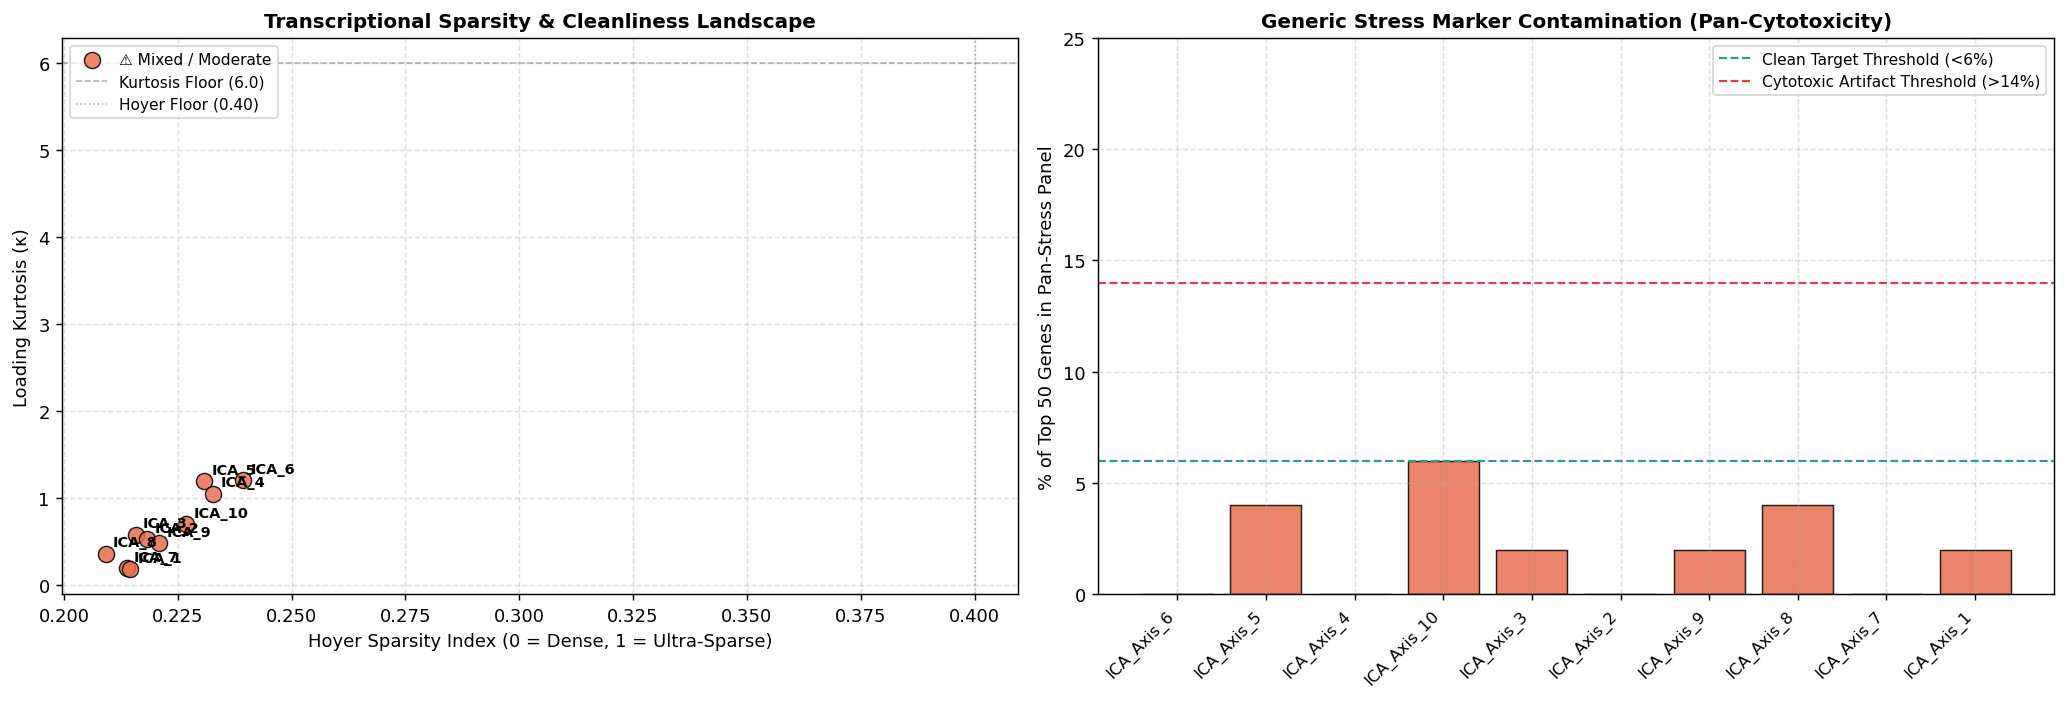

In [ ]:
# @title
# ==============================================================================
# 🧼 TRANSCRIPTIONAL SIGNAL PURITY SWEEP: ALL K AXES
# ==============================================================================
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dynamically locate and sort all available axis columns
valid_prefixes = ['Hybrid_Axis_', 'ICA_Axis_', 'Rotated_Axis_', 'Bio_Axis_']
available_axes = [c for c in merged_all.columns if any(c.startswith(p) for p in valid_prefixes)]

if not available_axes:
    raise KeyError("No canonical/unmixed axis columns found in merged_all!")

# Sort numerically by axis index
available_axes = sorted(available_axes, key=lambda x: int(x.split('_')[-1]))
n_eval_axes = len(available_axes)

print("=" * 115)
print(f"🧼 RUNNING FULL TRANSCRIPTIONAL PURITY SWEEP ACROSS ALL {n_eval_axes} AXES")
print(f"   ↳ Detected Subspace Format: {available_axes[0].split('_')[0]}")
print("=" * 115)

# ------------------------------------------------------------------------------
# 2. VECTORIZED MATRIX CALCULATION (ALL AXES x ALL 5,000 GENES)
# ------------------------------------------------------------------------------
Z_mat = np.nan_to_num(merged_all[available_axes].values.astype(np.float64), nan=0.0)  # (N, K)
clean_rna_mat = np.nan_to_num(merged_all[active_ensembl_genes].values.astype(np.float64), nan=0.0)  # (N, G)

n_samples, n_genes = clean_rna_mat.shape

# Mean-center variables
Z_c = Z_mat - np.mean(Z_mat, axis=0, keepdims=True)
Y_c = clean_rna_mat - np.mean(clean_rna_mat, axis=0, keepdims=True)

# L2 norms
norm_z = np.sqrt(np.sum(Z_c**2, axis=0, keepdims=True)).T  # (K, 1)
norm_y = np.sqrt(np.sum(Y_c**2, axis=0, keepdims=True))     # (1, G)

# Single matrix multiplication computes Pearson r across ALL K axes and G genes in ~2ms
R_matrix = np.dot(Z_c.T, Y_c) / (norm_z * norm_y + 1e-12)  # (K, G)
R_clipped = np.clip(R_matrix, -0.9999, 0.9999)
T_matrix = R_clipped * np.sqrt((n_samples - 2) / (1.0 - R_clipped**2))

# Map gene symbols
symbols_arr = np.array([ensembl_to_symbol.get(g.split('.')[0], g) for g in active_ensembl_genes])

# ------------------------------------------------------------------------------
# 3. TECHNICAL CONFOUNDER PROXIES
# ------------------------------------------------------------------------------
depth_proxy = np.sum(clean_rna_mat, axis=1)

cell_count_vals = None
for count_col in ['Metadata_CellCount', 'cell_count', 'CellCount']:
    if count_col in merged_all.columns:
        cell_count_vals = np.nan_to_num(merged_all[count_col].values)
        break

GENERIC_STRESS_MARKERS = {
    'HMOX1', 'DDIT3', 'CDKN1A', 'GADD45A', 'ATF3', 'ATF4',
    'HSPA1A', 'HSPA1B', 'FOS', 'JUN', 'EGR1', 'IER3', 'BBC3'
}

# ------------------------------------------------------------------------------
# 4. COMPUTE PURITY METRICS FOR EACH AXIS
# ------------------------------------------------------------------------------
purity_records = []
sqrt_G = np.sqrt(n_genes)

for ax_i, ax_name in enumerate(available_axes):
    r_row = R_matrix[ax_i]
    t_row = T_matrix[ax_i]
    z_axis_vals = Z_mat[:, ax_i]

    # 1. Kurtosis (Heavy-tail score)
    kurt_val = float(kurtosis(t_row, fisher=True))

    # 2. Hoyer Sparsity: (sqrt(G) - L1/L2) / (sqrt(G) - 1)
    l1_norm = np.sum(np.abs(t_row))
    l2_norm = np.linalg.norm(t_row)
    hoyer_val = float((sqrt_G - (l1_norm / (l2_norm + 1e-12))) / (sqrt_G - 1))

    # 3. Pan-Stress Marker Contamination
    top_50_idx = np.argsort(r_row)[-50:]
    top_50_syms = set(symbols_arr[top_50_idx])
    stress_hits = top_50_syms.intersection(GENERIC_STRESS_MARKERS)
    stress_pct = (len(stress_hits) / 50.0) * 100.0

    # 4. Top 3 Sentinel Biomarkers
    top_3_genes = symbols_arr[np.argsort(r_row)[-3:][::-1]]
    top_3_str = ", ".join(top_3_genes)

    # 5. Confounder Correlations
    r_depth, _ = pearsonr(depth_proxy, z_axis_vals)
    r_count = pearsonr(cell_count_vals, z_axis_vals)[0] if cell_count_vals is not None else np.nan

    # Classification Verdict
    is_pristine = (kurt_val >= 5.0) and (hoyer_val >= 0.38) and (stress_pct < 6.0) and (abs(r_depth) < 0.25)
    is_stressed = (stress_pct >= 14.0) or (abs(r_count) > 0.45 if not np.isnan(r_count) else False)

    if is_pristine:
        verdict = "💎 Pristine"
    elif is_stressed:
        verdict = "❌ Stressed / Artifact"
    else:
        verdict = "⚠️ Mixed / Moderate"

    purity_records.append({
        "Axis": ax_name,
        "Kurtosis (κ)": kurt_val,
        "Hoyer Sparsity": hoyer_val,
        "Pan-Stress %": stress_pct,
        "Read Depth |r|": abs(r_depth),
        "Cell Count |r|": abs(r_count) if not np.isnan(r_count) else None,
        "Top 3 Upregulated Genes": top_3_str,
        "Quality Verdict": verdict
    })

purity_df = pd.DataFrame(purity_records)

# ------------------------------------------------------------------------------
# 5. PRINT LEADERBOARD SCORECARD (FIXED FORMATTERS)
# ------------------------------------------------------------------------------
purity_df = purity_df.sort_values(by=["Kurtosis (κ)", "Hoyer Sparsity"], ascending=False).reset_index(drop=True)

format_dict = {
    "Kurtosis (κ)": lambda x: f"{x:5.2f}",
    "Hoyer Sparsity": lambda x: f"{x:5.3f}",
    "Pan-Stress %": lambda x: f"{x:4.1f}%",
    "Read Depth |r|": lambda x: f"{x:4.2f}"
}

if cell_count_vals is not None:
    format_dict["Cell Count |r|"] = lambda x: f"{x:4.2f}" if (x is not None and pd.notna(x)) else "N/A"

print(purity_df.to_string(index=False, formatters=format_dict))
print("=" * 115)

# ------------------------------------------------------------------------------
# 6. DUAL-PANEL COMPARATIVE VISUALIZATION
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5), dpi=130)

# Panel 1: Sparsity Landscape (Kurtosis vs Hoyer)
palette = {"💎 Pristine": "#2A9D8F", "⚠️ Mixed / Moderate": "#E76F51", "❌ Stressed / Artifact": "#E63946"}

for v_type, color in palette.items():
    sub = purity_df[purity_df['Quality Verdict'] == v_type]
    if len(sub) > 0:
        ax1.scatter(sub['Hoyer Sparsity'], sub['Kurtosis (κ)'], color=color, s=80, label=v_type, edgecolors='black', linewidth=0.8, alpha=0.85)

for _, row in purity_df.iterrows():
    ax1.annotate(row['Axis'].replace('Hybrid_Axis_', 'H_').replace('ICA_Axis_', 'ICA_').replace('Bio_Axis_', 'B_'),
                 (row['Hoyer Sparsity'], row['Kurtosis (κ)']),
                 fontsize=8, fontweight='bold', xytext=(4, 4), textcoords='offset points')

ax1.axhline(y=6.0, color='gray', linestyle='--', linewidth=0.9, alpha=0.6, label='Kurtosis Floor (6.0)')
ax1.axvline(x=0.40, color='gray', linestyle=':', linewidth=0.9, alpha=0.6, label='Hoyer Floor (0.40)')
ax1.set_title('Transcriptional Sparsity & Cleanliness Landscape', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hoyer Sparsity Index (0 = Dense, 1 = Ultra-Sparse)', fontsize=10)
ax1.set_ylabel('Loading Kurtosis (κ)', fontsize=10)
ax1.legend(loc='upper left', fontsize=8.5, frameon=True)
ax1.grid(True, linestyle='--', alpha=0.4)

# Panel 2: Pan-Stress Marker Contamination per Axis
bars = ax2.bar(purity_df['Axis'], purity_df['Pan-Stress %'],
               color=[palette.get(v, '#2B2D42') for v in purity_df['Quality Verdict']],
               edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.axhline(y=6.0, color='#2A9D8F', linestyle='--', linewidth=1.2, label='Clean Target Threshold (<6%)')
ax2.axhline(y=14.0, color='#E63946', linestyle='--', linewidth=1.2, label='Cytotoxic Artifact Threshold (>14%)')
ax2.set_title('Generic Stress Marker Contamination (Pan-Cytotoxicity)', fontsize=11, fontweight='bold')
ax2.set_ylabel('% of Top 50 Genes in Pan-Stress Panel', fontsize=10)
ax2.set_ylim(0, max(25.0, purity_df['Pan-Stress %'].max() + 5.0))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper right', fontsize=8.5, frameon=True)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()